# Full Runnable Gut Microbiome Project

This notebook combines the selected notebooks and Python files into one runnable notebook.

Run this notebook from top to bottom.

# 1. Create helper Python files

## Python helper file: `config.py`

In [12]:
from config import DATA_DIR

In [13]:
from pathlib import Path

Path('config.py').write_text('from pathlib import Path\n\nPROJECT_ROOT = Path(__file__).resolve().parent\nDATA_DIR = PROJECT_ROOT / "data"\n', encoding="utf-8")
print("Created helper file:", 'config.py')


Created helper file: config.py


## Python helper file: `model.py`

In [14]:
from pathlib import Path

Path('model.py').write_text('import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.model_selection import GroupKFold\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.metrics import accuracy_score, classification_report, roc_auc_score\n\n#Import models\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.ensemble import RandomForestClassifier\nfrom xgboost import XGBClassifier\n\n#Regression imports\nfrom sklearn.linear_model import LinearRegression\nfrom sklearn.ensemble import RandomForestRegressor\nfrom xgboost import XGBRegressor\nfrom sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error\nfrom sklearn.base import clone\n\nfrom config import DATA_DIR\nfrom sklearn.linear_model import Ridge\n\nfrom sklearn.svm import SVC\nfrom lightgbm import LGBMClassifier\nfrom sklearn.calibration import CalibratedClassifierCV\n\n\n#Load data\ndf_fme = pd.read_csv(DATA_DIR / "fme_statistical_dataset_extended.csv", index_col=0)\nprint(f"Loaded dataset: {df_fme.shape[0]} samples, {df_fme.shape[1]} columns")\nprint(f"Participants: {df_fme[\'participant_id\'].nunique()}")\nprint("Sample of Data:")\nprint(df_fme.head())\n\n#Turn shannon diversity from contiues to binary\nmedian_shannon = df_fme["shannon_diversity"].median()\ndf_fme["High_Diversity_Class"] = (df_fme["shannon_diversity"] > median_shannon).astype(int)\nprint(f"\\nTarget distribution (High=1 / Low=0):")\nprint(df_fme["High_Diversity_Class"].value_counts())\n\n#Features\nfeature_cols = [\n    "fme_score_daily",\n    "fme_participant_mean",\n    "fme_within_person",\n    "fme_weighted_3day",\n    "KCAL",\n    "FIBE",\n    "CARB",\n    "TFAT",\n    "PROT",\n    "Age",\n    "BMI"\n]\n\nfeature_cols_lagged = [\n    "fme_score_daily",\n    "fme_participant_mean",\n    "fme_within_person",\n    "fme_lag1",\n    "fme_lag2",\n    "KCAL",\n    "FIBE",\n    "CARB",\n    "TFAT",\n    "PROT",\n    "Age",\n    "BMI"\n]\n\nfeature_cols_full_fme = [\n    "fme_score_daily",\n    "fme_participant_mean",\n    "fme_within_person",\n    "fme_weighted_3day",\n    "fme_lag1",\n    "fme_lag2",\n    "KCAL",\n    "FIBE",\n    "CARB",\n    "TFAT",\n    "PROT",\n    "Age",\n    "BMI"\n]\n\nfeature_cols_full_fme = [f for f in feature_cols_full_fme if f in df_fme.columns]\n\nfeature_cols_lagged = [f for f in feature_cols_lagged if f in df_fme.columns]\n\nfeature_cols = [f for f in feature_cols if f in df_fme.columns]\n\n#Drop rows with missing values in features or target\ndf_fme_clean = df_fme[feature_cols + ["High_Diversity_Class", "participant_id"]].dropna()\n\n#Prepare data for modeling\nX = df_fme_clean[feature_cols]\nprint(X.columns.tolist())\ny = df_fme_clean[\'High_Diversity_Class\']\ngroups = df_fme_clean[\'participant_id\']\n\n#Define models\nmodels = {\n    "Logistic Regression": LogisticRegression(),\n    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),\n    "XGBoost": XGBClassifier(eval_metric=\'logloss\', random_state=42),\n    "SVM": CalibratedClassifierCV(SVC(kernel=\'rbf\'), ensemble=False),\n    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)\n}\n\n#Cross validation\ngkf = GroupKFold(n_splits=5)\n\n#Train and evaluate models\nprint("\\nModel Comparison Results:")\nbest_model_name = ""\nbest_auc = 0\nbest_model_obj  = None\n\nfor name, model in models.items():\n    acc_scores = []\n    auc_scores = []\n    \n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf.split(X, y, groups=groups):\n        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]\n        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]\n        \n        #Scale features\n        scaler = StandardScaler()\n        # X_train_scaled = scaler.fit_transform(X_train)\n        # X_test_scaled = scaler.transform(X_test)\n        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)\n        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)\n        \n        #Train\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n        fold_model.fit(X_train_scaled, y_train)\n        \n        #Predictions\n        y_pred = fold_model.predict(X_test_scaled)\n        y_proba = fold_model.predict_proba(X_test_scaled)[:, 1]\n        \n        #Calculate metrics\n        acc_scores.append(accuracy_score(y_test, y_pred))\n        auc_scores.append(roc_auc_score(y_test, y_proba))\n    \n    #Compute mean metrics across folds\n    mean_acc = np.mean(acc_scores)\n    std_acc = np.std(acc_scores)\n    mean_auc = np.mean(auc_scores)\n    std_auc = np.std(auc_scores)\n    \n    print(f"\\n[{name}]")\n    print(f"Mean Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")\n    print(f"Mean ROC-AUC:  {mean_auc:.3f} ± {std_auc:.3f}")\n    \n    #Save best model based on AUC\n    if mean_auc > best_auc:\n        best_auc = mean_auc\n        best_model_name = name\n        best_model_obj  = clone(model)\n\nprint(f"\\n Best Model: {best_model_name} (Mean AUC = {best_auc:.3f})")\n\n#Refit best  model on the full clean regression dataset\nfinal_reg_scaler = StandardScaler()\nX_scaled = final_reg_scaler.fit_transform(X)\nbest_model_obj.fit(X_scaled, y)\n\n\n#Feature importance for best modelv\nif best_model_name == "Logistic Regression":\n    importances = np.abs(best_model_obj.coef_[0])\n    title       = "Feature Importance (Logistic Regression - Absolute Coefficients)"\n    xlabel      = "Absolute Coefficient Value"\nelif best_model_name == "SVM":\n    print("SVM does not support feature importance with rbf kernel - skipping plot")\n    importances = None\nelse:\n    importances = best_model_obj.feature_importances_\n    title       = f"Feature Importance ({best_model_name})"\n    xlabel      = "Importance Score"\n \nif importances is not None:\n    indices      = np.argsort(importances)[::-1]\n    feature_arr  = np.array(feature_cols)\n \n    plt.figure(figsize=(10, 6))\n    sns.barplot(x=importances[indices], y=feature_arr[indices], hue=feature_arr[indices], palette="viridis", legend=False)\n    plt.title(title, fontsize=14)\n    plt.xlabel(xlabel, fontsize=12)\n    plt.ylabel("Feature", fontsize=12)\n    plt.tight_layout()\n    plt.savefig(DATA_DIR / "feature_importance.png", dpi=150)      #Save before showings\n    plt.show()\n    print(f"Plot saved: {DATA_DIR / \'feature_importance.png\'}")\n\n\n\n#Regression: predict continuous Shannon diversity\nprint("\\n Regression: Predict Shannon Diversity")\n\n#Use the same features, but keep Shannon diversity as a continuous target\ndf_reg_clean = df_fme[feature_cols + ["shannon_diversity", "participant_id"]].dropna()\n\n#Prepare regression data\nX_reg = df_reg_clean[feature_cols]\ny_reg = df_reg_clean["shannon_diversity"]\ngroups_reg = df_reg_clean["participant_id"]\n\nprint(f"Regression dataset: {df_reg_clean.shape[0]} samples")\nprint(f"Features used: {feature_cols}")\nprint(f"Target mean Shannon diversity: {y_reg.mean():.3f}")\nprint(f"Target std Shannon diversity:  {y_reg.std():.3f}")\n\n# Define regression models\nregression_models = {\n    "Linear Regression": LinearRegression(),\n    "Ridge Regression": Ridge(alpha=1.0),\n    "Random Forest Regressor": RandomForestRegressor(\n        n_estimators=100,\n        random_state=42\n    ),\n    "XGBoost Regressor": XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=100,\n        random_state=42\n    )\n}\n\n# Use grouped cross validation to avoid participant leakage\ngkf_reg = GroupKFold(n_splits=5)\n\n#Train and evaluate regression models\nprint("\\nRegression Model Comparison Results")\n\nbest_reg_model_name = ""\nbest_reg_r2 = -np.inf\nbest_reg_model_template = None\n\nregression_results = []\nall_y_true_best = []\nall_y_pred_best = []\n\nfor name, model in regression_models.items():\n    r2_scores = []\n    rmse_scores = []\n    mae_scores = []\n    all_y_true = []\n    all_y_pred = []\n\n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf_reg.split(X_reg, y_reg, groups=groups_reg):\n        X_train, X_test = X_reg.iloc[train_idx], X_reg.iloc[test_idx]\n        y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]\n\n        #Scale features using train data only\n        scaler = StandardScaler()\n        X_train_scaled = scaler.fit_transform(X_train)\n        X_test_scaled = scaler.transform(X_test)\n\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n\n        #Train\n        fold_model.fit(X_train_scaled, y_train)\n\n        #Predict continuous Shannon diversity\n        y_pred = fold_model.predict(X_test_scaled)\n\n        #Calculate regression metrics\n        r2_scores.append(r2_score(y_test, y_pred))\n        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))\n        mae_scores.append(mean_absolute_error(y_test, y_pred))\n        all_y_true.extend(y_test)\n        all_y_pred.extend(y_pred)\n\n    #Compute mean metrics across folds\n    mean_r2 = np.mean(r2_scores)\n    std_r2 = np.std(r2_scores)\n    mean_rmse = np.mean(rmse_scores)\n    mean_mae = np.mean(mae_scores)\n\n    regression_results.append({\n        "Model": name,\n        "Mean R2": mean_r2,\n        "Std R2": std_r2,\n        "Mean RMSE": mean_rmse,\n        "Mean MAE": mean_mae\n    })\n\n    print(f"\\n[{name}]")\n    print(f"Mean R^2:    {mean_r2:.3f} ± {std_r2:.3f}")\n    print(f"Mean RMSE:  {mean_rmse:.3f}")\n    print(f"Mean MAE:   {mean_mae:.3f}")\n\n    #Save best regression model based on R2\n    if mean_r2 > best_reg_r2:\n        best_reg_r2 = mean_r2\n        best_reg_model_name = name\n        best_reg_model_template = model\n        all_y_true_best = all_y_true\n        all_y_pred_best = all_y_pred\n\nprint(f"\\nBest Regression Model: {best_reg_model_name} (Mean R² = {best_reg_r2:.3f})")\n\n# Save regression results table\nregression_results_df = pd.DataFrame(regression_results)\nregression_results_path = DATA_DIR / "regression_model_comparison.csv"\nregression_results_df.to_csv(regression_results_path, index=False)\nprint(f"Regression results saved: {regression_results_path}")\n\n#Refit best regression model on the full clean regression dataset\nfinal_reg_scaler = StandardScaler()\nX_reg_scaled = final_reg_scaler.fit_transform(X_reg)\n\nbest_reg_model_obj = clone(best_reg_model_template)\nbest_reg_model_obj.fit(X_reg_scaled, y_reg)\n\n#Feature importance for best regression model\nif best_reg_model_name == "Linear Regression" or best_reg_model_name == "Ridge Regression" :\n    reg_importances = np.abs(best_reg_model_obj.coef_)\n    reg_title = "Feature Importance ("+best_reg_model_name+" — Absolute Coefficients)"\n    reg_xlabel = "Absolute Coefficient Value"\nelse:\n    reg_importances = best_reg_model_obj.feature_importances_\n    reg_title = f"Feature Importance ({best_reg_model_name})"\n    reg_xlabel = "Importance Score"\n\nreg_indices = np.argsort(reg_importances)[::-1]\nfeature_arr = np.array(feature_cols)\n\nplt.figure(figsize=(10, 6))\nsns.barplot(\n    x=reg_importances[reg_indices],\n    y=feature_arr[reg_indices],\n    hue=feature_arr[reg_indices],\n    palette="viridis",\n    legend=False\n)\nplt.title(reg_title, fontsize=14)\nplt.xlabel(reg_xlabel, fontsize=12)\nplt.ylabel("Feature", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "regression_feature_importance.png", dpi=150)\nplt.show()\nprint(f"Regression feature importance plot saved: {DATA_DIR / \'regression_feature_importance.png\'}")\n\n\nall_y_true = np.array(all_y_true_best)\nall_y_pred = np.array(all_y_pred_best)\n\n#Plot predicted vs actual Shannon diversity\nplt.figure(figsize=(7, 7))\nsns.scatterplot(x=all_y_true, y=all_y_pred)\nplt.plot(\n    [all_y_true.min(), all_y_true.max()],\n    [all_y_true.min(), all_y_true.max()],\n    linestyle="--"\n)\nplt.title(f"Predicted vs Actual Shannon Diversity ({best_reg_model_name})", fontsize=14)\nplt.xlabel("Actual Shannon Diversity", fontsize=12)\nplt.ylabel("Predicted Shannon Diversity", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "regression_predicted_vs_actual.png", dpi=150)\nplt.show()\nprint(f"Prediction plot saved: {DATA_DIR / \'regression_predicted_vs_actual.png\'}")\n\n#Plot residuals\nresiduals = all_y_true - all_y_pred\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=all_y_pred, y=residuals)\nplt.axhline(0, linestyle="--")\nplt.title(f"Residual Plot ({best_reg_model_name})", fontsize=14)\nplt.xlabel("Predicted Shannon Diversity", fontsize=12)\nplt.ylabel("Residuals", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "regression_residuals.png", dpi=150)\nplt.show()\nprint(f"Residual plot saved: {DATA_DIR / \'regression_residuals.png\'}")\n\n#  Try model distance from avarge shanon instead of predict shanon\n# Calculate avg shanon score\ndf_fme[\'shannon_avg\'] = df_fme.groupby(\'participant_id\')[\'shannon_diversity\'].transform(\'mean\')\n# Calculate sample shanon deviation\ndf_fme[\'shannon_deviation\'] = df_fme[\'shannon_diversity\'] - df_fme[\'shannon_avg\']\n\n#Regression: predict continuous distance from avg Shannon diversity\nprint("\\n Regression: predict continuous distance from avg Shannon diversity")\n\n#Use the same features, but keep Shannon diversity as a continuous target\ndf_reg_dev_clean = df_fme[feature_cols + ["shannon_deviation", "participant_id"]].dropna()\n\n#Prepare regression data\nX_dev_reg = df_reg_dev_clean[feature_cols]\ny_dev_reg = df_reg_dev_clean["shannon_deviation"]\ngroups_dev_reg = df_reg_dev_clean["participant_id"]\n\nprint(f"Regression dataset: {df_reg_dev_clean.shape[0]} samples")\nprint(f"Features used: {feature_cols}")\nprint(f"Target mean Shannon deviation diversity: {y_dev_reg.mean():.3f}")\nprint(f"Target std Shannon deviation diversity:  {y_dev_reg.std():.3f}")\n\n#Define regression models\nregression_dev_models = {\n    "Linear Regression": LinearRegression(),\n    "Ridge Regression": Ridge(alpha=1.0),\n    "Random Forest Regressor": RandomForestRegressor(\n        n_estimators=100,\n        random_state=42\n    ),\n    "XGBoost Regressor": XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=100,\n        random_state=42\n    )\n}\n\n#Use grouped cross validation to avoid participant leakage\ngkf_reg = GroupKFold(n_splits=5)\n\n#Train and evaluate regression models\nprint("\\nRegression Model for deviation  Comparison Results")\n\nbest_dev_reg_model_name = ""\nbest_dev_reg_r2 = -np.inf\nbest_dev_reg_model_template = None\n\nregression_dev_results = []\nall_dev_y_true_best = []\nall_dev_y_pred_best = []\n\nfor name, model in regression_dev_models.items():\n    r2_scores = []\n    rmse_scores = []\n    mae_scores = []\n    all_y_true = []\n    all_y_pred = []\n\n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf_reg.split(X_dev_reg, y_dev_reg, groups=groups_dev_reg):\n        X_train, X_test = X_dev_reg.iloc[train_idx], X_dev_reg.iloc[test_idx]\n        y_train, y_test = y_dev_reg.iloc[train_idx], y_dev_reg.iloc[test_idx]\n\n        #Scale features using train data only\n        scaler = StandardScaler()\n        X_train_scaled = scaler.fit_transform(X_train)\n        X_test_scaled = scaler.transform(X_test)\n\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n\n        #Train\n        fold_model.fit(X_train_scaled, y_train)\n\n        #Predict continuous Shannon diversity\n        y_pred = fold_model.predict(X_test_scaled)\n\n        #Calculate regression metrics\n        r2_scores.append(r2_score(y_test, y_pred))\n        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))\n        mae_scores.append(mean_absolute_error(y_test, y_pred))\n        all_y_true.extend(y_test)\n        all_y_pred.extend(y_pred)\n\n    #Compute mean metrics across folds\n    mean_r2 = np.mean(r2_scores)\n    std_r2 = np.std(r2_scores)\n    mean_rmse = np.mean(rmse_scores)\n    mean_mae = np.mean(mae_scores)\n\n    regression_dev_results.append({\n        "Model": name,\n        "Mean R2": mean_r2,\n        "Std R2": std_r2,\n        "Mean RMSE": mean_rmse,\n        "Mean MAE": mean_mae\n    })\n\n    print(f"\\n[{name}]")\n    print(f"Mean R^2:    {mean_r2:.3f} ± {std_r2:.3f}")\n    print(f"Mean RMSE:  {mean_rmse:.3f}")\n    print(f"Mean MAE:   {mean_mae:.3f}")\n\n    #Save best regression model based on R2\n    if mean_r2 > best_dev_reg_r2:\n        best_dev_reg_r2 = mean_r2\n        best_dev_reg_model_name = name\n        best_dev_reg_model_template = model\n        all_dev_y_true_best = all_y_true\n        all_dev_y_pred_best = all_y_pred\n\nprint(f"\\nBest Regression Model: {best_dev_reg_model_name} (Mean R² = {best_dev_reg_r2:.3f})")\n\n#Save regression  deviation from avg results table\nregression_dev_results_df = pd.DataFrame(regression_dev_results)\nregression_dev_results_path = DATA_DIR / "regression_dev_model_comparison.csv"\nregression_dev_results_df.to_csv(regression_dev_results_path, index=False)\nprint(f"Regression results saved: {regression_dev_results_path}")\n\n#Refit best regression model on the full clean regression dataset\nfinal_dev_reg_scaler = StandardScaler()\nX_dev_reg_scaled = final_dev_reg_scaler.fit_transform(X_dev_reg)\n\nbest_dev_reg_model_obj = clone(best_dev_reg_model_template)\nbest_dev_reg_model_obj.fit(X_dev_reg_scaled, y_dev_reg)\n\n#Feature importance for best regression model\nif best_dev_reg_model_name == "Linear Regression" or best_dev_reg_model_name == "Ridge Regression" :\n    reg_dev_importances = np.abs(best_dev_reg_model_obj.coef_)\n    reg_dev_title = "Feature Importance ("+best_dev_reg_model_name+" - Absolute Coefficients)"\n    reg_dev_xlabel = "Absolute Coefficient Value"\nelse:\n    reg_dev_importances = best_dev_reg_model_obj.feature_importances_\n    reg_dev_title = f"Feature Importance ({best_dev_reg_model_name})"\n    reg_dev_xlabel = "Importance Score"\n\nreg_dev_indices = np.argsort(reg_dev_importances)[::-1]\nfeature_dev_arr = np.array(feature_cols)\n\n# Bar plot of distribution of Shannon Deviation from Personal Average\nplt.figure(figsize=(8, 5))\nsns.histplot(df_reg_dev_clean["shannon_deviation"], bins=30, kde=True)\nplt.axvline(0, linestyle="--", color="red")\nplt.title("Distribution of Shannon Deviation from Personal Average", fontsize=14)\nplt.xlabel("Shannon Deviation", fontsize=12)\nplt.ylabel("Count", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "dev_shannon_deviation_distribution.png", dpi=150)\nplt.show()\n\n# Bar plot of feature importance\nplt.figure(figsize=(10, 6))\nsns.barplot(\n    x=reg_dev_importances[reg_dev_indices],\n    y=feature_dev_arr[reg_dev_indices],\n    hue=feature_dev_arr[reg_dev_indices],\n    palette="viridis",\n    legend=False\n)\nplt.title(reg_dev_title, fontsize=14)\nplt.xlabel(reg_dev_xlabel, fontsize=12)\nplt.ylabel("Feature", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "dev_regression_feature_importance.png", dpi=150)\nplt.show()\nprint(f"Regression feature importance plot saved: {DATA_DIR / \'dev_regression_feature_importance.png\'}")\n\n\nall_dev_y_true = np.array(all_dev_y_true_best)\nall_dev_y_pred = np.array(all_dev_y_pred_best)\n\n#Plot predicted vs actual Shannon diversity\nplt.figure(figsize=(7, 7))\nsns.scatterplot(x=all_dev_y_true, y=all_dev_y_pred)\nplt.plot(\n    [all_dev_y_true.min(), all_dev_y_true.max()],\n    [all_dev_y_true.min(), all_dev_y_true.max()],\n    linestyle="--"\n)\nplt.title(f"Predicted vs Actual Shannon Deviation  ({best_dev_reg_model_name})", fontsize=14)\nplt.xlabel("Actual Shannon Deviation", fontsize=12)\nplt.ylabel("Predicted Shannon Deviation", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "dev_regression_predicted_vs_actual.png", dpi=150)\nplt.show()\nprint(f"Prediction plot saved: {DATA_DIR / \'dev_regression_predicted_vs_actual.png\'}")\n\n#Plot residuals\ndev_residuals = all_dev_y_true - all_dev_y_pred\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=all_dev_y_pred, y=dev_residuals)\nplt.axhline(0, linestyle="--")\nplt.title(f"Residual Plot ({best_dev_reg_model_name})", fontsize=14)\nplt.xlabel("Predicted Shannon Deviation", fontsize=12)\nplt.ylabel("Residuals", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "dev_regression_residuals.png", dpi=150)\nplt.show()\nprint(f"Residual plot saved: {DATA_DIR / \'dev_regression_residuals.png\'}")', encoding="utf-8")
print("Created helper file:", 'model.py')


Created helper file: model.py


## Python helper file: `model_lagged.py`

In [15]:
from pathlib import Path

Path('model_lagged.py').write_text('import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.model_selection import GroupKFold\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.metrics import accuracy_score, classification_report, roc_auc_score\n\n#Import models\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.ensemble import RandomForestClassifier\nfrom xgboost import XGBClassifier\n\n#Regression imports\nfrom sklearn.linear_model import LinearRegression\nfrom sklearn.ensemble import RandomForestRegressor\nfrom xgboost import XGBRegressor\nfrom sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error\nfrom sklearn.base import clone\n\nfrom config import DATA_DIR\nfrom sklearn.linear_model import Ridge\n\nfrom sklearn.svm import SVC\nfrom lightgbm import LGBMClassifier\nfrom sklearn.calibration import CalibratedClassifierCV\n\n\n#Load data\ndf_fme = pd.read_csv(DATA_DIR / "fme_statistical_dataset_extended.csv", index_col=0)\nprint(f"Loaded dataset: {df_fme.shape[0]} samples, {df_fme.shape[1]} columns")\nprint(f"Participants: {df_fme[\'participant_id\'].nunique()}")\nprint("Sample of Data:")\nprint(df_fme.head())\n\n#Turn shannon diversity from contiues to binary\nmedian_shannon = df_fme["shannon_diversity"].median()\ndf_fme["High_Diversity_Class"] = (df_fme["shannon_diversity"] > median_shannon).astype(int)\nprint(f"\\nTarget distribution (High=1 / Low=0):")\nprint(df_fme["High_Diversity_Class"].value_counts())\n\n#Features\nfeature_cols_lagged = [\n    "fme_score_daily",\n    "fme_participant_mean",\n    "fme_within_person",\n    "fme_lag1",\n    "fme_lag2",\n    "KCAL",\n    "FIBE",\n    "CARB",\n    "TFAT",\n    "PROT",\n    "Age",\n    "BMI"\n]\n\nfeature_cols_lagged = [f for f in feature_cols_lagged if f in df_fme.columns]\n\n\n#Drop rows with missing values in features or target\ndf_fme_clean = df_fme[feature_cols_lagged + ["High_Diversity_Class", "participant_id"]].dropna()\n\n#Check how many samples are left\nprint(f"Lagged classification clean dataset: {df_fme_clean.shape[0]} samples")\nprint(f"Participants after cleaning: {df_fme_clean[\'participant_id\'].nunique()}")\n\n#Prepare data for modeling\nX = df_fme_clean[feature_cols_lagged]\nprint(X.columns.tolist())\ny = df_fme_clean[\'High_Diversity_Class\']\ngroups = df_fme_clean[\'participant_id\']\n\n#Define models\nmodels = {\n    "Logistic Regression": LogisticRegression(),\n    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),\n    "XGBoost": XGBClassifier(eval_metric=\'logloss\', random_state=42),\n    "SVM": CalibratedClassifierCV(SVC(kernel=\'rbf\'), ensemble=False),\n    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)\n}\n\n#Cross validation\ngkf = GroupKFold(n_splits=5)\n\n#Train and evaluate models\nprint("\\nModel Comparison Results:")\nbest_model_name = ""\nbest_auc = 0\nbest_model_obj  = None\n\nfor name, model in models.items():\n    acc_scores = []\n    auc_scores = []\n    \n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf.split(X, y, groups=groups):\n        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]\n        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]\n        \n        #Scale features\n        scaler = StandardScaler()\n        # X_train_scaled = scaler.fit_transform(X_train)\n        # X_test_scaled = scaler.transform(X_test)\n        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols_lagged)\n        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols_lagged)\n        \n        #Train\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n        fold_model.fit(X_train_scaled, y_train)\n        \n        #Predictions\n        y_pred = fold_model.predict(X_test_scaled)\n        y_proba = fold_model.predict_proba(X_test_scaled)[:, 1]\n        \n        #Calculate metrics\n        acc_scores.append(accuracy_score(y_test, y_pred))\n        auc_scores.append(roc_auc_score(y_test, y_proba))\n    \n    #Compute mean metrics across folds\n    mean_acc = np.mean(acc_scores)\n    std_acc = np.std(acc_scores)\n    mean_auc = np.mean(auc_scores)\n    std_auc = np.std(auc_scores)\n    \n    print(f"\\n[{name}]")\n    print(f"Mean Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")\n    print(f"Mean ROC-AUC:  {mean_auc:.3f} ± {std_auc:.3f}")\n    \n    #Save best model based on AUC\n    if mean_auc > best_auc:\n        best_auc = mean_auc\n        best_model_name = name\n        best_model_obj  = clone(model)\n\nprint(f"\\n Best Model: {best_model_name} (Mean AUC = {best_auc:.3f})")\n\n#Refit best  model on the full clean regression dataset\nfinal_reg_scaler = StandardScaler()\nX_scaled = final_reg_scaler.fit_transform(X)\nbest_model_obj.fit(X_scaled, y)\n\n\n#Feature importance for best modelv\nif best_model_name == "Logistic Regression":\n    importances = np.abs(best_model_obj.coef_[0])\n    title       = "Feature Importance (Logistic Regression - Absolute Coefficients)"\n    xlabel      = "Absolute Coefficient Value"\nelif best_model_name == "SVM":\n    print("SVM does not support feature importance with rbf kernel - skipping plot")\n    importances = None\nelse:\n    importances = best_model_obj.feature_importances_\n    title       = f"Feature Importance ({best_model_name})"\n    xlabel      = "Importance Score"\n \nif importances is not None:\n    indices      = np.argsort(importances)[::-1]\n    feature_arr  = np.array(feature_cols_lagged)\n \n    plt.figure(figsize=(10, 6))\n    sns.barplot(x=importances[indices], y=feature_arr[indices], hue=feature_arr[indices], palette="viridis", legend=False)\n    plt.title(title, fontsize=14)\n    plt.xlabel(xlabel, fontsize=12)\n    plt.ylabel("Feature", fontsize=12)\n    plt.tight_layout()\n    plt.savefig(DATA_DIR / "lagged_feature_importance.png", dpi=150)      #Save before showings\n    plt.show()\n    print(f"Plot saved: {DATA_DIR / \'lagged_feature_importance.png\'}")\n\n\n\n#Regression: predict continuous Shannon diversity\nprint("\\n Regression: Predict Shannon Diversity")\n\n#Use the same features, but keep Shannon diversity as a continuous target\ndf_reg_clean = df_fme[feature_cols_lagged + ["shannon_diversity", "participant_id"]].dropna()\n\n#Prepare regression data\nX_reg = df_reg_clean[feature_cols_lagged]\ny_reg = df_reg_clean["shannon_diversity"]\ngroups_reg = df_reg_clean["participant_id"]\n\nprint(f"Regression dataset: {df_reg_clean.shape[0]} samples")\nprint(f"Features used: {feature_cols_lagged}")\nprint(f"Target mean Shannon diversity: {y_reg.mean():.3f}")\nprint(f"Target std Shannon diversity:  {y_reg.std():.3f}")\n\n# Define regression models\nregression_models = {\n    "Linear Regression": LinearRegression(),\n    "Ridge Regression": Ridge(alpha=1.0),\n    "Random Forest Regressor": RandomForestRegressor(\n        n_estimators=100,\n        random_state=42\n    ),\n    "XGBoost Regressor": XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=100,\n        random_state=42\n    )\n}\n\n# Use grouped cross validation to avoid participant leakage\ngkf_reg = GroupKFold(n_splits=5)\n\n#Train and evaluate regression models\nprint("\\nRegression Model Comparison Results")\n\nbest_reg_model_name = ""\nbest_reg_r2 = -np.inf\nbest_reg_model_template = None\n\nregression_results = []\nall_y_true_best = []\nall_y_pred_best = []\n\nfor name, model in regression_models.items():\n    r2_scores = []\n    rmse_scores = []\n    mae_scores = []\n    all_y_true = []\n    all_y_pred = []\n\n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf_reg.split(X_reg, y_reg, groups=groups_reg):\n        X_train, X_test = X_reg.iloc[train_idx], X_reg.iloc[test_idx]\n        y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]\n\n        #Scale features using train data only\n        scaler = StandardScaler()\n        X_train_scaled = scaler.fit_transform(X_train)\n        X_test_scaled = scaler.transform(X_test)\n\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n\n        #Train\n        fold_model.fit(X_train_scaled, y_train)\n\n        #Predict continuous Shannon diversity\n        y_pred = fold_model.predict(X_test_scaled)\n\n        #Calculate regression metrics\n        r2_scores.append(r2_score(y_test, y_pred))\n        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))\n        mae_scores.append(mean_absolute_error(y_test, y_pred))\n        all_y_true.extend(y_test)\n        all_y_pred.extend(y_pred)\n\n    #Compute mean metrics across folds\n    mean_r2 = np.mean(r2_scores)\n    std_r2 = np.std(r2_scores)\n    mean_rmse = np.mean(rmse_scores)\n    mean_mae = np.mean(mae_scores)\n\n    regression_results.append({\n        "Model": name,\n        "Mean R2": mean_r2,\n        "Std R2": std_r2,\n        "Mean RMSE": mean_rmse,\n        "Mean MAE": mean_mae\n    })\n\n    print(f"\\n[{name}]")\n    print(f"Mean R^2:    {mean_r2:.3f} ± {std_r2:.3f}")\n    print(f"Mean RMSE:  {mean_rmse:.3f}")\n    print(f"Mean MAE:   {mean_mae:.3f}")\n\n    #Save best regression model based on R2\n    if mean_r2 > best_reg_r2:\n        best_reg_r2 = mean_r2\n        best_reg_model_name = name\n        best_reg_model_template = model\n        all_y_true_best = all_y_true\n        all_y_pred_best = all_y_pred\n\nprint(f"\\nBest Regression Model: {best_reg_model_name} (Mean R² = {best_reg_r2:.3f})")\n\n# Save regression results table\nregression_results_df = pd.DataFrame(regression_results)\nregression_results_path = DATA_DIR / "lagged_regression_model_comparison.csv"\nregression_results_df.to_csv(regression_results_path, index=False)\nprint(f"lagged_regression_model_comparison: {regression_results_path}")\n\n#Refit best regression model on the full clean regression dataset\nfinal_reg_scaler = StandardScaler()\nX_reg_scaled = final_reg_scaler.fit_transform(X_reg)\n\nbest_reg_model_obj = clone(best_reg_model_template)\nbest_reg_model_obj.fit(X_reg_scaled, y_reg)\n\n#Feature importance for best regression model\nif best_reg_model_name == "Linear Regression" or best_reg_model_name == "Ridge Regression" :\n    reg_importances = np.abs(best_reg_model_obj.coef_)\n    reg_title = "Feature Importance ("+best_reg_model_name+" — Absolute Coefficients)"\n    reg_xlabel = "Absolute Coefficient Value"\nelse:\n    reg_importances = best_reg_model_obj.feature_importances_\n    reg_title = f"Feature Importance ({best_reg_model_name})"\n    reg_xlabel = "Importance Score"\n\nreg_indices = np.argsort(reg_importances)[::-1]\nfeature_arr = np.array(feature_cols_lagged)\n\nplt.figure(figsize=(10, 6))\nsns.barplot(\n    x=reg_importances[reg_indices],\n    y=feature_arr[reg_indices],\n    hue=feature_arr[reg_indices],\n    palette="viridis",\n    legend=False\n)\nplt.title(reg_title, fontsize=14)\nplt.xlabel(reg_xlabel, fontsize=12)\nplt.ylabel("Feature", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_regression_feature_importance.png", dpi=150)\nplt.show()\nprint(f"Regression feature importance plot saved: {DATA_DIR / \'lagged_regression_feature_importance.png\'}")\n\n\nall_y_true = np.array(all_y_true_best)\nall_y_pred = np.array(all_y_pred_best)\n\n#Plot predicted vs actual Shannon diversity\nplt.figure(figsize=(7, 7))\nsns.scatterplot(x=all_y_true, y=all_y_pred)\nplt.plot(\n    [all_y_true.min(), all_y_true.max()],\n    [all_y_true.min(), all_y_true.max()],\n    linestyle="--"\n)\nplt.title(f"Predicted vs Actual Shannon Diversity ({best_reg_model_name})", fontsize=14)\nplt.xlabel("Actual Shannon Diversity", fontsize=12)\nplt.ylabel("Predicted Shannon Diversity", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_regression_predicted_vs_actual.png", dpi=150)\nplt.show()\nprint(f"Prediction plot saved: {DATA_DIR / \'lagged_regression_predicted_vs_actual.png\'}")\n\n#Plot residuals\nresiduals = all_y_true - all_y_pred\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=all_y_pred, y=residuals)\nplt.axhline(0, linestyle="--")\nplt.title(f"Residual Plot ({best_reg_model_name})", fontsize=14)\nplt.xlabel("Predicted Shannon Diversity", fontsize=12)\nplt.ylabel("Residuals", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_regression_residuals.png", dpi=150)\nplt.show()\nprint(f"Residual plot saved: {DATA_DIR / \'lagged_regression_residuals.png\'}")\n\n#  Try model distance from avarge shanon instead of predict shanon\n# Calculate avg shanon score\ndf_fme[\'shannon_avg\'] = df_fme.groupby(\'participant_id\')[\'shannon_diversity\'].transform(\'mean\')\n# Calculate sample shanon deviation\ndf_fme[\'shannon_deviation\'] = df_fme[\'shannon_diversity\'] - df_fme[\'shannon_avg\']\n\n#Regression: predict continuous distance from avg Shannon diversity\nprint("\\n Regression: predict continuous distance from avg Shannon diversity")\n\n#Use the same features, but keep Shannon diversity as a continuous target\ndf_reg_dev_clean = df_fme[feature_cols_lagged + ["shannon_deviation", "participant_id"]].dropna()\n\n#Prepare regression data\nX_dev_reg = df_reg_dev_clean[feature_cols_lagged]\ny_dev_reg = df_reg_dev_clean["shannon_deviation"]\ngroups_dev_reg = df_reg_dev_clean["participant_id"]\n\nprint(f"Regression dataset: {df_reg_dev_clean.shape[0]} samples")\nprint(f"Features used: {feature_cols_lagged}")\nprint(f"Target mean Shannon deviation diversity: {y_dev_reg.mean():.3f}")\nprint(f"Target std Shannon deviation diversity:  {y_dev_reg.std():.3f}")\n\n#Define regression models\nregression_dev_models = {\n    "Linear Regression": LinearRegression(),\n    "Ridge Regression": Ridge(alpha=1.0),\n    "Random Forest Regressor": RandomForestRegressor(\n        n_estimators=100,\n        random_state=42\n    ),\n    "XGBoost Regressor": XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=100,\n        random_state=42\n    )\n}\n\n#Use grouped cross validation to avoid participant leakage\ngkf_reg = GroupKFold(n_splits=5)\n\n#Train and evaluate regression models\nprint("\\nRegression Model for deviation- comparison Results")\n\nbest_dev_reg_model_name = ""\nbest_dev_reg_r2 = -np.inf\nbest_dev_reg_model_template = None\n\nregression_dev_results = []\nall_dev_y_true_best = []\nall_dev_y_pred_best = []\n\nfor name, model in regression_dev_models.items():\n    r2_scores = []\n    rmse_scores = []\n    mae_scores = []\n    all_y_true = []\n    all_y_pred = []\n\n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf_reg.split(X_dev_reg, y_dev_reg, groups=groups_dev_reg):\n        X_train, X_test = X_dev_reg.iloc[train_idx], X_dev_reg.iloc[test_idx]\n        y_train, y_test = y_dev_reg.iloc[train_idx], y_dev_reg.iloc[test_idx]\n\n        #Scale features using train data only\n        scaler = StandardScaler()\n        X_train_scaled = scaler.fit_transform(X_train)\n        X_test_scaled = scaler.transform(X_test)\n\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n\n        #Train\n        fold_model.fit(X_train_scaled, y_train)\n\n        #Predict continuous Shannon diversity\n        y_pred = fold_model.predict(X_test_scaled)\n\n        #Calculate regression metrics\n        r2_scores.append(r2_score(y_test, y_pred))\n        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))\n        mae_scores.append(mean_absolute_error(y_test, y_pred))\n        all_y_true.extend(y_test)\n        all_y_pred.extend(y_pred)\n\n    #Compute mean metrics across folds\n    mean_r2 = np.mean(r2_scores)\n    std_r2 = np.std(r2_scores)\n    mean_rmse = np.mean(rmse_scores)\n    mean_mae = np.mean(mae_scores)\n\n    regression_dev_results.append({\n        "Model": name,\n        "Mean R2": mean_r2,\n        "Std R2": std_r2,\n        "Mean RMSE": mean_rmse,\n        "Mean MAE": mean_mae\n    })\n\n    print(f"\\n[{name}]")\n    print(f"Mean R^2:    {mean_r2:.3f} ± {std_r2:.3f}")\n    print(f"Mean RMSE:  {mean_rmse:.3f}")\n    print(f"Mean MAE:   {mean_mae:.3f}")\n\n    #Save best regression model based on R2\n    if mean_r2 > best_dev_reg_r2:\n        best_dev_reg_r2 = mean_r2\n        best_dev_reg_model_name = name\n        best_dev_reg_model_template = model\n        all_dev_y_true_best = all_y_true\n        all_dev_y_pred_best = all_y_pred\n\nprint(f"\\nBest Regression Model: {best_dev_reg_model_name} (Mean R² = {best_dev_reg_r2:.3f})")\n\n#Save regression  deviation from avg results table\nregression_dev_results_df = pd.DataFrame(regression_dev_results)\nregression_dev_results_path = DATA_DIR / "lagged_regression_dev_model_comparison.csv"\nregression_dev_results_df.to_csv(regression_dev_results_path, index=False)\nprint(f"Regression results saved: {regression_dev_results_path}")\n\n#Refit best regression model on the full clean regression dataset\nfinal_dev_reg_scaler = StandardScaler()\nX_dev_reg_scaled = final_dev_reg_scaler.fit_transform(X_dev_reg)\n\nbest_dev_reg_model_obj = clone(best_dev_reg_model_template)\nbest_dev_reg_model_obj.fit(X_dev_reg_scaled, y_dev_reg)\n\n#Feature importance for best regression model\nif best_dev_reg_model_name == "Linear Regression" or best_dev_reg_model_name == "Ridge Regression" :\n    reg_dev_importances = np.abs(best_dev_reg_model_obj.coef_)\n    reg_dev_title = "Feature Importance ("+best_dev_reg_model_name+" - Absolute Coefficients)"\n    reg_dev_xlabel = "Absolute Coefficient Value"\nelse:\n    reg_dev_importances = best_dev_reg_model_obj.feature_importances_\n    reg_dev_title = f"Feature Importance ({best_dev_reg_model_name})"\n    reg_dev_xlabel = "Importance Score"\n\nreg_dev_indices = np.argsort(reg_dev_importances)[::-1]\nfeature_dev_arr = np.array(feature_cols_lagged)\n\n# Bar plot of distribution of Shannon Deviation from Personal Average\nplt.figure(figsize=(8, 5))\nsns.histplot(df_reg_dev_clean["shannon_deviation"], bins=30, kde=True)\nplt.axvline(0, linestyle="--", color="red")\nplt.title("Distribution of Shannon Deviation from Personal Average", fontsize=14)\nplt.xlabel("Shannon Deviation", fontsize=12)\nplt.ylabel("Count", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_dev_shannon_deviation_distribution.png", dpi=150)\nplt.show()\n\n# Bar plot of feature importance\nplt.figure(figsize=(10, 6))\nsns.barplot(\n    x=reg_dev_importances[reg_dev_indices],\n    y=feature_dev_arr[reg_dev_indices],\n    hue=feature_dev_arr[reg_dev_indices],\n    palette="viridis",\n    legend=False\n)\nplt.title(reg_dev_title, fontsize=14)\nplt.xlabel(reg_dev_xlabel, fontsize=12)\nplt.ylabel("Feature", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_dev_regression_feature_importance.png", dpi=150)\nplt.show()\nprint(f"Regression feature importance plot saved: {DATA_DIR / \'lagged_dev_regression_feature_importance.png\'}")\n\n\nall_dev_y_true = np.array(all_dev_y_true_best)\nall_dev_y_pred = np.array(all_dev_y_pred_best)\n\n#Plot predicted vs actual Shannon diversity\nplt.figure(figsize=(7, 7))\nsns.scatterplot(x=all_dev_y_true, y=all_dev_y_pred)\nplt.plot(\n    [all_dev_y_true.min(), all_dev_y_true.max()],\n    [all_dev_y_true.min(), all_dev_y_true.max()],\n    linestyle="--"\n)\nplt.title(f"Predicted vs Actual Shannon Deviation  ({best_dev_reg_model_name})", fontsize=14)\nplt.xlabel("Actual Shannon Deviation", fontsize=12)\nplt.ylabel("Predicted Shannon Deviation", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_dev_regression_predicted_vs_actual.png", dpi=150)\nplt.show()\nprint(f"Prediction plot saved: {DATA_DIR / \'lagged_dev_regression_predicted_vs_actual.png\'}")\n\n#Plot residuals\ndev_residuals = all_dev_y_true - all_dev_y_pred\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=all_dev_y_pred, y=dev_residuals)\nplt.axhline(0, linestyle="--")\nplt.title(f"Residual Plot ({best_dev_reg_model_name})", fontsize=14)\nplt.xlabel("Predicted Shannon Deviation", fontsize=12)\nplt.ylabel("Residuals", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "lagged_dev_regression_residuals.png", dpi=150)\nplt.show()\nprint(f"Residual plot saved: {DATA_DIR / \'lagged_dev_regression_residuals.png\'}")', encoding="utf-8")
print("Created helper file:", 'model_lagged.py')


Created helper file: model_lagged.py


## Python helper file: `model_lagged_full.py`

In [16]:
from pathlib import Path

Path('model_lagged_full.py').write_text('import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.model_selection import GroupKFold\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.metrics import accuracy_score, classification_report, roc_auc_score\n\n#Import models\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.ensemble import RandomForestClassifier\nfrom xgboost import XGBClassifier\n\n#Regression imports\nfrom sklearn.linear_model import LinearRegression\nfrom sklearn.ensemble import RandomForestRegressor\nfrom xgboost import XGBRegressor\nfrom sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error\nfrom sklearn.base import clone\n\nfrom config import DATA_DIR\nfrom sklearn.linear_model import Ridge\n\nfrom sklearn.svm import SVC\nfrom lightgbm import LGBMClassifier\nfrom sklearn.calibration import CalibratedClassifierCV\n\n\n#Load data\ndf_fme = pd.read_csv(DATA_DIR / "fme_statistical_dataset_extended.csv", index_col=0)\nprint(f"Loaded dataset: {df_fme.shape[0]} samples, {df_fme.shape[1]} columns")\nprint(f"Participants: {df_fme[\'participant_id\'].nunique()}")\nprint("Sample of Data:")\nprint(df_fme.head())\n\n#Turn shannon diversity from contiues to binary\nmedian_shannon = df_fme["shannon_diversity"].median()\ndf_fme["High_Diversity_Class"] = (df_fme["shannon_diversity"] > median_shannon).astype(int)\nprint(f"\\nTarget distribution (High=1 / Low=0):")\nprint(df_fme["High_Diversity_Class"].value_counts())\n\n#Features\nfeature_cols_full_fme = [\n    "fme_score_daily",\n    "fme_participant_mean",\n    "fme_within_person",\n    "fme_weighted_3day",\n    "fme_lag1",\n    "fme_lag2",\n    "KCAL",\n    "FIBE",\n    "CARB",\n    "TFAT",\n    "PROT",\n    "Age",\n    "BMI"\n]\n\nfeature_cols_full_fme = [f for f in feature_cols_full_fme if f in df_fme.columns]\n\n#Drop rows with missing values in features or target\ndf_fme_clean = df_fme[feature_cols_full_fme + ["High_Diversity_Class", "participant_id"]].dropna()\n\nprint(f"Full FME classification clean dataset: {df_fme_clean.shape[0]} samples")\nprint(f"Participants after cleaning: {df_fme_clean[\'participant_id\'].nunique()}")\n\n#Prepare data for modeling\nX = df_fme_clean[feature_cols_full_fme]\nprint(X.columns.tolist())\ny = df_fme_clean[\'High_Diversity_Class\']\ngroups = df_fme_clean[\'participant_id\']\n\n#Define models\nmodels = {\n    "Logistic Regression": LogisticRegression(),\n    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),\n    "XGBoost": XGBClassifier(eval_metric=\'logloss\', random_state=42),\n    "SVM": CalibratedClassifierCV(SVC(kernel=\'rbf\'), ensemble=False),\n    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)\n}\n\n#Cross validation\ngkf = GroupKFold(n_splits=5)\n\n#Train and evaluate models\nprint("\\nModel Comparison Results:")\nbest_model_name = ""\nbest_auc = 0\nbest_model_obj  = None\n\nfor name, model in models.items():\n    acc_scores = []\n    auc_scores = []\n    \n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf.split(X, y, groups=groups):\n        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]\n        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]\n        \n        #Scale features\n        scaler = StandardScaler()\n        # X_train_scaled = scaler.fit_transform(X_train)\n        # X_test_scaled = scaler.transform(X_test)\n        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols_full_fme)\n        X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols_full_fme)\n        \n        #Train\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n        fold_model.fit(X_train_scaled, y_train)\n        \n        #Predictions\n        y_pred = fold_model.predict(X_test_scaled)\n        y_proba = fold_model.predict_proba(X_test_scaled)[:, 1]\n        \n        #Calculate metrics\n        acc_scores.append(accuracy_score(y_test, y_pred))\n        auc_scores.append(roc_auc_score(y_test, y_proba))\n    \n    #Compute mean metrics across folds\n    mean_acc = np.mean(acc_scores)\n    std_acc = np.std(acc_scores)\n    mean_auc = np.mean(auc_scores)\n    std_auc = np.std(auc_scores)\n    \n    print(f"\\n[{name}]")\n    print(f"Mean Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")\n    print(f"Mean ROC-AUC:  {mean_auc:.3f} ± {std_auc:.3f}")\n    \n    #Save best model based on AUC\n    if mean_auc > best_auc:\n        best_auc = mean_auc\n        best_model_name = name\n        best_model_obj  = clone(model)\n\nprint(f"\\n Best Model: {best_model_name} (Mean AUC = {best_auc:.3f})")\n\n#Refit best  model on the full clean regression dataset\nfinal_reg_scaler = StandardScaler()\nX_scaled = final_reg_scaler.fit_transform(X)\nbest_model_obj.fit(X_scaled, y)\n\n\n#Feature importance for best modelv\nif best_model_name == "Logistic Regression":\n    importances = np.abs(best_model_obj.coef_[0])\n    title       = "Feature Importance (Logistic Regression - Absolute Coefficients)"\n    xlabel      = "Absolute Coefficient Value"\nelif best_model_name == "SVM":\n    print("SVM does not support feature importance with rbf kernel - skipping plot")\n    importances = None\nelse:\n    importances = best_model_obj.feature_importances_\n    title       = f"Feature Importance ({best_model_name})"\n    xlabel      = "Importance Score"\n \nif importances is not None:\n    indices      = np.argsort(importances)[::-1]\n    feature_arr  = np.array(feature_cols_full_fme)\n \n    plt.figure(figsize=(10, 6))\n    sns.barplot(x=importances[indices], y=feature_arr[indices], hue=feature_arr[indices], palette="viridis", legend=False)\n    plt.title(title, fontsize=14)\n    plt.xlabel(xlabel, fontsize=12)\n    plt.ylabel("Feature", fontsize=12)\n    plt.tight_layout()\n    plt.savefig(DATA_DIR / "full_fme_feature_importance.png", dpi=150)      #Save before showings\n    plt.show()\n    print(f"Plot saved: {DATA_DIR / \'full_fme_feature_importance.png\'}")\n\n\n\n#Regression: predict continuous Shannon diversity\nprint("\\n Regression: Predict Shannon Diversity")\n\n#Use the same features, but keep Shannon diversity as a continuous target\ndf_reg_clean = df_fme[feature_cols_full_fme + ["shannon_diversity", "participant_id"]].dropna()\n\n#Prepare regression data\nX_reg = df_reg_clean[feature_cols_full_fme]\ny_reg = df_reg_clean["shannon_diversity"]\ngroups_reg = df_reg_clean["participant_id"]\n\nprint(f"Regression dataset: {df_reg_clean.shape[0]} samples")\nprint(f"Features used: {feature_cols_full_fme}")\nprint(f"Target mean Shannon diversity: {y_reg.mean():.3f}")\nprint(f"Target std Shannon diversity:  {y_reg.std():.3f}")\n\n# Define regression models\nregression_models = {\n    "Linear Regression": LinearRegression(),\n    "Ridge Regression": Ridge(alpha=1.0),\n    "Random Forest Regressor": RandomForestRegressor(\n        n_estimators=100,\n        random_state=42\n    ),\n    "XGBoost Regressor": XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=100,\n        random_state=42\n    )\n}\n\n# Use grouped cross validation to avoid participant leakage\ngkf_reg = GroupKFold(n_splits=5)\n\n#Train and evaluate regression models\nprint("\\nRegression Model Comparison Results")\n\nbest_reg_model_name = ""\nbest_reg_r2 = -np.inf\nbest_reg_model_template = None\n\nregression_results = []\nall_y_true_best = []\nall_y_pred_best = []\n\nfor name, model in regression_models.items():\n    r2_scores = []\n    rmse_scores = []\n    mae_scores = []\n    all_y_true = []\n    all_y_pred = []\n\n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf_reg.split(X_reg, y_reg, groups=groups_reg):\n        X_train, X_test = X_reg.iloc[train_idx], X_reg.iloc[test_idx]\n        y_train, y_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]\n\n        #Scale features using train data only\n        scaler = StandardScaler()\n        X_train_scaled = scaler.fit_transform(X_train)\n        X_test_scaled = scaler.transform(X_test)\n\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n\n        #Train\n        fold_model.fit(X_train_scaled, y_train)\n\n        #Predict continuous Shannon diversity\n        y_pred = fold_model.predict(X_test_scaled)\n\n        #Calculate regression metrics\n        r2_scores.append(r2_score(y_test, y_pred))\n        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))\n        mae_scores.append(mean_absolute_error(y_test, y_pred))\n        all_y_true.extend(y_test)\n        all_y_pred.extend(y_pred)\n\n    #Compute mean metrics across folds\n    mean_r2 = np.mean(r2_scores)\n    std_r2 = np.std(r2_scores)\n    mean_rmse = np.mean(rmse_scores)\n    mean_mae = np.mean(mae_scores)\n\n    regression_results.append({\n        "Model": name,\n        "Mean R2": mean_r2,\n        "Std R2": std_r2,\n        "Mean RMSE": mean_rmse,\n        "Mean MAE": mean_mae\n    })\n\n    print(f"\\n[{name}]")\n    print(f"Mean R^2:    {mean_r2:.3f} ± {std_r2:.3f}")\n    print(f"Mean RMSE:  {mean_rmse:.3f}")\n    print(f"Mean MAE:   {mean_mae:.3f}")\n\n    #Save best regression model based on R2\n    if mean_r2 > best_reg_r2:\n        best_reg_r2 = mean_r2\n        best_reg_model_name = name\n        best_reg_model_template = model\n        all_y_true_best = all_y_true\n        all_y_pred_best = all_y_pred\n\nprint(f"\\nBest Regression Model: {best_reg_model_name} (Mean R² = {best_reg_r2:.3f})")\n\n# Save regression results table\nregression_results_df = pd.DataFrame(regression_results)\nregression_results_path = DATA_DIR / "full_fme_regression_model_comparison.csv"\nregression_results_df.to_csv(regression_results_path, index=False)\nprint(f"Regression results saved: {regression_results_path}")\n\n#Refit best regression model on the full clean regression dataset\nfinal_reg_scaler = StandardScaler()\nX_reg_scaled = final_reg_scaler.fit_transform(X_reg)\n\nbest_reg_model_obj = clone(best_reg_model_template)\nbest_reg_model_obj.fit(X_reg_scaled, y_reg)\n\n#Feature importance for best regression model\nif best_reg_model_name == "Linear Regression" or best_reg_model_name == "Ridge Regression" :\n    reg_importances = np.abs(best_reg_model_obj.coef_)\n    reg_title = "Feature Importance ("+best_reg_model_name+" - Absolute Coefficients)"\n    reg_xlabel = "Absolute Coefficient Value"\nelse:\n    reg_importances = best_reg_model_obj.feature_importances_\n    reg_title = f"Feature Importance ({best_reg_model_name})"\n    reg_xlabel = "Importance Score"\n\nreg_indices = np.argsort(reg_importances)[::-1]\nfeature_arr = np.array(feature_cols_full_fme)\n\nplt.figure(figsize=(10, 6))\nsns.barplot(\n    x=reg_importances[reg_indices],\n    y=feature_arr[reg_indices],\n    hue=feature_arr[reg_indices],\n    palette="viridis",\n    legend=False\n)\nplt.title(reg_title, fontsize=14)\nplt.xlabel(reg_xlabel, fontsize=12)\nplt.ylabel("Feature", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_regression_feature_importance.png", dpi=150)\nplt.show()\nprint(f"Regression feature importance plot saved: {DATA_DIR / \'full_fme_regression_feature_importance.png\'}")\n\n\nall_y_true = np.array(all_y_true_best)\nall_y_pred = np.array(all_y_pred_best)\n\n#Plot predicted vs actual Shannon diversity\nplt.figure(figsize=(7, 7))\nsns.scatterplot(x=all_y_true, y=all_y_pred)\nplt.plot(\n    [all_y_true.min(), all_y_true.max()],\n    [all_y_true.min(), all_y_true.max()],\n    linestyle="--"\n)\nplt.title(f"Predicted vs Actual Shannon Diversity ({best_reg_model_name})", fontsize=14)\nplt.xlabel("Actual Shannon Diversity", fontsize=12)\nplt.ylabel("Predicted Shannon Diversity", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_regression_predicted_vs_actual.png", dpi=150)\nplt.show()\nprint(f"Prediction plot saved: {DATA_DIR / \'full_fme_regression_predicted_vs_actual.png\'}")\n\n#Plot residuals\nresiduals = all_y_true - all_y_pred\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=all_y_pred, y=residuals)\nplt.axhline(0, linestyle="--")\nplt.title(f"Residual Plot ({best_reg_model_name})", fontsize=14)\nplt.xlabel("Predicted Shannon Diversity", fontsize=12)\nplt.ylabel("Residuals", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_regression_residuals.png", dpi=150)\nplt.show()\nprint(f"Residual plot saved: {DATA_DIR / \'full_fme_regression_residuals.png\'}")\n\n#  Try model distance from avarge shanon instead of predict shanon\n# Calculate avg shanon score\ndf_fme[\'shannon_avg\'] = df_fme.groupby(\'participant_id\')[\'shannon_diversity\'].transform(\'mean\')\n# Calculate sample shanon deviation\ndf_fme[\'shannon_deviation\'] = df_fme[\'shannon_diversity\'] - df_fme[\'shannon_avg\']\n\n#Regression: predict continuous distance from avg Shannon diversity\nprint("\\n Regression: predict continuous distance from avg Shannon diversity")\n\n#Use the same features, but keep Shannon diversity as a continuous target\ndf_reg_dev_clean = df_fme[feature_cols_full_fme + ["shannon_deviation", "participant_id"]].dropna()\n\n#Prepare regression data\nX_dev_reg = df_reg_dev_clean[feature_cols_full_fme]\ny_dev_reg = df_reg_dev_clean["shannon_deviation"]\ngroups_dev_reg = df_reg_dev_clean["participant_id"]\n\nprint(f"Regression dataset: {df_reg_dev_clean.shape[0]} samples")\nprint(f"Features used: {feature_cols_full_fme}")\nprint(f"Target mean Shannon deviation diversity: {y_dev_reg.mean():.3f}")\nprint(f"Target std Shannon deviation diversity:  {y_dev_reg.std():.3f}")\n\n#Define regression models\nregression_dev_models = {\n    "Linear Regression": LinearRegression(),\n    "Ridge Regression": Ridge(alpha=1.0),\n    "Random Forest Regressor": RandomForestRegressor(\n        n_estimators=100,\n        random_state=42\n    ),\n    "XGBoost Regressor": XGBRegressor(\n        objective="reg:squarederror",\n        n_estimators=100,\n        random_state=42\n    )\n}\n\n#Use grouped cross validation to avoid participant leakage\ngkf_reg = GroupKFold(n_splits=5)\n\n#Train and evaluate regression models\nprint("\\nRegression Model for deviation  Comparison Results")\n\nbest_dev_reg_model_name = ""\nbest_dev_reg_r2 = -np.inf\nbest_dev_reg_model_template = None\n\nregression_dev_results = []\nall_dev_y_true_best = []\nall_dev_y_pred_best = []\n\nfor name, model in regression_dev_models.items():\n    r2_scores = []\n    rmse_scores = []\n    mae_scores = []\n    all_y_true = []\n    all_y_pred = []\n\n    #Make sure subjects are not split between train and test sets\n    for train_idx, test_idx in gkf_reg.split(X_dev_reg, y_dev_reg, groups=groups_dev_reg):\n        X_train, X_test = X_dev_reg.iloc[train_idx], X_dev_reg.iloc[test_idx]\n        y_train, y_test = y_dev_reg.iloc[train_idx], y_dev_reg.iloc[test_idx]\n\n        #Scale features using train data only\n        scaler = StandardScaler()\n        X_train_scaled = scaler.fit_transform(X_train)\n        X_test_scaled = scaler.transform(X_test)\n\n        #Clone model to avoid reusing fitted state between folds\n        fold_model = clone(model)\n\n        #Train\n        fold_model.fit(X_train_scaled, y_train)\n\n        #Predict continuous Shannon diversity\n        y_pred = fold_model.predict(X_test_scaled)\n\n        #Calculate regression metrics\n        r2_scores.append(r2_score(y_test, y_pred))\n        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))\n        mae_scores.append(mean_absolute_error(y_test, y_pred))\n        all_y_true.extend(y_test)\n        all_y_pred.extend(y_pred)\n\n    #Compute mean metrics across folds\n    mean_r2 = np.mean(r2_scores)\n    std_r2 = np.std(r2_scores)\n    mean_rmse = np.mean(rmse_scores)\n    mean_mae = np.mean(mae_scores)\n\n    regression_dev_results.append({\n        "Model": name,\n        "Mean R2": mean_r2,\n        "Std R2": std_r2,\n        "Mean RMSE": mean_rmse,\n        "Mean MAE": mean_mae\n    })\n\n    print(f"\\n[{name}]")\n    print(f"Mean R^2:    {mean_r2:.3f} ± {std_r2:.3f}")\n    print(f"Mean RMSE:  {mean_rmse:.3f}")\n    print(f"Mean MAE:   {mean_mae:.3f}")\n\n    #Save best regression model based on R2\n    if mean_r2 > best_dev_reg_r2:\n        best_dev_reg_r2 = mean_r2\n        best_dev_reg_model_name = name\n        best_dev_reg_model_template = model\n        all_dev_y_true_best = all_y_true\n        all_dev_y_pred_best = all_y_pred\n\nprint(f"\\nBest Regression Model: {best_dev_reg_model_name} (Mean R² = {best_dev_reg_r2:.3f})")\n\n\n#Save regression  deviation from avg results table\nregression_dev_results_df = pd.DataFrame(regression_dev_results)\nregression_dev_results_path = DATA_DIR / "full_fme_regression_dev_model_comparison.csv"\nregression_dev_results_df.to_csv(regression_dev_results_path, index=False)\nprint(f"Regression results saved: {regression_dev_results_path}")\n\n#Refit best regression model on the full clean regression dataset\nfinal_dev_reg_scaler = StandardScaler()\nX_dev_reg_scaled = final_dev_reg_scaler.fit_transform(X_dev_reg)\n\nbest_dev_reg_model_obj = clone(best_dev_reg_model_template)\nbest_dev_reg_model_obj.fit(X_dev_reg_scaled, y_dev_reg)\n\n#Feature importance for best regression model\nif best_dev_reg_model_name == "Linear Regression" or best_dev_reg_model_name == "Ridge Regression" :\n    reg_dev_importances = np.abs(best_dev_reg_model_obj.coef_)\n    reg_dev_title = "Feature Importance ("+best_dev_reg_model_name+" - Absolute Coefficients)"\n    reg_dev_xlabel = "Absolute Coefficient Value"\nelse:\n    reg_dev_importances = best_dev_reg_model_obj.feature_importances_\n    reg_dev_title = f"Feature Importance ({best_dev_reg_model_name})"\n    reg_dev_xlabel = "Importance Score"\n\nreg_dev_indices = np.argsort(reg_dev_importances)[::-1]\nfeature_dev_arr = np.array(feature_cols_full_fme)\n\n# Bar plot of distribution of Shannon Deviation from Personal Average\nplt.figure(figsize=(8, 5))\nsns.histplot(df_reg_dev_clean["shannon_deviation"], bins=30, kde=True)\nplt.axvline(0, linestyle="--", color="red")\nplt.title("Distribution of Shannon Deviation from Personal Average", fontsize=14)\nplt.xlabel("Shannon Deviation", fontsize=12)\nplt.ylabel("Count", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_dev_shannon_deviation_distribution.png", dpi=150)\nplt.show()\n\n# Bar plot of feature importance\nplt.figure(figsize=(10, 6))\nsns.barplot(\n    x=reg_dev_importances[reg_dev_indices],\n    y=feature_dev_arr[reg_dev_indices],\n    hue=feature_dev_arr[reg_dev_indices],\n    palette="viridis",\n    legend=False\n)\nplt.title(reg_dev_title, fontsize=14)\nplt.xlabel(reg_dev_xlabel, fontsize=12)\nplt.ylabel("Feature", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_dev_regression_feature_importance.png", dpi=150)\nplt.show()\nprint(f"Regression feature importance plot saved: {DATA_DIR / \'dev_regression_feature_importance.png\'}")\n\n\nall_dev_y_true = np.array(all_dev_y_true_best)\nall_dev_y_pred = np.array(all_dev_y_pred_best)\n\n#Plot predicted vs actual Shannon diversity\nplt.figure(figsize=(7, 7))\nsns.scatterplot(x=all_dev_y_true, y=all_dev_y_pred)\nplt.plot(\n    [all_dev_y_true.min(), all_dev_y_true.max()],\n    [all_dev_y_true.min(), all_dev_y_true.max()],\n    linestyle="--"\n)\nplt.title(f"Predicted vs Actual Shannon Deviation  ({best_dev_reg_model_name})", fontsize=14)\nplt.xlabel("Actual Shannon Deviation", fontsize=12)\nplt.ylabel("Predicted Shannon Deviation", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_dev_regression_predicted_vs_actual.png", dpi=150)\nplt.show()\nprint(f"Prediction plot saved: {DATA_DIR / \'full_fme_dev_regression_predicted_vs_actual.png\'}")\n\n#Plot residuals\ndev_residuals = all_dev_y_true - all_dev_y_pred\n\nplt.figure(figsize=(8, 6))\nsns.scatterplot(x=all_dev_y_pred, y=dev_residuals)\nplt.axhline(0, linestyle="--")\nplt.title(f"Residual Plot ({best_dev_reg_model_name})", fontsize=14)\nplt.xlabel("Predicted Shannon Deviation", fontsize=12)\nplt.ylabel("Residuals", fontsize=12)\nplt.tight_layout()\nplt.savefig(DATA_DIR / "full_fme_dev_regression_residuals.png", dpi=150)\nplt.show()\nprint(f"Residual plot saved: {DATA_DIR / \'full_fme_dev_regression_residuals.png\'}")', encoding="utf-8")
print("Created helper file:", 'model_lagged_full.py')


Created helper file: model_lagged_full.py


## Python helper file: `stability_features_stat_models.py`

In [17]:
from pathlib import Path

Path('stability_features_stat_models.py').write_text('import pandas as pd\nimport numpy as np\nfrom scipy import stats\nimport matplotlib.pyplot as plt\n\nfrom sklearn.linear_model import LinearRegression, Ridge\nfrom sklearn.ensemble import RandomForestRegressor\nfrom sklearn.model_selection import GroupKFold, cross_val_score\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.pipeline import Pipeline\nfrom scipy import stats\nimport seaborn as sns\nfrom sklearn.model_selection import GridSearchCV\n\n\n# Part 1 - Import data\ndf_merged = pd.read_csv("fme_statistical_dataset.csv", index_col=0)\ndf_merged = df_merged.sort_values([\'participant_id\', \'study_day\'])\n# print("df_merged")\n# print(df_merged.head())\nmicro_clr = pd.read_csv("data\\\\microbiome_clr.csv", index_col=0).T\n# print("micro_clr")\n# print(micro_clr.head())\n# Take only relavent coulmns\n#df_merged=df_merged[[\'participant_id\', \'study_day\', \'fme_score_daily\', \'shannon_diversity\',\'participant_shannon_cv\', \'participant_shannon_mean\',\'participant_n_samples\']]\n\n# Part 2 - Calulate microbiom features\n#Claculate shannon deviation from shannon mean for each  participant\ndf_merged[\'shannon_deviation\'] = df_merged[\'shannon_diversity\'] - df_merged[\'participant_shannon_mean\']\n#Claculate  shannon stability  for each  participant\ndf_merged[\'shannon_stability\'] = df_merged.groupby(\'participant_id\')[\'shannon_diversity\'].diff().abs()\n\n# Join samples df with clr data\ndf_clr_joined = df_merged[[\'participant_id\', \'study_day\']].join(micro_clr)\n# print("df_clr_joined")\n# print(df_clr_joined.head())\n\n\n# Calculate Aitchison distance between consecutive days for each participant\nstability_rows = []\n# Iterate on each participant\nfor pid, group in df_clr_joined.groupby(\'participant_id\'):\n    group = group.sort_values(\'study_day\')\n    clr_vals = group.drop(columns=[\'participant_id\', \'study_day\']).values\n    # Iterate on days to compare clr values\n    for i in range(len(clr_vals) - 1):\n        # Claculate Aitchison distance \n        euc_dist = np.sqrt(np.sum((clr_vals[i] - clr_vals[i+1])**2))\n        stability_rows.append({\n            \'fecal_sample_id\': group.index[i+1],\n            \'aitchison_day_dist\': euc_dist\n        })\n# print("stability_rows")\n# print(stability_rows)\n\n# Aitchison list to df so we could join it with samples df\ndf_aitchison = pd.DataFrame(stability_rows).set_index(\'fecal_sample_id\')\n# print("df_aitchison")\n# print(df_aitchison.head())\n\n# Add the aitchison to the samples df\ndf_merged = df_merged.join(df_aitchison)\n\n# Calculate stability baesd on aitchison\nparticipant_stability = (\n    df_merged.groupby(\'participant_id\')[\'aitchison_day_dist\']\n    .median()\n    .apply(lambda x: 1 / x)\n    .rename(\'aitchison_stability\')\n)\ndf_merged = df_merged.join(participant_stability, on=\'participant_id\')\n# print(\'saitchison_stability\' )\n# print(df_merged[\'aitchison_stability\'] )\n\n# print(df_merged[\'aitchison_day_dist\'].isna().sum())\n# print(df_merged[\'aitchison_day_dist\'].head(20))\n\n# Create fme fields that take into account previous days fme\ndf_merged[\'fme_lag1\'] = df_merged.groupby(\'participant_id\')[\'fme_score_daily\'].shift(1)\ndf_merged[\'fme_lag2\'] = df_merged.groupby(\'participant_id\')[\'fme_score_daily\'].shift(2)\ndf_merged[\'fme_lag3\'] = df_merged.groupby(\'participant_id\')[\'fme_score_daily\'].shift(3)\ndf_merged[\'fme_lag4\'] = df_merged.groupby(\'participant_id\')[\'fme_score_daily\'].shift(4)\ndf_merged[\'fme_lag5\'] = df_merged.groupby(\'participant_id\')[\'fme_score_daily\'].shift(5)\ndf_merged[\'fme_weighted3\'] = (0.5 * df_merged[\'fme_lag1\'] +0.3 * df_merged[\'fme_lag2\'] +0.2 * df_merged[\'fme_lag3\'])\ndf_merged[\'fme_weighted5\'] = (0.4 * df_merged[\'fme_lag1\'] + 0.3 * df_merged[\'fme_lag2\'] +0.15 * df_merged[\'fme_lag3\'] + 0.1 * df_merged[\'fme_lag4\'] +0.05 * df_merged[\'fme_lag5\'])\nprint("data with aitchison and weighted fme")\nprint(df_merged.head(10))\n\nprint(f"Target std: {df_merged[\'aitchison_day_dist\'].std():.3f}")\nprint(f"Target mean: {df_merged[\'aitchison_day_dist\'].mean():.3f}")\n\n# Part 2 - check statistics\nprint("Part 2 - Calulate microbiom features")\nfme_versions = {\'same day\': \'fme_score_daily\',\'weighted lag3\': \'fme_weighted3\',\'weighted lag5\': \'fme_weighted5\'}\nall_results ={}\n\n# Check  fme vs Stability per sample\nprint("Check  fme vs Stability per sample")\n# Check all versions of fme\nfor lag_label, fme_col in fme_versions.items():\n    aitchison_rows = []\n    # Iterate on each participant\n    for subject, group in df_merged.groupby(\'participant_id\'):\n        group = group.sort_values(\'study_day\')\n\n\n        # Check spearmanr btween  fme and aitchison dist     \n        valid = group[[fme_col, \'aitchison_day_dist\']].dropna()\n        if len(valid) < 4:\n            continue\n        r, p = stats.spearmanr(valid[fme_col], valid[\'aitchison_day_dist\']) \n\n        aitchison_rows.append({\n            \'participant_id\': subject,\n            \'n_days\': len(group),\n            \'spearman_r\': r,\n            \'p_value\': p,\n            \'significant\': p < 0.05\n        })\n    all_results[f\'Aitchison daily ({lag_label})\'] = pd.DataFrame(aitchison_rows)\n\n# Check  fme vs Stability per participant\nprint("Check  fme vs Stability per participant")\n# Check all versions of fme\nparticipant_fme = df_merged.groupby(\'participant_id\')[[\'fme_score_daily\', \'fme_weighted3\',\'fme_weighted5\']].mean()\nparticipant_df = participant_fme.join(df_merged.groupby(\'participant_id\')[\'aitchison_stability\'].first())\n# print("participant_df")\n# print(participant_df.head)\n# Check spearmanr btween mean fme and aitchison stability\nfor lag_label, fme_col in fme_versions.items():\n    #valid = participant_df[[fme_col, \'aitchison_stability\']].dropna()\n    r, p = stats.spearmanr(participant_df[fme_col], participant_df[\'aitchison_stability\'])\n    #all_results[f\'Aitchison stability ({lag_label})\'] = pd.DataFrame(aitchison_rows)\n    results = [{\'n_days\': len(participant_df),\n            \'spearman_r\': r,\n            \'p_value\': p,\n            \'significant\': p < 0.05}]\n    #print(f\'{lag_label}: r={r:.3f}, p={p:.3f}, n={len(participant_df)}\')\n    all_results[f\'Aitchison stability ({lag_label})\'] = pd.DataFrame(results)\n\n# Check results of fme vs Stability\nprint("Check results of fme vs Stability")\n# Print results\n# print("Print results")\n# for lag_type,results in all_results.items():\n#     print(f"lag type {lag_type}")\n#     print(results)\n# Find stats on results\nprint("Find stats on results")\nfor outcome_name, df_res in all_results.items():\n    valid_r = df_res[\'spearman_r\'].dropna()\n    if len(valid_r) > 1:\n        t_stat, p_group = stats.ttest_1samp(valid_r, 0)\n        print(f"  One-sample t-test: t={t_stat:.3f}, p={p_group:.3f}")\n    print(f"\\n{outcome_name} (n={len(valid_r)} subjects):")\n    print(f"  Positive: {(valid_r > 0).sum()} | Negative: {(valid_r < 0).sum()}")\n    print(f"  Significant (p<0.05): {df_res[\'significant\'].sum()}")\n    print(f"  Mean r: {valid_r.mean():.3f} | Median r: {valid_r.median():.3f}")\n\n# Personal FME vs Nutritional Features\n# print("Personal FME vs Nutritional Features")\n# nutritional_features = [\'FIBE\', \'KCAL\', \'CARB\', \'TFAT\']\n# print(" Within-subject: FME vs Nutritional Features")\n\n# # Check all versions of fme\n# for lag_label, fme_col in fme_versions.items():\n#     print(lag_label)\n#     feature_rows = []\n#     # Iterate on each feature\n#     for feature in nutritional_features:\n#         feature_rows = []\n#         # Iterate on each subject\n#         for subject, group in df_merged.groupby(\'participant_id\'):\n#             valid = group[[fme_col, feature]].dropna()\n#             if len(valid) < 4:\n#                 continue\n#             r, p = stats.spearmanr(valid[fme_col], valid[feature])\n#             if np.isnan(r):\n#                 continue\n#             feature_rows.append({\n#                 \'participant_id\': subject,\n#                 \'spearman_r\': r,\n#                 \'p_value\': p,\n#                 \'significant\': p < 0.05\n#         })\n#         #Check stats on results\n#         df_feature = pd.DataFrame(feature_rows)\n#         valid_r = df_feature[\'spearman_r\'].dropna()\n#         t_stat, p_group = stats.ttest_1samp(valid_r, 0)\n\n#         print("Print results")\n#         print(f"\\n{feature}:")\n#         print(f"  Positive: {(valid_r > 0).sum()} | Negative: {(valid_r < 0).sum()}")\n#         print(f"  Mean r: {valid_r.mean():.3f} | Median r: {valid_r.median():.3f}")\n#         print(f"  Significant (p<0.05): {df_feature[\'significant\'].sum()}")\n#         print(f"  t-test: t={t_stat:.3f}, p={p_group:.3f}")\n\n\n\n\n# Part 3 - graphs\n# Create graph\n# Histogrma graphs\nfor outcome_name, df_res in all_results.items():\n    valid_r = df_res[\'spearman_r\'].dropna()\n    if len(valid_r) <= 1:\n        continue\n    t_stat, p_group = stats.ttest_1samp(valid_r, 0)\n    plt.figure(figsize=(8, 4))\n    plt.hist(valid_r, bins=10, color=\'steelblue\', edgecolor=\'white\')\n    plt.axvline(0, color=\'red\', linestyle=\'--\', label=\'r=0\')\n    plt.axvline(valid_r.mean(), color=\'orange\', linestyle=\'--\', label=f\'mean={valid_r.mean():.3f}\')\n    plt.title(f\'{outcome_name}\\nt={t_stat:.3f}, p={p_group:.3f}\')\n    plt.xlabel(\'Spearman r\')\n    plt.ylabel(\'Number of subjects\')\n    plt.legend()\n    plt.tight_layout()\n    plt.savefig(f\'hist_{outcome_name}.png\', dpi=150)\n    plt.show()\n\n# Bar graphs\nfor outcome_name, df_res in all_results.items():\n    valid_df = df_res.dropna(subset=[\'spearman_r\'])\n    if len(valid_df) <= 1:\n        continue\n    df_sorted = valid_df.sort_values(\'spearman_r\')\n    colors = [\'tomato\' if s else \'steelblue\' for s in df_sorted[\'significant\']]\n    plt.figure(figsize=(8, 6))\n    plt.barh(range(len(df_sorted)), df_sorted[\'spearman_r\'], color=colors)\n    plt.axvline(0, color=\'black\', linewidth=0.8)\n    plt.yticks(range(len(df_sorted)), df_sorted[\'participant_id\'], fontsize=8)\n    plt.xlabel(\'Spearman r\')\n    plt.title(f\'{outcome_name}\\nPer-Subject (red = p<0.05)\')\n    plt.tight_layout()\n    plt.savefig(f\'bar_{outcome_name}.png\', dpi=150)\n    plt.show()\n\n# Scatter plot\nfig, axes = plt.subplots(1, 3, figsize=(16, 5))\nfig.suptitle(\'FME vs Aitchison Stability (per participant)\', fontsize=13)\nfor ax, (lag_label, fme_col) in zip(axes, fme_versions.items()):\n    valid = participant_df[[fme_col, \'aitchison_stability\']].dropna()\n    r, p = stats.spearmanr(valid[fme_col], valid[\'aitchison_stability\'])\n    \n    ax.scatter(valid[fme_col], valid[\'aitchison_stability\'], color=\'steelblue\', alpha=0.7)\n    ax.set_xlabel(f\'Mean FME ({lag_label})\')\n    ax.set_ylabel(\'Aitchison Stability\')\n    ax.set_title(f\'{lag_label}\\nr={r:.3f}, p={p:.3f}\')\nplt.tight_layout()\nplt.savefig(\'scatter_fme_stability.png\', dpi=150)\nplt.show()\n\n# Diff in fme graphs\nvalid = df_merged[[\'fme_score_daily\', \'fme_weighted3\', \'fme_weighted5\']].dropna()\nplt.figure(figsize=(7, 7))\n# scatter: daily vs weighted3\nplt.scatter(valid[\'fme_score_daily\'], valid[\'fme_weighted3\'],\n            color=\'steelblue\', alpha=0.5, s=20, label=\'FME weighted-3\')\n# scatter: daily vs weighted5\nplt.scatter(valid[\'fme_score_daily\'], valid[\'fme_weighted5\'],\n            color=\'darkorange\', alpha=0.5, s=20, label=\'FME weighted-5\')\n# scatter: weighted3 vs weighted5\nplt.scatter(valid[\'fme_weighted3\'], valid[\'fme_weighted5\'],\n            color=\'pink\', alpha=0.5, s=20, label=\'FME weighted-5\')\n# check x vs y\nmin_val = valid[\'fme_score_daily\'].min()\nmax_val = valid[\'fme_score_daily\'].max()\nplt.plot([min_val, max_val], [min_val, max_val],\n         color=\'red\', linestyle=\'--\', label=\'y=x\')\nplt.xlabel(\'FME same day\')\nplt.ylabel(\'FME weighted lag\')\nplt.title(\'Same-day FME vs Weighted lag FME\')\nplt.legend()\nplt.tight_layout()\nplt.savefig(\'scatter_fme_comparison.png\', dpi=150)\nplt.show()\n\n# Diff in fme graphs in r - all 3 FME versions\ndaily_r    = all_results[\'Aitchison daily (same day)\'].set_index(\'participant_id\')[\'spearman_r\']\nweighted3_r = all_results[\'Aitchison daily (weighted lag3)\'].set_index(\'participant_id\')[\'spearman_r\']\nweighted5_r = all_results[\'Aitchison daily (weighted lag5)\'].set_index(\'participant_id\')[\'spearman_r\']\n\ncompare = pd.DataFrame({\n    \'same day\': daily_r,\n    \'weighted lag3\': weighted3_r,\n    \'weighted lag5\': weighted5_r\n}).dropna()\n\n# 3 scatter plots: same_day vs lag3, same_day vs lag5, lag3 vs lag5\npairs = [\n    (\'same day\', \'weighted lag3\'),\n    (\'same day\', \'weighted lag5\'),\n    (\'weighted lag3\', \'weighted lag5\'),\n]\nfig, axes = plt.subplots(1, 3, figsize=(15, 5))\nfig.suptitle(\'Per-subject Spearman r: FME version comparisons\', fontsize=13)\nfor ax, (x_col, y_col) in zip(axes, pairs):\n    ax.scatter(compare[x_col], compare[y_col], color=\'steelblue\', alpha=0.7, s=40)\n    ax.axhline(0, color=\'gray\', linestyle=\'--\', linewidth=0.8)\n    ax.axvline(0, color=\'gray\', linestyle=\'--\', linewidth=0.8)\n    ax.plot([-1, 1], [-1, 1], color=\'red\', linestyle=\'--\', label=\'y=x\')\n    ax.set_xlabel(f\'Spearman r ({x_col})\')\n    ax.set_ylabel(f\'Spearman r ({y_col})\')\n    ax.set_title(f\'{x_col} vs {y_col}\')\n    ax.legend(fontsize=8)\nplt.tight_layout()\nplt.savefig(\'scatter_r_comparison.png\', dpi=150)\nplt.show()\n\n# HeatMap\nfeatures_corr = [\'fme_score_daily\', \'fme_weighted3\', \'fme_weighted5\', \'FIBE\', \'KCAL\', \'CARB\', \'TFAT\', \'Age\', \'BMI\', \'aitchison_day_dist\', \'shannon_diversity\']\n\ncorr_matrix = df_merged[features_corr].corr(method=\'spearman\')\n\nplt.figure(figsize=(10, 8))\nsns.heatmap(corr_matrix, \n            annot=True, \n            fmt=\'.2f\', \n            cmap=\'coolwarm\',\n            center=0,\n            vmin=-1, vmax=1)\nplt.title(\'Spearman Correlation Matrix\')\nplt.tight_layout()\nplt.savefig(\'correlation_heatmap.png\', dpi=150)\nplt.show()\n\n# Models\nprint("****Models****")\n# General models\nprint("General models")\n# All features\nprint("General models")\nparam_grids = {\n    \'Ridge\': {\'model__alpha\': [0.01, 0.1, 1.0, 10.0, 100.0]},\n    \'Random Forest\': {\n        \'model__n_estimators\': [100, 200, 300],\n        \'model__max_depth\': [3, 5, None],\n        \'model__min_samples_leaf\': [5, 10, 20]\n    },\n    \'Linear Regression\': {}  # אין פרמטרים לכוונן\n}\nbase_features = [\'FIBE\', \'KCAL\', \'CARB\', \'TFAT\', \'Age\', \'BMI\']\ntarget = \'aitchison_day_dist\'\ngkf = GroupKFold(n_splits=5)\nmodels = {\n    \'Linear Regression\': Pipeline([(\'scaler\', StandardScaler()), (\'model\', LinearRegression())]),\n    \'Ridge\':             Pipeline([(\'scaler\', StandardScaler()), (\'model\', Ridge())]),\n    \'Random Forest\':     Pipeline([(\'scaler\', StandardScaler()), (\'model\', RandomForestRegressor(n_estimators=100, random_state=42))])\n}\n\n# Iterate on each FME version\nfor lag_label, fme_col in fme_versions.items():\n    results = {}\n    features = [fme_col] + base_features\n    df_model = df_merged[features + [target, \'participant_id\']].dropna()\n    X = df_model[features]\n    y = df_model[target]\n    groups = df_model[\'participant_id\']\n    print(f"\\nRegression: All features + {lag_label}")\n    print(f"Dataset: {len(df_model)} samples, {len(df_model[\'participant_id\'].unique())} participants")\n\n    # Iterate on models\n    for model_name, pipeline in models.items():\n        # Activate model using cross_val_score the result mark is r2\n        r2_scores   = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, scoring=\'r2\')\n        # Activate model using cross_val_score the result mark is msr\n        rmse_scores = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, scoring=\'neg_root_mean_squared_error\')\n        print(f"  [{model_name}] R²={r2_scores.mean():.3f} ± {r2_scores.std():.3f} | RMSE={(-rmse_scores).mean():.3f}")\n        # Take mean r2 of each midel\n        results[model_name] = r2_scores.mean()\n    # For the best model find best hyper parametrs\n    best_model_name = max(results, key=results.get)\n    print(f"Best model: {best_model_name} with R²={results[best_model_name]:.3f}")\n    if best_model_name != \'Linear Regression\':\n        best_pipeline = models[best_model_name]\n        grid_search = GridSearchCV(\n            best_pipeline,\n            param_grid=param_grids[best_model_name],\n            cv=GroupKFold(n_splits=5),\n            scoring=\'r2\'\n        )\n        grid_search.fit(X, y, groups=groups)\n        print(f"Best params: {grid_search.best_params_}")\n        print(f"Best R² after tuning: {grid_search.best_score_:.3f}")\n\n# Only fme model\nprint(" Only FME")\n# Check all versions of fme\nfor lag_label, fme_col in fme_versions.items():\n    results_simple = {}\n    features_fme_only = [fme_col]\n    # Prepare the data\n    df_model_simple = df_merged[features_fme_only + [target, \'participant_id\']].dropna()\n    X_simple = df_model_simple[features_fme_only]\n    y_simple = df_model_simple[target]\n    groups_simple = df_model_simple[\'participant_id\']\n    models_simple = {\n        \'Linear Regression\': Pipeline([\n            (\'scaler\', StandardScaler()),\n            (\'model\', LinearRegression())\n        ]),\n        \'Ridge\': Pipeline([\n            (\'scaler\', StandardScaler()),\n            (\'model\', Ridge())\n        ])\n    }\n    print(f"Regression: {lag_label} FME only to Aitchison Day Distance")\n    #Iterate on models\n    for model_name, pipeline in models_simple.items():\n        # Activate model using cross_val_score the result mark is r2\n        r2_scores = cross_val_score(pipeline, X_simple, y_simple, groups=groups_simple, cv=gkf, scoring=\'r2\')\n        # Activate model using cross_val_score the result mark is msr\n        rmse_scores = cross_val_score(pipeline, X_simple, y_simple, groups=groups_simple, cv=gkf, scoring=\'neg_root_mean_squared_error\')\n        print(f"\\n[{model_name}]")\n        print(f"  Mean R²:   {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")\n        print(f"  Mean RMSE: {(-rmse_scores).mean():.3f}")\n        # Take mean r2 of each midel\n        results_simple[model_name] = r2_scores.mean()\n\n    # For the best model find best hyper parametrs\n    best_model_name = max(results_simple, key=results_simple.get)\n    print(f"\\nBest model: {best_model_name} with R²={results_simple[best_model_name]:.3f}")\n    if best_model_name == \'Ridge\':\n        grid_search = GridSearchCV(\n            Pipeline([(\'scaler\', StandardScaler()), (\'model\', Ridge())]),\n            param_grid={\'model__alpha\': [0.01, 0.1, 1.0, 10.0, 100.0]},\n            cv=GroupKFold(n_splits=5),\n            scoring=\'r2\'\n        )\n        grid_search.fit(X_simple, y_simple, groups=groups_simple)\n        print(f"Best alpha: {grid_search.best_params_}")\n        print(f"Best R² after tuning: {grid_search.best_score_:.3f}")\n\n\n# Persenolized models\nprint("Persenolized models")\n# All features\nprint(" All features")\nbase_features_personal = [\'FIBE\', \'KCAL\', \'CARB\', \'TFAT\']\ntarget = \'aitchison_day_dist\'\npersonal_coefs = []\n# Iterate on fme versions\nfor lag_label, fme_col in fme_versions.items():\n    features_personal = [fme_col] + base_features_personal\n    personal_coefs = []\n    # Iterate on subjects\n    for subject, group in df_merged.groupby(\'participant_id\'):\n        valid = group[features_personal + [target]].dropna()\n        if len(valid) < 5:\n            continue\n        X_sub = valid[features_personal]\n        y_sub = valid[target]\n        model = LinearRegression()\n        model.fit(X_sub, y_sub)\n        personal_coefs.append({\n            \'participant_id\': subject,\n            fme_col:         model.coef_[0],\n            \'FIBE\':          model.coef_[1],\n            \'KCAL\':          model.coef_[2],\n            \'CARB\':          model.coef_[3],\n            \'TFAT\':          model.coef_[4],\n        })\n    df_coefs = pd.DataFrame(personal_coefs)\n    print(f"\\n ***{lag_label} ***")\n    for feature in features_personal:\n        t_stat, p_val         = stats.ttest_1samp(df_coefs[feature], 0)\n        wilcoxon_stat, wilcoxon_p = stats.wilcoxon(df_coefs[feature])\n        print(f"{feature}: mean={df_coefs[feature].mean():.4f} | "\n              f"pos={( df_coefs[feature] > 0).sum()} neg={(df_coefs[feature] < 0).sum()} | "\n              f"t-test p={p_val:.3f} | wilcoxon p={wilcoxon_p:.3f}")\n\n\n\n\n# Only fme\nprint(" Only fme")\ntarget = \'aitchison_day_dist\'\npersonal_coefs = []\n# Prepare the data\ndf_model_simple = df_merged[features_fme_only + [target, \'participant_id\']].dropna()\nX_simple = df_model_simple[features_fme_only]\ny_simple = df_model_simple[target]\n# Iterate on fme versions\nfor lag_label, fme_col in fme_versions.items():\n    features_fme_only = [fme_col]\n    personal_coefs = []\n    df_model_simple = df_merged[features_fme_only + [target, \'participant_id\']].dropna()\n    #Iterate on subjects\n    for subject, group in df_model_simple.groupby(\'participant_id\'):\n        valid = group[features_fme_only + [target]].dropna()\n        if len(valid) < 5:\n            continue\n        X_sub = valid[features_fme_only]\n        y_sub = valid[target]\n        model = LinearRegression()\n        model.fit(X_sub, y_sub)\n        personal_coefs.append({\n            \'participant_id\': subject,\n            fme_col:          model.coef_[0],\n        })\n\n    df_coefs = pd.DataFrame(personal_coefs)\n    print(f"\\n**{lag_label} **")\n    t_stat, p_val             = stats.ttest_1samp(df_coefs[fme_col], 0)\n    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(df_coefs[fme_col])\n    print(f"{fme_col}: mean={df_coefs[fme_col].mean():.4f} | "\n          f"pos={(df_coefs[fme_col] > 0).sum()} neg={(df_coefs[fme_col] < 0).sum()} | "\n          f"t-test p={p_val:.3f} | wilcoxon p={wilcoxon_p:.3f}")', encoding="utf-8")
print("Created helper file:", 'stability_features_stat_models.py')


Created helper file: stability_features_stat_models.py


# 2. Combined notebooks

# Notebook: `Data_Integration.ipynb`

# Data Integration: Johnson et al. 2019 × cFMD (Carlino et al. 2024)
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
This notebook merges all CSV files from both data sources into a unified analytical structure:

| Source | Files | Content |
|--------|-------|---------|
| **Johnson et al. 2019** (Paper 1) | `microbiome_filtered`, `micro_avg_norm`, `micro_avg_clr`, `sample_meta`, `diet_raw`, `diet_fiber`, `diet_decay`, `fiber_avg`, `nutrition_totals` | Gut microbiome + dietary data for 34 participants |
| **cFMD – Carlino et al. 2024** (Paper 2) | `combined_datasets`, `cfmd_metadata` | Food-associated microbiome from 3,393 food samples |

### Outputs produced
1. `unified_taxonomy_table.csv` — shared taxa between gut and food microbiome
2. `unified_sample_metadata.csv` — all sample metadata from both sources
3. `gut_microbiome_long.csv` — gut microbiome in long format (taxa × sample × abundance)
4. `food_microbiome_long.csv` — cFMD microbiome in long format
5. `merged_shared_taxa.csv` — abundance matrix for taxa found in BOTH datasets


---
## Section 1 – Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Ready.")


Ready.


In [19]:
#Debugging code to check paths
from pathlib import Path
import os

print("cwd:", Path.cwd())
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
print("config.py found at:", root)
print("DATA_DIR would be:", root / "data")
print("data/ exists:", (root / "data").exists())
print("microbiome_filtered.csv exists:", (root / "data" / "microbiome_filtered.csv").exists())



cwd: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3
config.py found at: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3
DATA_DIR would be: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3\data
data/ exists: True
microbiome_filtered.csv exists: True


---
## Section 2 – Load All CSV Files

### 2.1 Johnson et al. 2019 (Gut microbiome + Diet)


In [20]:
#Gut microbiome matrices (taxa × samples)
gut_micro_filtered   = pd.read_csv(DATA_DIR / "microbiome_filtered.csv",  index_col=0)
gut_micro_avg_norm   = pd.read_csv(DATA_DIR / "micro_avg_norm.csv",       index_col=0)
gut_micro_avg_clr    = pd.read_csv(DATA_DIR / "micro_avg_clr.csv",        index_col=0)

#Sample + participant metadata
gut_sample_meta      = pd.read_csv(DATA_DIR / "sample_meta.csv",          index_col=0)

#Dietary data
diet_consumption_raw = pd.read_csv(DATA_DIR / "diet_raw.csv")
diet_fiber_daily     = pd.read_csv(DATA_DIR / "diet_fiber.csv")
diet_decay_scores    = pd.read_csv(DATA_DIR / "diet_decay.csv")
fiber_participant    = pd.read_csv(DATA_DIR / "fiber_avg.csv")
nutrition_totals     = pd.read_csv(DATA_DIR / "nutrition_totals.csv")

print("Johnson et al. 2019 files loaded:")
for name, df in [
    ("gut_micro_filtered",   gut_micro_filtered),
    ("gut_micro_avg_norm",   gut_micro_avg_norm),
    ("gut_micro_avg_clr",    gut_micro_avg_clr),
    ("gut_sample_meta",      gut_sample_meta),
    ("diet_consumption_raw", diet_consumption_raw),
    ("diet_fiber_daily",     diet_fiber_daily),
    ("diet_decay_scores",    diet_decay_scores),
    ("fiber_participant",    fiber_participant),
    ("nutrition_totals",     nutrition_totals),
]:
    print(f"  {name:<25} {str(df.shape)}")


Johnson et al. 2019 files loaded:
  gut_micro_filtered        (223, 483)
  gut_micro_avg_norm        (226, 34)
  gut_micro_avg_clr         (226, 34)
  gut_sample_meta           (566, 28)
  diet_consumption_raw      (1452, 568)
  diet_fiber_daily          (1452, 582)
  diet_decay_scores         (1452, 565)
  fiber_participant         (1452, 36)
  nutrition_totals          (580, 107)


### 2.2 cFMD – Carlino et al. 2024 (Food microbiome)

In [21]:
#Food microbiome abundance matrix (taxa × food samples)
food_micro_abundance = pd.read_csv(DATA_DIR / "combined_datasets.csv", index_col=0, low_memory=False)
food_micro_abundance = food_micro_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

#cFMD sample metadata
cfmd_sample_meta     = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

print("cFMD files loaded:")
for name, df in [
    ("food_micro_abundance", food_micro_abundance),
    ("cfmd_sample_meta",     cfmd_sample_meta),
]:
    print(f"  {name:<25} {str(df.shape)}")


cFMD files loaded:
  food_micro_abundance      (5057, 3393)
  cfmd_sample_meta          (3444, 32)


---
## Section 3 – Normalise Taxonomy Labels

The two datasets use different taxonomy separators and formats:
- **Johnson (gut):** `k__Bacteria;p__Firmicutes;...;s__Faecalibacterium prausnitzii`
- **cFMD (food):** `k__Bacteria|p__Firmicutes|...|s__Lactobacillus_acidophilus|t__SGB...`

We extract a clean **genus** and **species** label from each, enabling cross-dataset matching.


In [ ]:
#Taxonomy parsing helpers

def parse_gut_taxonomy(tax_string):
    """Parse Johnson et al. semicolon-delimited taxonomy string.
    Returns dict with keys: kingdom, phylum, class, order, family, genus, species
    """
    prefixes = {"k__": "kingdom", "p__": "phylum", "c__": "class",
                "o__": "order",   "f__": "family", "g__": "genus", "s__": "species"}
    result = {v: None for v in prefixes.values()}
    for part in str(tax_string).split(";"):
        part = part.strip()
        for prefix, level in prefixes.items():
            if part.startswith(prefix):
                val = part[len(prefix):].strip()
                result[level] = val if val and val != "NA" else None
    # Clean species: strip genus name prefix if repeated
    if result["species"] and result["genus"]:
        result["species"] = result["species"].replace("_", " ").strip()
    result["clean_species"] = (result["species"] or result["genus"] or "").lower().replace(" ", "_")
    return result


def parse_food_taxonomy(tax_string):
    """Parse cFMD pipe-delimited taxonomy string.
    Drops the trailing t__SGBXXXX strain level.
    """
    prefixes = {"k__": "kingdom", "p__": "phylum", "c__": "class",
                "o__": "order",   "f__": "family", "g__": "genus", "s__": "species"}
    result = {v: None for v in prefixes.values()}
    for part in str(tax_string).split("|"):
        part = part.strip()
        if part.startswith("t__"):          # skip strain level
            continue
        for prefix, level in prefixes.items():
            if part.startswith(prefix):
                val = part[len(prefix):].strip()
                result[level] = val if val else None
    if result["species"]:
        result["species"] = result["species"].replace("_", " ").strip()
    result["clean_species"] = (result["species"] or result["genus"] or "").lower().replace(" ", "_")
    return result


# ── Build taxonomy dataframes ────────────────────────────────────────────────────
gut_taxonomy_df = pd.DataFrame(
    [parse_gut_taxonomy(t) for t in gut_micro_filtered.index],
    index=gut_micro_filtered.index
)
gut_taxonomy_df.index.name = "original_taxon"

food_taxonomy_df = pd.DataFrame(
    [parse_food_taxonomy(t) for t in food_micro_abundance.index],
    index=food_micro_abundance.index
)
food_taxonomy_df.index.name = "original_taxon"

print(f"Gut  taxonomy parsed : {len(gut_taxonomy_df)} taxa")
print(f"Food taxonomy parsed : {len(food_taxonomy_df)} taxa")
print()
print("Gut taxonomy sample:")
display(gut_taxonomy_df.head(3))
print("Food taxonomy sample:")
display(food_taxonomy_df.head(3))


Gut  taxonomy parsed : 223 taxa
Food taxonomy parsed : 5057 taxa

Gut taxonomy sample:


,kingdom,phylum,class,order,family,genus,species,clean_species
original_taxon,,,,,,,,
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,NaN,bacteroides
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii,Bacteria,Firmicutes,Clostridia,Clostridiales,Ruminococcaceae,Faecalibacterium,Faecalibacterium prausnitzii,faecalibacterium_prausnitzii
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,bacteroides_uniformis


Food taxonomy sample:


,kingdom,phylum,class,order,family,genus,species,clean_species
original_taxon,,,,,,,,
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985,Bacteria,Firmicutes,Bacilli,Lactobacillales,Streptococcaceae,Lactococcus,Lactococcus lactis,lactococcus_lactis
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955,Bacteria,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Cutibacterium,Cutibacterium acnes,cutibacterium_acnes
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202,Bacteria,Firmicutes,Bacilli,Lactobacillales,Lactobacillaceae,Lactiplantibacillus,Lactiplantibacillus plantarum,lactiplantibacillus_plantarum


---
## Section 4 – Unified Sample Metadata

Combine sample metadata from both sources into a single table with a `source` column.


In [ ]:
#Johnson gut sample metadata
gut_meta_unified = gut_sample_meta.reset_index().rename(columns={"index": "sample_id"})
gut_meta_unified["source"]     = "johnson_gut"
gut_meta_unified["data_type"]  = "gut_microbiome"

# Keep key columns
gut_meta_cols = ["sample_id", "source", "data_type", "UserName",
                 "StudyDayNo", "Age", "BMI", "Gender"]
gut_meta_cols = [c for c in gut_meta_cols if c in gut_meta_unified.columns]
gut_meta_unified = gut_meta_unified[gut_meta_cols].copy()

#cFMD food sample metadata
food_meta_unified = cfmd_sample_meta.rename(columns={
    "sample_id"    : "sample_id",
    "category"     : "food_category",
    "macrocategory": "food_macrocategory",
    "country"      : "country",
}).copy()
food_meta_unified["source"]    = "cfmd_food"
food_meta_unified["data_type"] = "food_microbiome"

food_meta_cols = ["sample_id", "source", "data_type",
                  "food_category", "food_macrocategory", "country"]
food_meta_cols = [c for c in food_meta_cols if c in food_meta_unified.columns]
food_meta_unified = food_meta_unified[food_meta_cols].copy()

# ── Concatenate ──────────────────────────────────────────────────────────────────
unified_sample_metadata = pd.concat([gut_meta_unified, food_meta_unified],
                                     ignore_index=True, sort=False)

print(f"Unified sample metadata: {unified_sample_metadata.shape}")
print(f"  Johnson gut samples  : {(unified_sample_metadata['source']=='johnson_gut').sum()}")
print(f"  cFMD food samples    : {(unified_sample_metadata['source']=='cfmd_food').sum()}")
display(unified_sample_metadata.head(4))

unified_sample_metadata.to_csv(DATA_DIR / "unified_sample_metadata.csv", index=False)
print("\nSaved: unified_sample_metadata.csv")


Unified sample metadata: (4010, 11)
  Johnson gut samples  : 566
  cFMD food samples    : 3444


,source,data_type,UserName,StudyDayNo,Age,BMI,Gender,sample_id,food_category,food_macrocategory,country
0,johnson_gut,gut_microbiome,MCTs01,1.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN
1,johnson_gut,gut_microbiome,MCTs01,2.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN
2,johnson_gut,gut_microbiome,MCTs01,3.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN
3,johnson_gut,gut_microbiome,MCTs01,4.0000,25.9000,25.0000,F,NaN,NaN,NaN,NaN



Saved: unified_sample_metadata.csv


---
## Section 5 – Shared Taxa: Gut × Food Microbiome

Find taxa that appear in **both** the gut microbiome (Johnson) and the food microbiome (cFMD).
Matching is done at the **species level** using the normalised `clean_species` label.


In [24]:
# ── Species sets from each dataset ──────────────────────────────────────────────
gut_species_set  = set(gut_taxonomy_df["clean_species"].dropna())
food_species_set = set(food_taxonomy_df["clean_species"].dropna())

shared_species   = gut_species_set & food_species_set
only_gut_species = gut_species_set - food_species_set
only_food_species= food_species_set - gut_species_set

print(f"Gut  unique species  : {len(gut_species_set)}")
print(f"Food unique species  : {len(food_species_set)}")
print(f"Shared species       : {len(shared_species)}")
print(f"Gut-only species     : {len(only_gut_species)}")
print(f"Food-only species    : {len(only_food_species)}")
print()
print("Examples of shared species:")
for s in sorted(shared_species)[:15]:
    print(f"  {s}")


Gut  unique species  : 211
Food unique species  : 4770
Shared species       : 40
Gut-only species     : 171
Food-only species    : 4730

Examples of shared species:
  
  akkermansia_muciniphila
  alistipes_finegoldii
  alistipes_onderdonkii
  alistipes_putredinis
  alistipes_shahii
  anaerostipes_hadrus
  bacteroides_caccae
  bacteroides_ovatus
  bacteroides_stercoris
  bacteroides_thetaiotaomicron
  bacteroides_uniformis
  barnesiella_viscericola
  bifidobacterium_adolescentis
  bifidobacterium_bifidum


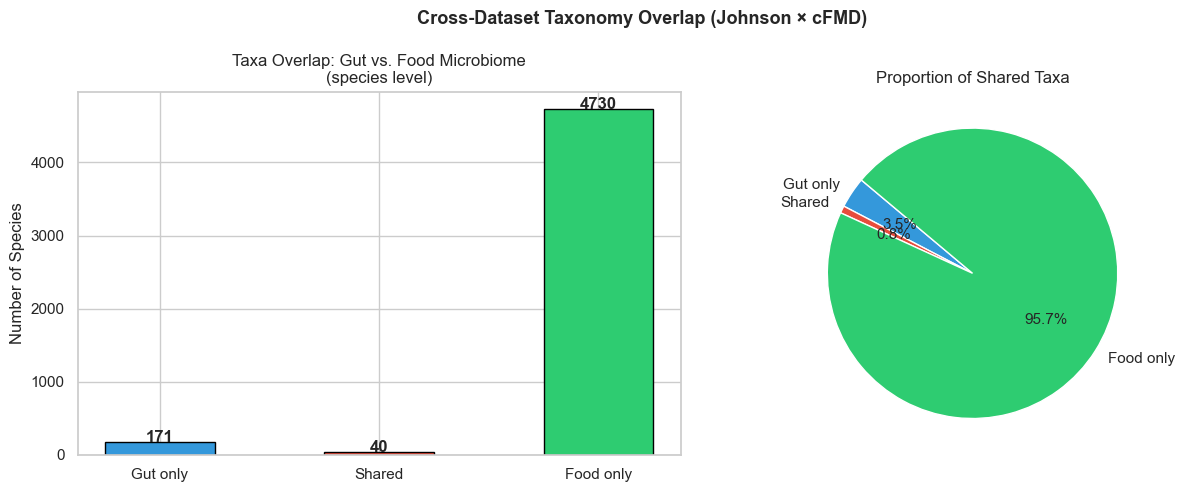

In [25]:
# ── Venn-style bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
labels = ["Gut only", "Shared", "Food only"]
values = [len(only_gut_species), len(shared_species), len(only_food_species)]
colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars = axes[0].bar(labels, values, color=colors, edgecolor="black", width=0.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Taxa Overlap: Gut vs. Food Microbiome\n(species level)")
axes[0].set_ylabel("Number of Species")

# Pie chart
axes[1].pie(values, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=140, textprops={"fontsize": 11})
axes[1].set_title("Proportion of Shared Taxa")

plt.suptitle("Cross-Dataset Taxonomy Overlap (Johnson × cFMD)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 6 – Unified Taxonomy Table

Build a master taxonomy reference table listing every unique taxon from both datasets,
with a flag indicating in which dataset(s) it appears.


In [26]:
# ── Gut taxonomy with source flag ────────────────────────────────────────────────
gut_tax_flagged  = gut_taxonomy_df.copy()
gut_tax_flagged["in_gut_microbiome"]  = True
gut_tax_flagged["in_food_microbiome"] = gut_tax_flagged["clean_species"].isin(food_species_set)
gut_tax_flagged["source"] = "johnson_gut"

# ── Food taxonomy with source flag ───────────────────────────────────────────────
food_tax_flagged = food_taxonomy_df.copy()
food_tax_flagged["in_gut_microbiome"]  = food_tax_flagged["clean_species"].isin(gut_species_set)
food_tax_flagged["in_food_microbiome"] = True
food_tax_flagged["source"] = "cfmd_food"

# ── Concatenate ──────────────────────────────────────────────────────────────────
unified_taxonomy_table = pd.concat(
    [gut_tax_flagged.reset_index(), food_tax_flagged.reset_index()],
    ignore_index=True, sort=False
)

print(f"Unified taxonomy table: {unified_taxonomy_table.shape}")
display(unified_taxonomy_table.head(5))

unified_taxonomy_table.to_csv(DATA_DIR / "unified_taxonomy_table.csv", index=False)
print("\nSaved: unified_taxonomy_table.csv")


Unified taxonomy table: (5280, 12)


,original_taxon,kingdom,phylum,class,order,family,genus,species,clean_species,in_gut_microbiome,in_food_microbiome,source
0,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,NaN,bacteroides,True,False,johnson_gut
1,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clo...,Bacteria,Firmicutes,Clostridia,Clostridiales,Ruminococcaceae,Faecalibacterium,Faecalibacterium prausnitzii,faecalibacterium_prausnitzii,True,True,johnson_gut
2,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,Bacteroides uniformis,bacteroides_uniformis,True,True,johnson_gut
3,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotella,Prevotella copri,prevotella_copri,True,False,johnson_gut
4,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,Bacteria,Bacteroidetes,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,Alistipes putredinis,alistipes_putredinis,True,True,johnson_gut



Saved: unified_taxonomy_table.csv


---
## Section 7 – Long-Format Abundance Tables

Convert both wide matrices (taxa × samples) to long format (one row per taxon-sample pair).
This format is optimal for statistical modelling and merging.


In [27]:
# ── Gut microbiome → long format ────────────────────────────────────────────────
gut_micro_filtered_clean = gut_micro_filtered.copy()
gut_micro_filtered_clean.index.name = "original_taxon"

# Add clean species label
gut_micro_filtered_clean["clean_species"] = gut_taxonomy_df["clean_species"]

gut_long = (
    gut_micro_filtered_clean
    .reset_index()
    .melt(id_vars=["original_taxon", "clean_species"],
          var_name="sample_id",
          value_name="relative_abundance")
)
gut_long["source"] = "johnson_gut"

# Drop zero-abundance rows to save memory
gut_long = gut_long[gut_long["relative_abundance"] > 0].reset_index(drop=True)

print(f"Gut microbiome long format : {gut_long.shape}")
display(gut_long.head(3))
gut_long.to_csv(DATA_DIR / "gut_microbiome_long.csv", index=False)
print("Saved: gut_microbiome_long.csv")


Gut microbiome long format : (98242, 5)


,original_taxon,clean_species,sample_id,relative_abundance,source
0,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,bacteroides,MCT.f.0002,79055,johnson_gut
1,k__Bacteria;p__Firmicutes;c__Clostridia;o__Clo...,faecalibacterium_prausnitzii,MCT.f.0002,2421,johnson_gut
2,k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o_...,bacteroides_uniformis,MCT.f.0002,39779,johnson_gut


Saved: gut_microbiome_long.csv


In [28]:
# ── Food microbiome → long format ───────────────────────────────────────────────
food_micro_clean = food_micro_abundance.copy()
food_micro_clean.index.name = "original_taxon"

# Add clean species label
food_micro_clean["clean_species"] = food_taxonomy_df["clean_species"]

food_long = (
    food_micro_clean
    .reset_index()
    .melt(id_vars=["original_taxon", "clean_species"],
          var_name="full_sample_id",
          value_name="relative_abundance")
)

# Extract short sample_id (strip StudyName__ prefix)
food_long["sample_id"] = food_long["full_sample_id"].str.split("__").str[-1]
food_long = food_long.drop(columns="full_sample_id")
food_long["source"] = "cfmd_food"

# Merge food category from metadata
food_long = food_long.merge(
    cfmd_sample_meta[["sample_id", "category", "macrocategory", "country"]],
    on="sample_id", how="left"
)

# Drop zeros
food_long = food_long[food_long["relative_abundance"] > 0].reset_index(drop=True)

print(f"Food microbiome long format : {food_long.shape}")
display(food_long.head(3))
food_long.to_csv(DATA_DIR / "food_microbiome_long.csv", index=False)
print("Saved: food_microbiome_long.csv")


Food microbiome long format : (94491, 8)


,original_taxon,clean_species,relative_abundance,sample_id,source,category,macrocategory,country
0,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,lactococcus_lactis,0.1411,SRR8742576,cfmd_food,fermented_seeds,food,BRA
1,k__Bacteria|p__Pseudomonadota|c__Gammaproteoba...,pantoea_coffeiphila,0.1039,SRR8742576,cfmd_food,fermented_seeds,food,BRA
2,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,limosilactobacillus_fermentum,14.7489,SRR8742576,cfmd_food,fermented_seeds,food,BRA


Saved: food_microbiome_long.csv


---
## Section 8 – Merged Abundance Matrix for Shared Taxa

Build a merged abundance matrix containing **only taxa found in both datasets**.
- Rows = shared taxa (clean_species)
- Columns = gut samples + food samples
- Values = relative abundance

This is the core matrix for comparing food-derived vs. gut microbiome profiles.


In [29]:
# ── Subset gut matrix to shared taxa ────────────────────────────────────────────
gut_tax_map   = gut_taxonomy_df["clean_species"].to_dict()   # original_taxon → clean_species
food_tax_map  = food_taxonomy_df["clean_species"].to_dict()

# Gut: reindex rows by clean_species
gut_for_merge = gut_micro_filtered.copy()
gut_for_merge.index = gut_for_merge.index.map(gut_tax_map)
gut_for_merge = (
    gut_for_merge[gut_for_merge.index.isin(shared_species)]
    .groupby(level=0).mean()       # average if same clean_species maps to multiple rows
)

# Food: reindex rows by clean_species
food_for_merge = food_micro_abundance.copy()
food_for_merge.index = food_for_merge.index.map(food_tax_map)
food_for_merge = (
    food_for_merge[food_for_merge.index.isin(shared_species)]
    .groupby(level=0).mean()
)

# Rename columns to avoid collision
gut_for_merge.columns  = ["gut__"  + c for c in gut_for_merge.columns]
food_for_merge.columns = ["food__" + c for c in food_for_merge.columns]

# Merge on shared taxa (inner join on index)
merged_shared_taxa = gut_for_merge.join(food_for_merge, how="inner")
merged_shared_taxa.index.name = "clean_species"

print(f"Merged shared taxa matrix: {merged_shared_taxa.shape}")
print(f"  Shared taxa (rows)     : {merged_shared_taxa.shape[0]}")
print(f"  Gut sample columns     : {gut_for_merge.shape[1]}")
print(f"  Food sample columns    : {food_for_merge.shape[1]}")
display(merged_shared_taxa.iloc[:5, :6])

merged_shared_taxa.to_csv(DATA_DIR / "merged_shared_taxa.csv")
print("\nSaved: merged_shared_taxa.csv")


Merged shared taxa matrix: (40, 3876)
  Shared taxa (rows)     : 40
  Gut sample columns     : 483
  Food sample columns    : 3393


,gut__MCT.f.0002,gut__MCT.f.0003,gut__MCT.f.0004,gut__MCT.f.0005,gut__MCT.f.0006,gut__MCT.f.0007
clean_species,,,,,,
,1272.1538,2616.3846,1291.6154,1232.9231,1317.8462,1266.3077
akkermansia_muciniphila,79.0000,63.0000,135.0000,10.0000,22.0000,35.0000
alistipes_finegoldii,3554.0000,129.0000,2160.0000,1952.0000,1467.0000,1609.0000
alistipes_onderdonkii,3723.0000,111.0000,1993.0000,2818.0000,1804.0000,2479.0000
alistipes_putredinis,18393.0000,561.0000,11742.0000,15831.0000,14319.0000,16541.0000



Saved: merged_shared_taxa.csv


---
## Section 9 – Integration Summary

### Files produced by this notebook

| File | Rows | Description |
|------|------|-------------|
| `unified_sample_metadata.csv` | 566 gut + 3,444 food | All sample metadata from both sources |
| `unified_taxonomy_table.csv` | gut + food taxa | Full taxonomy with cross-dataset flags |
| `gut_microbiome_long.csv` | non-zero entries | Gut microbiome in long format |
| `food_microbiome_long.csv` | non-zero entries | cFMD food microbiome in long format |
| `merged_shared_taxa.csv` | shared taxa | Abundance matrix for taxa found in both datasets |

### Next steps
- Use `merged_shared_taxa.csv` to compare gut vs. food abundance profiles for shared taxa
- Use `unified_sample_metadata.csv` as a lookup for participant/food metadata in all analyses
- Feed `merged_shared_taxa.csv` into the FME analysis notebook for weight derivation


In [30]:
# ── Final summary printout ───────────────────────────────────────────────────────
outputs = {
    "unified_sample_metadata.csv" : unified_sample_metadata,
    "unified_taxonomy_table.csv"  : unified_taxonomy_table,
    "gut_microbiome_long.csv"     : gut_long,
    "food_microbiome_long.csv"    : food_long,
    "merged_shared_taxa.csv"      : merged_shared_taxa,
}

print("=" * 55)
print(f"{'File':<35} {'Shape':>12}")
print("=" * 55)
for fname, df in outputs.items():
    print(f"  {fname:<33} {str(df.shape):>12}")
print("=" * 55)
print(f"\nShared taxa between gut and food microbiome: {len(shared_species)}")
print(f"Gut-only taxa  : {len(only_gut_species)}")
print(f"Food-only taxa : {len(only_food_species)}")


File                                       Shape
  unified_sample_metadata.csv         (4010, 11)
  unified_taxonomy_table.csv          (5280, 12)
  gut_microbiome_long.csv             (98242, 5)
  food_microbiome_long.csv            (94491, 8)
  merged_shared_taxa.csv              (40, 3876)

Shared taxa between gut and food microbiome: 40
Gut-only taxa  : 171
Food-only taxa : 4730


# Notebook: `Additional_Merges.ipynb`

# Additional Merges: Food × Gut Microbiome Analysis
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### This notebook contains 4 additional merge strategies:

| Merge | Question answered |
|-------|-------------------|
| **1 – Shared taxa matrix** | Which food-associated microbes also appear in the gut? |
| **2 – Temporal FME × gut stability** | Does cumulative food microbe exposure predict gut stability over time? |
| **3 – Fermented vs. non-fermented** | Does fermented food exposure drive different gut outcomes than non-fermented? |
| **4 – FME quartile × beta diversity** | Do high-FME participants cluster differently in PCA space? |

> **Prerequisite:** Run `Central_Merge.ipynb` first and ensure `central_merged.csv` and `fme_sample_scores.csv` exist in the working directory.


---
## Section 1 – Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu, kruskal
from scipy.spatial.distance import braycurtis

pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


Libraries loaded.


In [2]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


In [4]:
# ── Load all source files ──────────────────────────────────────────────────────
gut_microbiome   = pd.read_csv(DATA_DIR / "microbiome_filtered.csv", index_col=0)
gut_micro_clr    = pd.read_csv(DATA_DIR / "microbiome_clr.csv",      index_col=0)
sample_metadata  = pd.read_csv(DATA_DIR / "sample_meta.csv",         index_col=0)
cfmd_metadata    = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")
cfmd_abundance   = pd.read_csv(DATA_DIR / "combined_datasets.csv",   index_col=0, low_memory=False)
cfmd_abundance   = cfmd_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)
diet_consumption = pd.read_csv(DATA_DIR / "diet_raw.csv",            index_col=0)

# ── Load outputs from Central_Merge.ipynb ─────────────────────────────────────
central_merged   = pd.read_csv(DATA_DIR / "central_merged.csv",      index_col=0)
fme_scores       = pd.read_csv(DATA_DIR / "fme_sample_scores.csv",   index_col=0)

# Core sample set (has both gut microbiome and diet record)
SAMPLE_COL_PREFIX = "MCT.f."
core_sample_ids   = sorted(
    set(gut_microbiome.columns) &
    set(c for c in diet_consumption.columns if c.startswith(SAMPLE_COL_PREFIX))
)

print("Files loaded:")
for name, df in [
    ("gut_microbiome",  gut_microbiome),
    ("gut_micro_clr",   gut_micro_clr),
    ("cfmd_abundance",  cfmd_abundance),
    ("central_merged",  central_merged),
    ("fme_scores",      fme_scores),
]:
    print(f"  {name:<20} {str(df.shape)}")
print(f"\nCore analytical samples: {len(core_sample_ids)}")


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\linoy\\Documents\\proj3\\Gut-Microbiome-Project_year3\\data\\central_merged.csv'

---
## Merge 1 – Shared Taxa Matrix
### Question: Which food-associated microbes also appear in the gut?

**Method:**
- Parse species-level names from both gut (`microbiome_filtered`) and food (`combined_datasets`) taxonomy strings
- Find the intersection (shared species)
- Build a matrix: shared taxa × all samples (gut + food), enabling direct abundance comparison

**Why it matters:** Shared taxa are the candidates for food-to-gut microbial transmission — the biological mechanism underlying the research question.


In [ ]:
# ── Taxonomy parsers ──────────────────────────────────────────────────────────
def clean_gut_species(tax_string):
    """Extract clean species/genus name from semicolon-delimited gut taxonomy."""
    parts = str(tax_string).split(";")
    for part in reversed(parts):
        part = part.strip()
        val  = part.replace("s__","").replace("g__","").replace("f__","").strip()
        if val and val != "NA" and not val.startswith("k__") and not val.startswith("p__"):
            return val.lower().replace(" ", "_")
    return None

def clean_food_species(tax_string):
    """Extract clean species/genus name from pipe-delimited cFMD taxonomy (skip t__ strain level)."""
    parts = str(tax_string).split("|")
    for part in reversed(parts):
        part = part.strip()
        if part.startswith("t__"):
            continue
        val = part.replace("s__","").replace("g__","").strip()
        if val and not val.startswith("k__") and not val.startswith("p__"):
            return val.lower().replace(" ", "_")
    return None

# ── Build species maps for both datasets ──────────────────────────────────────
gut_species_map  = {t: clean_gut_species(t)  for t in gut_microbiome.index}
food_species_map = {t: clean_food_species(t) for t in cfmd_abundance.index}

gut_species_set  = set(v for v in gut_species_map.values()  if v)
food_species_set = set(v for v in food_species_map.values() if v)
shared_species   = gut_species_set & food_species_set

print(f"Gut unique species   : {len(gut_species_set)}")
print(f"Food unique species  : {len(food_species_set)}")
print(f"Shared species       : {len(shared_species)}")
print(f"Overlap %            : {100*len(shared_species)/len(gut_species_set):.1f}% of gut taxa found in food")
print()
print("Top shared species (first 20):")
for s in sorted(shared_species)[:20]:
    print(f"  {s}")


In [ ]:
# ── Build shared taxa abundance matrix ────────────────────────────────────────

# Gut: reindex by clean species, keep core samples only
gut_for_shared = gut_microbiome[core_sample_ids].copy()
gut_for_shared.index = gut_for_shared.index.map(gut_species_map)
gut_for_shared = (
    gut_for_shared[gut_for_shared.index.isin(shared_species)]
    .groupby(level=0).mean()
)

# Food: reindex by clean species
food_for_shared = cfmd_abundance.copy()
food_for_shared.index = food_for_shared.index.map(food_species_map)
food_for_shared = (
    food_for_shared[food_for_shared.index.isin(shared_species)]
    .groupby(level=0).mean()
)

# Rename columns to distinguish sources
gut_for_shared.columns  = ["gut__"  + c for c in gut_for_shared.columns]
food_for_shared.columns = ["food__" + c for c in food_for_shared.columns]

# Merge on shared taxa
shared_taxa_matrix = gut_for_shared.join(food_for_shared, how="inner")
shared_taxa_matrix.index.name = "species"

print(f"Shared taxa matrix: {shared_taxa_matrix.shape}")
print(f"  Shared taxa (rows) : {shared_taxa_matrix.shape[0]}")
print(f"  Gut columns        : {gut_for_shared.shape[1]}")
print(f"  Food columns       : {food_for_shared.shape[1]}")

shared_taxa_matrix.to_csv(DATA_DIR / "shared_taxa_matrix.csv")
print("\nSaved: shared_taxa_matrix.csv")


In [ ]:
# ── Visualize: mean gut vs. mean food abundance for shared taxa ───────────────
gut_cols  = [c for c in shared_taxa_matrix.columns if c.startswith("gut__")]
food_cols = [c for c in shared_taxa_matrix.columns if c.startswith("food__")]

mean_gut_abund  = shared_taxa_matrix[gut_cols].mean(axis=1)
mean_food_abund = shared_taxa_matrix[food_cols].mean(axis=1)

comparison_df = pd.DataFrame({
    "mean_gut_abundance" : mean_gut_abund,
    "mean_food_abundance": mean_food_abund,
    "species"            : shared_taxa_matrix.index,
}).sort_values("mean_gut_abundance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 shared taxa by gut abundance
top20 = comparison_df.head(20)
axes[0].barh(top20["species"][::-1], top20["mean_gut_abundance"][::-1],
             color="steelblue", edgecolor="none")
axes[0].set_title("Top 20 Shared Taxa\n(by mean gut abundance)")
axes[0].set_xlabel("Mean Relative Abundance (gut)")

# Scatter: gut abundance vs. food abundance
axes[1].scatter(comparison_df["mean_food_abundance"],
                comparison_df["mean_gut_abundance"],
                alpha=0.6, s=30, c="teal", edgecolors="none")
axes[1].set_xlabel("Mean Abundance in Food (cFMD)")
axes[1].set_ylabel("Mean Abundance in Gut")
axes[1].set_title("Shared Taxa:\nFood Abundance vs. Gut Abundance")

plt.suptitle("Merge 1: Shared Taxa — Food × Gut Microbiome", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Merge 2 – Temporal FME × Gut Stability
### Question: Does cumulative food microbe exposure predict gut stability over time?

**Method:**
- For each participant, align FME scores with gut microbiome samples along the study timeline (days 1–17)
- Compute rolling 3-day cumulative FME exposure
- Compute gut microbiome stability as sample-to-sample Bray-Curtis dissimilarity between consecutive time points
- Merge into a longitudinal table: one row per consecutive sample pair

**Why it matters:** If food microbe exposure stabilizes the gut microbiome, we expect lower gut dissimilarity on days following high-FME dietary periods.


In [5]:
# ── Build longitudinal table: sample × study_day × participant ────────────────
longitudinal_df = (
    central_merged[["participant_id", "StudyDayNo",
                    "fme_total", "fme_fermented", "fme_nonfermented",
                    "shannon_diversity", "KCAL", "FIBE"]]
    .dropna(subset=["participant_id", "StudyDayNo", "fme_total"])
    .copy()
)
longitudinal_df["StudyDayNo"] = pd.to_numeric(longitudinal_df["StudyDayNo"], errors="coerce")
longitudinal_df = longitudinal_df.sort_values(["participant_id", "StudyDayNo"])
longitudinal_df.index.name = "sample_id"
longitudinal_df = longitudinal_df.reset_index()

print(f"Longitudinal table: {longitudinal_df.shape}")
display(longitudinal_df.head(6))


NameError: name 'central_merged' is not defined

In [ ]:
# ── Compute rolling 3-day cumulative FME per participant ──────────────────────
longitudinal_df["fme_rolling3"] = (
    longitudinal_df
    .groupby("participant_id")["fme_total"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# ── Compute Bray-Curtis dissimilarity between consecutive gut samples ──────────
gut_norm = gut_microbiome[core_sample_ids].apply(
    lambda col: col / col.sum() if col.sum() > 0 else col, axis=0
)

bc_records = []
for participant, group in longitudinal_df.groupby("participant_id"):
    group = group.sort_values("StudyDayNo")
    sample_ids = group["sample_id"].tolist()

    for i in range(len(sample_ids) - 1):
        s1, s2 = sample_ids[i], sample_ids[i+1]
        if s1 in gut_norm.columns and s2 in gut_norm.columns:
            v1 = gut_norm[s1].values
            v2 = gut_norm[s2].values
            bc = braycurtis(v1, v2)
            day1 = group.loc[group["sample_id"] == s1, "StudyDayNo"].values[0]
            day2 = group.loc[group["sample_id"] == s2, "StudyDayNo"].values[0]
            bc_records.append({
                "participant_id"   : participant,
                "sample_id_t1"     : s1,
                "sample_id_t2"     : s2,
                "study_day_t1"     : day1,
                "study_day_t2"     : day2,
                "bray_curtis_dissim": bc,
            })

bc_df = pd.DataFrame(bc_records)
print(f"Consecutive sample pairs with BC dissimilarity: {len(bc_df)}")
display(bc_df.head(5))


In [ ]:
# ── Merge BC dissimilarity with FME at t1 ────────────────────────────────────
temporal_merge = bc_df.merge(
    longitudinal_df[["sample_id","participant_id","StudyDayNo",
                     "fme_total","fme_rolling3","fme_fermented",
                     "fme_nonfermented","shannon_diversity","KCAL","FIBE"]]
    .rename(columns={
        "sample_id"       : "sample_id_t1",
        "StudyDayNo"      : "study_day_t1_check",
        "shannon_diversity": "shannon_t1",
        "fme_total"       : "fme_at_t1",
        "fme_rolling3"    : "fme_rolling3_at_t1",
        "fme_fermented"   : "fme_ferm_at_t1",
        "fme_nonfermented": "fme_nonferm_at_t1",
    }),
    on=["sample_id_t1","participant_id"],
    how="left"
)

print(f"Temporal merge table: {temporal_merge.shape}")
print(f"BC dissim range: {temporal_merge['bray_curtis_dissim'].min():.3f} – {temporal_merge['bray_curtis_dissim'].max():.3f}")

temporal_merge.to_csv(DATA_DIR / "temporal_fme_stability.csv", index=False)
print("Saved: temporal_fme_stability.csv")


In [ ]:
# ── Visualize: FME (rolling 3-day) vs Bray-Curtis dissimilarity ──────────────
plot_df = temporal_merge.dropna(subset=["fme_rolling3_at_t1","bray_curtis_dissim"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: rolling FME vs next-day gut dissimilarity
axes[0].scatter(plot_df["fme_rolling3_at_t1"], plot_df["bray_curtis_dissim"],
                alpha=0.4, s=25, c="darkorange", edgecolors="none")
if len(plot_df) > 2:
    z = np.polyfit(plot_df["fme_rolling3_at_t1"], plot_df["bray_curtis_dissim"], 1)
    x_line = np.linspace(plot_df["fme_rolling3_at_t1"].min(),
                         plot_df["fme_rolling3_at_t1"].max(), 100)
    axes[0].plot(x_line, np.poly1d(z)(x_line), "r--", lw=1.5, label="Trend")
axes[0].set_title("Rolling 3-day FME vs. Gut Dissimilarity\n(consecutive sample pairs)")
axes[0].set_xlabel("Rolling 3-day Mean FME Score")
axes[0].set_ylabel("Bray-Curtis Dissimilarity (t → t+1)")
axes[0].legend()

# Timeline: mean FME and mean BC dissimilarity by study day
day_summary = (
    temporal_merge
    .groupby("study_day_t1")
    .agg(mean_fme=("fme_at_t1","mean"), mean_bc=("bray_curtis_dissim","mean"))
    .dropna()
)
ax2 = axes[1]
ax2b = ax2.twinx()
ax2.bar(day_summary.index, day_summary["mean_fme"], color="steelblue",
        alpha=0.5, label="Mean FME")
ax2b.plot(day_summary.index, day_summary["mean_bc"], color="red",
          marker="o", markersize=4, linewidth=1.5, label="Mean BC dissim")
ax2.set_xlabel("Study Day")
ax2.set_ylabel("Mean FME Score", color="steelblue")
ax2b.set_ylabel("Mean Bray-Curtis Dissimilarity", color="red")
ax2.set_title("FME and Gut Instability Over Study Timeline")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc="upper right", fontsize=9)

plt.suptitle("Merge 2: Temporal FME × Gut Stability", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Merge 3 – Fermented vs. Non-Fermented Food Exposure
### Question: Does fermented food drive different gut outcomes than non-fermented food?

**Method:**
- Split FME scores by fermentation status using the `fermented/non-fermented` column in cFMD metadata
- Build a participant-level table with separate FME scores for fermented (F) and non-fermented (NF) foods
- Compare gut alpha diversity and stability between participants with high fermented-FME vs. high non-fermented-FME

**Why it matters:** Fermented foods carry live microbes that may actively colonize the gut, while non-fermented foods carry environmental microbes. The biological pathway differs — and the effect on the gut microbiome may differ too.


In [6]:
# ── Build participant-level fermented/non-fermented FME summary ──────────────
ferm_merge = central_merged[
    ["participant_id", "StudyDayNo",
     "fme_total", "fme_fermented", "fme_nonfermented",
     "shannon_diversity", "Age", "BMI", "Gender",
     "KCAL", "FIBE", "D_YOGURT", "D_CHEESE"]
].dropna(subset=["participant_id","fme_fermented","fme_nonfermented"]).copy()

# Participant-level aggregation
participant_ferm = (
    ferm_merge.groupby("participant_id")
    .agg(
        fme_total_mean       = ("fme_total",         "mean"),
        fme_fermented_mean   = ("fme_fermented",      "mean"),
        fme_nonfermented_mean= ("fme_nonfermented",   "mean"),
        shannon_mean         = ("shannon_diversity",   "mean"),
        shannon_std          = ("shannon_diversity",   "std"),
        Age                  = ("Age",                "first"),
        BMI                  = ("BMI",                "first"),
        Gender               = ("Gender",             "first"),
        KCAL_mean            = ("KCAL",               "mean"),
        FIBE_mean            = ("FIBE",               "mean"),
        n_samples            = ("fme_total",          "count"),
    )
    .reset_index()
)

# Stability = CV of shannon diversity
participant_ferm["shannon_cv"] = (
    participant_ferm["shannon_std"] / participant_ferm["shannon_mean"]
)

# Fermented FME fraction
participant_ferm["fme_ferm_fraction"] = (
    participant_ferm["fme_fermented_mean"] /
    (participant_ferm["fme_total_mean"] + 1e-9)
)

print(f"Participants in fermented merge: {len(participant_ferm)}")
display(participant_ferm.head(5))


NameError: name 'central_merged' is not defined

In [ ]:
# ── Split participants into high/low fermented FME groups ─────────────────────
ferm_median = participant_ferm["fme_fermented_mean"].median()
nonferm_median = participant_ferm["fme_nonfermented_mean"].median()

participant_ferm["fme_ferm_group"]    = np.where(
    participant_ferm["fme_fermented_mean"]    >= ferm_median,    "high_fermented", "low_fermented")
participant_ferm["fme_nonferm_group"] = np.where(
    participant_ferm["fme_nonfermented_mean"] >= nonferm_median, "high_nonfermented", "low_nonfermented")

# Statistical test: Mann-Whitney U
high_f  = participant_ferm.loc[participant_ferm["fme_ferm_group"]=="high_fermented",  "shannon_mean"].dropna()
low_f   = participant_ferm.loc[participant_ferm["fme_ferm_group"]=="low_fermented",   "shannon_mean"].dropna()
high_nf = participant_ferm.loc[participant_ferm["fme_nonferm_group"]=="high_nonfermented","shannon_mean"].dropna()
low_nf  = participant_ferm.loc[participant_ferm["fme_nonferm_group"]=="low_nonfermented", "shannon_mean"].dropna()

stat_f,  p_f  = mannwhitneyu(high_f,  low_f,  alternative="two-sided") if len(high_f)>1  and len(low_f)>1  else (np.nan, np.nan)
stat_nf, p_nf = mannwhitneyu(high_nf, low_nf, alternative="two-sided") if len(high_nf)>1 and len(low_nf)>1 else (np.nan, np.nan)

print(f"Fermented FME   — high vs. low → Shannon diversity: U={stat_f:.1f}, p={p_f:.4f}")
print(f"Non-fermented FME — high vs. low → Shannon diversity: U={stat_nf:.1f}, p={p_nf:.4f}")

participant_ferm.to_csv(DATA_DIR / "fermented_nonfermented_merge.csv", index=False)
print("\nSaved: fermented_nonfermented_merge.csv")


In [ ]:
# ── Visualize: fermented vs. non-fermented FME impact on gut diversity ────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette = {"high_fermented":"#2ecc71","low_fermented":"#95a5a6",
           "high_nonfermented":"#e74c3c","low_nonfermented":"#bdc3c7"}

# Boxplot: fermented FME group vs Shannon
groups_f = [
    participant_ferm.loc[participant_ferm["fme_ferm_group"]=="high_fermented", "shannon_mean"].dropna(),
    participant_ferm.loc[participant_ferm["fme_ferm_group"]=="low_fermented",  "shannon_mean"].dropna(),
]
axes[0].boxplot(groups_f, labels=["High fermented FME","Low fermented FME"], patch_artist=True,
                boxprops=dict(facecolor="#2ecc71", alpha=0.6))
axes[0].set_title(f"Fermented FME vs. Gut Diversity\n(p={p_f:.3f})")
axes[0].set_ylabel("Mean Shannon Diversity")

# Boxplot: non-fermented FME group vs Shannon
groups_nf = [
    participant_ferm.loc[participant_ferm["fme_nonferm_group"]=="high_nonfermented","shannon_mean"].dropna(),
    participant_ferm.loc[participant_ferm["fme_nonferm_group"]=="low_nonfermented", "shannon_mean"].dropna(),
]
axes[1].boxplot(groups_nf, labels=["High non-ferm FME","Low non-ferm FME"], patch_artist=True,
                boxprops=dict(facecolor="#e74c3c", alpha=0.6))
axes[1].set_title(f"Non-fermented FME vs. Gut Diversity\n(p={p_nf:.3f})")
axes[1].set_ylabel("Mean Shannon Diversity")

# Scatter: fermented FME vs non-fermented FME (coloured by shannon)
sc = axes[2].scatter(
    participant_ferm["fme_fermented_mean"],
    participant_ferm["fme_nonfermented_mean"],
    c=participant_ferm["shannon_mean"], cmap="RdYlGn", s=80,
    edgecolors="white", linewidths=0.5, vmin=2, vmax=4
)
plt.colorbar(sc, ax=axes[2], label="Mean Shannon Diversity")
axes[2].set_xlabel("Mean Fermented FME")
axes[2].set_ylabel("Mean Non-Fermented FME")
axes[2].set_title("Fermented vs. Non-Fermented FME\n(colour = gut diversity)")

plt.suptitle("Merge 3: Fermented vs. Non-Fermented Food Exposure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Merge 4 – FME Quartile × Beta Diversity (PCA)
### Question: Do high-FME participants cluster differently in microbiome composition space?

**Method:**
- Assign each sample to an FME quartile (Q1=lowest, Q4=highest food microbe exposure)
- Run PCA on CLR-transformed gut microbiome profiles (beta diversity)
- Plot samples colored by FME quartile
- Test whether FME quartile groups separate in PCA space

**Why it matters:** If food microbe exposure shapes gut microbiome composition, high-FME and low-FME samples should occupy different regions of the composition space.


In [7]:
# ── Assign FME quartiles to core samples ──────────────────────────────────────
fme_quartile_df = (
    central_merged[["participant_id","fme_total","StudyDayNo"]]
    .dropna(subset=["fme_total"])
    .copy()
)
fme_quartile_df.index.name = "sample_id"
fme_quartile_df = fme_quartile_df.reset_index()

fme_quartile_df["fme_quartile"] = pd.qcut(
    fme_quartile_df["fme_total"], q=4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

print("FME quartile distribution:")
print(fme_quartile_df["fme_quartile"].value_counts().sort_index())
print()
print(f"FME quartile thresholds:")
print(pd.qcut(fme_quartile_df["fme_total"], q=4).unique().sort_values())


NameError: name 'central_merged' is not defined

In [ ]:
# ── Run PCA on CLR-transformed gut microbiome ─────────────────────────────────
# Subset CLR matrix to samples that have FME quartile assigned
pca_samples = [s for s in fme_quartile_df["sample_id"].tolist()
               if s in gut_micro_clr.columns]

clr_matrix = (
    gut_micro_clr[pca_samples]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .T   # samples as rows for PCA
)

# PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(clr_matrix)
explained  = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "sample_id": pca_samples,
    "PC1"      : pca_coords[:, 0],
    "PC2"      : pca_coords[:, 1],
})

# Merge with FME quartile labels
pca_df = pca_df.merge(
    fme_quartile_df[["sample_id","fme_quartile","fme_total","participant_id"]],
    on="sample_id", how="left"
)

print(f"PCA computed for {len(pca_df)} samples")
print(f"PC1: {explained[0]:.1f}%  |  PC2: {explained[1]:.1f}%")

pca_df.to_csv(DATA_DIR / "fme_quartile_pca.csv", index=False)
print("Saved: fme_quartile_pca.csv")


In [ ]:
# ── Visualize PCA coloured by FME quartile ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

quartile_colors = {
    "Q1 (lowest)" : "#3498db",
    "Q2"          : "#2ecc71",
    "Q3"          : "#f39c12",
    "Q4 (highest)": "#e74c3c",
}

# PCA scatter coloured by FME quartile
for quartile, color in quartile_colors.items():
    mask = pca_df["fme_quartile"] == quartile
    axes[0].scatter(
        pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
        c=color, label=quartile, alpha=0.7, s=40, edgecolors="white", linewidths=0.3
    )
axes[0].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[0].set_title("Beta Diversity PCA — Colored by FME Quartile")
axes[0].legend(title="FME Quartile", fontsize=9)

# Boxplot: PC1 score by FME quartile
quartile_order = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
pc1_by_quartile = [
    pca_df.loc[pca_df["fme_quartile"] == q, "PC1"].dropna().values
    for q in quartile_order
]
bp = axes[1].boxplot(pc1_by_quartile, labels=quartile_order, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], quartile_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("PC1 Score by FME Quartile\n(PC1 captures main composition axis)")
axes[1].set_xlabel("FME Quartile")
axes[1].set_ylabel("PC1 Score")
axes[1].tick_params(axis='x', rotation=20)

# Kruskal-Wallis test across quartiles
valid_groups = [g for g in pc1_by_quartile if len(g) > 1]
if len(valid_groups) >= 2:
    stat_kw, p_kw = kruskal(*valid_groups)
    axes[1].text(0.98, 0.02, f"Kruskal-Wallis p={p_kw:.4f}",
                 transform=axes[1].transAxes, ha="right", fontsize=9,
                 color="darkred" if p_kw < 0.05 else "gray")

plt.suptitle("Merge 4: FME Quartile × Beta Diversity (PCA)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Summary of All Merges

| Merge | Output file | Key variable | Used for |
|-------|-------------|--------------|----------|
| 1 – Shared taxa | `shared_taxa_matrix.csv` | taxa × (gut+food) samples | Identifying candidate transmission species |
| 2 – Temporal | `temporal_fme_stability.csv` | consecutive sample pairs | Longitudinal FME → gut stability model |
| 3 – Fermented | `fermented_nonfermented_merge.csv` | participant-level | Comparing fermented vs. non-fermented effects |
| 4 – PCA | `fme_quartile_pca.csv` | sample-level PCA coords | Beta diversity × FME exposure groups |

### Recommended statistical models (next notebook)
- **Merge 1** → Fisher's exact test / hypergeometric test on shared taxa prevalence
- **Merge 2** → Linear mixed-effects: `BC_dissim ~ fme_rolling3 + (1|participant_id)`
- **Merge 3** → Mann-Whitney U / linear model: `shannon ~ fme_fermented + fme_nonfermented + covariates`
- **Merge 4** → PERMANOVA on full CLR matrix with FME quartile as grouping variable


# Notebook: `Association_Testing.ipynb`

# Association Testing

## Objective
The goal of this analysis is to investigate the relationship between Food Microbiome Exposure (FME) and gut microbiome characteristics.

Specifically, we examine whether FME is associated with:

- Alpha diversity (Shannon diversity)
- Microbiome stability
- Community composition metrics

This analysis is based on the dataset generated in the FME analysis stage.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings
pd.set_option("display.max_columns", None)

In [ ]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


## Dataset Overview

In this section, we load and inspect the statistical dataset created in the FME analysis step.

The goal is to understand the structure of the dataset, including the number of samples, available variables, data types, and missing values before performing association testing.

In [ ]:
# Load the statistical dataset created in the FME analysis step

df = pd.read_csv(DATA_DIR / "fme_statistical_dataset.csv")

df.head()

,fecal_sample_id,participant_id,study_day,Gender,Age,BMI,Weight,Supplement,Medications,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
0,MCT.f.0002,MCTs01,2,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),67.196133,2.862675,0.049204,3.066187,15,1970.043625,109.619765,53.615264,242.919015,14.419375,74.208114,4300.616500,4.156035,0.646,1.153475,0.00000,3.969,0.9718
1,MCT.f.0003,MCTs01,3,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),81.241247,3.522832,0.049204,3.066187,15,1714.895330,89.992993,50.561373,234.225138,25.996125,67.474665,4225.813250,2.979655,0.646,1.207575,0.00000,0.000,2.9318
2,MCT.f.0004,MCTs01,4,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),126.771107,3.031188,0.049204,3.066187,15,2487.232625,94.611953,92.021551,257.539030,26.178425,83.960308,5329.882125,3.634460,0.000,1.482600,0.00000,0.000,0.9718
3,MCT.f.0005,MCTs01,5,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),31.484626,2.973836,0.049204,3.066187,15,2260.211176,110.268353,95.570253,165.608070,13.011350,64.921966,3527.501416,3.379710,0.000,1.059000,1.81440,0.000,0.9718
4,MCT.f.0006,MCTs01,6,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),61.226577,3.081097,0.049204,3.066187,15,2951.082000,161.817790,108.398516,332.637229,21.529050,119.865677,5428.573000,1.502150,0.000,0.000000,6.29596,0.000,0.4698


In [ ]:
# Dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (475, 27)

Columns:
['fecal_sample_id', 'participant_id', 'study_day', 'Gender', 'Age', 'BMI', 'Weight', 'Supplement', 'Medications', 'fme_score_daily', 'shannon_diversity', 'participant_shannon_cv', 'participant_shannon_mean', 'participant_n_samples', 'KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE', 'SUGR', 'SODI', 'D_TOTAL', 'D_YOGURT', 'D_CHEESE', 'PF_MEAT', 'PF_SEAFD_HI', 'G_WHOLE']


In [ ]:
# Summary statistics

df.describe()

,study_day,Age,BMI,Weight,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000
mean,8.951579,31.152211,23.174737,69.069053,73.325237,2.864593,0.062621,2.864593,14.604211,2110.562806,89.144876,91.512435,229.066013,22.337148,85.219859,3491.564185,1.921608,0.110930,0.993474,1.190717,0.325082,1.263407
std,4.939697,10.156460,3.292062,14.646855,58.307131,0.413157,0.037747,0.368406,2.429422,735.450983,37.394616,40.212887,84.487698,11.600234,43.468122,1629.773797,1.541540,0.271693,1.339567,2.307983,1.576152,1.628686
min,1.000000,19.700000,17.000000,48.500000,0.000000,1.571683,0.020213,1.944592,6.000000,722.552500,15.702908,20.467095,45.046628,3.618000,11.305484,550.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,23.900000,21.100000,59.100000,29.322198,2.610804,0.036472,2.530238,14.000000,1599.179800,62.949223,60.910505,176.968102,14.850000,53.044957,2317.423250,0.664687,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,28.500000,22.900000,66.900000,61.777509,2.964396,0.048859,3.012764,15.000000,2028.168000,85.496863,85.593670,217.000000,19.693800,81.216000,3314.340000,1.650454,0.000000,0.572400,0.000000,0.000000,0.651750
75%,13.000000,37.000000,25.900000,82.900000,104.269671,3.143011,0.079944,3.130106,16.000000,2494.098500,106.259492,116.172395,271.939905,26.711850,110.042055,4310.122600,2.754320,0.000000,1.454882,1.574200,0.000000,2.093600
max,17.000000,61.600000,31.600000,104.800000,331.223987,3.731016,0.179903,3.483381,17.000000,5085.977400,256.499039,242.761818,582.015016,67.501903,261.857405,13884.247300,9.323425,1.665000,9.047425,17.577000,20.769210,9.934594


In [ ]:
print(df.isnull().sum())

fecal_sample_id               0
participant_id                0
study_day                     0
Gender                        0
Age                           0
BMI                           0
Weight                        0
Supplement                    0
Medications                 255
fme_score_daily               0
shannon_diversity             0
participant_shannon_cv        0
participant_shannon_mean      0
participant_n_samples         0
KCAL                          0
PROT                          0
TFAT                          0
CARB                          0
FIBE                          0
SUGR                          0
SODI                          0
D_TOTAL                       0
D_YOGURT                      0
D_CHEESE                      0
PF_MEAT                       0
PF_SEAFD_HI                   0
G_WHOLE                       0
dtype: int64


## Correlation Analysis

In this section, we investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity metrics.

We begin by examining the correlation between the daily FME score and Shannon diversity, which is a commonly used measure of microbiome diversity.

In [ ]:
# Correlation between FME and Shannon Diversity

correlation, p_value = pearsonr(
    df["fme_score_daily"],
    df["shannon_diversity"]
)

print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation: -0.0406
P-value: 0.3776


### Visualization of FME and Shannon Diversity

The following scatter plot illustrates the relationship between daily Food Microbiome Exposure (FME) scores and Shannon diversity values across all samples.

A regression line is added to help visualize the overall trend.

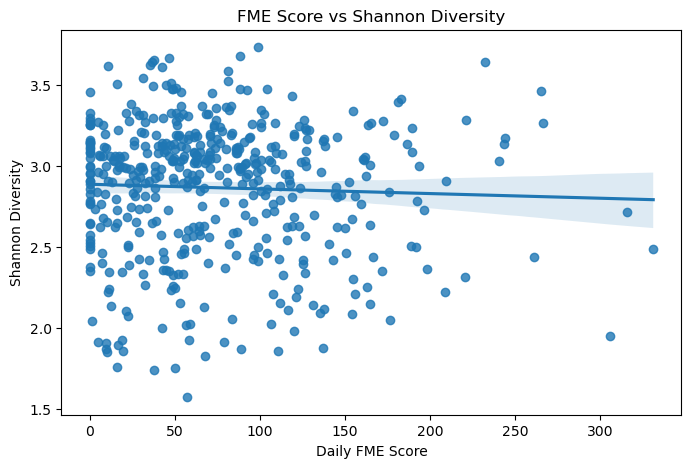

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="fme_score_daily",
    y="shannon_diversity"
)

plt.title("FME Score vs Shannon Diversity")
plt.xlabel("Daily FME Score")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The relationship between FME score and Shannon diversity appears to be weak.

Although FME values vary considerably across samples, Shannon diversity remains relatively stable.

The nearly flat regression line suggests little to no linear association between the two variables.

## Correlation Matrix

To better understand the relationships between microbiome-related variables, we compute a correlation matrix for the main numerical variables used in this analysis.

In [ ]:
correlation_columns = [
    "fme_score_daily",
    "shannon_diversity",
    "participant_shannon_cv",
    "participant_shannon_mean"
]

corr_matrix = df[correlation_columns].corr()

corr_matrix

,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean
fme_score_daily,1.000000,-0.040577,-0.077137,-0.015289
shannon_diversity,-0.040577,1.000000,-0.492850,0.891684
participant_shannon_cv,-0.077137,-0.492850,1.000000,-0.552718
participant_shannon_mean,-0.015289,0.891684,-0.552718,1.000000


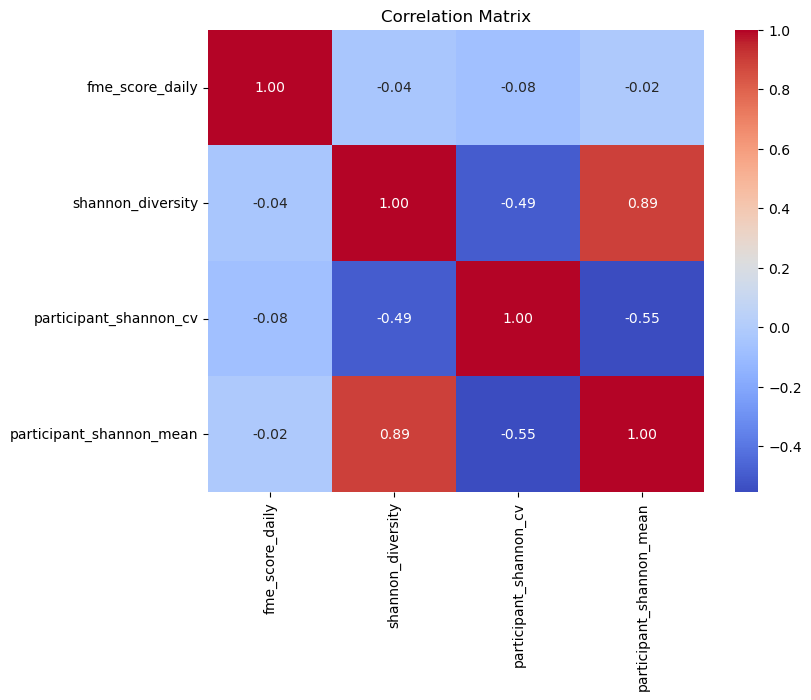

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Insight

FME score has very weak correlations with all diversity metrics.

Shannon diversity is strongly correlated with participant mean Shannon diversity.

## Comparison Between Low and High FME Groups

To further investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity, samples were divided into two groups based on the median FME score.

Shannon diversity distributions were then compared between the groups.

In [ ]:
# Create FME groups based on median value

median_fme = df["fme_score_daily"].median()

df["fme_group"] = np.where(
    df["fme_score_daily"] >= median_fme,
    "High FME",
    "Low FME"
)

df["fme_group"].value_counts()

fme_group
High FME    238
Low FME     237
Name: count, dtype: int64

### Shannon Diversity by FME Group

The following boxplot compares Shannon diversity values between samples with low and high Food Microbiome Exposure.

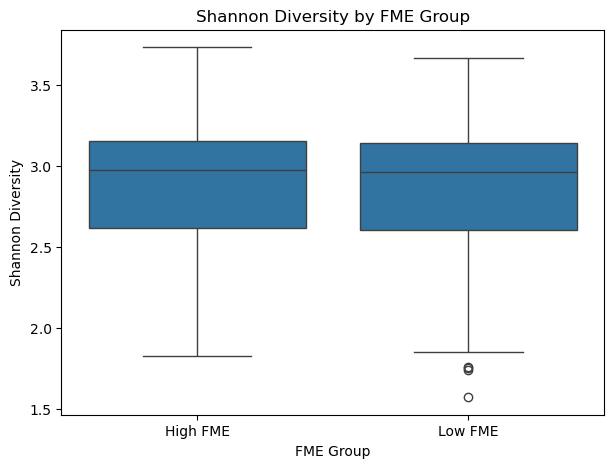

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="fme_group",
    y="shannon_diversity"
)

plt.title("Shannon Diversity by FME Group")
plt.xlabel("FME Group")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The distributions of Shannon diversity are similar in both FME groups.

No clear difference in diversity is observed between low and high FME exposure levels.

### Statistical Test

A Mann–Whitney U test was performed to evaluate whether Shannon diversity differs significantly between the two FME groups.

In [ ]:
high_fme = df[df["fme_group"] == "High FME"]["shannon_diversity"]
low_fme = df[df["fme_group"] == "Low FME"]["shannon_diversity"]

stat, p_value = mannwhitneyu(high_fme, low_fme)

print("Mann-Whitney U Statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U Statistic: 28228.0
P-value: 0.9869319368980619


### Insight

No significant difference was found between the low and high FME groups (p = 0.987).

This suggests that FME levels are not associated with differences in Shannon diversity in this dataset.

## Adjusted Regression Analysis

To account for potential dietary confounders, an additional regression model was fitted including nutrient intake variables.

This allows evaluation of the association between FME and Shannon diversity while controlling for dietary factors.

In [ ]:
model_adj = smf.ols(
    "shannon_diversity ~ fme_score_daily + KCAL + PROT + TFAT + CARB + FIBE",
    data=df
).fit()

print(model_adj.summary())

                            OLS Regression Results                            
Dep. Variable:      shannon_diversity   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.152
Date:                Tue, 09 Jun 2026   Prob (F-statistic):             0.0465
Time:                        20:31:00   Log-Likelihood:                -247.17
No. Observations:                 475   AIC:                             508.3
Df Residuals:                     468   BIC:                             537.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.7853      0.061     

### Insight

After adjusting for nutrient intake variables, FME score remained a non-significant predictor of Shannon diversity (p = 0.876).

This suggests that the observed lack of association is not explained by differences in dietary intake.

# Conclusions

Several statistical approaches were used to evaluate the relationship between Food Microbiome Exposure (FME) and gut microbiome diversity.

Main findings:

- The correlation between FME score and Shannon diversity was very weak.
- No significant differences were observed between low and high FME groups.
- Simple linear regression showed that FME score was not a significant predictor of Shannon diversity.
- After adjusting for dietary intake variables (KCAL, PROT, TFAT, CARB, and FIBE), FME score remained non-significant.
- Adjusting for nutrient intake did not change the overall findings.

Overall, no statistically significant association was found between FME levels and Shannon diversity in this dataset.

# Notebook: `Association_Testing_adjusted_models.ipynb`

# Association Testing

## Objective
The goal of this analysis is to investigate the relationship between Food Microbiome Exposure (FME) and gut microbiome characteristics.

Specifically, we examine whether FME is associated with:

- Alpha diversity (Shannon diversity)
- Microbiome stability
- Community composition metrics

This analysis is based on the dataset generated in the FME analysis stage.

In [ ]:
#Data manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Statistics
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

#Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

#Model evaluation
import statsmodels.formula.api as smf

#Display settings
pd.set_option("display.max_columns", None)

In [ ]:
from pathlib import Path
import sys
#Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))

## Dataset Overview

In this section, we load and inspect the statistical dataset created in the FME analysis step.

The goal is to understand the structure of the dataset, including the number of samples, available variables, data types, and missing values before performing association testing.

In [ ]:
#Load the statistical dataset created in the FME analysis step

df = pd.read_csv(DATA_DIR / "fme_statistical_dataset_extended.csv")

df.head()

,fecal_sample_id,participant_id,study_day,Gender,Age,BMI,Weight,Supplement,Medications,fme_score_daily,fme_participant_mean,fme_within_person,fme_lag1,fme_lag2,fme_weighted_3day,shannon_diversity,richness,simpson_diversity,inverse_simpson,pielou_evenness,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
0,MCT.f.0002,MCTs01,2,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),67.196133,71.270996,-4.074863,NaN,NaN,67.196133,2.862675,211,0.871961,7.810101,0.534894,0.049204,3.066187,15,1970.043625,109.619765,53.615264,242.919015,14.419375,74.208114,4300.616500,4.156035,0.646,1.153475,0.00000,3.969,0.9718
1,MCT.f.0003,MCTs01,3,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),81.241247,71.270996,9.970251,67.196133,NaN,75.974329,3.522832,208,0.947340,18.989597,0.660011,0.049204,3.066187,15,1714.895330,89.992993,50.561373,234.225138,25.996125,67.474665,4225.813250,2.979655,0.646,1.207575,0.00000,0.000,2.9318
2,MCT.f.0004,MCTs01,4,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),126.771107,71.270996,55.500111,81.241247,67.196133,101.197154,3.031188,213,0.891830,9.244741,0.565384,0.049204,3.066187,15,2487.232625,94.611953,92.021551,257.539030,26.178425,83.960308,5329.882125,3.634460,0.000,1.482600,0.00000,0.000,0.9718
3,MCT.f.0005,MCTs01,5,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),31.484626,71.270996,-39.786370,126.771107,81.241247,70.021895,2.973836,207,0.882504,8.510902,0.557659,0.049204,3.066187,15,2260.211176,110.268353,95.570253,165.608070,13.011350,64.921966,3527.501416,3.379710,0.000,1.059000,1.81440,0.000,0.9718
4,MCT.f.0006,MCTs01,6,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),61.226577,71.270996,-10.044419,31.484626,126.771107,65.412898,3.081097,209,0.900002,10.000183,0.576732,0.049204,3.066187,15,2951.082000,161.817790,108.398516,332.637229,21.529050,119.865677,5428.573000,1.502150,0.000,0.000000,6.29596,0.000,0.4698


In [ ]:
#Check that the extended FME features were loaded correctly
fme_feature_check_cols = [
    "participant_id",
    "fme_score_daily",
    "fme_participant_mean",
    "fme_within_person",
    "fme_lag1",
    "fme_lag2",
    "fme_weighted_3day"
]

df[fme_feature_check_cols].head(10)

,participant_id,fme_score_daily,fme_participant_mean,fme_within_person,fme_lag1,fme_lag2,fme_weighted_3day
0,MCTs01,67.196133,71.270996,-4.074863,NaN,NaN,67.196133
1,MCTs01,81.241247,71.270996,9.970251,67.196133,NaN,75.974329
2,MCTs01,126.771107,71.270996,55.500111,81.241247,67.196133,101.197154
3,MCTs01,31.484626,71.270996,-39.786370,126.771107,81.241247,70.021895
4,MCTs01,61.226577,71.270996,-10.044419,31.484626,126.771107,65.412898
5,MCTs01,62.023072,71.270996,-9.247925,61.226577,31.484626,55.676434
6,MCTs01,70.987405,71.270996,-0.283591,62.023072,61.226577,66.345939
7,MCTs01,54.008585,71.270996,-17.262412,70.987405,62.023072,60.705128
8,MCTs01,105.681314,71.270996,34.410318,54.008585,70.987405,83.240713
9,MCTs01,62.275914,71.270996,-8.995082,105.681314,54.008585,73.644068


In [ ]:
#Check missing values in the extended FME features
df[
    [
        "fme_score_daily",
        "fme_participant_mean",
        "fme_within_person",
        "fme_lag1",
        "fme_lag2",
        "fme_weighted_3day"
    ]
].isna().sum()

fme_score_daily          0
fme_participant_mean     0
fme_within_person        0
fme_lag1                34
fme_lag2                68
fme_weighted_3day        0
dtype: int64

In [ ]:
#Dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (475, 36)

Columns:
['fecal_sample_id', 'participant_id', 'study_day', 'Gender', 'Age', 'BMI', 'Weight', 'Supplement', 'Medications', 'fme_score_daily', 'fme_participant_mean', 'fme_within_person', 'fme_lag1', 'fme_lag2', 'fme_weighted_3day', 'shannon_diversity', 'richness', 'simpson_diversity', 'inverse_simpson', 'pielou_evenness', 'participant_shannon_cv', 'participant_shannon_mean', 'participant_n_samples', 'KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE', 'SUGR', 'SODI', 'D_TOTAL', 'D_YOGURT', 'D_CHEESE', 'PF_MEAT', 'PF_SEAFD_HI', 'G_WHOLE']


In [ ]:
# Summary statistics

df.describe()

,study_day,Age,BMI,Weight,fme_score_daily,fme_participant_mean,fme_within_person,fme_lag1,fme_lag2,fme_weighted_3day,shannon_diversity,richness,simpson_diversity,inverse_simpson,pielou_evenness,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,4.750000e+02,441.000000,407.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000
mean,8.951579,31.152211,23.174737,69.069053,73.325237,73.325237,3.590111e-16,73.971508,74.886341,73.399655,2.864593,203.562105,0.859697,8.781242,0.538585,0.062621,2.864593,14.604211,2110.562806,89.144876,91.512435,229.066013,22.337148,85.219859,3491.564185,1.921608,0.110930,0.993474,1.190717,0.325082,1.263407
std,4.939697,10.156460,3.292062,14.646855,58.307131,39.803780,4.260728e+01,59.206524,60.177553,49.320072,0.413157,11.953754,0.075778,3.599882,0.074656,0.037747,0.368406,2.429422,735.450983,37.394616,40.212887,84.487698,11.600234,43.468122,1629.773797,1.541540,0.271693,1.339567,2.307983,1.576152,1.628686
min,1.000000,19.700000,17.000000,48.500000,0.000000,0.000000,-1.064991e+02,0.000000,0.000000,0.000000,1.571683,140.000000,0.464869,1.868700,0.299239,0.020213,1.944592,6.000000,722.552500,15.702908,20.467095,45.046628,3.618000,11.305484,550.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,23.900000,21.100000,59.100000,29.322198,53.696556,-2.508596e+01,29.569159,30.008403,38.818819,2.610804,198.000000,0.831460,5.933352,0.492687,0.036472,2.530238,14.000000,1599.179800,62.949223,60.910505,176.968102,14.850000,53.044957,2317.423250,0.664687,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,28.500000,22.900000,66.900000,61.777509,62.251235,-3.085549e+00,61.600259,61.777509,64.583096,2.964396,207.000000,0.886356,8.799400,0.556193,0.048859,3.012764,15.000000,2028.168000,85.496863,85.593670,217.000000,19.693800,81.216000,3314.340000,1.650454,0.000000,0.572400,0.000000,0.000000,0.651750
75%,13.000000,37.000000,25.900000,82.900000,104.269671,99.454110,1.710716e+01,106.703015,108.547089,103.105359,3.143011,212.000000,0.910088,11.122002,0.591939,0.079944,3.130106,16.000000,2494.098500,106.259492,116.172395,271.939905,26.711850,110.042055,4310.122600,2.754320,0.000000,1.454882,1.574200,0.000000,2.093600
max,17.000000,61.600000,31.600000,104.800000,331.223987,147.889935,2.512758e+02,331.223987,331.223987,280.791849,3.731016,220.000000,0.957150,23.337217,0.693511,0.179903,3.483381,17.000000,5085.977400,256.499039,242.761818,582.015016,67.501903,261.857405,13884.247300,9.323425,1.665000,9.047425,17.577000,20.769210,9.934594


In [ ]:
print(df.isnull().sum())

fecal_sample_id               0
participant_id                0
study_day                     0
Gender                        0
Age                           0
BMI                           0
Weight                        0
Supplement                    0
Medications                 255
fme_score_daily               0
fme_participant_mean          0
fme_within_person             0
fme_lag1                     34
fme_lag2                     68
fme_weighted_3day             0
shannon_diversity             0
richness                      0
simpson_diversity             0
inverse_simpson               0
pielou_evenness               0
participant_shannon_cv        0
participant_shannon_mean      0
participant_n_samples         0
KCAL                          0
PROT                          0
TFAT                          0
CARB                          0
FIBE                          0
SUGR                          0
SODI                          0
D_TOTAL                       0
D_YOGURT

In [ ]:
#Define the list of alpha diversity metrics to analyze
alpha_diversity_metrics = [
    "shannon_diversity",
    "richness",
    "simpson_diversity",
    "inverse_simpson",
    "pielou_evenness"
]

alpha_diversity_metrics

['shannon_diversity',
 'richness',
 'simpson_diversity',
 'inverse_simpson',
 'pielou_evenness']

In [ ]:
#Define the list of FME features to analyze
fme_features = [
    "fme_score_daily",
    "fme_participant_mean",
    "fme_within_person",
    "fme_lag1",
    "fme_lag2",
    "fme_weighted_3day"
]

fme_features

['fme_score_daily',
 'fme_participant_mean',
 'fme_within_person',
 'fme_lag1',
 'fme_lag2',
 'fme_weighted_3day']

## Correlation Analysis

In this section, we investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity metrics.

We begin by examining the correlation between the daily FME score and Shannon diversity, which is a commonly used measure of microbiome diversity.

In [ ]:
#Correlation between extended FME features and alpha diversity metrics

extended_correlation_results = []

for fme_feature in fme_features:
    for metric in alpha_diversity_metrics:
        analysis_df = df[[fme_feature, metric]].dropna()

        pearson_corr, pearson_p = pearsonr(
            analysis_df[fme_feature],
            analysis_df[metric]
        )

        spearman_corr, spearman_p = spearmanr(
            analysis_df[fme_feature],
            analysis_df[metric]
        )

        extended_correlation_results.append({
            "fme_feature": fme_feature,
            "metric": metric,
            "n_samples": len(analysis_df),
            "pearson_corr": pearson_corr,
            "pearson_p_value": pearson_p,
            "spearman_corr": spearman_corr,
            "spearman_p_value": spearman_p
        })

extended_correlation_results_df = pd.DataFrame(extended_correlation_results)

display(extended_correlation_results_df.round(4))

,fme_feature,metric,n_samples,pearson_corr,pearson_p_value,spearman_corr,spearman_p_value
0,fme_score_daily,shannon_diversity,475,-0.0406,0.3776,-0.0242,0.5988
1,fme_score_daily,richness,475,0.0234,0.6113,0.0059,0.8980
2,fme_score_daily,simpson_diversity,475,-0.0407,0.3758,-0.0467,0.3101
3,fme_score_daily,inverse_simpson,475,-0.0485,0.2917,-0.0467,0.3101
4,fme_score_daily,pielou_evenness,475,-0.0439,0.3400,-0.0252,0.5834
5,fme_participant_mean,shannon_diversity,475,-0.0200,0.6642,0.0819,0.0747
6,fme_participant_mean,richness,475,-0.0081,0.8594,0.0471,0.3055
7,fme_participant_mean,simpson_diversity,475,-0.0277,0.5476,0.0289,0.5292
8,fme_participant_mean,inverse_simpson,475,-0.0650,0.1573,0.0289,0.5292
9,fme_participant_mean,pielou_evenness,475,-0.0198,0.6676,0.0803,0.0803


In [ ]:
#Adjusted Models
adjusted_model_results = []

for metric in alpha_diversity_metrics:
    model_df = df[
        ["fme_score_daily", metric, "Age", "BMI"]
    ].dropna()

    formula = f"{metric} ~ fme_score_daily + Age + BMI"

    model = smf.ols(
        formula=formula,
        data=model_df
    ).fit()

    adjusted_model_results.append({
        "metric": metric,
        "model": "OLS adjusted for Age + BMI",
        "n_samples": len(model_df),
        "fme_coef": model.params.get("fme_score_daily", np.nan),
        "fme_p_value": model.pvalues.get("fme_score_daily", np.nan),
        "age_p_value": model.pvalues.get("Age", np.nan),
        "bmi_p_value": model.pvalues.get("BMI", np.nan),
        "r_squared": model.rsquared
    })

adjusted_model_results_df = pd.DataFrame(adjusted_model_results)

display(adjusted_model_results_df.round(4))

,metric,model,n_samples,fme_coef,fme_p_value,age_p_value,bmi_p_value,r_squared
0,shannon_diversity,OLS adjusted for Age + BMI,475,-0.0002,0.5154,0.2073,0.5884,0.0063
1,richness,OLS adjusted for Age + BMI,475,0.0042,0.6614,0.6000,0.8526,0.0011
2,simpson_diversity,OLS adjusted for Age + BMI,475,-0.0000,0.4961,0.1869,0.9790,0.0055
3,inverse_simpson,OLS adjusted for Age + BMI,475,-0.0021,0.4655,0.0285,0.9472,0.0127
4,pielou_evenness,OLS adjusted for Age + BMI,475,-0.0000,0.4763,0.1835,0.5967,0.0070


In [ ]:
#Nutrition Covariates
nutrition_covariates = [
    "KCAL",
    "FIBE",
    "PROT",
    "TFAT",
    "CARB"
]

available_nutrition_covariates = [
    col for col in nutrition_covariates
    if col in df.columns
]

nutrition_adjusted_model_results = []

for metric in alpha_diversity_metrics:
    model_columns = [
        "fme_score_daily",
        metric,
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    model_df = df[model_columns].dropna()

    covariates = ["fme_score_daily", "Age", "BMI"] + available_nutrition_covariates
    formula = f"{metric} ~ " + " + ".join(covariates)

    model = smf.ols(
        formula=formula,
        data=model_df
    ).fit()

    nutrition_adjusted_model_results.append({
        "metric": metric,
        "model": "OLS adjusted for Age + BMI + nutrition",
        "n_samples": len(model_df),
        "fme_coef": model.params.get("fme_score_daily", np.nan),
        "fme_p_value": model.pvalues.get("fme_score_daily", np.nan),
        "age_p_value": model.pvalues.get("Age", np.nan),
        "bmi_p_value": model.pvalues.get("BMI", np.nan),
        "r_squared": model.rsquared
    })

nutrition_adjusted_model_results_df = pd.DataFrame(nutrition_adjusted_model_results)

display(nutrition_adjusted_model_results_df.round(4))

,metric,model,n_samples,fme_coef,fme_p_value,age_p_value,bmi_p_value,r_squared
0,shannon_diversity,OLS adjusted for Age + BMI + nutrition,475,0.0000,0.9498,0.0421,0.5993,0.0354
1,richness,OLS adjusted for Age + BMI + nutrition,475,0.0223,0.0596,0.9104,0.8926,0.0297
2,simpson_diversity,OLS adjusted for Age + BMI + nutrition,475,-0.0000,0.7941,0.0361,0.2598,0.0351
3,inverse_simpson,OLS adjusted for Age + BMI + nutrition,475,0.0004,0.9054,0.0064,0.3817,0.0367
4,pielou_evenness,OLS adjusted for Age + BMI + nutrition,475,-0.0000,0.9410,0.0352,0.5747,0.0359


In [ ]:
#Mixed Models with Participant Random Intercept
mixed_model_results = []

for metric in alpha_diversity_metrics:
    model_columns = [
        "participant_id",
        "fme_score_daily",
        metric,
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    model_df = df[model_columns].dropna()

    covariates = ["fme_score_daily", "Age", "BMI"] + available_nutrition_covariates
    formula = f"{metric} ~ " + " + ".join(covariates)

    try:
        model = smf.mixedlm(
            formula=formula,
            data=model_df,
            groups=model_df["participant_id"]
        ).fit()

        mixed_model_results.append({
            "metric": metric,
            "model": "MixedLM adjusted for Age + BMI + nutrition + participant random intercept",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),
            "fme_coef": model.params.get("fme_score_daily", np.nan),
            "fme_p_value": model.pvalues.get("fme_score_daily", np.nan),
            "age_p_value": model.pvalues.get("Age", np.nan),
            "bmi_p_value": model.pvalues.get("BMI", np.nan)
        })

    except Exception as e:
        mixed_model_results.append({
            "metric": metric,
            "model": "MixedLM failed",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),
            "fme_coef": np.nan,
            "fme_p_value": np.nan,
            "age_p_value": np.nan,
            "bmi_p_value": np.nan,
            "error": str(e)
        })

mixed_model_results_df = pd.DataFrame(mixed_model_results)

display(mixed_model_results_df.round(4))

c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,metric,model,n_samples,n_participants,fme_coef,fme_p_value,age_p_value,bmi_p_value
0,shannon_diversity,MixedLM adjusted for Age + BMI + nutrition + p...,475,34,-0.0004,0.0510,0.6997,0.8906
1,richness,MixedLM adjusted for Age + BMI + nutrition + p...,475,34,0.0072,0.4767,0.8633,0.9619
2,simpson_diversity,MixedLM adjusted for Age + BMI + nutrition + p...,475,34,-0.0001,0.2745,0.6413,0.9563
3,inverse_simpson,MixedLM adjusted for Age + BMI + nutrition + p...,475,34,-0.0010,0.6792,0.5421,0.8908
4,pielou_evenness,MixedLM adjusted for Age + BMI + nutrition + p...,475,34,-0.0001,0.0392,0.6797,0.8965


In [ ]:
#Mixed models separating between-person and within-person FME effects

mixed_model_decomposed_results = []

for metric in alpha_diversity_metrics:
    model_columns = [
        "participant_id",
        "fme_participant_mean",
        "fme_within_person",
        metric,
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    model_df = df[model_columns].dropna()

    covariates = [
        "fme_participant_mean",
        "fme_within_person",
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    formula = f"{metric} ~ " + " + ".join(covariates)

    try:
        model = smf.mixedlm(
            formula=formula,
            data=model_df,
            groups=model_df["participant_id"]
        ).fit()

        mixed_model_decomposed_results.append({
            "metric": metric,
            "model": "MixedLM decomposed FME: participant mean + within-person",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),

            "fme_participant_mean_coef": model.params.get("fme_participant_mean", np.nan),
            "fme_participant_mean_p_value": model.pvalues.get("fme_participant_mean", np.nan),

            "fme_within_person_coef": model.params.get("fme_within_person", np.nan),
            "fme_within_person_p_value": model.pvalues.get("fme_within_person", np.nan),

            "age_p_value": model.pvalues.get("Age", np.nan),
            "bmi_p_value": model.pvalues.get("BMI", np.nan)
        })

    except Exception as e:
        mixed_model_decomposed_results.append({
            "metric": metric,
            "model": "MixedLM decomposed FME failed",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),

            "fme_participant_mean_coef": np.nan,
            "fme_participant_mean_p_value": np.nan,

            "fme_within_person_coef": np.nan,
            "fme_within_person_p_value": np.nan,

            "age_p_value": np.nan,
            "bmi_p_value": np.nan,
            "error": str(e)
        })

mixed_model_decomposed_results_df = pd.DataFrame(mixed_model_decomposed_results)

display(mixed_model_decomposed_results_df.round(4))

c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,metric,model,n_samples,n_participants,fme_participant_mean_coef,fme_participant_mean_p_value,fme_within_person_coef,fme_within_person_p_value,age_p_value,bmi_p_value
0,shannon_diversity,MixedLM decomposed FME: participant mean + wit...,475,34,-0.0002,0.8946,-0.0005,0.0506,0.6937,0.8879
1,richness,MixedLM decomposed FME: participant mean + wit...,475,34,-0.0145,0.7389,0.0079,0.4379,0.7869,0.9829
2,simpson_diversity,MixedLM decomposed FME: participant mean + wit...,475,34,-0.0000,0.9447,-0.0001,0.2726,0.6400,0.9612
3,inverse_simpson,MixedLM decomposed FME: participant mean + wit...,475,34,-0.0052,0.7407,-0.0009,0.6989,0.5942,0.9025
4,pielou_evenness,MixedLM decomposed FME: participant mean + wit...,475,34,-0.0000,0.9082,-0.0001,0.0386,0.6685,0.8920


In [ ]:
#Mixed models using weighted recent 3 day FME exposure

mixed_model_weighted_3day_results = []

for metric in alpha_diversity_metrics:
    model_columns = [
        "participant_id",
        "fme_weighted_3day",
        metric,
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    model_df = df[model_columns].dropna()

    covariates = [
        "fme_weighted_3day",
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    formula = f"{metric} ~ " + " + ".join(covariates)

    try:
        model = smf.mixedlm(
            formula=formula,
            data=model_df,
            groups=model_df["participant_id"]
        ).fit()

        mixed_model_weighted_3day_results.append({
            "metric": metric,
            "model": "MixedLM weighted 3-day FME",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),

            "fme_weighted_3day_coef": model.params.get("fme_weighted_3day", np.nan),
            "fme_weighted_3day_p_value": model.pvalues.get("fme_weighted_3day", np.nan),

            "age_p_value": model.pvalues.get("Age", np.nan),
            "bmi_p_value": model.pvalues.get("BMI", np.nan)
        })

    except Exception as e:
        mixed_model_weighted_3day_results.append({
            "metric": metric,
            "model": "MixedLM weighted 3-day FME failed",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),

            "fme_weighted_3day_coef": np.nan,
            "fme_weighted_3day_p_value": np.nan,

            "age_p_value": np.nan,
            "bmi_p_value": np.nan,
            "error": str(e)
        })

mixed_model_weighted_3day_results_df = pd.DataFrame(mixed_model_weighted_3day_results)

display(mixed_model_weighted_3day_results_df.round(4))

c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,metric,model,n_samples,n_participants,fme_weighted_3day_coef,fme_weighted_3day_p_value,age_p_value,bmi_p_value
0,shannon_diversity,MixedLM weighted 3-day FME,475,34,-0.0006,0.0595,0.7183,0.8982
1,richness,MixedLM weighted 3-day FME,475,34,0.0088,0.5485,0.8729,0.9595
2,simpson_diversity,MixedLM weighted 3-day FME,475,34,-0.0001,0.1904,0.6603,0.9466
3,inverse_simpson,MixedLM weighted 3-day FME,475,34,-0.0020,0.5640,0.5509,0.8962
4,pielou_evenness,MixedLM weighted 3-day FME,475,34,-0.0001,0.0487,0.6995,0.9045


In [ ]:
#Mixed models using lagged FME exposure features

mixed_model_lagged_results = []

for metric in alpha_diversity_metrics:
    model_columns = [
        "participant_id",
        "fme_lag1",
        "fme_lag2",
        metric,
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    model_df = df[model_columns].dropna()

    covariates = [
        "fme_lag1",
        "fme_lag2",
        "Age",
        "BMI"
    ] + available_nutrition_covariates

    formula = f"{metric} ~ " + " + ".join(covariates)

    try:
        model = smf.mixedlm(
            formula=formula,
            data=model_df,
            groups=model_df["participant_id"]
        ).fit()

        mixed_model_lagged_results.append({
            "metric": metric,
            "model": "MixedLM lagged FME: lag1 + lag2",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),

            "fme_lag1_coef": model.params.get("fme_lag1", np.nan),
            "fme_lag1_p_value": model.pvalues.get("fme_lag1", np.nan),

            "fme_lag2_coef": model.params.get("fme_lag2", np.nan),
            "fme_lag2_p_value": model.pvalues.get("fme_lag2", np.nan),

            "age_p_value": model.pvalues.get("Age", np.nan),
            "bmi_p_value": model.pvalues.get("BMI", np.nan)
        })

    except Exception as e:
        mixed_model_lagged_results.append({
            "metric": metric,
            "model": "MixedLM lagged FME failed",
            "n_samples": len(model_df),
            "n_participants": model_df["participant_id"].nunique(),

            "fme_lag1_coef": np.nan,
            "fme_lag1_p_value": np.nan,

            "fme_lag2_coef": np.nan,
            "fme_lag2_p_value": np.nan,

            "age_p_value": np.nan,
            "bmi_p_value": np.nan,
            "error": str(e)
        })

mixed_model_lagged_results_df = pd.DataFrame(mixed_model_lagged_results)

display(mixed_model_lagged_results_df.round(4))

c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\linoy\anaconda3\envs\project3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,metric,model,n_samples,n_participants,fme_lag1_coef,fme_lag1_p_value,fme_lag2_coef,fme_lag2_p_value,age_p_value,bmi_p_value
0,shannon_diversity,MixedLM lagged FME: lag1 + lag2,407,34,0.0000,0.9285,-0.0004,0.1126,0.6912,0.8931
1,richness,MixedLM lagged FME: lag1 + lag2,407,34,0.0078,0.4233,-0.0111,0.2570,0.8304,0.8672
2,simpson_diversity,MixedLM lagged FME: lag1 + lag2,407,34,-0.0000,0.7483,-0.0000,0.3571,0.6373,0.9570
3,inverse_simpson,MixedLM lagged FME: lag1 + lag2,407,34,-0.0010,0.6739,-0.0005,0.8232,0.5226,0.9628
4,pielou_evenness,MixedLM lagged FME: lag1 + lag2,407,34,0.0000,0.9821,-0.0001,0.1367,0.6698,0.9051


In [ ]:
#Final summary table across all association models

summary_tables = []

#Original correlation results: fme_score_daily only
correlation_summary = correlation_results_df.copy()
correlation_summary["model_type"] = "Correlation"
correlation_summary["fme_feature"] = "fme_score_daily"
correlation_summary["fme_coef"] = correlation_summary["pearson_corr"]
correlation_summary["fme_p_value"] = correlation_summary["pearson_p_value"]
correlation_summary = correlation_summary[
    ["metric", "model_type", "fme_feature", "n_samples", "fme_coef", "fme_p_value"]
]
summary_tables.append(correlation_summary)

#Extended correlation results: all FME features
extended_correlation_summary = extended_correlation_results_df.copy()
extended_correlation_summary["model_type"] = "Extended correlation"
extended_correlation_summary["fme_coef"] = extended_correlation_summary["pearson_corr"]
extended_correlation_summary["fme_p_value"] = extended_correlation_summary["pearson_p_value"]
extended_correlation_summary = extended_correlation_summary[
    ["metric", "model_type", "fme_feature", "n_samples", "fme_coef", "fme_p_value"]
]
summary_tables.append(extended_correlation_summary)

#OLS adjusted for Age + BMI: fme_score_daily only
ols_age_bmi_summary = adjusted_model_results_df.copy()
ols_age_bmi_summary["model_type"] = "OLS: Age + BMI"
ols_age_bmi_summary["fme_feature"] = "fme_score_daily"
ols_age_bmi_summary = ols_age_bmi_summary[
    ["metric", "model_type", "fme_feature", "n_samples", "fme_coef", "fme_p_value"]
]
summary_tables.append(ols_age_bmi_summary)

#OLS adjusted for Age + BMI + nutrition: fme_score_daily only
ols_nutrition_summary = nutrition_adjusted_model_results_df.copy()
ols_nutrition_summary["model_type"] = "OLS: Age + BMI + nutrition"
ols_nutrition_summary["fme_feature"] = "fme_score_daily"
ols_nutrition_summary = ols_nutrition_summary[
    ["metric", "model_type", "fme_feature", "n_samples", "fme_coef", "fme_p_value"]
]
summary_tables.append(ols_nutrition_summary)

#Mixed effects model: fme_score_daily only
mixed_summary = mixed_model_results_df.copy()
mixed_summary["model_type"] = "MixedLM: Age + BMI + nutrition + participant"
mixed_summary["fme_feature"] = "fme_score_daily"
mixed_summary = mixed_summary[
    ["metric", "model_type", "fme_feature", "n_samples", "fme_coef", "fme_p_value"]
]
summary_tables.append(mixed_summary)

#MixedLM decomposed model: participant mean and within-person FME
decomposed_summary_rows = []

for _, row in mixed_model_decomposed_results_df.iterrows():
    decomposed_summary_rows.append({
        "metric": row["metric"],
        "model_type": "MixedLM: decomposed FME + Age + BMI + nutrition + participant",
        "fme_feature": "fme_participant_mean",
        "n_samples": row["n_samples"],
        "fme_coef": row["fme_participant_mean_coef"],
        "fme_p_value": row["fme_participant_mean_p_value"]
    })

    decomposed_summary_rows.append({
        "metric": row["metric"],
        "model_type": "MixedLM: decomposed FME + Age + BMI + nutrition + participant",
        "fme_feature": "fme_within_person",
        "n_samples": row["n_samples"],
        "fme_coef": row["fme_within_person_coef"],
        "fme_p_value": row["fme_within_person_p_value"]
    })

decomposed_summary = pd.DataFrame(decomposed_summary_rows)
summary_tables.append(decomposed_summary)

#MixedLM weighted 3-day FME model
weighted_3day_summary = mixed_model_weighted_3day_results_df.copy()
weighted_3day_summary["model_type"] = "MixedLM: weighted 3-day FME + Age + BMI + nutrition + participant"
weighted_3day_summary["fme_feature"] = "fme_weighted_3day"
weighted_3day_summary["fme_coef"] = weighted_3day_summary["fme_weighted_3day_coef"]
weighted_3day_summary["fme_p_value"] = weighted_3day_summary["fme_weighted_3day_p_value"]
weighted_3day_summary = weighted_3day_summary[
    ["metric", "model_type", "fme_feature", "n_samples", "fme_coef", "fme_p_value"]
]
summary_tables.append(weighted_3day_summary)

#MixedLM lagged FME model: lag1 and lag2
lagged_summary_rows = []

for _, row in mixed_model_lagged_results_df.iterrows():
    lagged_summary_rows.append({
        "metric": row["metric"],
        "model_type": "MixedLM: lagged FME + Age + BMI + nutrition + participant",
        "fme_feature": "fme_lag1",
        "n_samples": row["n_samples"],
        "fme_coef": row["fme_lag1_coef"],
        "fme_p_value": row["fme_lag1_p_value"]
    })

    lagged_summary_rows.append({
        "metric": row["metric"],
        "model_type": "MixedLM: lagged FME + Age + BMI + nutrition + participant",
        "fme_feature": "fme_lag2",
        "n_samples": row["n_samples"],
        "fme_coef": row["fme_lag2_coef"],
        "fme_p_value": row["fme_lag2_p_value"]
    })

lagged_summary = pd.DataFrame(lagged_summary_rows)
summary_tables.append(lagged_summary)

#Combine all summaries
final_association_summary = pd.concat(
    summary_tables,
    axis=0,
    ignore_index=True
)

#Add significance label
final_association_summary["significance"] = np.where(
    final_association_summary["fme_p_value"] < 0.05,
    "significant",
    np.where(
        final_association_summary["fme_p_value"] < 0.10,
        "trend",
        "not significant"
    )
)

#Sort for readability
final_association_summary = final_association_summary.sort_values(
    by=["metric", "model_type", "fme_feature"]
).reset_index(drop=True)

display(final_association_summary.round(4))

,metric,model_type,fme_feature,n_samples,fme_coef,fme_p_value,significance
0,inverse_simpson,Correlation,fme_score_daily,475,-0.0485,0.2917,not significant
1,inverse_simpson,Extended correlation,fme_lag1,441,-0.0641,0.1788,not significant
2,inverse_simpson,Extended correlation,fme_lag2,407,-0.0672,0.1758,not significant
3,inverse_simpson,Extended correlation,fme_participant_mean,475,-0.0650,0.1573,not significant
4,inverse_simpson,Extended correlation,fme_score_daily,475,-0.0485,0.2917,not significant
...,...,...,...,...,...,...,...
70,simpson_diversity,MixedLM: lagged FME + Age + BMI + nutrition + ...,fme_lag1,407,-0.0000,0.7483,not significant
71,simpson_diversity,MixedLM: lagged FME + Age + BMI + nutrition + ...,fme_lag2,407,-0.0000,0.3571,not significant
72,simpson_diversity,MixedLM: weighted 3-day FME + Age + BMI + nutr...,fme_weighted_3day,475,-0.0001,0.1904,not significant
73,simpson_diversity,OLS: Age + BMI,fme_score_daily,475,-0.0000,0.4961,not significant


## Summary of Association Testing Results

In this analysis, we tested associations between FME and gut microbiome alpha diversity using several FME representations and multiple statistical models.

The alpha diversity outcomes included:

* Shannon diversity
* Richness
* Simpson diversity
* Inverse Simpson
* Pielou evenness

The FME predictors included:

* `fme_score_daily` — the original daily weighted FME score
* `fme_participant_mean` — the participant-level mean FME score
* `fme_within_person` — deviation of each daily FME score from that participant’s mean
* `fme_lag1` — previous FME score for the same participant
* `fme_lag2` — FME score two previous observations back for the same participant
* `fme_weighted_3day` — weighted recent FME exposure based on the current score, lag 1, and lag 2

First, simple Pearson and Spearman correlations were calculated between the extended FME features and each alpha diversity metric. These unadjusted correlations did not show strong or consistent significant associations.

Next, linear regression models adjusted for Age and BMI were fitted for each diversity metric using the daily FME score. In these models, FME was not significantly associated with any of the alpha diversity metrics.

We then extended the regression models by additionally adjusting for nutritional covariates, including total calorie intake, fiber, protein, fat, and carbohydrates. In this model set, richness showed a near-significant trend with daily FME, but did not pass the conventional significance threshold of 0.05.

Because the dataset contains repeated fecal samples from the same participants, we fitted mixed effects models with participant-specific random intercepts. These models adjusted for Age, BMI, nutritional covariates, and repeated sampling within participants.

In the original mixed effects model using `fme_score_daily`, Pielou evenness showed a statistically significant association with FME. Shannon diversity showed a near-significant trend. Both associations had negative coefficients, suggesting that higher FME scores may be associated with lower microbial evenness and lower Shannon diversity.

We then fitted decomposed mixed effects models separating between-person and within-person FME effects. In these models, the within-person FME component was associated with Pielou evenness and showed a near-significant trend with Shannon diversity. The participant-level mean FME component was not significant. This suggests that the observed association may be driven more by day-to-day deviations within the same participant than by stable differences between participants.

We also tested short-term exposure models using `fme_weighted_3day`, which combines the current FME score with the two previous observations. In this model, Pielou evenness was significantly associated with weighted recent FME, and Shannon diversity showed a near-significant trend.

Finally, we tested lagged models using `fme_lag1` and `fme_lag2` separately. These lagged predictors did not show significant associations when included as separate predictors, suggesting that the combined recent exposure score may capture the short-term signal better than individual lag terms.

Overall, the results suggest that the association between FME and gut microbiome alpha diversity is not strongly reflected in simple unadjusted correlations or standard OLS models. However, after accounting for repeated samples per participant using mixed effects models, FME appears to be associated specifically with microbial evenness, and possibly Shannon diversity. The strongest and most consistent signals appear in the within-person FME model and the weighted recent FME exposure model, rather than in richness or dominance-based diversity metrics.


In [ ]:
#Save final association summary table

final_association_summary.to_csv(
    DATA_DIR / "association_testing_extended_summary.csv",
    index=False
)

print("Saved association_testing_extended_summary.csv")

Saved association_testing_extended_summary.csv


# Notebook: `FME_Analysis_v2.ipynb`

# Food Microbiome Exposure (FME) Analysis
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
1. **Data Transfer** — Load all preprocessed datasets from both sources
2. **Data Mapping** — Map dietary food items to cFMD food categories
3. **FME Quantification** — Calculate a daily Food Microbiome Exposure score per fecal sample
4. **Statistical Dataset** — Assemble one clean table ready for statistical modelling

### Key structural note
> The Johnson et al. 2019 study has **34 participants**, each contributing multiple fecal samples across up to 17 study days.
> All FME scores are computed at the **fecal sample level** (one score per sample = one dietary day per person).
> Participant-level summaries are derived by aggregating across samples — **not** by treating samples as independent observations.
> The unit of analysis for statistical models is the **fecal sample**, with participant included as a random effect.


---
## Section 1 – Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


In [ ]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


---
## Section 2 – Data Transfer: Load All Datasets

### Source 1 — Johnson et al. 2019 (gut microbiome + diet)
34 participants · up to 17 fecal samples each · 566 samples total

### Source 2 — Carlino et al. 2024 — cFMD (food microbiome)
3,393 food samples · 5,057 microbial taxa


In [ ]:
# ── Source 1: Gut microbiome matrices (taxa × fecal samples) ───────────────────
gut_microbiome_abundance  = pd.read_csv(DATA_DIR / "microbiome_filtered.csv", index_col=0)

# ── Source 1: Fecal sample metadata ────────────────────────────────────────────
# index = fecal sample ID (MCT.f.XXXX)
# columns: UserName (= participant), StudyDayNo, Gender, Age, BMI, ...
fecal_sample_metadata     = pd.read_csv(DATA_DIR / "sample_meta.csv",         index_col=0)

# ── Source 1: Dietary consumption matrix (food items × fecal samples) ──────────
# rows = food items, columns = fecal sample IDs (MCT.f.XXXX)
# values = consumption amount of that food on that day
dietary_consumption_matrix= pd.read_csv(DATA_DIR / "diet_raw.csv")

# ── Source 1: Daily nutrition totals ───────────────────────────────────────────
# index = fecal sample ID
daily_nutrition_totals    = pd.read_csv(DATA_DIR / "nutrition_totals.csv",    index_col=0)

# ── Source 1: Additional dietary features ──────────────────────────────────────
daily_fiber_scores        = pd.read_csv(DATA_DIR / "diet_fiber.csv")
daily_decay_scores        = pd.read_csv(DATA_DIR / "diet_decay.csv")
participant_fiber_avg     = pd.read_csv(DATA_DIR / "fiber_avg.csv")

# ── Source 2: cFMD food microbiome abundance (food taxa × food samples) ─────────
# columns: 'StudyName__ShortSampleID' format
cfmd_food_abundance       = pd.read_csv(DATA_DIR / "combined_datasets.csv",   index_col=0, low_memory=False)
cfmd_food_abundance       = cfmd_food_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# ── Source 2: cFMD sample metadata ─────────────────────────────────────────────
# columns: sample_id, category, fermented/non-fermented, country, ...
cfmd_food_metadata        = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

# ── Verify participant count ────────────────────────────────────────────────────
n_participants = fecal_sample_metadata["UserName"].nunique()
n_fecal_samples= len(fecal_sample_metadata)

print(f"Participants          : {n_participants}  (expected: 34)")
print(f"Fecal samples total   : {n_fecal_samples}")
print(f"Avg samples/person    : {n_fecal_samples / n_participants:.1f}")
print()
print("Dataset sizes:")
for name, df in [
    ("gut_microbiome_abundance",   gut_microbiome_abundance),
    ("fecal_sample_metadata",      fecal_sample_metadata),
    ("dietary_consumption_matrix", dietary_consumption_matrix),
    ("daily_nutrition_totals",     daily_nutrition_totals),
    ("cfmd_food_abundance",        cfmd_food_abundance),
    ("cfmd_food_metadata",         cfmd_food_metadata),
]:
    print(f"  {name:<32} {str(df.shape)}")


---
## Section 3 – Define the Analytical Sample Set

Only fecal samples that have **both** a gut microbiome measurement **and** a dietary record
form the analytical core. We identify these 475 samples here.


In [ ]:
# ── Identify fecal sample IDs present in both gut microbiome and diet data ──────
FECAL_SAMPLE_PREFIX = "MCT.f."

gut_microbiome_sample_ids = set(gut_microbiome_abundance.columns)
diet_record_sample_ids    = set(
    c for c in dietary_consumption_matrix.columns
    if c.startswith(FECAL_SAMPLE_PREFIX)
)

# Core analytical set: samples with BOTH gut microbiome AND diet record
analytical_sample_ids = sorted(gut_microbiome_sample_ids & diet_record_sample_ids)

print(f"Gut microbiome samples         : {len(gut_microbiome_sample_ids)}")
print(f"Diet record samples            : {len(diet_record_sample_ids)}")
print(f"Analytical samples (gut∩diet)  : {len(analytical_sample_ids)}")
print()

# Participants represented in the analytical set
analytical_participants = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids), "UserName"]
    .nunique()
)
print(f"Participants represented       : {analytical_participants} / {n_participants}")

# Samples per participant in the analytical set
samples_per_participant = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids)]
    .groupby("UserName")
    .size()
    .rename("n_analytical_samples")
)
print(f"Avg analytical samples/person  : {samples_per_participant.mean():.1f}")
print(f"Min / Max                      : {samples_per_participant.min()} / {samples_per_participant.max()}")


---
## Section 4 – FME Weights from cFMD

**Goal:** Derive a microbial richness weight for each cFMD food category.

**Why richness, not total abundance?**
The `combined_datasets` matrix stores relative abundance — each sample sums to 100 regardless of food type.
Total abundance is therefore uninformative as a weight.
**Microbial richness** (= number of distinct taxa detected per food sample) reflects how microbiome-diverse each food category truly is.

**Weight formula:**
$$w_c = \frac{\text{mean\_richness}_c - \min}{\max - \min} \quad \in [0, 1]$$

Weights are derived directly from the **cFMD food abundance matrix** — not assumed or hand-coded.


In [ ]:
# ── Step 1: Map cFMD column names → food category + fermentation status ─────────
# combined_datasets columns: 'StudyName__ShortSampleID'
# cfmd_food_metadata sample_id: 'ShortSampleID'

def extract_cfmd_short_id(column_name):
    """Strip the study name prefix from a combined_datasets column name."""
    return column_name.split("__")[-1] if "__" in column_name else column_name

# Remove the one duplicate sample_id (VB15-29) before indexing
cfmd_food_metadata_dedup = cfmd_food_metadata.drop_duplicates(
    subset="sample_id", keep="first"
)
print(f"cFMD metadata after dedup: {len(cfmd_food_metadata_dedup)} rows "
      f"(removed {len(cfmd_food_metadata) - len(cfmd_food_metadata_dedup)} duplicate)")

cfmd_id_to_meta = (
    cfmd_food_metadata_dedup
    .set_index("sample_id")[["category", "fermented/non-fermented"]]
    .to_dict(orient="index")
)

# Map each column in cfmd_food_abundance to its category and fermentation status
cfmd_column_to_category   = {}
cfmd_column_to_fermented  = {}
for col in cfmd_food_abundance.columns:
    short_id = extract_cfmd_short_id(col)
    if short_id in cfmd_id_to_meta:
        cfmd_column_to_category[col]  = cfmd_id_to_meta[short_id]["category"]
        cfmd_column_to_fermented[col] = cfmd_id_to_meta[short_id]["fermented/non-fermented"]

print(f"cFMD columns mapped: {len(cfmd_column_to_category)} / {cfmd_food_abundance.shape[1]}")


In [ ]:
# ── Step 2: Compute microbial richness per food sample ──────────────────────────
# Richness = number of non-zero taxa per food sample
cfmd_taxa_richness_per_sample = (cfmd_food_abundance > 0).sum(axis=0)

# ── Step 3: Mean richness per cFMD food category ────────────────────────────────
category_richness_values = {}
for col, category in cfmd_column_to_category.items():
    if col in cfmd_taxa_richness_per_sample.index:
        category_richness_values.setdefault(category, []).append(
            cfmd_taxa_richness_per_sample[col]
        )

cfmd_category_mean_richness = pd.Series(
    {cat: np.mean(vals) for cat, vals in category_richness_values.items()},
    name="mean_taxa_richness"
).sort_values(ascending=False)

# ── Step 4: Normalize weights to [0, 1] ─────────────────────────────────────────
richness_min = cfmd_category_mean_richness.min()
richness_max = cfmd_category_mean_richness.max()
cfmd_category_weight_normalized = (
    (cfmd_category_mean_richness - richness_min) /
    (richness_max - richness_min)
).rename("fme_weight")

cfmd_weights_table = pd.concat(
    [cfmd_category_mean_richness, cfmd_category_weight_normalized], axis=1
)

print("FME weights per cFMD food category (from cFMD microbial richness):")
display(cfmd_weights_table.round(3))


In [ ]:
# ── Visualize FME weights ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
cfmd_category_weight_normalized.sort_values().plot(
    kind="barh", color="steelblue", edgecolor="black", linewidth=0.5
)
plt.title("FME Weight per cFMD Food Category\n(normalized microbial taxa richness from cFMD)")
plt.xlabel("Normalized Weight  [0 = least microbe-rich  →  1 = most microbe-rich]")
plt.ylabel("cFMD Food Category")
plt.tight_layout()
plt.show()


---
## Section 5 – Data Mapping: Diet Items → cFMD Food Categories

**Goal:** Map each food item in the Johnson et al. dietary records to a cFMD food category,
creating a unified representation of food-derived microbial exposure.

**Method:** Extract the L1 (top-level) taxonomy label from the `taxonomy` column of `diet_raw`
(e.g. `L1_Milk_and_Milk_Products` → `dairy`) and map it to the matching cFMD category.


In [ ]:
# ── Extract L1 food category from taxonomy string ───────────────────────────────
def extract_l1_food_category(taxonomy_string):
    """
    Extract the top-level food category (L1) from the hierarchical taxonomy string.
    Example: 'L1_Milk_and_Milk_Products;L2_...' → 'milk and milk products'
    """
    if pd.isna(taxonomy_string):
        return "unknown"
    l1_segment = str(taxonomy_string).split(";")[0]
    return l1_segment.replace("L1_", "").replace("_", " ").strip().lower()

dietary_consumption_matrix["diet_l1_category"] = (
    dietary_consumption_matrix["taxonomy"]
    .apply(extract_l1_food_category)
)

print("Unique L1 diet categories found:")
for cat, count in dietary_consumption_matrix["diet_l1_category"].value_counts().items():
    print(f"  {cat:<45} {count:>5} food items")


In [ ]:
# ── Mapping table: diet L1 category → cFMD category ────────────────────────────
DIET_L1_TO_CFMD_CATEGORY = {
    # Dairy
    "milk and milk products"            : "dairy",
    "dairy"                             : "dairy",
    "cheese"                            : "dairy",
    "yogurt"                            : "dairy",
    # Meat
    "meat poultry and game"             : "meat",
    "meat"                              : "meat",
    "poultry"                           : "meat",
    # Fish
    "fish and shellfish"                : "fish",
    "fish"                              : "fish",
    "seafood"                           : "fish",
    # Fruits and vegetables
    "vegetables and vegetable products" : "fruits_and_vegetables",
    "fruit"                             : "fruits_and_vegetables",
    "fruits"                            : "fruits_and_vegetables",
    "vegetables"                        : "fruits_and_vegetables",
    # Fermented grains
    "grain products"                    : "fermented_grains",
    "grains"                            : "fermented_grains",
    "bread"                             : "fermented_grains",
    "cereals and cereal products"       : "fermented_grains",
    # Alcohol / fermented beverages
    "alcoholic beverages"               : "alcohol",
    "alcohol"                           : "alcohol",
    "beverages"                         : "fermented_beverages",
    "nonalcoholic beverages"            : "fermented_beverages",
    # Legumes
    "legumes and legume products"       : "fermented_legumes",
    "legumes"                           : "fermented_legumes",
    "beans"                             : "fermented_legumes",
    # Seeds / nuts
    "nuts and seeds"                    : "fermented_seeds",
    "seeds"                             : "fermented_seeds",
    # Other / unmappable
    "fats and oils"                     : "other",
    "sugars and sweets"                 : "other",
    "soups sauces and gravies"          : "other",
    "mixed dishes"                      : "other",
    "snacks"                            : "other",
    "eggs"                              : "other",
    "spices and herbs"                  : "other",
    "unknown"                           : "unmapped",
}

dietary_consumption_matrix["cfmd_category"] = (
    dietary_consumption_matrix["diet_l1_category"]
    .map(DIET_L1_TO_CFMD_CATEGORY)
    .fillna("unmapped")
)

n_mapped   = (dietary_consumption_matrix["cfmd_category"] != "unmapped").sum()
n_unmapped = (dietary_consumption_matrix["cfmd_category"] == "unmapped").sum()
print(f"Food items mapped to a cFMD category : {n_mapped} / {len(dietary_consumption_matrix)}")
print(f"Food items unmapped                  : {n_unmapped}")


In [ ]:
# ── Attach FME weight to each food item ─────────────────────────────────────────
dietary_consumption_matrix["fme_weight"] = (
    dietary_consumption_matrix["cfmd_category"]
    .map(cfmd_category_weight_normalized.to_dict())
    .fillna(0.0)   # unmapped items get weight = 0
)

mapping_summary = (
    dietary_consumption_matrix
    .groupby(["diet_l1_category", "cfmd_category", "fme_weight"])
    .size()
    .reset_index(name="n_food_items")
    .sort_values("n_food_items", ascending=False)
)
print("Mapping summary (diet L1 → cFMD category → weight):")
display(mapping_summary)


---
## Section 6 – FME Score Calculation

**Formula:**
$$\text{FME}_{sample} = \sum_{\text{food items}} \text{consumption}_{\text{food, sample}} \times w_{\text{cfmd\_category(food)}}$$

Where:
- $\text{consumption}_{\text{food, sample}}$ = amount consumed (from `diet_raw`, grams or servings)
- $w$ = normalized cFMD microbial richness weight for the food's category

**Important:** Each `sample` corresponds to **one dietary day for one participant**.
The result is a score per fecal sample — not per participant.
Participant-level scores are derived later by averaging across their samples.


In [ ]:
# ── Subset diet matrix to analytical samples only ───────────────────────────────
diet_abundance_matrix = (
    dietary_consumption_matrix[analytical_sample_ids]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

fme_weight_vector = dietary_consumption_matrix["fme_weight"].values  # shape: (n_food_items,)

# ── Compute FME score: weighted sum of food consumption per sample ───────────────
# Result: one FME score per fecal sample (= one dietary day per participant)
fme_score_per_sample = (
    diet_abundance_matrix
    .multiply(fme_weight_vector, axis=0)
    .sum(axis=0)
    .rename("fme_score_daily")
)
fme_score_per_sample.index.name = "fecal_sample_id"

print(f"FME scores computed for : {len(fme_score_per_sample)} fecal samples")
print(f"Score range             : {fme_score_per_sample.min():.4f} – {fme_score_per_sample.max():.4f}")
print(f"Score mean ± std        : {fme_score_per_sample.mean():.4f} ± {fme_score_per_sample.std():.4f}")
print(f"Non-zero scores         : {(fme_score_per_sample > 0).sum()}")
print()
display(fme_score_per_sample.reset_index().head(8))


In [ ]:
# ── Participant-level FME summary (aggregate across samples) ────────────────────
# Note: samples are NOT independent — they come from the same 34 participants.
# Participant-level values are used ONLY for descriptive summaries,
# NOT as independent data points in statistical models.

fme_with_participant = pd.DataFrame({
    "fecal_sample_id" : fme_score_per_sample.index,
    "fme_score_daily" : fme_score_per_sample.values,
})
fme_with_participant["participant_id"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "UserName"]
    .values
)
fme_with_participant["study_day"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "StudyDayNo"]
    .values
)

# Participant-level summary (descriptive only)
participant_fme_summary = (
    fme_with_participant
    .groupby("participant_id")["fme_score_daily"]
    .agg(
        fme_mean     = "mean",
        fme_std      = "std",
        fme_min      = "min",
        fme_max      = "max",
        n_diet_days  = "count"
    )
    .reset_index()
)

print("Participant-level FME summary (descriptive — 34 participants):")
display(participant_fme_summary.sort_values("fme_mean", ascending=False).head(10))


In [ ]:
# ── Visualize FME scores ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of daily FME scores across all fecal samples
axes[0].hist(fme_score_per_sample.values, bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(fme_score_per_sample.mean(), color="red", linestyle="--",
                label=f"Mean = {fme_score_per_sample.mean():.2f}")
axes[0].set_title("Daily FME Score Distribution\n(475 fecal samples)")
axes[0].set_xlabel("FME Score")
axes[0].set_ylabel("Number of Samples")
axes[0].legend()

# Mean FME per participant (sorted)
sorted_participants = participant_fme_summary.sort_values("fme_mean", ascending=False)
axes[1].bar(range(len(sorted_participants)), sorted_participants["fme_mean"],
            color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_title(f"Mean FME Score per Participant\n({len(sorted_participants)} participants)")
axes[1].set_xlabel("Participant (sorted by mean FME)")
axes[1].set_ylabel("Mean Daily FME Score")
axes[1].set_xticks([])

# FME over study timeline (mean per study day)
fme_by_day = fme_with_participant.groupby("study_day")["fme_score_daily"].mean()
axes[2].plot(fme_by_day.index, fme_by_day.values,
             marker="o", color="teal", linewidth=1.5, markersize=4)
axes[2].set_title("Mean FME Score Over Study Timeline")
axes[2].set_xlabel("Study Day")
axes[2].set_ylabel("Mean FME Score")

plt.suptitle("Food Microbiome Exposure (FME) Score — Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 7 – Gut Microbiome Alpha Diversity per Fecal Sample

Compute **Shannon entropy** for each fecal sample as a measure of gut microbial richness and evenness.
This is the primary outcome variable (composition proxy) at the sample level.


In [ ]:
# ── Shannon entropy per fecal sample ────────────────────────────────────────────
def compute_shannon_entropy(abundance_column):
    """Shannon entropy H = -Σ p_i * log(p_i) for non-zero taxa."""
    positive_values = abundance_column[abundance_column > 0]
    if positive_values.sum() == 0:
        return np.nan
    proportions = positive_values / positive_values.sum()
    return float(-np.sum(proportions * np.log(proportions)))

gut_microbiome_analytical = gut_microbiome_abundance[analytical_sample_ids]
shannon_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_shannon_entropy, axis=0)
    .rename("shannon_diversity")
)
shannon_diversity_per_sample.index.name = "fecal_sample_id"

print(f"Shannon diversity computed for : {shannon_diversity_per_sample.notna().sum()} samples")
print(f"Range  : {shannon_diversity_per_sample.min():.3f} – {shannon_diversity_per_sample.max():.3f}")
print(f"Mean   : {shannon_diversity_per_sample.mean():.3f}")


---
## Section 8 – Gut Microbiome Stability per Participant

**Stability** = how consistent is a participant's gut microbiome across their sampling days?

We use the **coefficient of variation (CV)** of Shannon diversity across a participant's samples:
$$CV_{participant} = \frac{\sigma(\text{Shannon})}{\mu(\text{Shannon})}$$

Lower CV = more stable microbiome.

> This is computed at the **participant level** (34 values) and joined back to the sample-level table as a per-participant attribute.


In [ ]:
# ── Map each fecal sample to its participant ─────────────────────────────────────
sample_to_participant = (
    fecal_sample_metadata
    .loc[analytical_sample_ids, "UserName"]
    .rename("participant_id")
)

shannon_with_participant = pd.DataFrame({
    "fecal_sample_id" : shannon_diversity_per_sample.index,
    "shannon_diversity": shannon_diversity_per_sample.values,
}).set_index("fecal_sample_id")
shannon_with_participant["participant_id"] = sample_to_participant

# ── Participant-level stability (CV of Shannon across their samples) ───────────
participant_gut_stability = (
    shannon_with_participant
    .groupby("participant_id")["shannon_diversity"]
    .agg(
        participant_shannon_mean = "mean",
        participant_shannon_std  = "std",
        participant_n_samples    = "count"
    )
    .assign(
        participant_shannon_cv = lambda df:
            df["participant_shannon_std"] / df["participant_shannon_mean"]
    )
    .reset_index()
)

print(f"Gut stability computed for {len(participant_gut_stability)} participants")
print(f"Shannon CV range : {participant_gut_stability['participant_shannon_cv'].min():.4f} – "
      f"{participant_gut_stability['participant_shannon_cv'].max():.4f}")
display(participant_gut_stability.sort_values("participant_shannon_cv").head(8))


---
## Section 9 – Assemble the Statistical Analysis Dataset

Merge all variables into one clean table at the **fecal sample level**.
Each row = one fecal sample = one dietary day for one participant.

| Column group | Columns | Role in statistical model |
|---|---|---|
| Identity | `fecal_sample_id`, `participant_id`, `study_day` | Grouping / random effect |
| Demographics | `Age`, `BMI`, `Gender` | Fixed-effect covariates |
| **FME score** | `fme_score_daily` | **Main predictor** |
| **Gut diversity** | `shannon_diversity` | **Main outcome** |
| **Gut stability** | `participant_shannon_cv` | **Secondary outcome** |
| Nutrition | `KCAL`, `FIBE`, `PROT`, `TFAT`, `CARB` | Dietary confounders |


In [ ]:
# ── Step 1: Base table — fecal sample IDs ──────────────────────────────────────
statistical_analysis_dataset = pd.DataFrame(
    index=pd.Index(analytical_sample_ids, name="fecal_sample_id")
)

# ── Step 2: Participant identity and demographics ───────────────────────────────
participant_meta_cols = ["UserName", "StudyDayNo", "Gender", "Age", "BMI",
                         "Weight", "Supplement", "Medications"]
participant_meta_cols = [c for c in participant_meta_cols
                         if c in fecal_sample_metadata.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    fecal_sample_metadata[participant_meta_cols]
    .rename(columns={"UserName": "participant_id", "StudyDayNo": "study_day"}),
    how="left"
)

# ── Step 3: Daily FME score ─────────────────────────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    fme_score_per_sample.rename("fme_score_daily"),
    how="left"
)

# ── Step 4: Gut alpha diversity (Shannon) ──────────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    shannon_diversity_per_sample.rename("shannon_diversity"),
    how="left"
)

# ── Step 5: Participant-level gut stability (CV) ────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    participant_gut_stability.set_index("participant_id")[
        ["participant_shannon_cv", "participant_shannon_mean", "participant_n_samples"]
    ],
    on="participant_id",
    how="left"
)

# ── Step 6: Daily nutrition totals ─────────────────────────────────────────────
nutrition_cols_keep = ["KCAL", "PROT", "TFAT", "CARB", "FIBE",
                       "SUGR", "SODI", "D_TOTAL", "D_YOGURT", "D_CHEESE",
                       "PF_MEAT", "PF_SEAFD_HI", "G_WHOLE"]
nutrition_cols_keep = [c for c in nutrition_cols_keep
                       if c in daily_nutrition_totals.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    daily_nutrition_totals[nutrition_cols_keep],
    how="left"
)

print(f"Statistical dataset shape  : {statistical_analysis_dataset.shape}")
print(f"Fecal samples (rows)       : {statistical_analysis_dataset.shape[0]}")
print(f"Variables (columns)        : {statistical_analysis_dataset.shape[1]}")
print(f"Participants represented   : {statistical_analysis_dataset['participant_id'].nunique()}")
print(f"Complete rows (no NaN)     : {statistical_analysis_dataset.dropna().shape[0]}")


In [ ]:
# ── Missing value report ───────────────────────────────────────────────────────
missing_report = (
    statistical_analysis_dataset.isnull().sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_missing"})
)
missing_report["pct_missing"] = (
    missing_report["n_missing"] / len(statistical_analysis_dataset) * 100
).round(1)
missing_report = missing_report[missing_report["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_report.empty:
    print("No missing values in the statistical dataset.")
else:
    print("Missing values:")
    display(missing_report)


In [ ]:
# ── Descriptive statistics ─────────────────────────────────────────────────────
key_vars = ["fme_score_daily", "shannon_diversity",
            "participant_shannon_cv", "Age", "BMI", "KCAL", "FIBE"]
key_vars = [v for v in key_vars if v in statistical_analysis_dataset.columns]

print("Descriptive statistics — key variables:")
display(statistical_analysis_dataset[key_vars].describe().T.round(3))


In [ ]:
# ── Quick scatter: FME score vs. gut Shannon diversity ─────────────────────────
plot_df = statistical_analysis_dataset.dropna(
    subset=["fme_score_daily", "shannon_diversity"]
)

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["fme_score_daily"], plot_df["shannon_diversity"],
            alpha=0.5, s=25, c="teal", edgecolors="none")
if len(plot_df) > 2:
    z = np.polyfit(plot_df["fme_score_daily"], plot_df["shannon_diversity"], 1)
    x_line = np.linspace(plot_df["fme_score_daily"].min(),
                         plot_df["fme_score_daily"].max(), 100)
    plt.plot(x_line, np.poly1d(z)(x_line), "r--", lw=1.5, label="Trend line")
plt.xlabel("Daily FME Score (food microbiome exposure)")
plt.ylabel("Shannon Diversity (gut microbiome)")
plt.title("FME Score vs. Gut Alpha Diversity\n(475 fecal samples from 34 participants)")
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 10 – Save Outputs

In [ ]:
# ── Save statistical analysis dataset ─────────────────────────────────────────
statistical_analysis_dataset.to_csv(DATA_DIR / "fme_statistical_dataset.csv")
participant_gut_stability.to_csv(DATA_DIR / "participant_gut_stability.csv", index=False)
fme_with_participant.to_csv(DATA_DIR / "fme_sample_level_scores.csv", index=False)

print("Saved:")
print(f"  fme_statistical_dataset.csv    {statistical_analysis_dataset.shape}  — main analytical table")
print(f"  participant_gut_stability.csv  {participant_gut_stability.shape}  — stability per participant")
print(f"  fme_sample_level_scores.csv    {fme_with_participant.shape}  — FME scores with participant labels")


---
## Summary

### What was built
The `fme_statistical_dataset.csv` table is the **primary input for all statistical analyses**.

### Structural note (important for modelling)
- **Unit of observation**: fecal sample (475 rows)
- **Grouping variable**: `participant_id` (34 participants) → must be included as a **random effect**
- **Main predictor**: `fme_score_daily`
- **Main outcomes**: `shannon_diversity` (composition), `participant_shannon_cv` (stability)

### Recommended next steps
```
Mixed-effects model (composition):
  shannon_diversity ~ fme_score_daily + Age + BMI + KCAL + (1 | participant_id)

Mixed-effects model (stability — participant level, n=34):
  participant_shannon_cv ~ mean(fme_score_daily) + Age + BMI
```


# Notebook: `FME_Analysis_v2_extended.ipynb`

# Food Microbiome Exposure (FME) Analysis
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
1. **Data Transfer** — Load all preprocessed datasets from both sources
2. **Data Mapping** — Map dietary food items to cFMD food categories
3. **FME Quantification** — Calculate a daily Food Microbiome Exposure score per fecal sample
4. **Statistical Dataset** — Assemble one clean table ready for statistical modelling

### Key structural note
> The Johnson et al. 2019 study has **34 participants**, each contributing multiple fecal samples across up to 17 study days.
> All FME scores are computed at the **fecal sample level** (one score per sample = one dietary day per person).
> Participant-level summaries are derived by aggregating across samples — **not** by treating samples as independent observations.
> The unit of analysis for statistical models is the **fecal sample**, with participant included as a random effect.


---
## Section 1 – Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


Libraries loaded.


In [ ]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"
sys.path.insert(0, str(_root))


---
## Section 2 – Data Transfer: Load All Datasets

### Source 1 — Johnson et al. 2019 (gut microbiome + diet)
34 participants · up to 17 fecal samples each · 566 samples total

### Source 2 — Carlino et al. 2024 — cFMD (food microbiome)
3,393 food samples · 5,057 microbial taxa


In [ ]:
#Gut microbiome matrices (taxa × fecal samples)  
gut_microbiome_abundance  = pd.read_csv(DATA_DIR / "microbiome_filtered.csv", index_col=0)

#Fecal sample metadata  
#index = fecal sample ID
#columns: UserName (= participant), StudyDayNo, Gender, Age, BMI, ...
fecal_sample_metadata     = pd.read_csv(DATA_DIR / "sample_meta.csv",         index_col=0)

#Dietary consumption matrix (food items × fecal samples)
#rows = food items, columns = fecal sample IDs
#values = consumption amount of that food on that day
dietary_consumption_matrix= pd.read_csv(DATA_DIR / "diet_raw.csv")

#Daily nutrition totals 
#index = fecal sample ID
daily_nutrition_totals    = pd.read_csv(DATA_DIR / "nutrition_totals.csv",    index_col=0)

#Additional dietary features   
daily_fiber_scores        = pd.read_csv(DATA_DIR / "diet_fiber.csv")
daily_decay_scores        = pd.read_csv(DATA_DIR / "diet_decay.csv")
participant_fiber_avg     = pd.read_csv(DATA_DIR / "fiber_avg.csv")

#cFMD food microbiome abundance (food taxa × food samples)
#'StudyName__ShortSampleID' format
cfmd_food_abundance       = pd.read_csv(DATA_DIR / "combined_datasets.csv",   index_col=0, low_memory=False)
cfmd_food_abundance       = cfmd_food_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

#cFMD sample metadata
#columns: sample_id, category, fermented/non-fermented, country, ...
cfmd_food_metadata        = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

#Verify participant count
n_participants = fecal_sample_metadata["UserName"].nunique()
n_fecal_samples= len(fecal_sample_metadata)

print(f"Participants          : {n_participants}  (expected: 34)")
print(f"Fecal samples total   : {n_fecal_samples}")
print(f"Avg samples/person    : {n_fecal_samples / n_participants:.1f}")
print()
print("Dataset sizes:")
for name, df in [
    ("gut_microbiome_abundance",   gut_microbiome_abundance),
    ("fecal_sample_metadata",      fecal_sample_metadata),
    ("dietary_consumption_matrix", dietary_consumption_matrix),
    ("daily_nutrition_totals",     daily_nutrition_totals),
    ("cfmd_food_abundance",        cfmd_food_abundance),
    ("cfmd_food_metadata",         cfmd_food_metadata),
]:
    print(f"  {name:<32} {str(df.shape)}")


Participants          : 34  (expected: 34)
Fecal samples total   : 566
Avg samples/person    : 16.6

Dataset sizes:
  gut_microbiome_abundance         (223, 483)
  fecal_sample_metadata            (566, 28)
  dietary_consumption_matrix       (1452, 568)
  daily_nutrition_totals           (580, 106)
  cfmd_food_abundance              (5057, 3393)
  cfmd_food_metadata               (3444, 32)


---
## Section 3 – Define the Analytical Sample Set

Only fecal samples that have **both** a gut microbiome measurement **and** a dietary record
form the analytical core. We identify these 475 samples here.


In [ ]:
#Identify fecal sample IDs present in both gut microbiome and diet data
FECAL_SAMPLE_PREFIX = "MCT.f."

gut_microbiome_sample_ids = set(gut_microbiome_abundance.columns)
diet_record_sample_ids    = set(
    c for c in dietary_consumption_matrix.columns
    if c.startswith(FECAL_SAMPLE_PREFIX)
)

#Core analytical set: samples with BOTH gut microbiome AND diet record
analytical_sample_ids = sorted(gut_microbiome_sample_ids & diet_record_sample_ids)

print(f"Gut microbiome samples         : {len(gut_microbiome_sample_ids)}")
print(f"Diet record samples            : {len(diet_record_sample_ids)}")
print(f"Analytical samples (gut∩diet)  : {len(analytical_sample_ids)}")
print()

#Participants represented in the analytical set
analytical_participants = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids), "UserName"]
    .nunique()
)
print(f"Participants represented       : {analytical_participants} / {n_participants}")

#Samples per participant in the analytical set
samples_per_participant = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids)]
    .groupby("UserName")
    .size()
    .rename("n_analytical_samples")
)
print(f"Avg analytical samples/person  : {samples_per_participant.mean():.1f}")
print(f"Min / Max                      : {samples_per_participant.min()} / {samples_per_participant.max()}")


Gut microbiome samples         : 483
Diet record samples            : 566
Analytical samples (gut∩diet)  : 475

Participants represented       : 34 / 34
Avg analytical samples/person  : 14.0
Min / Max                      : 6 / 17


---
## Section 4 – FME Weights from cFMD

**Goal:** Derive a microbial richness weight for each cFMD food category.

**Why richness, not total abundance?**
The `combined_datasets` matrix stores relative abundance — each sample sums to 100 regardless of food type.
Total abundance is therefore uninformative as a weight.
**Microbial richness** (= number of distinct taxa detected per food sample) reflects how microbiome-diverse each food category truly is.

**Weight formula:**
$$w_c = \frac{\text{mean\_richness}_c - \min}{\max - \min} \quad \in [0, 1]$$

Weights are derived directly from the **cFMD food abundance matrix** — not assumed or hand-coded.


In [ ]:
#Map cFMD column names → food category + fermentation status
#combined_datasets columns: 'StudyName__ShortSampleID'
#cfmd_food_metadata sample_id: 'ShortSampleID'

def extract_cfmd_short_id(column_name):
    """Strip the study name prefix from a combined_datasets column name."""
    return column_name.split("__")[-1] if "__" in column_name else column_name

#Remove the one duplicate sample_id (VB15-29) before indexing
cfmd_food_metadata_dedup = cfmd_food_metadata.drop_duplicates(
    subset="sample_id", keep="first"
)
print(f"cFMD metadata after dedup: {len(cfmd_food_metadata_dedup)} rows "
      f"(removed {len(cfmd_food_metadata) - len(cfmd_food_metadata_dedup)} duplicate)")

cfmd_id_to_meta = (
    cfmd_food_metadata_dedup
    .set_index("sample_id")[["category", "fermented/non-fermented"]]
    .to_dict(orient="index")
)

#Map each column in cfmd_food_abundance to its category and fermentation status
cfmd_column_to_category   = {}
cfmd_column_to_fermented  = {}
for col in cfmd_food_abundance.columns:
    short_id = extract_cfmd_short_id(col)
    if short_id in cfmd_id_to_meta:
        cfmd_column_to_category[col]  = cfmd_id_to_meta[short_id]["category"]
        cfmd_column_to_fermented[col] = cfmd_id_to_meta[short_id]["fermented/non-fermented"]

print(f"cFMD columns mapped: {len(cfmd_column_to_category)} / {cfmd_food_abundance.shape[1]}")


cFMD metadata after dedup: 3443 rows (removed 1 duplicate)
cFMD columns mapped: 3393 / 3393


In [ ]:
# Compute microbial richness per food sample 
# Richness = number of non-zero taxa per food sample
cfmd_taxa_richness_per_sample = (cfmd_food_abundance > 0).sum(axis=0)

#Mean richness per cFMD food category
category_richness_values = {}
for col, category in cfmd_column_to_category.items():
    if col in cfmd_taxa_richness_per_sample.index:
        category_richness_values.setdefault(category, []).append(
            cfmd_taxa_richness_per_sample[col]
        )

cfmd_category_mean_richness = pd.Series(
    {cat: np.mean(vals) for cat, vals in category_richness_values.items()},
    name="mean_taxa_richness"
).sort_values(ascending=False)

#Normalize weights to [0, 1]
richness_min = cfmd_category_mean_richness.min()
richness_max = cfmd_category_mean_richness.max()
cfmd_category_weight_normalized = (
    (cfmd_category_mean_richness - richness_min) /
    (richness_max - richness_min)
).rename("fme_weight")

cfmd_weights_table = pd.concat(
    [cfmd_category_mean_richness, cfmd_category_weight_normalized], axis=1
)

print("FME weights per cFMD food category (from cFMD microbial richness):")
display(cfmd_weights_table.round(3))


FME weights per cFMD food category (from cFMD microbial richness):


,mean_taxa_richness,fme_weight
fruits_and_vegetables,120.1250,1.0000
fermented_seeds,69.8000,0.5510
fermented_tubers_and_roots,61.0420,0.4720
fish,51.7950,0.3900
fermented_legumes,49.2630,0.3670
meat,43.6490,0.3170
fermented_meat,37.4110,0.2610
fermented_fruits_and_vegetables,31.4810,0.2080
other,27.8750,0.1760
dairy,25.3960,0.1540


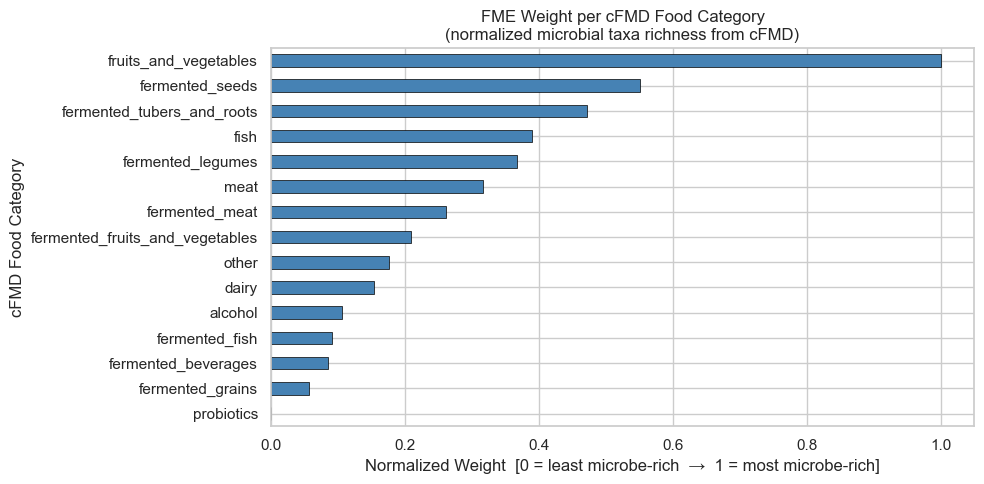

In [ ]:
#Visualize FME weights
plt.figure(figsize=(10, 5))
cfmd_category_weight_normalized.sort_values().plot(
    kind="barh", color="steelblue", edgecolor="black", linewidth=0.5
)
plt.title("FME Weight per cFMD Food Category\n(normalized microbial taxa richness from cFMD)")
plt.xlabel("Normalized Weight  [0 = least microbe-rich  →  1 = most microbe-rich]")
plt.ylabel("cFMD Food Category")
plt.tight_layout()
plt.show()


---
## Section 5 – Data Mapping: Diet Items → cFMD Food Categories

**Goal:** Map each food item in the Johnson et al. dietary records to a cFMD food category,
creating a unified representation of food-derived microbial exposure.

**Method:** Extract the L1 (top-level) taxonomy label from the `taxonomy` column of `diet_raw`
(e.g. `L1_Milk_and_Milk_Products` → `dairy`) and map it to the matching cFMD category.


In [ ]:
#Extract L1 food category from taxonomy string
def extract_l1_food_category(taxonomy_string):
    """
    Extract the top-level food category (L1) from the hierarchical taxonomy string.
    Example: 'L1_Milk_and_Milk_Products;L2_...' → 'milk and milk products'
    """
    if pd.isna(taxonomy_string):
        return "unknown"
    l1_segment = str(taxonomy_string).split(";")[0]
    return l1_segment.replace("L1_", "").replace("_", " ").strip().lower()

dietary_consumption_matrix["diet_l1_category"] = (
    dietary_consumption_matrix["taxonomy"]
    .apply(extract_l1_food_category)
)

print("Unique L1 diet categories found:")
for cat, count in dietary_consumption_matrix["diet_l1_category"].value_counts().items():
    print(f"  {cat:<45} {count:>5} food items")


Unique L1 diet categories found:
  grain product                                   407 food items
  vegetables                                      315 food items
  meat poultry fish and mixtures                  240 food items
  sugars sweets and beverages                     153 food items
  milk and milk products                          112 food items
  dry beans peas other legumes nuts and seeds      84 food items
  fruits                                           74 food items
  fats oils and salad dressings                    36 food items
  eggs                                             31 food items


C:\Users\linoy\AppData\Local\Temp\ipykernel_33056\862340182.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dietary_consumption_matrix["diet_l1_category"] = (


In [ ]:
#Mapping table: diet L1 category to cFMD category 
DIET_L1_TO_CFMD_CATEGORY = {
    #Dairy
    "milk and milk products"            : "dairy",
    "dairy"                             : "dairy",
    "cheese"                            : "dairy",
    "yogurt"                            : "dairy",
    #Meat
    "meat poultry and game"             : "meat",
    "meat"                              : "meat",
    "poultry"                           : "meat",
    #Fish
    "fish and shellfish"                : "fish",
    "fish"                              : "fish",
    "seafood"                           : "fish",
    #Fruits and vegetables
    "vegetables and vegetable products" : "fruits_and_vegetables",
    "fruit"                             : "fruits_and_vegetables",
    "fruits"                            : "fruits_and_vegetables",
    "vegetables"                        : "fruits_and_vegetables",
    #Fermented grains
    "grain products"                    : "fermented_grains",
    "grains"                            : "fermented_grains",
    "bread"                             : "fermented_grains",
    "cereals and cereal products"       : "fermented_grains",
    #Alcohol / fermented beverages
    "alcoholic beverages"               : "alcohol",
    "alcohol"                           : "alcohol",
    "beverages"                         : "fermented_beverages",
    "nonalcoholic beverages"            : "fermented_beverages",
    #Legumes
    "legumes and legume products"       : "fermented_legumes",
    "legumes"                           : "fermented_legumes",
    "beans"                             : "fermented_legumes",
    #Seeds / nuts
    "nuts and seeds"                    : "fermented_seeds",
    "seeds"                             : "fermented_seeds",
    #Other / unmappable
    "fats and oils"                     : "other",
    "sugars and sweets"                 : "other",
    "soups sauces and gravies"          : "other",
    "mixed dishes"                      : "other",
    "snacks"                            : "other",
    "eggs"                              : "other",
    "spices and herbs"                  : "other",
    "unknown"                           : "unmapped",
}

dietary_consumption_matrix["cfmd_category"] = (
    dietary_consumption_matrix["diet_l1_category"]
    .map(DIET_L1_TO_CFMD_CATEGORY)
    .fillna("unmapped")
)

n_mapped   = (dietary_consumption_matrix["cfmd_category"] != "unmapped").sum()
n_unmapped = (dietary_consumption_matrix["cfmd_category"] == "unmapped").sum()
print(f"Food items mapped to a cFMD category : {n_mapped} / {len(dietary_consumption_matrix)}")
print(f"Food items unmapped                  : {n_unmapped}")


Food items mapped to a cFMD category : 532 / 1452
Food items unmapped                  : 920


C:\Users\linoy\AppData\Local\Temp\ipykernel_33056\3621762370.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dietary_consumption_matrix["cfmd_category"] = (


In [ ]:
#Attach FME weight to each food item
dietary_consumption_matrix["fme_weight"] = (
    dietary_consumption_matrix["cfmd_category"]
    .map(cfmd_category_weight_normalized.to_dict())
    .fillna(0.0)   #unmapped items get weight = 0
)

mapping_summary = (
    dietary_consumption_matrix
    .groupby(["diet_l1_category", "cfmd_category", "fme_weight"])
    .size()
    .reset_index(name="n_food_items")
    .sort_values("n_food_items", ascending=False)
)
print("Mapping summary (diet L1 → cFMD category → weight):")
display(mapping_summary)


Mapping summary (diet L1 → cFMD category → weight):


C:\Users\linoy\AppData\Local\Temp\ipykernel_33056\1938438746.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dietary_consumption_matrix["fme_weight"] = (


,diet_l1_category,cfmd_category,fme_weight,n_food_items
4,grain product,unmapped,0.0000,407
8,vegetables,fruits_and_vegetables,1.0000,315
5,meat poultry fish and mixtures,unmapped,0.0000,240
7,sugars sweets and beverages,unmapped,0.0000,153
6,milk and milk products,dairy,0.1541,112
0,dry beans peas other legumes nuts and seeds,unmapped,0.0000,84
3,fruits,fruits_and_vegetables,1.0000,74
2,fats oils and salad dressings,unmapped,0.0000,36
1,eggs,other,0.1762,31


---
## Section 6 – FME Score Calculation

**Formula:**
$$\text{FME}_{sample} = \sum_{\text{food items}} \text{consumption}_{\text{food, sample}} \times w_{\text{cfmd\_category(food)}}$$

Where:
- $\text{consumption}_{\text{food, sample}}$ = amount consumed (from `diet_raw`, grams or servings)
- $w$ = normalized cFMD microbial richness weight for the food's category

**Important:** Each `sample` corresponds to **one dietary day for one participant**.
The result is a score per fecal sample — not per participant.
Participant-level scores are derived later by averaging across their samples.


In [ ]:
#Subset diet matrix to analytical samples only
diet_abundance_matrix = (
    dietary_consumption_matrix[analytical_sample_ids]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

fme_weight_vector = dietary_consumption_matrix["fme_weight"].values  # shape: (n_food_items,)

#Compute FME score: weighted sum of food consumption per sample
#Result: one FME score per fecal sample (= one dietary day per participant)
fme_score_per_sample = (
    diet_abundance_matrix
    .multiply(fme_weight_vector, axis=0)
    .sum(axis=0)
    .rename("fme_score_daily")
)
fme_score_per_sample.index.name = "fecal_sample_id"

print(f"FME scores computed for : {len(fme_score_per_sample)} fecal samples")
print(f"Score range             : {fme_score_per_sample.min():.4f} – {fme_score_per_sample.max():.4f}")
print(f"Score mean ± std        : {fme_score_per_sample.mean():.4f} ± {fme_score_per_sample.std():.4f}")
print(f"Non-zero scores         : {(fme_score_per_sample > 0).sum()}")
print()
display(fme_score_per_sample.reset_index().head(8))


FME scores computed for : 475 fecal samples
Score range             : 0.0000 – 331.2240
Score mean ± std        : 73.3252 ± 58.3071
Non-zero scores         : 437



,fecal_sample_id,fme_score_daily
0,MCT.f.0002,67.1961
1,MCT.f.0003,81.2412
2,MCT.f.0004,126.7711
3,MCT.f.0005,31.4846
4,MCT.f.0006,61.2266
5,MCT.f.0007,62.0231
6,MCT.f.0008,70.9874
7,MCT.f.0009,54.0086


In [ ]:
#Participant level FME summary (aggregate across samples)
#Participant level values are used only for descriptive summaries,

fme_with_participant = pd.DataFrame({
    "fecal_sample_id" : fme_score_per_sample.index,
    "fme_score_daily" : fme_score_per_sample.values,
})
fme_with_participant["participant_id"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "UserName"]
    .values
)
fme_with_participant["study_day"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "StudyDayNo"]
    .values
)

#Participant-level summary (descriptive only)
participant_fme_summary = (
    fme_with_participant
    .groupby("participant_id")["fme_score_daily"]
    .agg(
        fme_mean     = "mean",
        fme_std      = "std",
        fme_min      = "min",
        fme_max      = "max",
        n_diet_days  = "count"
    )
    .reset_index()
)

print("Participant-level FME summary (descriptive — 34 participants):")
display(participant_fme_summary.sort_values("fme_mean", ascending=False).head(10))


Participant-level FME summary (descriptive — 34 participants):


,participant_id,fme_mean,fme_std,fme_min,fme_max,n_diet_days
1,MCTs03,147.8899,45.7548,68.0651,243.3253,12
5,MCTs07,143.4859,48.3133,86.0332,243.8429,16
2,MCTs04,143.1190,81.0506,36.6199,331.2240,15
6,MCTs08,140.2178,33.6074,84.4009,220.3516,17
14,MCTs16,130.9598,45.2371,69.7540,221.0863,14
27,MCTs31,128.7335,37.7598,83.9027,208.7920,15
23,MCTs26,122.0334,71.3654,24.5678,315.7055,17
16,MCTs19,99.4541,40.7179,14.6490,166.4480,15
17,MCTs20,88.6724,51.9185,24.4219,178.8966,12
24,MCTs27,85.2074,47.0410,5.0752,165.2448,14


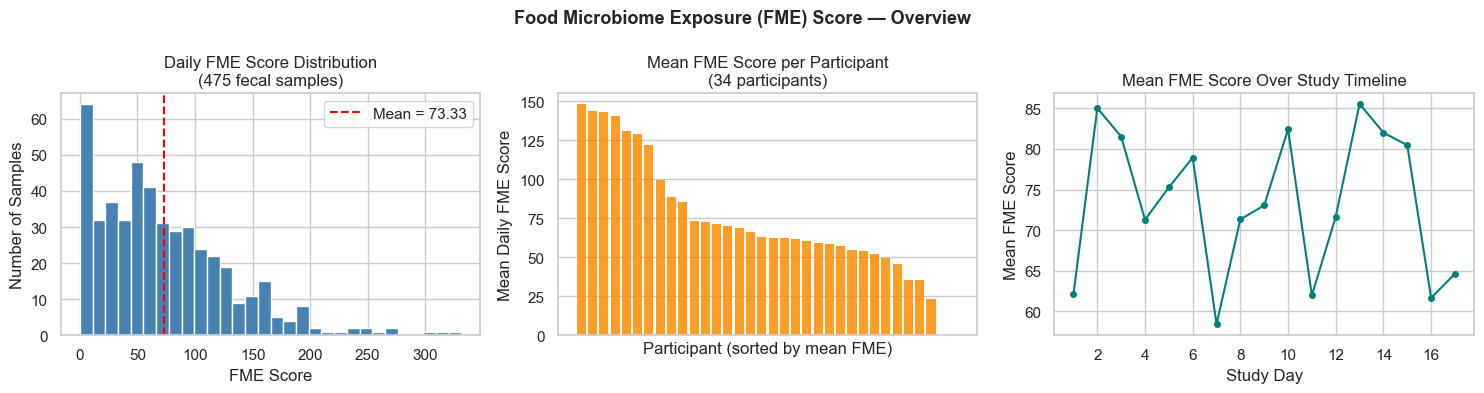

In [ ]:
#Visualize FME scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Distribution of daily FME scores across all fecal samples
axes[0].hist(fme_score_per_sample.values, bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(fme_score_per_sample.mean(), color="red", linestyle="--",
                label=f"Mean = {fme_score_per_sample.mean():.2f}")
axes[0].set_title("Daily FME Score Distribution\n(475 fecal samples)")
axes[0].set_xlabel("FME Score")
axes[0].set_ylabel("Number of Samples")
axes[0].legend()

#Mean FME per participant (sorted)
sorted_participants = participant_fme_summary.sort_values("fme_mean", ascending=False)
axes[1].bar(range(len(sorted_participants)), sorted_participants["fme_mean"],
            color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_title(f"Mean FME Score per Participant\n({len(sorted_participants)} participants)")
axes[1].set_xlabel("Participant (sorted by mean FME)")
axes[1].set_ylabel("Mean Daily FME Score")
axes[1].set_xticks([])

#FME over study timeline (mean per study day)
fme_by_day = fme_with_participant.groupby("study_day")["fme_score_daily"].mean()
axes[2].plot(fme_by_day.index, fme_by_day.values,
             marker="o", color="teal", linewidth=1.5, markersize=4)
axes[2].set_title("Mean FME Score Over Study Timeline")
axes[2].set_xlabel("Study Day")
axes[2].set_ylabel("Mean FME Score")

plt.suptitle("Food Microbiome Exposure (FME) Score — Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 7 – Gut Microbiome Alpha Diversity per Fecal Sample

Compute **Shannon entropy** for each fecal sample as a measure of gut microbial richness and evenness.
This is the primary outcome variable (composition proxy) at the sample level.


In [ ]:
#Alpha diversity metrics per fecal sample

#Computing Shannon entropy using the formula below, where p_i is the proportion of each taxon in the sample
#Shannon entropy H = -Σ p_i * log(p_i) for non zero taxa
def compute_shannon_entropy(sample_val):
    pos_val = sample_val[sample_val > 0]
    if pos_val.sum() == 0:
        return np.nan
    prop = pos_val / pos_val.sum()
    return float(-np.sum(prop * np.log(prop)))

#Computing richness of taxa per sample
#Richness = number of non-zero taxa
def compute_richness(sample_val):
    pos_val = sample_val[sample_val > 0]
    return int(len(pos_val))

#Computing Simpson diversity using the formula below
#Simpson diversity = 1 - Σ p_i^2
def compute_simpson_diversity(sample_val):
    pos_val = sample_val[sample_val > 0]
    if pos_val.sum() == 0:
        return np.nan
    prop = pos_val / pos_val.sum()
    return float(1 - np.sum(prop ** 2))

#Computing Inverse Simpson using the formula below
#Inverse Simpson = 1 / Σ p_i^2
def compute_inverse_simpson(sample_val):
    pos_val = sample_val[sample_val > 0]
    if pos_val.sum() == 0:
        return np.nan
    prop = pos_val / pos_val.sum()
    denominator = np.sum(prop ** 2)
    if denominator == 0:
        return np.nan
    return float(1 / denominator)

#Computing Pielou evenness using the formula below
#Pielou evenness = Shannon / log(richness)
def compute_pielou_evenness(sample_val):
    pos_val = sample_val[sample_val > 0]
    richness = len(pos_val)

    if richness <= 1:
        return np.nan

    if pos_val.sum() == 0:
        return np.nan

    prop = pos_val / pos_val.sum()
    shannon = -np.sum(prop * np.log(prop))

    return float(shannon / np.log(richness))


gut_microbiome_analytical = gut_microbiome_abundance[analytical_sample_ids]

shannon_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_shannon_entropy, axis=0)
    .rename("shannon_diversity")
)

richness_per_sample = (
    gut_microbiome_analytical
    .apply(compute_richness, axis=0)
    .rename("richness")
)

simpson_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_simpson_diversity, axis=0)
    .rename("simpson_diversity")
)

inverse_simpson_per_sample = (
    gut_microbiome_analytical
    .apply(compute_inverse_simpson, axis=0)
    .rename("inverse_simpson")
)

pielou_evenness_per_sample = (
    gut_microbiome_analytical
    .apply(compute_pielou_evenness, axis=0)
    .rename("pielou_evenness")
)

alpha_diversity_per_sample = pd.concat(
    [
        shannon_diversity_per_sample,
        richness_per_sample,
        simpson_diversity_per_sample,
        inverse_simpson_per_sample,
        pielou_evenness_per_sample,
    ],
    axis=1
)

alpha_diversity_per_sample.index.name = "fecal_sample_id"

print(f"Alpha diversity computed for {alpha_diversity_per_sample.shape[0]} samples")
display(alpha_diversity_per_sample.describe().T.round(3))

Alpha diversity computed for 475 samples


,count,mean,std,min,25%,50%,75%,max
shannon_diversity,475.0000,2.8650,0.4130,1.5720,2.6110,2.9640,3.1430,3.7310
richness,475.0000,203.5620,11.9540,140.0000,198.0000,207.0000,212.0000,220.0000
simpson_diversity,475.0000,0.8600,0.0760,0.4650,0.8310,0.8860,0.9100,0.9570
inverse_simpson,475.0000,8.7810,3.6000,1.8690,5.9330,8.7990,11.1220,23.3370
pielou_evenness,475.0000,0.5390,0.0750,0.2990,0.4930,0.5560,0.5920,0.6940


---
## Section 8 – Gut Microbiome Stability per Participant

**Stability** = how consistent is a participant's gut microbiome across their sampling days?

We use the **coefficient of variation (CV)** of Shannon diversity across a participant's samples:
$$CV_{participant} = \frac{\sigma(\text{Shannon})}{\mu(\text{Shannon})}$$

Lower CV = more stable microbiome.

> This is computed at the **participant level** (34 values) and joined back to the sample-level table as a per-participant attribute.


In [ ]:
#Map each fecal sample to its participant
sample_to_participant = (
    fecal_sample_metadata
    .loc[analytical_sample_ids, "UserName"]
    .rename("participant_id")
)

shannon_with_participant = pd.DataFrame({
    "fecal_sample_id" : shannon_diversity_per_sample.index,
    "shannon_diversity": shannon_diversity_per_sample.values,
}).set_index("fecal_sample_id")
shannon_with_participant["participant_id"] = sample_to_participant

#Participant-level stability (CV of Shannon across their samples)
participant_gut_stability = (
    shannon_with_participant
    .groupby("participant_id")["shannon_diversity"]
    .agg(
        participant_shannon_mean = "mean",
        participant_shannon_std  = "std",
        participant_n_samples    = "count"
    )
    .assign(
        participant_shannon_cv = lambda df:
            df["participant_shannon_std"] / df["participant_shannon_mean"]
    )
    .reset_index()
)

print(f"Gut stability computed for {len(participant_gut_stability)} participants")
print(f"Shannon CV range : {participant_gut_stability['participant_shannon_cv'].min():.4f} – "
      f"{participant_gut_stability['participant_shannon_cv'].max():.4f}")
display(participant_gut_stability.sort_values("participant_shannon_cv").head(8))


Gut stability computed for 34 participants
Shannon CV range : 0.0202 – 0.1799


,participant_id,participant_shannon_mean,participant_shannon_std,participant_n_samples,participant_shannon_cv
5,MCTs07,3.0731,0.0621,16,0.0202
17,MCTs20,3.2696,0.0736,12,0.0225
29,MCTs33,3.0863,0.0876,17,0.0284
11,MCTs13,3.1848,0.0942,11,0.0296
19,MCTs22,2.9985,0.0912,15,0.0304
7,MCTs09,3.0362,0.0948,16,0.0312
30,MCTs34,2.9806,0.1022,12,0.0343
8,MCTs10,3.0279,0.1045,14,0.0345


---
## Section 9 – Assemble the Statistical Analysis Dataset

Merge all variables into one clean table at the **fecal sample level**.
Each row = one fecal sample = one dietary day for one participant.

| Column group | Columns | Role in statistical model |
|---|---|---|
| Identity | `fecal_sample_id`, `participant_id`, `study_day` | Grouping / random effect |
| Demographics | `Age`, `BMI`, `Gender` | Fixed-effect covariates |
| **FME score** | `fme_score_daily` | **Main predictor** |
| **Gut diversity** | `shannon_diversity` | **Main outcome** |
| **Gut stability** | `participant_shannon_cv` | **Secondary outcome** |
| Nutrition | `KCAL`, `FIBE`, `PROT`, `TFAT`, `CARB` | Dietary confounders |


In [ ]:
#Base table - fecal sample IDs   
statistical_analysis_dataset = pd.DataFrame(
    index=pd.Index(analytical_sample_ids, name="fecal_sample_id")
)

#Participant identity and demographics
participant_meta_cols = ["UserName", "StudyDayNo", "Gender", "Age", "BMI",
                         "Weight", "Supplement", "Medications"]
participant_meta_cols = [c for c in participant_meta_cols
                         if c in fecal_sample_metadata.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    fecal_sample_metadata[participant_meta_cols]
    .rename(columns={"UserName": "participant_id", "StudyDayNo": "study_day"}),
    how="left"
)

#Daily FME score
statistical_analysis_dataset = statistical_analysis_dataset.join(
    fme_score_per_sample.rename("fme_score_daily"),
    how="left"
)

#Participant level and within person FME scores
#The daily FME score is already weighted using cFMD derived microbial richness weights
statistical_analysis_dataset["fme_participant_mean"] = (
    statistical_analysis_dataset
    .groupby("participant_id")["fme_score_daily"]
    .transform("mean")
)

statistical_analysis_dataset["fme_within_person"] = (
    statistical_analysis_dataset["fme_score_daily"]
    - statistical_analysis_dataset["fme_participant_mean"]
)

#Lagged and weighted recent FME scores
#The weighted 3 day score gives more weight to the current day and lower weight to previous days

fme_time_sorted = statistical_analysis_dataset.sort_values(
    ["participant_id", "study_day"]
).copy()

fme_time_sorted["fme_lag1"] = (
    fme_time_sorted
    .groupby("participant_id")["fme_score_daily"]
    .shift(1)
)

fme_time_sorted["fme_lag2"] = (
    fme_time_sorted
    .groupby("participant_id")["fme_score_daily"]
    .shift(2)
)

weighted_sum = (
    0.5 * fme_time_sorted["fme_score_daily"].fillna(0)
    + 0.3 * fme_time_sorted["fme_lag1"].fillna(0)
    + 0.2 * fme_time_sorted["fme_lag2"].fillna(0)
)

available_weight = (
    0.5 * fme_time_sorted["fme_score_daily"].notna().astype(float)
    + 0.3 * fme_time_sorted["fme_lag1"].notna().astype(float)
    + 0.2 * fme_time_sorted["fme_lag2"].notna().astype(float)
)

fme_time_sorted["fme_weighted_3day"] = weighted_sum / available_weight

statistical_analysis_dataset[
    ["fme_lag1", "fme_lag2", "fme_weighted_3day"]
] = fme_time_sorted[
    ["fme_lag1", "fme_lag2", "fme_weighted_3day"]
]

#Gut alpha diversity metrics   
statistical_analysis_dataset = statistical_analysis_dataset.join(
    alpha_diversity_per_sample,
    how="left"
)

#Participant level gut stability 
statistical_analysis_dataset = statistical_analysis_dataset.join(
    participant_gut_stability.set_index("participant_id")[
        ["participant_shannon_cv", "participant_shannon_mean", "participant_n_samples"]
    ],
    on="participant_id",
    how="left"
)

#Daily nutrition totals   
nutrition_cols_keep = ["KCAL", "PROT", "TFAT", "CARB", "FIBE",
                       "SUGR", "SODI", "D_TOTAL", "D_YOGURT", "D_CHEESE",
                       "PF_MEAT", "PF_SEAFD_HI", "G_WHOLE"]
nutrition_cols_keep = [c for c in nutrition_cols_keep
                       if c in daily_nutrition_totals.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    daily_nutrition_totals[nutrition_cols_keep],
    how="left"
)

print(f"Statistical dataset shape  : {statistical_analysis_dataset.shape}")
print(f"Fecal samples (rows)       : {statistical_analysis_dataset.shape[0]}")
print(f"Variables (columns)        : {statistical_analysis_dataset.shape[1]}")
print(f"Participants represented   : {statistical_analysis_dataset['participant_id'].nunique()}")
print(f"Complete rows (no NaN)     : {statistical_analysis_dataset.dropna().shape[0]}")


Statistical dataset shape  : (475, 35)
Fecal samples (rows)       : 475
Variables (columns)        : 35
Participants represented   : 34
Complete rows (no NaN)     : 188


In [ ]:
#Check if the new columns were added correctly
statistical_analysis_dataset[
    [
        "shannon_diversity",
        "richness",
        "simpson_diversity",
        "inverse_simpson",
        "pielou_evenness"
    ]
].head()

,shannon_diversity,richness,simpson_diversity,inverse_simpson,pielou_evenness
fecal_sample_id,,,,,
MCT.f.0002,2.8627,211,0.8720,7.8101,0.5349
MCT.f.0003,3.5228,208,0.9473,18.9896,0.6600
MCT.f.0004,3.0312,213,0.8918,9.2447,0.5654
MCT.f.0005,2.9738,207,0.8825,8.5109,0.5577
MCT.f.0006,3.0811,209,0.9000,10.0002,0.5767


In [ ]:
#Check if there is not null values in the new columns
statistical_analysis_dataset[
    [
        "shannon_diversity",
        "richness",
        "simpson_diversity",
        "inverse_simpson",
        "pielou_evenness"
    ]
].isna().sum()

shannon_diversity    0
richness             0
simpson_diversity    0
inverse_simpson      0
pielou_evenness      0
dtype: int64

In [ ]:
#Check if the new FME columns were added correctly
statistical_analysis_dataset[
    [
        "participant_id",
        "fme_score_daily",
        "fme_participant_mean",
        "fme_within_person"
    ]
].head(10)

,participant_id,fme_score_daily,fme_participant_mean,fme_within_person
fecal_sample_id,,,,
MCT.f.0002,MCTs01,67.1961,71.2710,-4.0749
MCT.f.0003,MCTs01,81.2412,71.2710,9.9703
MCT.f.0004,MCTs01,126.7711,71.2710,55.5001
MCT.f.0005,MCTs01,31.4846,71.2710,-39.7864
MCT.f.0006,MCTs01,61.2266,71.2710,-10.0444
MCT.f.0007,MCTs01,62.0231,71.2710,-9.2479
MCT.f.0008,MCTs01,70.9874,71.2710,-0.2836
MCT.f.0009,MCTs01,54.0086,71.2710,-17.2624
MCT.f.0010,MCTs01,105.6813,71.2710,34.4103


In [ ]:
#Check if there are no null values in the new FME columns
statistical_analysis_dataset[
    [
        "fme_score_daily",
        "fme_participant_mean",
        "fme_within_person"
    ]
].isna().sum()

fme_score_daily         0
fme_participant_mean    0
fme_within_person       0
dtype: int64

In [ ]:
#Descriptive statistics for the FME score variants
statistical_analysis_dataset[
    [
        "fme_score_daily",
        "fme_participant_mean",
        "fme_within_person"
    ]
].describe().round(3)

,fme_score_daily,fme_participant_mean,fme_within_person
count,475.0000,475.0000,475.0000
mean,73.3250,73.3250,0.0000
std,58.3070,39.8040,42.6070
min,0.0000,0.0000,-106.4990
25%,29.3220,53.6970,-25.0860
50%,61.7780,62.2510,-3.0860
75%,104.2700,99.4540,17.1070
max,331.2240,147.8900,251.2760


In [ ]:
#Missing value report
missing_report = (
    statistical_analysis_dataset.isnull().sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_missing"})
)
missing_report["pct_missing"] = (
    missing_report["n_missing"] / len(statistical_analysis_dataset) * 100
).round(1)
missing_report = missing_report[missing_report["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_report.empty:
    print("No missing values in the statistical dataset.")
else:
    print("Missing values:")
    display(missing_report)


Missing values:


,variable,n_missing,pct_missing
7,Medications,255,53.7000
12,fme_lag2,68,14.3000
11,fme_lag1,34,7.2000


In [ ]:
#Descriptive statistics
key_vars = [
    "fme_score_daily",
    "fme_participant_mean",
    "fme_within_person",
    "fme_lag1",
    "fme_lag2",
    "fme_weighted_3day",
    "shannon_diversity",
    "richness",
    "simpson_diversity",
    "inverse_simpson",
    "pielou_evenness",
    "participant_shannon_cv",
    "Age",
    "BMI",
    "KCAL",
    "FIBE"
]

key_vars = [v for v in key_vars if v in statistical_analysis_dataset.columns]

print("Descriptive statistics - key variables:")
display(statistical_analysis_dataset[key_vars].describe().T.round(3))


Descriptive statistics - key variables:


,count,mean,std,min,25%,50%,75%,max
fme_score_daily,475.0000,73.3250,58.3070,0.0000,29.3220,61.7780,104.2700,331.2240
fme_participant_mean,475.0000,73.3250,39.8040,0.0000,53.6970,62.2510,99.4540,147.8900
fme_within_person,475.0000,0.0000,42.6070,-106.4990,-25.0860,-3.0860,17.1070,251.2760
fme_lag1,441.0000,73.9720,59.2070,0.0000,29.5690,61.6000,106.7030,331.2240
fme_lag2,407.0000,74.8860,60.1780,0.0000,30.0080,61.7780,108.5470,331.2240
fme_weighted_3day,475.0000,73.4000,49.3200,0.0000,38.8190,64.5830,103.1050,280.7920
shannon_diversity,475.0000,2.8650,0.4130,1.5720,2.6110,2.9640,3.1430,3.7310
richness,475.0000,203.5620,11.9540,140.0000,198.0000,207.0000,212.0000,220.0000
simpson_diversity,475.0000,0.8600,0.0760,0.4650,0.8310,0.8860,0.9100,0.9570
inverse_simpson,475.0000,8.7810,3.6000,1.8690,5.9330,8.7990,11.1220,23.3370


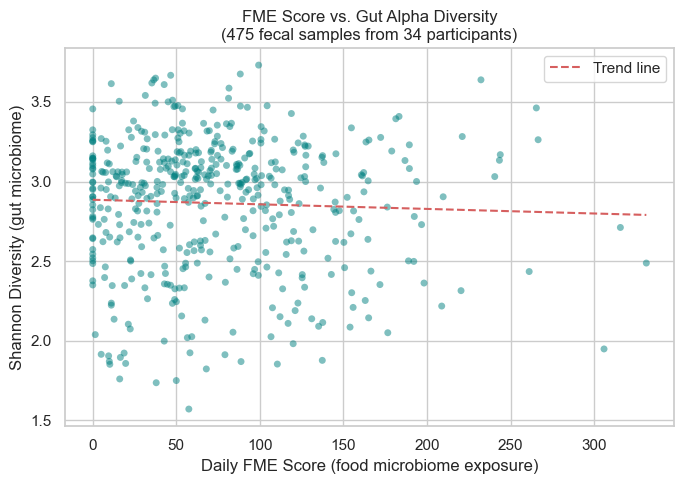

In [ ]:
#Quick scatter: FME score vs. gut Shannon diversity
plot_df = statistical_analysis_dataset.dropna(
    subset=["fme_score_daily", "shannon_diversity"]
)

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["fme_score_daily"], plot_df["shannon_diversity"],
            alpha=0.5, s=25, c="teal", edgecolors="none")
if len(plot_df) > 2:
    z = np.polyfit(plot_df["fme_score_daily"], plot_df["shannon_diversity"], 1)
    x_line = np.linspace(plot_df["fme_score_daily"].min(),
                         plot_df["fme_score_daily"].max(), 100)
    plt.plot(x_line, np.poly1d(z)(x_line), "r--", lw=1.5, label="Trend line")
plt.xlabel("Daily FME Score (food microbiome exposure)")
plt.ylabel("Shannon Diversity (gut microbiome)")
plt.title("FME Score vs. Gut Alpha Diversity\n(475 fecal samples from 34 participants)")
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 10 – Save Outputs

In [ ]:
#Save statistical analysis dataset
statistical_analysis_dataset.to_csv(DATA_DIR / "fme_statistical_dataset_extended.csv")
participant_gut_stability.to_csv(DATA_DIR / "participant_gut_stability.csv", index=False)
fme_with_participant.to_csv(DATA_DIR / "fme_sample_level_scores.csv", index=False)

print("Saved:")
print(f"  fme_statistical_dataset_extended.csv    {statistical_analysis_dataset.shape}  - main analytical table")
print(f"  participant_gut_stability.csv  {participant_gut_stability.shape}  - stability per participant")
print(f"  fme_sample_level_scores.csv    {fme_with_participant.shape}  - FME scores with participant labels")


Saved:
  fme_statistical_dataset_extended.csv    (475, 35)  - main analytical table
  participant_gut_stability.csv  (34, 5)  - stability per participant
  fme_sample_level_scores.csv    (475, 4)  - FME scores with participant labels


## Summary

### What was built

The `fme_statistical_dataset_extended.csv` table is the **primary input for the extended statistical analyses**.

This dataset extends the original statistical table by adding additional gut microbiome alpha diversity metrics, participant-level FME features, and short-term lagged FME exposure features.

### Added alpha diversity metrics

In addition to the original `shannon_diversity`, the following alpha diversity metrics were added:

* `richness` — number of non-zero taxa in each fecal sample
* `simpson_diversity` — dominance-sensitive diversity metric
* `inverse_simpson` — effective diversity based on Simpson index
* `pielou_evenness` — evenness of the microbial community distribution

### Added FME features

The original daily FME score was kept as:

* `fme_score_daily`

The daily FME score is already weighted using cFMD-derived microbial richness weights.

In addition, participant-level FME variables were added:

* `fme_participant_mean` — participant-level mean of the daily weighted FME scores
* `fme_within_person` — deviation of each daily FME score from that participant’s mean

The participant-level mean is therefore calculated as the average of the already-weighted daily FME scores, not as a new weighting scheme.

### Added lagged and short-term FME exposure features

To capture possible short-term dietary effects before or around each fecal sample, additional time-based FME features were added:

* `fme_lag1` — the previous FME score for the same participant, ordered by `study_day`
* `fme_lag2` — the FME score two previous observations back for the same participant, ordered by `study_day`
* `fme_weighted_3day` — a weighted recent FME score using the current score, lag 1, and lag 2

The weighted 3-day FME score is calculated as:

```text
fme_weighted_3day = 0.5 * current FME + 0.3 * lag1 FME + 0.2 * lag2 FME
```

When lag values are missing, for example in the first or second sample of a participant, the weighted average is normalized using only the available values.

### Structural note — important for modelling

* **Unit of observation**: fecal sample, 475 rows
* **Grouping variable**: `participant_id`, 34 participants
* Because several fecal samples belong to the same participant, `participant_id` should be included as a **random effect** in sample-level models.

### Main predictors

* `fme_score_daily`
* `fme_participant_mean`
* `fme_within_person`
* `fme_lag1`
* `fme_lag2`
* `fme_weighted_3day`

### Main outcomes

* `shannon_diversity`
* `richness`
* `simpson_diversity`
* `inverse_simpson`
* `pielou_evenness`
* `participant_shannon_cv` for participant-level stability analysis

### Recommended next steps

Mixed-effects model for sample-level alpha diversity using daily FME:

```text
alpha_diversity_metric ~ fme_score_daily + Age + BMI + KCAL + FIBE + PROT + TFAT + CARB + (1 | participant_id)
```

Extended mixed-effects model separating between-person and within-person FME effects:

```text
alpha_diversity_metric ~ fme_participant_mean + fme_within_person + Age + BMI + KCAL + FIBE + PROT + TFAT + CARB + (1 | participant_id)
```

Short-term exposure mixed-effects model using recent weighted FME:

```text
alpha_diversity_metric ~ fme_weighted_3day + Age + BMI + KCAL + FIBE + PROT + TFAT + CARB + (1 | participant_id)
```

Lagged exposure mixed-effects model:

```text
alpha_diversity_metric ~ fme_lag1 + fme_lag2 + Age + BMI + KCAL + FIBE + PROT + TFAT + CARB + (1 | participant_id)
```

Participant-level stability model:

```text
participant_shannon_cv ~ fme_participant_mean + Age + BMI
```

### Interpretation

The extended dataset allows us to test whether FME is associated not only with Shannon diversity, but also with richness, dominance-sensitive diversity metrics, and microbial evenness.

It also allows us to distinguish between:

* **Between-person effects** — whether participants with higher average FME differ in microbiome diversity
* **Within-person effects** — whether days when a participant has higher-than-usual FME are associated with different microbiome diversity
* **Short-term exposure effects** — whether recent FME values from the current and previous observations are associated with microbiome diversity


# Notebook: `Feature_Selection.ipynb`

# 1. Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
nutrition = pd.read_csv("nutrition_totals.csv")
metadata = pd.read_csv("cfmd_metadata.csv")
fme = pd.read_csv("fme_statistical_dataset.csv")

In [ ]:
print("Nutrition:", nutrition.shape)
print("Metadata:", metadata.shape)
print("FME:", fme.shape)

Nutrition: (580, 107)
Metadata: (3444, 32)
FME: (475, 27)


In [ ]:
nutrition.columns.tolist()

['X.SampleID',
 'UserName',
 'StudyDayNo',
 'RecordDayNo',
 'KCAL',
 'PROT',
 'TFAT',
 'CARB',
 'MOIS',
 'ALC',
 'CAFF',
 'THEO',
 'SUGR',
 'FIBE',
 'CALC',
 'IRON',
 'MAGN',
 'PHOS',
 'POTA',
 'SODI',
 'ZINC',
 'COPP',
 'SELE',
 'VC',
 'VB1',
 'VB2',
 'NIAC',
 'VB6',
 'FOLA',
 'FA',
 'FF',
 'FDFE',
 'VB12',
 'VARA',
 'RET',
 'BCAR',
 'ACAR',
 'CRYP',
 'LYCO',
 'LZ',
 'ATOC',
 'VK',
 'CHOLE',
 'SFAT',
 'S040',
 'S060',
 'S080',
 'S100',
 'S120',
 'S140',
 'S160',
 'S180',
 'MFAT',
 'M161',
 'M181',
 'M201',
 'M221',
 'PFAT',
 'P182',
 'P183',
 'P184',
 'P204',
 'P205',
 'P225',
 'P226',
 'VITD',
 'CHOLN',
 'VITE_ADD',
 'B12_ADD',
 'F_TOTAL',
 'F_CITMLB',
 'F_OTHER',
 'F_JUICE',
 'V_TOTAL',
 'V_DRKGR',
 'V_REDOR_TOTAL',
 'V_REDOR_TOMATO',
 'V_REDOR_OTHER',
 'V_STARCHY_TOTAL',
 'V_STARCHY_POTATO',
 'V_STARCHY_OTHER',
 'V_OTHER',
 'V_LEGUMES',
 'G_TOTAL',
 'G_WHOLE',
 'G_REFINED',
 'PF_TOTAL',
 'PF_MPS_TOTAL',
 'PF_MEAT',
 'PF_CUREDMEAT',
 'PF_ORGAN',
 'PF_POULT',
 'PF_SEAFD_HI',
 'PF_SEA

# 3. Initial Statistical Exploration

In [ ]:
nutrition.describe()

,RecordDayNo,KCAL,PROT,TFAT,CARB,MOIS,ALC,CAFF,THEO,SUGR,FIBE,CALC,IRON,MAGN,PHOS,POTA,SODI,ZINC,COPP,SELE,VC,VB1,VB2,NIAC,VB6,FOLA,FA,FF,FDFE,VB12,VARA,RET,BCAR,ACAR,CRYP,LYCO,LZ,ATOC,VK,CHOLE,SFAT,S040,S060,S080,S100,S120,S140,S160,S180,MFAT,M161,M181,M201,M221,PFAT,P182,P183,P184,P204,P205,P225,P226,VITD,CHOLN,VITE_ADD,B12_ADD,F_TOTAL,F_CITMLB,F_OTHER,F_JUICE,V_TOTAL,V_DRKGR,V_REDOR_TOTAL,V_REDOR_TOMATO,V_REDOR_OTHER,V_STARCHY_TOTAL,V_STARCHY_POTATO,V_STARCHY_OTHER,V_OTHER,V_LEGUMES,G_TOTAL,G_WHOLE,G_REFINED,PF_TOTAL,PF_MPS_TOTAL,PF_MEAT,PF_CUREDMEAT,PF_ORGAN,PF_POULT,PF_SEAFD_HI,PF_SEAFD_LOW,PF_EGGS,PF_SOY,PF_NUTSDS,PF_LEGUMES,D_TOTAL,D_MILK,D_YOGURT,D_CHEESE,OILS,SOLID_FATS,ADD_SUGARS,A_DRINKS,Replicate
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.0
mean,8.818966,2080.111477,88.574102,89.968175,225.547385,2357.233574,7.430525,131.699877,49.268748,85.060435,21.959899,1064.400061,15.229976,366.894792,1499.589367,2916.328980,3465.410770,12.717472,1.577421,112.555312,89.717859,1.638711,2.169141,24.327449,2.238430,437.958619,168.798462,261.849377,561.808505,4.987080,952.144281,499.098063,4527.727595,670.283537,121.800204,4123.632245,3892.495958,10.812165,227.225424,286.001695,28.239699,0.676149,0.363224,0.303036,0.585495,0.901601,2.516648,14.878355,6.660603,34.751008,1.158945,28.728979,0.308707,0.025068,20.262761,17.548672,1.846455,0.015385,0.141476,0.033703,0.020653,0.082740,5.440563,366.657289,1.807326,1.378256,0.955557,0.278951,0.524916,0.151690,1.923693,0.340528,0.460120,0.277924,0.182196,0.252808,0.161108,0.091699,0.870238,0.149730,6.133150,1.308836,4.824314,6.232266,3.884476,1.146755,0.724095,0.002094,1.397517,0.329686,0.284329,0.615845,0.261992,1.469952,0.602397,1.952389,0.637957,0.105994,1.009525,29.676465,36.584258,10.753747,0.531654,1.0
std,4.944247,759.292294,39.197367,41.277159,85.945975,1099.069853,19.156963,134.302956,70.850218,43.367228,11.206379,563.416094,6.853586,165.417499,624.171935,1089.785126,1640.999998,11.779213,0.922886,58.437369,67.331932,0.997450,0.872578,12.422127,1.371414,208.030427,155.444471,160.171770,299.969840,4.329262,770.527121,455.805989,6620.111458,1217.357799,257.398192,5999.185748,7715.882680,6.384469,352.937690,212.939988,17.315839,0.722595,0.369695,0.368673,0.635843,1.808310,2.389101,8.584044,4.075027,19.040091,0.901902,14.965260,0.296283,0.077262,11.451433,10.496435,1.284252,0.048055,0.121565,0.115194,0.031651,0.215428,6.823814,174.367241,4.952104,3.272752,1.004102,0.460380,0.729073,0.384318,1.517069,0.570481,0.515557,0.383244,0.338360,0.455809,0.392470,0.236664,0.875349,0.343576,4.245192,1.659134,3.884815,4.526670,4.028944,2.286698,1.356647,0.037994,2.641947,1.536319,0.943397,0.880455,0.667237,2.086981,1.379055,1.644046,0.774518,0.260058,1.473593,20.451230,28.067026,7.846380,1.371762,0.0
min,1.000000,441.480000,13.636116,13.280825,22.656360,44.531960,0.000000,0.000000,0.000000,2.507650,2.508800,78.120000,2.

In [ ]:
nutrition.isnull().sum()

X.SampleID     0
UserName       0
StudyDayNo     0
RecordDayNo    0
KCAL           0
              ..
OILS           0
SOLID_FATS     0
ADD_SUGARS     0
A_DRINKS       0
Replicate      0
Length: 107, dtype: int64

In [ ]:
nutrition.var(numeric_only=True).sort_values(ascending=False)

LZ           5.953485e+07
BCAR         4.382588e+07
LYCO         3.599023e+07
SODI         2.692881e+06
ACAR         1.481960e+06
                 ...     
M221         5.969343e-03
P184         2.309319e-03
PF_ORGAN     1.443579e-03
P225         1.001772e-03
Replicate    0.000000e+00
Length: 104, dtype: float64

In [ ]:
fme.columns.tolist()

['fecal_sample_id',
 'participant_id',
 'study_day',
 'Gender',
 'Age',
 'BMI',
 'Weight',
 'Supplement',
 'Medications',
 'fme_score_daily',
 'shannon_diversity',
 'participant_shannon_cv',
 'participant_shannon_mean',
 'participant_n_samples',
 'KCAL',
 'PROT',
 'TFAT',
 'CARB',
 'FIBE',
 'SUGR',
 'SODI',
 'D_TOTAL',
 'D_YOGURT',
 'D_CHEESE',
 'PF_MEAT',
 'PF_SEAFD_HI',
 'G_WHOLE']

In [ ]:
numeric_cols = fme.select_dtypes(include='number').columns

corr_with_shannon = (
    fme[numeric_cols]
    .corr()['shannon_diversity']
    .sort_values(key=abs, ascending=False)
)

corr_with_shannon

shannon_diversity           1.000000
participant_shannon_mean    0.891684
participant_shannon_cv     -0.492850
participant_n_samples      -0.198548
D_TOTAL                     0.151858
PF_MEAT                     0.124627
D_CHEESE                    0.113929
PF_SEAFD_HI                -0.109411
Weight                      0.103851
study_day                   0.094500
SUGR                        0.074537
Age                         0.068761
CARB                        0.067730
KCAL                        0.065748
D_YOGURT                   -0.059768
PROT                        0.058321
FIBE                       -0.054961
fme_score_daily            -0.040577
BMI                         0.038759
G_WHOLE                     0.017970
TFAT                        0.006157
SODI                        0.003889
Name: shannon_diversity, dtype: float64

In [ ]:
metadata.columns.tolist()

['dataset_name',
 'sample_id',
 'macrocategory',
 'category',
 'type',
 'subtype',
 'commercial_name',
 'fermented/non-fermented',
 'country',
 'sample_accession',
 'run_accession',
 'experiment_accession',
 'study_accession',
 'project_accession',
 'database_origin',
 'library_layout',
 'sequencing_platform',
 'DNA_extraction_kit',
 'collection_date',
 'n_of_bases',
 'n_of_reads',
 'min_read_len',
 'median_read_len',
 'mean_read_len',
 'max_read_len',
 'n_contigs',
 'n_MAGs_MQ_prok',
 'n_MAGs_HQ_prok',
 'n_MAGs_MQ_euk',
 'n_MAGs_HQ_euk',
 'filtered',
 'curator']

# 4. Statistical Feature Screening

To complement the biological feature selection process, we performed a statistical screening across all nutritional variables.

The objective was to identify nutritional variables that show the strongest association with microbiome-related outcomes and verify that the selected biological features are also statistically informative.

In [ ]:
nutrition_numeric = nutrition.select_dtypes(include='number')

print("Number of numeric nutrition variables:",
      nutrition_numeric.shape[1])

Number of numeric nutrition variables: 104


In [ ]:
nutrition[['UserName','StudyDayNo']].head()

,UserName,StudyDayNo
0,MCTs01,Day.01
1,MCTs01,Day.02
2,MCTs01,Day.03
3,MCTs01,Day.04
4,MCTs01,Day.05


In [ ]:
fme[['participant_id','study_day']].head()

,participant_id,study_day
0,MCTs01,2
1,MCTs01,3
2,MCTs01,4
3,MCTs01,5
4,MCTs01,6


In [ ]:
fme[['participant_id','study_day']].head(20)

,participant_id,study_day
0,MCTs01,2
1,MCTs01,3
2,MCTs01,4
3,MCTs01,5
4,MCTs01,6
5,MCTs01,7
6,MCTs01,8
7,MCTs01,9
8,MCTs01,10
9,MCTs01,11


In [ ]:
fme.shape

(475, 27)

In [ ]:
nutrition[["UserName", "StudyDayNo"]].head(10)

,UserName,StudyDayNo
0,MCTs01,Day.01
1,MCTs01,Day.02
2,MCTs01,Day.03
3,MCTs01,Day.04
4,MCTs01,Day.05
5,MCTs01,Day.06
6,MCTs01,Day.07
7,MCTs01,Day.08
8,MCTs01,Day.09
9,MCTs01,Day.10


In [ ]:
nutrition["study_day_clean"] = (
    nutrition["StudyDayNo"]
    .astype(str)
    .str.replace("Day.", "", regex=False)
    .astype(int)
)

merged_df = pd.merge(
    nutrition,
    fme,
    left_on=["UserName", "study_day_clean"],
    right_on=["participant_id", "study_day"],
    how="inner"
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (475, 135)


/var/folders/pg/_7r8qt9j5ss187s3tn_r3nlm0000gn/T/ipykernel_14455/583495118.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nutrition["study_day_clean"] = (


,X.SampleID,UserName,StudyDayNo,RecordDayNo,KCAL_x,PROT_x,TFAT_x,CARB_x,MOIS,ALC,CAFF,THEO,SUGR_x,FIBE_x,CALC,IRON,MAGN,PHOS,POTA,SODI_x,ZINC,COPP,SELE,VC,VB1,VB2,NIAC,VB6,FOLA,FA,FF,FDFE,VB12,VARA,RET,BCAR,ACAR,CRYP,LYCO,LZ,ATOC,VK,CHOLE,SFAT,S040,S060,S080,S100,S120,S140,S160,S180,MFAT,M161,M181,M201,M221,PFAT,P182,P183,P184,P204,P205,P225,P226,VITD,CHOLN,VITE_ADD,B12_ADD,F_TOTAL,F_CITMLB,F_OTHER,F_JUICE,V_TOTAL,V_DRKGR,V_REDOR_TOTAL,V_REDOR_TOMATO,V_REDOR_OTHER,V_STARCHY_TOTAL,V_STARCHY_POTATO,V_STARCHY_OTHER,V_OTHER,V_LEGUMES,G_TOTAL,G_WHOLE_x,G_REFINED,PF_TOTAL,PF_MPS_TOTAL,PF_MEAT_x,PF_CUREDMEAT,PF_ORGAN,PF_POULT,PF_SEAFD_HI_x,PF_SEAFD_LOW,PF_EGGS,PF_SOY,PF_NUTSDS,PF_LEGUMES,D_TOTAL_x,D_MILK,D_YOGURT_x,D_CHEESE_x,OILS,SOLID_FATS,ADD_SUGARS,A_DRINKS,Replicate,study_day_clean,fecal_sample_id,participant_id,study_day,Gender,Age,BMI,Weight,Supplement,Medications,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL_y,PROT_y,TFAT_y,CARB_y,FIBE_y,SUGR_y,SODI_y,D_TOTAL_y,D_YOGURT_y,D_CHEESE_y,PF_MEAT_y,PF_SEAFD_HI_y,G_WHOLE_y
0,MCT.f.0002,MCTs01,Day.02,2,1970.043625,109.619765,53.615264,242.919015,3808.005721,14.0400,378.880,0.000,74.208114,14.419375,1650.363000,22.404578,383.633000,2082.382375,3509.284000,4300.616500,14.742594,1.111492,130.435750,85.491788,2.040037,4.058737,30.906696,2.704198,709.983875,484.3600,225.481375,1048.381375,9.005205,607.290375,506.83600,964.080625,122.289375,376.401875,0.000000,797.160625,5.635238,49.068013,179.07550,18.429446,0.642997,0.331286,0.186253,0.390410,0.392640,2.341564,9.874651,3.387979,19.053080,1.034690,16.635427,0.820202,0.193758,10.773219,8.849146,0.915466,0.103571,0.035247,0.259838,0.070310,0.478550,23.93180,442.493000,0.0,0.0,0.755900,0.478400,0.2775,0.0000,1.093450,0.00000,0.037500,0.000000,0.0375,0.3255,0.0000,0.3255,0.730450,0.0,8.217450,0.9718,7.245650,7.971265,6.971265,0.00000,3.002265,0.000000,0.000000,3.969,0.0000,0.00000,0.0,1.000000,0.0,4.156035,2.35656,0.646,1.153475,15.886225,19.139825,4.325970,1.00800,1,2,MCT.f.0002,MCTs01,2,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),67.196133,2.862675,0.049204,3.066187,15,1970.043625,109.619765,53.615264,242.919015,14.419375,74.208114,4300.616500,4.156035,0.646,1.153475,0.00000,3.969,0.9718
1,MCT.f.0003,MCTs01,Day.03,3,1714.895330,89.992993,50.561373,234.225138,4183.622433,0.0000,378.880,9.472,67.474665,25.996125,1382.725500,25.379068,375.287250,1659.340000,2912.782500,4225.813250,16.353230,1.478814,119.595025,94.223775,1.969163,3.434695,21.132425,1.956890,706.199750,465.2800,240.919750,1031.269750,2.748105,765.785500,283.36300,4678.933750,1869.230000,360.557500,2146.200000,2044.537500,5.586798,73.108225,150.87950,17.922190,0.572877,0.281573,0.151216,0.330676,0.352050,1.893299,9.822835,3.435312,17.790351,1.309863,15.716084,0.181536,0.206744,11.082590,10.030405,0.831811,0.000000,0.133390,0.000000,0.020268,0.029268,5.11780,352.901184,0.0,0.0,0.755900,0.478400,0.2775,0.0000,2.115100,0.00000,0.432800,0.087000,0.3458,0.5824,0.0000,0.5824,1.099900,0.0,6.727000,2.9318,3.795200,6.927760,5.927760,0.00000,5.927760,0.000000,0.000000,0.000,0.0000,0.00000,0.0,1.000000,0.0,2.979655,1.12608,0.646,1.207575,11.836920,17.711575,4.758330,0.00000,1,3,MCT.f.0003,MCTs01,3,F,25.9,25.0,74.6,EVOO,Nexplanon (bc implant),81.241247,3.522832,0.049204,3.066187,15,1714.895330,89.992993,50.561373,234.225138,25.996125,67.474665,4225.813250,2.979655,0.646,1.207575,0.00000,0.000,2.9318
2,MCT.f.0004,MCTs01,Day.04,4,2487.232625,94.611953,92.021551,257.539030,4816.211548,42.4480,379.430,20.240,83.960308,26.178425,1879.623250,26.888740,399.610875,1978.694250,4249.518625,5329.882125,16.127629,1.728361,117.742263,126.517388,2.444660,4.073843,31.645495,2.903442,857.012000,566.7600,290.252000,1253.972000,5.216380,608.261500,475.16100,1394.967000,310.762500,90.231500,5277.117000,659.294375,10.531568,264.002725,149.41650,20.909049,0.234024,0.174050,0.124159,0.285782,0.345719,1.180315,12.847085,4.630930,33.621689,0.832227,30.

In [ ]:
nutrition_features = nutrition.select_dtypes(include="number").columns.tolist()

nutrition_features = [
    col for col in nutrition_features
    if col not in ["X.SampleID", "StudyDayNo", "RecordDayNo", "Replicate", "study_day_clean"]
]

merged_nutrition_features = []

for col in nutrition_features:
    if col in merged_df.columns:
        merged_nutrition_features.append(col)
    elif col + "_x" in merged_df.columns:
        merged_nutrition_features.append(col + "_x")

correlations = (
    merged_df[merged_nutrition_features]
    .corrwith(merged_df["shannon_diversity"])
    .abs()
    .sort_values(ascending=False)
)

correlations.head(20)

OILS               0.169962
P205               0.157460
D_TOTAL_x          0.152647
ATOC               0.147439
S140               0.144880
S040               0.137454
PFAT               0.136702
SOLID_FATS         0.133307
P182               0.133074
P226               0.128474
P183               0.127566
PF_MEAT_x          0.124627
RET                0.123481
S100               0.123134
B12_ADD            0.121663
V_STARCHY_OTHER    0.121443
VB12               0.119440
S120               0.116366
P225               0.114622
D_CHEESE_x         0.113953
dtype: float64

# 4. Statistical Feature Screening

To complement the literature-based feature selection, we screened all numeric nutritional variables using three statistical methods:

1. Pearson correlation
2. Spearman correlation
3. Random Forest feature importance

The goal was to check whether any nutritional variable shows a stronger relationship with microbiome-related outcomes than the biologically selected features.

In [ ]:
nutrition["study_day_clean"] = (
    nutrition["StudyDayNo"]
    .astype(str)
    .str.replace("Day.", "", regex=False)
    .astype(int)
)

merged_df = pd.merge(
    nutrition,
    fme,
    left_on=["UserName", "study_day_clean"],
    right_on=["participant_id", "study_day"],
    how="inner"
)

print("Merged shape:", merged_df.shape)

Merged shape: (475, 135)


## 4.1 Pearson Correlation with Shannon Diversity

In [ ]:
nutrition_features = nutrition.select_dtypes(include="number").columns.tolist()

nutrition_features = [
    col for col in nutrition_features
    if col not in ["X.SampleID", "StudyDayNo", "RecordDayNo", "Replicate", "study_day_clean"]
]

merged_nutrition_features = []

for col in nutrition_features:
    if col in merged_df.columns:
        merged_nutrition_features.append(col)
    elif col + "_x" in merged_df.columns:
        merged_nutrition_features.append(col + "_x")

pearson_shannon = (
    merged_df[merged_nutrition_features]
    .corrwith(merged_df["shannon_diversity"])
    .abs()
    .sort_values(ascending=False)
)

pearson_shannon.head(20)

OILS               0.169962
P205               0.157460
D_TOTAL_x          0.152647
ATOC               0.147439
S140               0.144880
S040               0.137454
PFAT               0.136702
SOLID_FATS         0.133307
P182               0.133074
P226               0.128474
P183               0.127566
PF_MEAT_x          0.124627
RET                0.123481
S100               0.123134
B12_ADD            0.121663
V_STARCHY_OTHER    0.121443
VB12               0.119440
S120               0.116366
P225               0.114622
D_CHEESE_x         0.113953
dtype: float64

## 4.2 Spearman Correlation with Shannon Diversity

In [ ]:
spearman_shannon = (
    merged_df[merged_nutrition_features]
    .corrwith(merged_df["shannon_diversity"], method="spearman")
    .abs()
    .sort_values(ascending=False)
)

spearman_shannon.head(20)

OILS         0.218095
F_CITMLB     0.201829
PFAT         0.177467
P182         0.170150
ATOC         0.155219
P183         0.154096
S120         0.147393
D_TOTAL_x    0.147142
RET          0.145420
ALC          0.144307
A_DRINKS     0.141267
S140         0.127609
V_OTHER      0.123947
PF_MEAT_x    0.122092
FA           0.117814
S040         0.117049
VARA         0.114439
S100         0.113503
P204         0.098093
PF_NUTSDS    0.097959
dtype: float64

## 4.3 Random Forest Feature Importance for Shannon Diversity

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = merged_df[merged_nutrition_features].fillna(0)
y = merged_df["shannon_diversity"]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

rf_importance_shannon = pd.Series(
    rf.feature_importances_,
    index=merged_nutrition_features
).sort_values(ascending=False)

rf_importance_shannon.head(20)

OILS         0.042178
VB1          0.040249
F_CITMLB     0.037935
FA           0.028249
VARA         0.022696
G_WHOLE_x    0.021761
CRYP         0.021068
P205         0.020356
VC           0.019683
CAFF         0.019233
VB12         0.018883
ATOC         0.018833
MOIS         0.018549
P183         0.016209
MAGN         0.015813
S120         0.015520
D_TOTAL_x    0.015220
PHOS         0.013681
G_TOTAL      0.012759
NIAC         0.012511
dtype: float64

## 4.4 Random Forest Feature Importance for FME Score

In [ ]:
X = merged_df[merged_nutrition_features].fillna(0)
y = merged_df["fme_score_daily"]

rf_fme = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_fme.fit(X, y)

rf_importance_fme = pd.Series(
    rf_fme.feature_importances_,
    index=merged_nutrition_features
).sort_values(ascending=False)

rf_importance_fme.head(20)

V_TOTAL             0.237321
F_TOTAL             0.215610
POTA                0.167023
V_STARCHY_TOTAL     0.037702
F_OTHER             0.018109
V_OTHER             0.016532
V_STARCHY_POTATO    0.015769
FIBE_x              0.015378
D_TOTAL_x           0.008981
OILS                0.008618
FF                  0.008280
D_CHEESE_x          0.008249
S060                0.007257
S140                0.006819
S040                0.006324
VC                  0.006011
SUGR_x              0.005977
ZINC                0.005747
P182                0.005549
CRYP                0.005213
dtype: float64

## 4.5 Biological Features Ranking

In [ ]:
biological_features = ["KCAL", "PROT", "TFAT", "CARB", "FIBE"]

bio_feature_names = []

for col in biological_features:
    if col in rf_importance_shannon.index:
        bio_feature_names.append(col)
    elif col + "_x" in rf_importance_shannon.index:
        bio_feature_names.append(col + "_x")

bio_ranking = pd.DataFrame({
    "Feature": bio_feature_names,
    "Pearson_with_Shannon": [pearson_shannon.get(col, None) for col in bio_feature_names],
    "Spearman_with_Shannon": [spearman_shannon.get(col, None) for col in bio_feature_names],
    "RF_Importance_Shannon": [rf_importance_shannon.get(col, None) for col in bio_feature_names],
    "RF_Importance_FME": [rf_importance_fme.get(col, None) for col in bio_feature_names]
})

bio_ranking

,Feature,Pearson_with_Shannon,Spearman_with_Shannon,RF_Importance_Shannon,RF_Importance_FME
0,KCAL_x,0.067083,0.043529,0.007691,0.001596
1,PROT_x,0.059245,0.059591,0.006370,0.002273
2,TFAT_x,0.006504,0.027336,0.005307,0.001831
3,CARB_x,0.070078,0.044945,0.011516,0.002909
4,FIBE_x,0.053760,0.011016,0.008817,0.015378


In [ ]:
rf_importance_shannon.head(20)

OILS         0.042178
VB1          0.040249
F_CITMLB     0.037935
FA           0.028249
VARA         0.022696
G_WHOLE_x    0.021761
CRYP         0.021068
P205         0.020356
VC           0.019683
CAFF         0.019233
VB12         0.018883
ATOC         0.018833
MOIS         0.018549
P183         0.016209
MAGN         0.015813
S120         0.015520
D_TOTAL_x    0.015220
PHOS         0.013681
G_TOTAL      0.012759
NIAC         0.012511
dtype: float64

In [ ]:
rf_importance_fme.head(20)

V_TOTAL             0.237321
F_TOTAL             0.215610
POTA                0.167023
V_STARCHY_TOTAL     0.037702
F_OTHER             0.018109
V_OTHER             0.016532
V_STARCHY_POTATO    0.015769
FIBE_x              0.015378
D_TOTAL_x           0.008981
OILS                0.008618
FF                  0.008280
D_CHEESE_x          0.008249
S060                0.007257
S140                0.006819
S040                0.006324
VC                  0.006011
SUGR_x              0.005977
ZINC                0.005747
P182                0.005549
CRYP                0.005213
dtype: float64

## 4.6 Final Feature Selection

The final feature set was selected using a combination of:

1. Biological relevance based on microbiome literature.
2. Statistical screening using correlation analysis.
3. Random Forest feature importance.

Although some nutritional variables showed relatively weak individual correlations with microbiome outcomes, they were retained because of their established biological importance and consistent use in previous microbiome studies.

Final selected features:

- KCAL
- PROT
- TFAT
- CARB
- FIBE
- Age
- BMI

In [ ]:
final_features = [
    "KCAL",
    "PROT",
    "TFAT",
    "CARB",
    "FIBE",
    "Age",
    "BMI"
]

print("Final selected features:")
print(final_features)

Final selected features:
['KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE', 'Age', 'BMI']


## 4.7 Key Findings

Statistical screening identified several nutritional variables associated with microbiome outcomes.

However, the strongest predictors were not necessarily the classical nutritional variables selected for modeling.

The final feature set was therefore determined primarily by biological evidence and supported by statistical validation.

## 5. Modeling the Relationship Between Nutrition and Microbiome Stability

In this section, we build a Random Forest Regression model to investigate the relationship between nutritional intake and microbiome stability.

The model uses selected nutritional and participant-related features:

- KCAL
- PROT
- TFAT
- CARB
- FIBE
- Age
- BMI

The target variable is **fme_score_daily**, which represents daily microbiome stability.

The objective is to evaluate whether dietary and participant characteristics can explain variations in microbiome stability and identify the most influential factors.

### 5.1 Prepare Modeling Dataset

In [ ]:
features = [
    "KCAL_x",
    "PROT_x",
    "TFAT_x",
    "CARB_x",
    "FIBE_x",
    "Age",
    "BMI"
]

X = merged_df[features]

print("Features shape:", X.shape)
X.head()

Features shape: (475, 7)


,KCAL_x,PROT_x,TFAT_x,CARB_x,FIBE_x,Age,BMI
0,1970.043625,109.619765,53.615264,242.919015,14.419375,25.9,25.0
1,1714.895330,89.992993,50.561373,234.225138,25.996125,25.9,25.0
2,2487.232625,94.611953,92.021551,257.539030,26.178425,25.9,25.0
3,2260.211176,110.268353,95.570253,165.608070,13.011350,25.9,25.0
4,2951.082000,161.817790,108.398516,332.637229,21.529050,25.9,25.0


### 5.2 Identify Available FME Outcome Variables

In [ ]:
[col for col in merged_df.columns if "fme" in col.lower()]

['fme_score_daily']

This step identifies all FME-related outcome variables available in the merged dataset.

The goal is to determine which microbiome stability measure will be used as the target variable for modeling.

In [ ]:
[col for col in merged_df.columns if "fme" in col.lower()]

['fme_score_daily']

To better capture the delayed effects of nutrition on the microbiome, additional stability measures were created.

Besides the daily FME score, we generated:

- 3-day moving average
- 5-day moving average
- Weighted moving average emphasizing recent days

These variables provide a more biologically realistic representation of microbiome stability over time.

In [ ]:
fme = fme.sort_values(["participant_id", "study_day"])

fme["fme_3days_avg"] = (
    fme.groupby("participant_id")["fme_score_daily"]
       .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

fme["fme_5days_avg"] = (
    fme.groupby("participant_id")["fme_score_daily"]
       .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

fme[
    ["participant_id",
     "study_day",
     "fme_score_daily",
     "fme_3days_avg",
     "fme_5days_avg"]
].head()

,participant_id,study_day,fme_score_daily,fme_3days_avg,fme_5days_avg
0,MCTs01,2,67.196133,67.196133,67.196133
1,MCTs01,3,81.241247,74.218690,74.218690
2,MCTs01,4,126.771107,91.736162,91.736162
3,MCTs01,5,31.484626,79.832327,76.673278
4,MCTs01,6,61.226577,73.160770,73.583938


In [ ]:
import numpy as np

weights = np.array([1, 2, 3])

def weighted_fme(series):
    values = []

    for i in range(len(series)):
        window = series[max(0, i-2):i+1]

        current_weights = weights[-len(window):]

        values.append(
            np.average(window,
                       weights=current_weights)
        )

    return pd.Series(values,
                     index=series.index)

fme["fme_weighted"] = (
    fme.groupby("participant_id")["fme_score_daily"]
       .apply(weighted_fme)
       .reset_index(level=0, drop=True)
)

In [ ]:
fme[
    [
        "participant_id",
        "study_day",
        "fme_score_daily",
        "fme_3days_avg",
        "fme_5days_avg",
        "fme_weighted"
    ]
].head(10)

,participant_id,study_day,fme_score_daily,fme_3days_avg,fme_5days_avg,fme_weighted
0,MCTs01,2,67.196133,67.196133,67.196133,67.196133
1,MCTs01,3,81.241247,74.218690,74.218690,75.623201
2,MCTs01,4,126.771107,91.736162,91.736162,101.665325
3,MCTs01,5,31.484626,79.832327,76.673278,71.539557
4,MCTs01,6,61.226577,73.160770,73.583938,62.236682
5,MCTs01,7,62.023072,51.578092,72.549326,56.667833
6,MCTs01,8,70.987405,64.745684,70.498557,66.372489
7,MCTs01,9,54.008585,62.339687,55.946053,61.003939
8,MCTs01,10,105.681314,76.892435,70.785390,82.674753
9,MCTs01,11,62.275914,73.988604,70.995258,75.366492


In [ ]:
nutrition["study_day_clean"] = (
    nutrition["StudyDayNo"]
    .astype(str)
    .str.replace("Day.", "", regex=False)
    .astype(int)
)

merged_df = pd.merge(
    nutrition,
    fme,
    left_on=["UserName", "study_day_clean"],
    right_on=["participant_id", "study_day"],
    how="inner"
)

print(merged_df.shape)

(475, 138)


### 5.3 Compare Alternative FME Targets

To determine which microbiome stability measure is most informative, we compare four alternative target variables:

- Daily FME score
- 3-day moving average
- 5-day moving average
- Weighted moving average

The same Random Forest model is trained on each target and performance is compared using R².

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

features = [
    "KCAL_x",
    "PROT_x",
    "TFAT_x",
    "CARB_x",
    "FIBE_x",
    "Age",
    "BMI"
]

targets = [
    "fme_score_daily",
    "fme_3days_avg",
    "fme_5days_avg",
    "fme_weighted"
]

results = []

for target in targets:

    X = merged_df[features]
    y = merged_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Target": target,
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "R2",
    ascending=False
)

,Target,R2
2,fme_5days_avg,0.766051
1,fme_3days_avg,0.691585
3,fme_weighted,0.649354
0,fme_score_daily,0.407654


### 5.4 Selection of Final Target Variable

Four alternative microbiome stability measures were evaluated:

- fme_score_daily
- fme_3days_avg
- fme_5days_avg
- fme_weighted

The highest predictive performance was obtained using the 5-day moving average (fme_5days_avg), achieving an R² score of 0.766.

This result suggests that microbiome stability is better explained by dietary patterns accumulated over several days rather than by daily measurements alone.

Therefore, fme_5days_avg was selected as the final target variable for the remainder of the analysis.

### 5.5 Final Random Forest Model

The final model was trained using the selected biological features:

- KCAL
- PROT
- TFAT
- CARB
- FIBE
- Age
- BMI

and the selected microbiome stability outcome:

- fme_5days_avg

In [ ]:
X = merged_df[
    [
        "KCAL_x",
        "PROT_x",
        "TFAT_x",
        "CARB_x",
        "FIBE_x",
        "Age",
        "BMI"
    ]
]

y = merged_df["fme_5days_avg"]

### 5.6 Train and Evaluate Final Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

final_rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

final_rf_model.fit(X_train, y_train)

y_pred = final_rf_model.predict(X_test)

print("R² Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))

R² Score: 0.7661
MAE: 18.5404


The final Random Forest model achieved an R² score of 0.766, meaning that the selected nutritional and participant-related features explained approximately 76.6% of the variance in the 5-day average FME score.

The MAE was 18.54, meaning that the model prediction was off by about 18.54 FME units on average.

### 5.7 Feature Importance Analysis

To better understand which variables contributed most to microbiome stability prediction, we examined the feature importance scores produced by the Random Forest model.

Higher importance values indicate a greater contribution of a feature to the model's predictive performance.

This analysis helps identify which nutritional and participant-related variables are most strongly associated with microbiome stability.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,FIBE_x,0.423876
5,Age,0.180852
6,BMI,0.116488
2,TFAT_x,0.105804
1,PROT_x,0.066523
3,CARB_x,0.056836
0,KCAL_x,0.049621


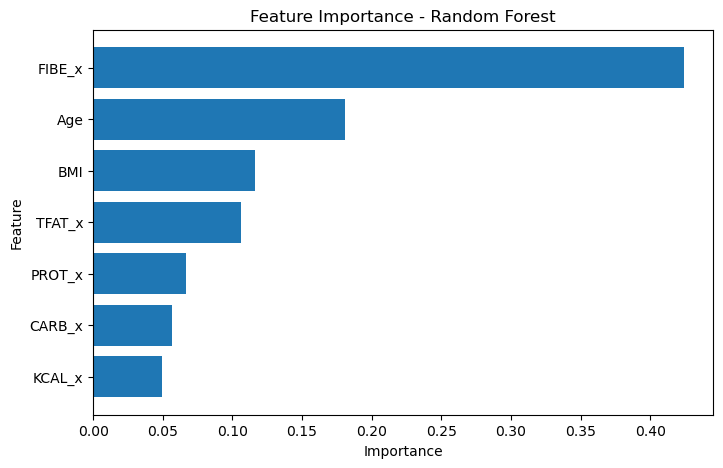

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()

### 5.8 Interpretation of Feature Importance

The Random Forest model identified dietary fiber (FIBE) as the most influential predictor of microbiome stability, with a substantially higher importance score than all other variables.

Age was the second most important predictor, followed by BMI and total fat intake (TFAT).

Protein intake (PROT), carbohydrate intake (CARB), and total caloric intake (KCAL) contributed less to the prediction but still provided useful information.

These results suggest that fiber intake plays a central role in explaining microbiome stability, while participant characteristics such as age and BMI also contribute to microbiome variation.

### 5.9 Final Model Performance

The final Random Forest Regression model was trained using the following predictors:

- KCAL
- PROT
- TFAT
- CARB
- FIBE
- Age
- BMI

The selected target variable was:

- fme_5days_avg

Model performance:

- R² = 0.766
- MAE = 18.54

The model explained approximately 76.6% of the variability in microbiome stability, indicating a strong relationship between nutritional intake, participant characteristics, and microbiome outcomes.

### 5.10 Final Conclusion

This analysis investigated the relationship between nutrition and microbiome stability.

Several microbiome outcome variables were evaluated, including daily FME scores and aggregated FME measures. The 5-day average microbiome stability score (fme_5days_avg) produced the best predictive performance and was therefore selected as the final modeling target.

The Random Forest model achieved strong predictive performance (R² = 0.766), demonstrating that dietary and participant-related factors can explain a substantial proportion of microbiome stability variation.

Among all predictors, dietary fiber emerged as the strongest contributor, highlighting its potential importance in shaping microbiome stability.

Overall, the findings support the hypothesis that nutritional factors are associated with microbiome dynamics and stability.

## 6. Summary of Feature Selection and Modeling Results

In [ ]:
summary_table = pd.DataFrame({
    "Step": [
        "Initial Dataset",
        "Missing Values Check",
        "Pearson Correlation Screening",
        "Spearman Correlation Screening",
        "Random Forest Screening - Shannon",
        "Random Forest Screening - FME",
        "Biological Feature Selection",
        "Target Comparison",
        "Final Model",
        "Final Feature Importance"
    ],
    
    "Method": [
        "Dataset Overview",
        "Data Quality Check",
        "Correlation Analysis",
        "Correlation Analysis",
        "Random Forest Feature Importance",
        "Random Forest Feature Importance",
        "Literature-Based Selection",
        "Random Forest Regression",
        "Random Forest Regression",
        "Random Forest Feature Importance"
    ],
    
    "Main Result": [
        "Nutrition dataset contained 107 columns and 104 numeric nutritional variables.",
        "No missing values were found in the nutrition dataset.",
        "All correlations with Shannon diversity were weak; highest correlation was around 0.17.",
        "Spearman correlations were also weak, indicating no strong monotonic relationship.",
        "Top predictors for Shannon were not the classical macronutrients.",
        "FIBE showed stronger importance for FME compared to the other selected biological features.",
        "Final biological features: KCAL, PROT, TFAT, CARB, FIBE, Age, BMI.",
        "fme_5days_avg achieved the best predictive performance among FME targets.",
        "Final model achieved R² = 0.766 and MAE = 18.54.",
        "FIBE was the most important predictor, followed by Age, BMI, and TFAT."
    ],
    
    "Conclusion": [
        "Feature selection was necessary due to the large number of nutritional variables.",
        "No features were removed due to missing values.",
        "Correlation alone was not sufficient for feature selection.",
        "Linear/monotonic relationships were weak, so model-based evaluation was needed.",
        "Microbiome outcomes are likely influenced by complex and non-linear patterns.",
        "Fiber was supported statistically and biologically.",
        "Final features were selected using biological relevance supported by statistical validation.",
        "A 5-day FME average better captured microbiome stability than daily FME.",
        "The selected features explained a substantial part of microbiome stability variation.",
        "Fiber appears to be the strongest contributor to microbiome stability in the final model."
    ]
})

summary_table

,Step,Method,Main Result,Conclusion
0,Initial Dataset,Dataset Overview,Nutrition dataset contained 107 columns and 10...,Feature selection was necessary due to the lar...
1,Missing Values Check,Data Quality Check,No missing values were found in the nutrition ...,No features were removed due to missing values.
2,Pearson Correlation Screening,Correlation Analysis,All correlations with Shannon diversity were w...,Correlation alone was not sufficient for featu...
3,Spearman Correlation Screening,Correlation Analysis,"Spearman correlations were also weak, indicati...","Linear/monotonic relationships were weak, so m..."
4,Random Forest Screening - Shannon,Random Forest Feature Importance,Top predictors for Shannon were not the classi...,Microbiome outcomes are likely influenced by c...
5,Random Forest Screening - FME,Random Forest Feature Importance,FIBE showed stronger importance for FME compar...,Fiber was supported statistically and biologic...
6,Biological Feature Selection,Literature-Based Selection,"Final biological features: KCAL, PROT, TFAT, C...",Final features were selected using biological ...
7,Target Comparison,Random Forest Regression,fme_5days_avg achieved the best predictive per...,A 5-day FME average better captured microbiome...
8,Final Model,Random Forest Regression,Final model achieved R² = 0.766 and MAE = 18.54.,The selected features explained a substantial ...
9,Final Feature Importance,Random Forest Feature Importance,"FIBE was the most important predictor, followe...",Fiber appears to be the strongest contributor ...


## 6.1 Quantitative Summary of Statistical Screening and Modeling

In [ ]:
quantitative_summary = pd.DataFrame({
    "Stage": [
        "Merged Dataset",
        "Pearson Correlation (Shannon)",
        "Spearman Correlation (Shannon)",
        "KCAL Correlation",
        "PROT Correlation",
        "TFAT Correlation",
        "CARB Correlation",
        "FIBE Correlation",
        "Target: fme_score_daily",
        "Target: fme_3days_avg",
        "Target: fme_5days_avg",
        "Target: fme_weighted",
        "Final Random Forest"
    ],

    "Metric": [
        "Samples",
        "Highest Correlation",
        "Highest Correlation",
        "Pearson r",
        "Pearson r",
        "Pearson r",
        "Pearson r",
        "Pearson r",
        "R²",
        "R²",
        "R²",
        "R²",
        "R²"
    ],

    "Value": [
        475,
        0.170,
        0.170,
        0.067,
        0.059,
        0.007,
        0.070,
        0.054,
        0.408,
        0.692,
        0.766,
        0.649,
        0.766
    ]
})

quantitative_summary

,Stage,Metric,Value
0,Merged Dataset,Samples,475.000
1,Pearson Correlation (Shannon),Highest Correlation,0.170
2,Spearman Correlation (Shannon),Highest Correlation,0.170
3,KCAL Correlation,Pearson r,0.067
4,PROT Correlation,Pearson r,0.059
5,TFAT Correlation,Pearson r,0.007
6,CARB Correlation,Pearson r,0.070
7,FIBE Correlation,Pearson r,0.054
8,Target: fme_score_daily,R²,0.408
9,Target: fme_3days_avg,R²,0.692


In [ ]:
final_features_summary = pd.DataFrame({
    "Feature": ["FIBE", "Age", "BMI", "TFAT", "PROT", "CARB", "KCAL"],
    "Importance": [0.42, 0.18, 0.12, 0.11, 0.07, 0.06, 0.05]
})

final_features_summary

,Feature,Importance
0,FIBE,0.42
1,Age,0.18
2,BMI,0.12
3,TFAT,0.11
4,PROT,0.07
5,CARB,0.06
6,KCAL,0.05


# Notebook: `Merge_data_Analysis.ipynb`

In [ ]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
sns.set_theme(style="whitegrid")


In [ ]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


EDA on people data

## Summary

This notebook profiles the dietary records and participant metadata.

The analysis includes:
- Loading daily dietary records from `nutrition_totals.txt`.
- Selecting key dietary variables: calories (`KCAL`), fiber (`FIBE`), carbohydrates (`CARB`), and total fat (`TFAT`).
- Calculating missing-value percentages for dietary variables.
- Visualizing missing values using `missingno`.
- Aggregating dietary records into average intake per participant.
- Loading participant metadata from `food_map.txt`.
- Adding participant-level characteristics: `Age` and `BMI`.
- Plotting histograms and boxplots for nutrient intake and participant characteristics.

These variables can later be used as control variables / confounders in downstream microbiome analysis.

In [ ]:
# Define file paths

nutrition_path = DATA_DIR / "dietstudy_analyses-master" / "data" / "diet" / "nutrition_totals.txt"
metadata_path  = DATA_DIR / "dietstudy_analyses-master" / "data" / "maps" / "food_map.txt"

print("Nutrition path exists:", nutrition_path.exists())
print("Nutrition path:", nutrition_path)

print("Metadata path exists:", metadata_path.exists())
print("Metadata path:", metadata_path)


Nutrition path exists: True
Nutrition path: c:\Users\mayag\PythonForuni\ProjectYear3\data\dietstudy_analyses-master\data\diet\nutrition_totals.txt
Metadata path exists: True
Metadata path: c:\Users\mayag\PythonForuni\ProjectYear3\data\dietstudy_analyses-master\data\maps\food_map.txt


In [ ]:
# Load the nutrition totals data

df_nutrients = pd.read_csv(nutrition_path, sep="\t")

df_nutrients.columns = df_nutrients.columns.str.strip()

print("Nutrients shape:", df_nutrients.shape)

display(df_nutrients.head())

print("Nutrient columns:")
print(df_nutrients.columns.tolist())

Nutrients shape: (580, 107)


,X.SampleID,UserName,StudyDayNo,RecordDayNo,KCAL,PROT,TFAT,CARB,MOIS,ALC,...,PF_LEGUMES,D_TOTAL,D_MILK,D_YOGURT,D_CHEESE,OILS,SOLID_FATS,ADD_SUGARS,A_DRINKS,Replicate
0,MCT.f.0001,MCTs01,Day.01,1,1707.040193,95.668747,55.185318,187.965353,3848.605502,14.95872,...,0.0,3.265577,2.05776,0.646,0.561817,14.668870,21.795872,4.822350,1.072512,1
1,MCT.f.0002,MCTs01,Day.02,2,1970.043625,109.619765,53.615264,242.919015,3808.005721,14.04000,...,0.0,4.156035,2.35656,0.646,1.153475,15.886225,19.139825,4.325970,1.008000,1
2,MCT.f.0003,MCTs01,Day.03,3,1714.895330,89.992993,50.561373,234.225138,4183.622433,0.00000,...,0.0,2.979655,1.12608,0.646,1.207575,11.836920,17.711575,4.758330,0.000000,1
3,MCT.f.0004,MCTs01,Day.04,4,2487.232625,94.611953,92.021551,257.539030,4816.211548,42.44800,...,0.0,3.634460,2.15186,0.000,1.482600,55.308100,19.937800,5.917100,3.035200,1
4,MCT.f.0005,MCTs01,Day.05,5,2260.211176,110.268353,95.570253,165.608070,4404.243876,43.93060,...,0.0,3.379710,2.32071,0.000,1.059000,24.231213,54.613613,5.793898,3.116360,1


Nutrient columns:
['X.SampleID', 'UserName', 'StudyDayNo', 'RecordDayNo', 'KCAL', 'PROT', 'TFAT', 'CARB', 'MOIS', 'ALC', 'CAFF', 'THEO', 'SUGR', 'FIBE', 'CALC', 'IRON', 'MAGN', 'PHOS', 'POTA', 'SODI', 'ZINC', 'COPP', 'SELE', 'VC', 'VB1', 'VB2', 'NIAC', 'VB6', 'FOLA', 'FA', 'FF', 'FDFE', 'VB12', 'VARA', 'RET', 'BCAR', 'ACAR', 'CRYP', 'LYCO', 'LZ', 'ATOC', 'VK', 'CHOLE', 'SFAT', 'S040', 'S060', 'S080', 'S100', 'S120', 'S140', 'S160', 'S180', 'MFAT', 'M161', 'M181', 'M201', 'M221', 'PFAT', 'P182', 'P183', 'P184', 'P204', 'P205', 'P225', 'P226', 'VITD', 'CHOLN', 'VITE_ADD', 'B12_ADD', 'F_TOTAL', 'F_CITMLB', 'F_OTHER', 'F_JUICE', 'V_TOTAL', 'V_DRKGR', 'V_REDOR_TOTAL', 'V_REDOR_TOMATO', 'V_REDOR_OTHER', 'V_STARCHY_TOTAL', 'V_STARCHY_POTATO', 'V_STARCHY_OTHER', 'V_OTHER', 'V_LEGUMES', 'G_TOTAL', 'G_WHOLE', 'G_REFINED', 'PF_TOTAL', 'PF_MPS_TOTAL', 'PF_MEAT', 'PF_CUREDMEAT', 'PF_ORGAN', 'PF_POULT', 'PF_SEAFD_HI', 'PF_SEAFD_LOW', 'PF_EGGS', 'PF_SOY', 'PF_NUTSDS', 'PF_LEGUMES', 'D_TOTAL', 'D_MILK

In [ ]:
# Define expected nutrient columns and check which ones are present

nutrient_columns = ["KCAL", "FIBE", "CARB"]

# Try to add fat column automatically if it exists under a common name
fat_candidates = ["FAT", "TFAT", "TotalFat", "Fat", "Total_Fat"]

for col in fat_candidates:
    if col in df_nutrients.columns:
        nutrient_columns.append(col)
        break

existing_nutrient_columns = [col for col in nutrient_columns if col in df_nutrients.columns]

print("Selected nutrient columns:")
print(existing_nutrient_columns)

print("\nMissing expected columns:")
print(set(nutrient_columns) - set(existing_nutrient_columns))

Selected nutrient columns:
['KCAL', 'FIBE', 'CARB', 'TFAT']

Missing expected columns:
set()


In [ ]:
# Analyze missing data in the selected nutrient columns

missing_percentages = (
    df_nutrients[existing_nutrient_columns]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_df = missing_percentages.reset_index()
missing_df.columns = ["Feature", "Missing Percentage"]

display(missing_df)

,Feature,Missing Percentage
0,KCAL,0.0
1,FIBE,0.0
2,CARB,0.0
3,TFAT,0.0


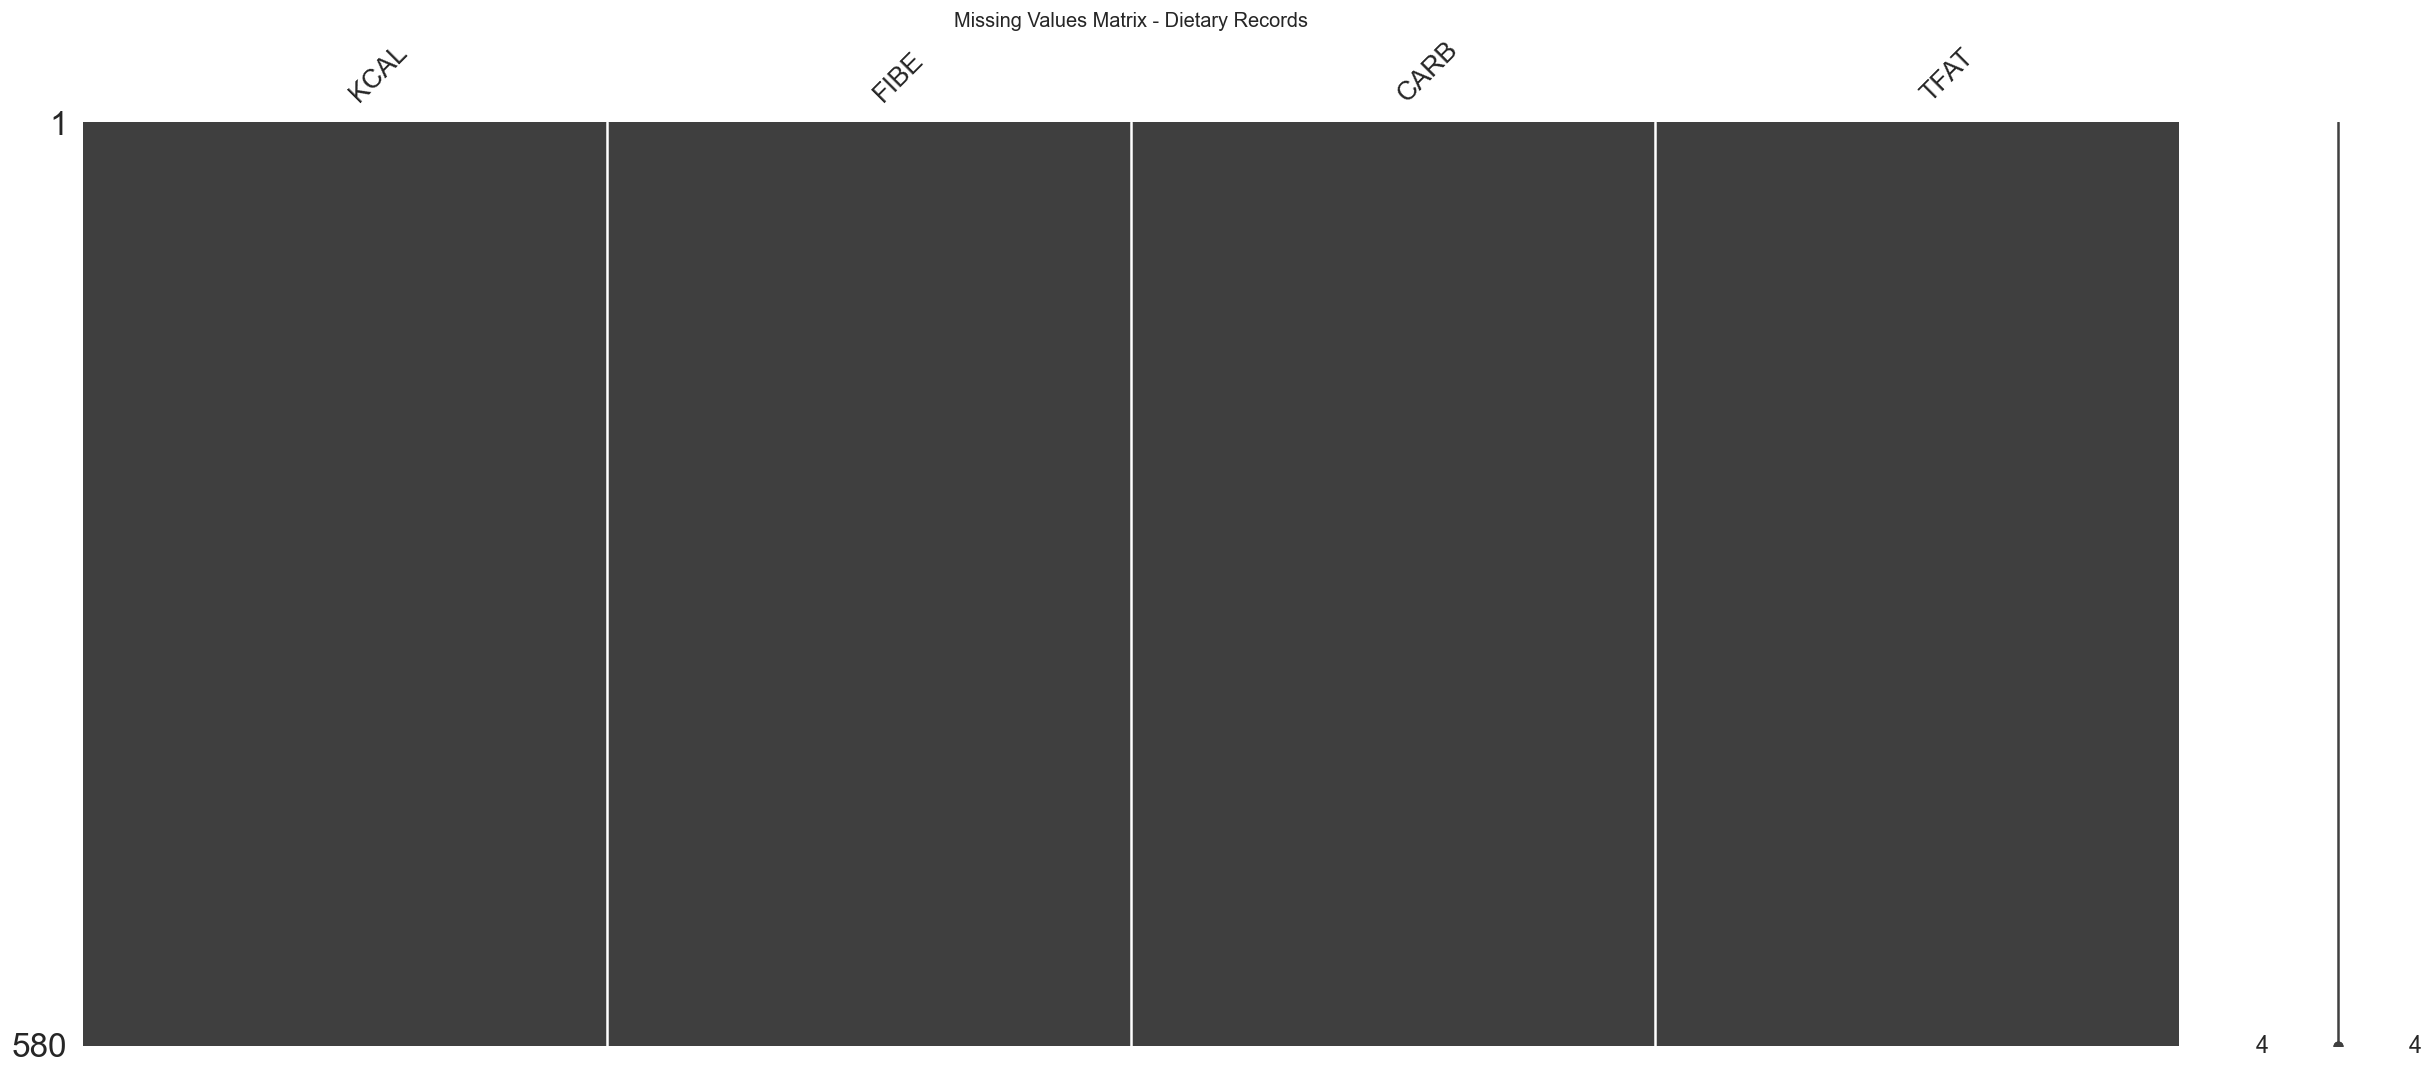

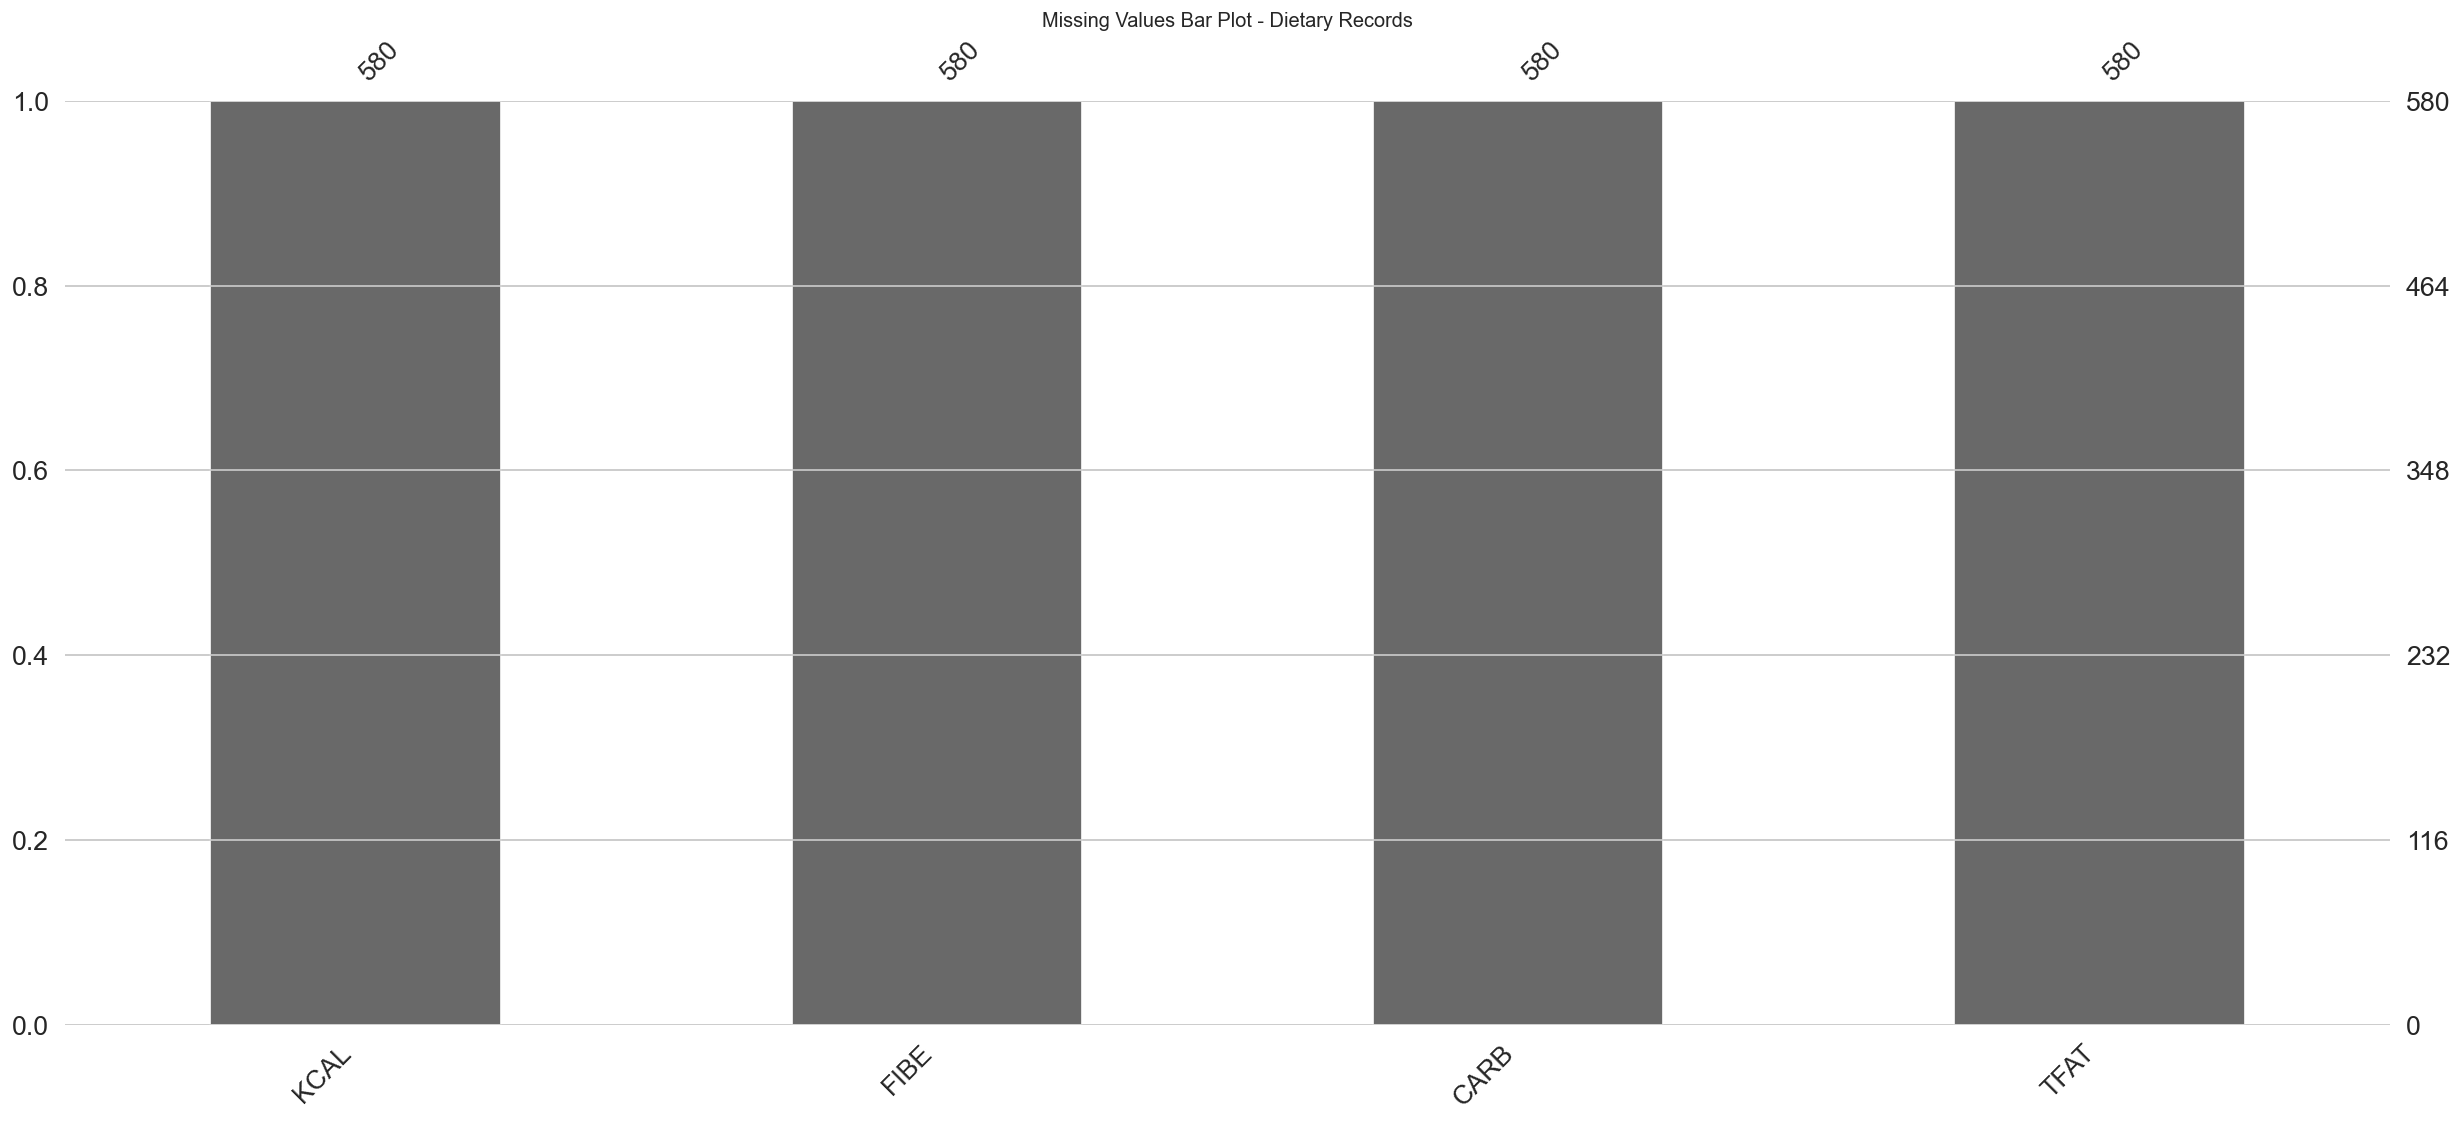

In [ ]:
# Visualize missing data patterns

msno.matrix(df_nutrients[existing_nutrient_columns])
plt.title("Missing Values Matrix - Dietary Records")
plt.show()

msno.bar(df_nutrients[existing_nutrient_columns])
plt.title("Missing Values Bar Plot - Dietary Records")
plt.show()

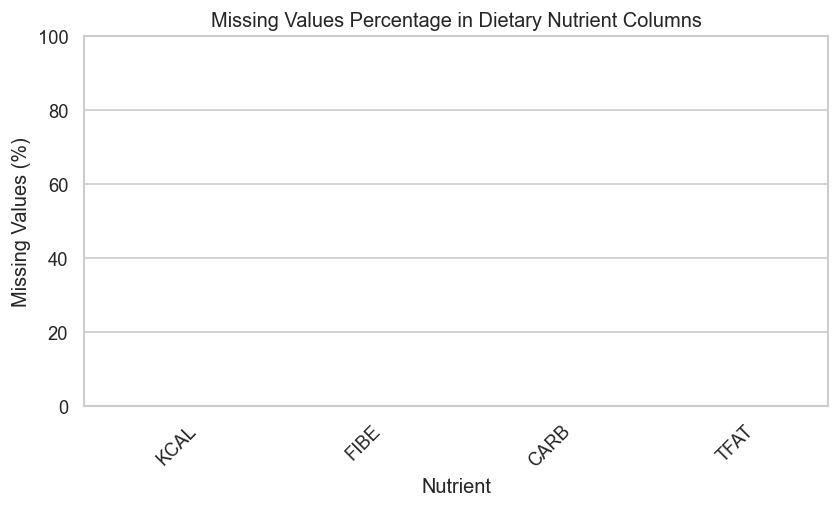

In [ ]:
# Create a bar plot for missing percentages

plt.figure(figsize=(8, 4))
sns.barplot(data=missing_df, x="Feature", y="Missing Percentage")
plt.title("Missing Values Percentage in Dietary Nutrient Columns")
plt.xlabel("Nutrient")
plt.ylabel("Missing Values (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Load participant metadata containing Age and BMI

df_metadata = pd.read_csv(metadata_path, sep="\t")
df_metadata.columns = df_metadata.columns.str.strip()

print("Metadata shape:", df_metadata.shape)
display(df_metadata.head())

print("Metadata columns:")
print(df_metadata.columns.tolist())

Metadata shape: (566, 29)


,#SampleID,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,...,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,MCT.f.0001,MCTs01,1,1/31/17,Tuesday,0,1/30/17,Monday,F,25.9,...,25.0,-0.4,5.0,NaN,54.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
1,MCT.f.0002,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,...,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
2,MCT.f.0003,MCTs01,3,2/2/17,Thursday,2,2/1/17,Wednesday,F,25.9,...,25.0,-0.4,1.0,NaN,59.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
3,MCT.f.0004,MCTs01,4,2/3/17,Friday,3,2/2/17,Thursday,F,25.9,...,25.0,-0.4,5.0,NaN,32.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
4,MCT.f.0005,MCTs01,5,2/4/17,Saturday,4,2/3/17,Friday,F,25.9,...,25.0,-0.4,2.0,Yes,89.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


Metadata columns:
['#SampleID', 'UserName', 'StudyDayNo', 'StudyDate', 'Sample.Week.Day', 'DietDayNo', 'Diet.Record.Date', 'Diet.Week.Day', 'Gender', 'Age', 'Weight', 'Height', 'BMI', 'Supplement', 'Waist.Circumference', 'Study.Status', 'oilGrams.assigned', 'fecal.status', 'fecal.time', 'BMI.1', 'Weight.Change', 'Run1.Plate', 'Run2.Rerun', 'SampleOrder', 'SampleType', 'Timing', 'Activity.Factor', 'Medications', 'Dietary.Supp']


In [ ]:
# Select participant-level metadata columns

profile_columns = ["Age", "BMI"]

df_profile = (
    df_metadata[["UserName"] + profile_columns]
    .drop_duplicates(subset="UserName")
    .copy()
)

print("Profile dataframe shape:", df_profile.shape)
display(df_profile.head())

print("Missing values in profile columns:")
display(df_profile[profile_columns].isnull().mean().mul(100))

Profile dataframe shape: (34, 3)


,UserName,Age,BMI
0,MCTs01,25.9,25.0
17,MCTs03,25.4,26.6
33,MCTs04,24.0,18.9
50,MCTs05,23.1,19.9
57,MCTs06,23.7,22.7


Missing values in profile columns:


Age    0.0
BMI    0.0
dtype: float64

In [ ]:
# Aggregate daily dietary records into average nutrient intake per participant

df_dietary_analysis = (
    df_nutrients
    .groupby("UserName")[existing_nutrient_columns]
    .mean()
    .reset_index()
)

print("Dietary analysis shape:", df_dietary_analysis.shape)
display(df_dietary_analysis.head())

Dietary analysis shape: (37, 5)


,UserName,KCAL,FIBE,CARB,TFAT
0,MCTs01,2233.971687,23.530833,246.315305,72.793184
1,MCTs02,1406.094472,12.205770,102.572981,88.889560
2,MCTs03,3797.839598,32.528277,379.484855,179.378471
3,MCTs04,2554.895951,33.822869,259.635868,123.521241
4,MCTs05,1459.168123,13.046344,193.945721,51.869562


In [ ]:
# Merge dietary averages with participant metadata

df_analysis_full = df_dietary_analysis.merge(
    df_profile,
    on="UserName",
    how="left"
)

print("Full analysis dataframe shape:", df_analysis_full.shape)
display(df_analysis_full.head())

print("Missing values after merge:")
display(df_analysis_full[existing_nutrient_columns + profile_columns].isnull().mean().mul(100))

Full analysis dataframe shape: (37, 7)


,UserName,KCAL,FIBE,CARB,TFAT,Age,BMI
0,MCTs01,2233.971687,23.530833,246.315305,72.793184,25.9,25.0
1,MCTs02,1406.094472,12.205770,102.572981,88.889560,NaN,NaN
2,MCTs03,3797.839598,32.528277,379.484855,179.378471,25.4,26.6
3,MCTs04,2554.895951,33.822869,259.635868,123.521241,24.0,18.9
4,MCTs05,1459.168123,13.046344,193.945721,51.869562,23.1,19.9


Missing values after merge:


KCAL    0.000000
FIBE    0.000000
CARB    0.000000
TFAT    0.000000
Age     8.108108
BMI     8.108108
dtype: float64

In [ ]:
# Missing values summary after merging dietary records with participant metadata

missing_after_merge = (
    df_analysis_full[existing_nutrient_columns + profile_columns]
    .isnull()
    .sum()
    .reset_index()
)

missing_after_merge.columns = ["Feature", "Missing Count"]
missing_after_merge["Missing Percentage"] = (
    missing_after_merge["Missing Count"] / len(df_analysis_full) * 100
)

display(missing_after_merge)

,Feature,Missing Count,Missing Percentage
0,KCAL,0,0.000000
1,FIBE,0,0.000000
2,CARB,0,0.000000
3,TFAT,0,0.000000
4,Age,3,8.108108
5,BMI,3,8.108108


In [ ]:
# Identify participants with dietary records but missing participant metadata

missing_profile_users = df_analysis_full[
    df_analysis_full["Age"].isna() | df_analysis_full["BMI"].isna()
]["UserName"].tolist()

print("Number of participants with missing Age/BMI:", len(missing_profile_users))
print("Participants with missing Age/BMI:")
print(missing_profile_users)

Number of participants with missing Age/BMI: 3
Participants with missing Age/BMI:
['MCTs02', 'MCTs17', 'MCTs30']


In [ ]:
# Compare participants available in dietary records vs. participant metadata

diet_users = set(df_dietary_analysis["UserName"])
profile_users = set(df_profile["UserName"])

users_only_in_diet = sorted(diet_users - profile_users)
users_only_in_profile = sorted(profile_users - diet_users)

print("Number of participants in dietary records:", len(diet_users))
print("Number of participants in metadata:", len(profile_users))

print("\nParticipants found in dietary records but missing from metadata:")
print(users_only_in_diet)

print("\nParticipants found in metadata but missing from dietary records:")
print(users_only_in_profile)

Number of participants in dietary records: 37
Number of participants in metadata: 34

Participants found in dietary records but missing from metadata:
['MCTs02', 'MCTs17', 'MCTs30']

Participants found in metadata but missing from dietary records:
[]


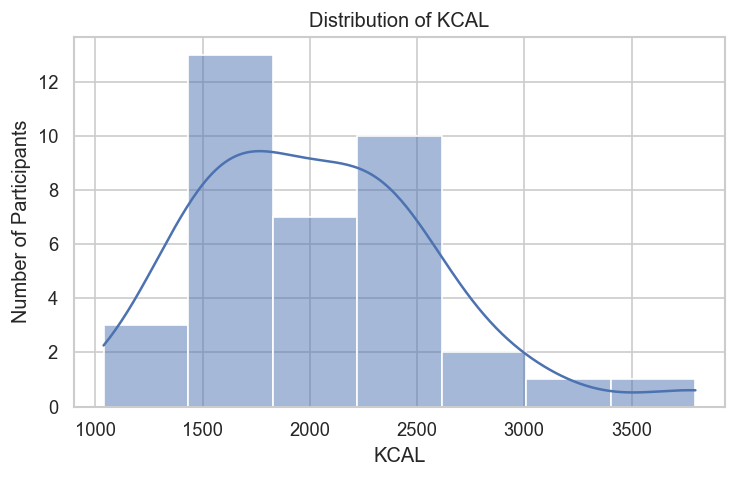

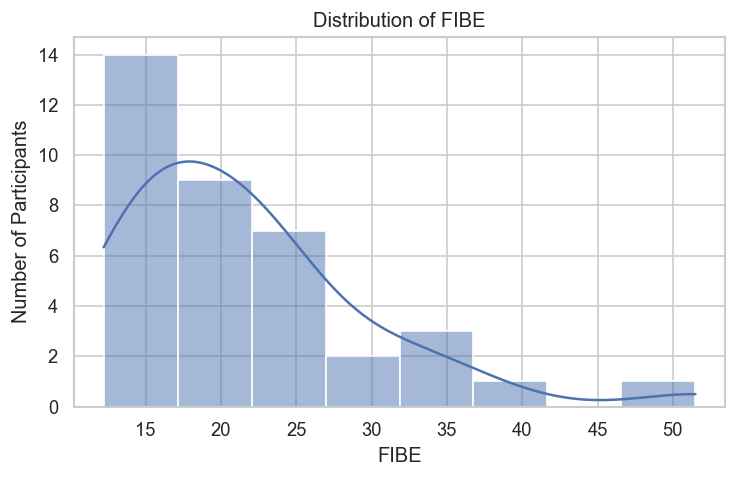

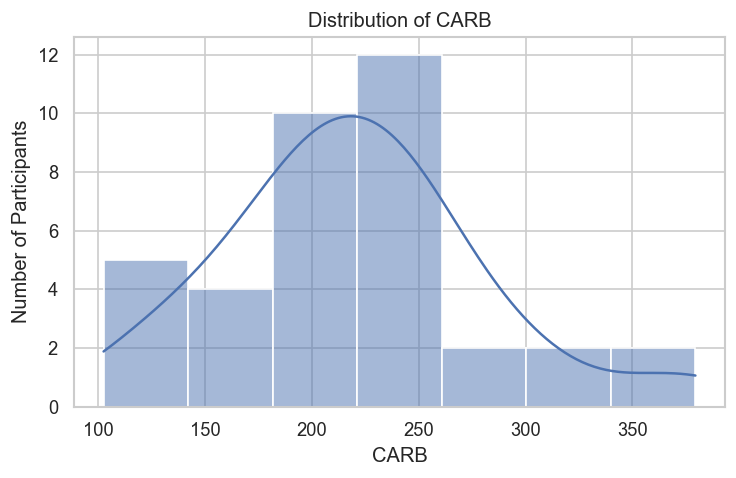

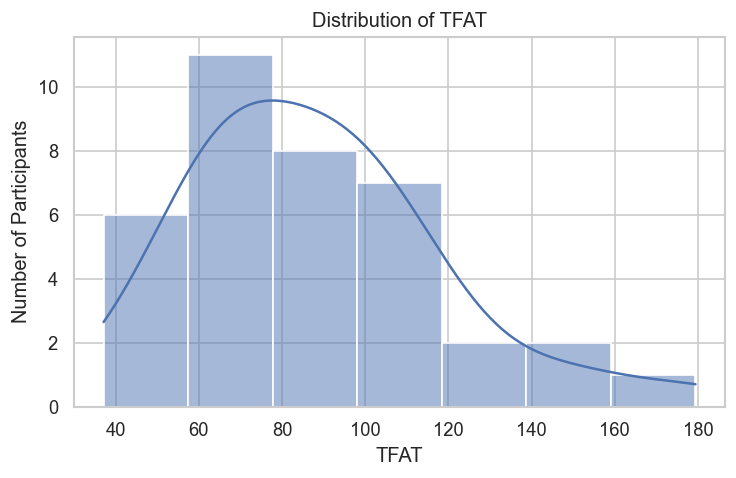

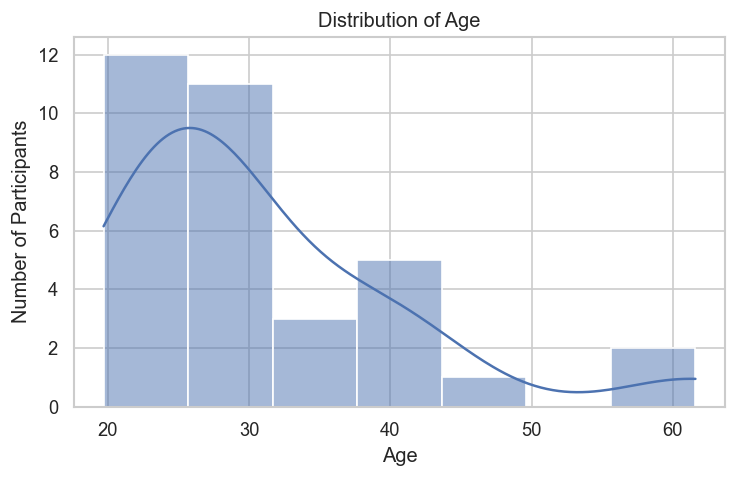

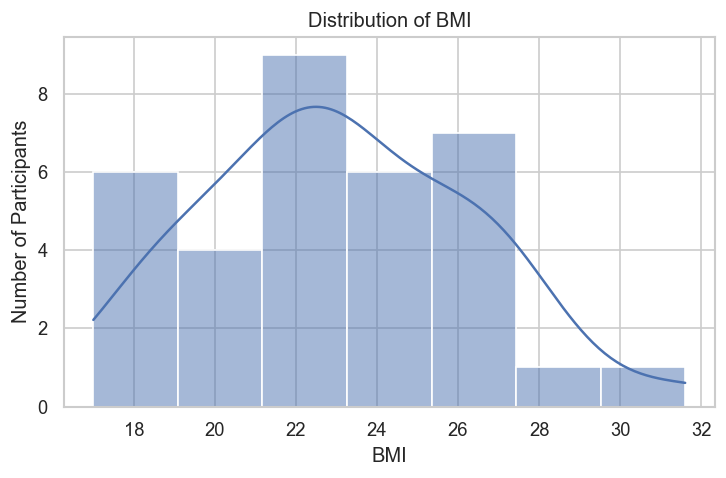

In [ ]:
# Histograms for nutrient intake and participant characteristics

analysis_columns = existing_nutrient_columns + profile_columns

for col in analysis_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_analysis_full[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Participants")
    plt.show()

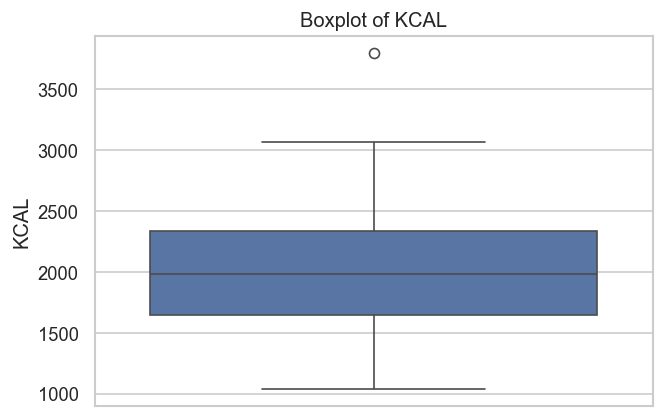

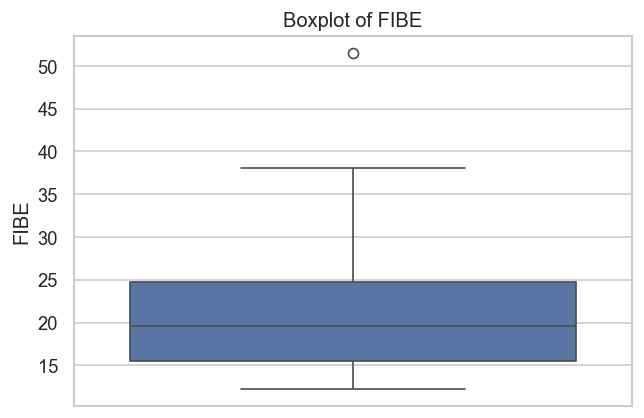

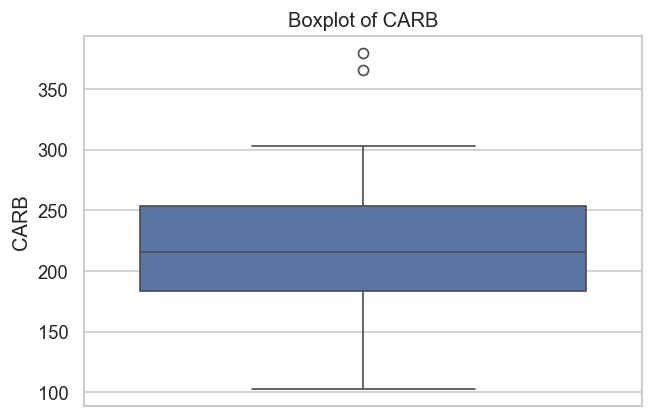

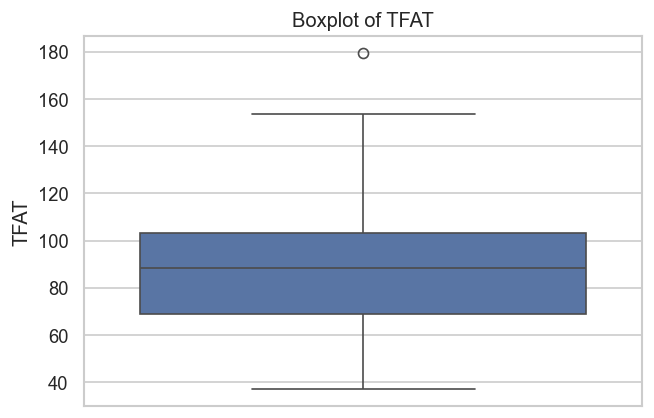

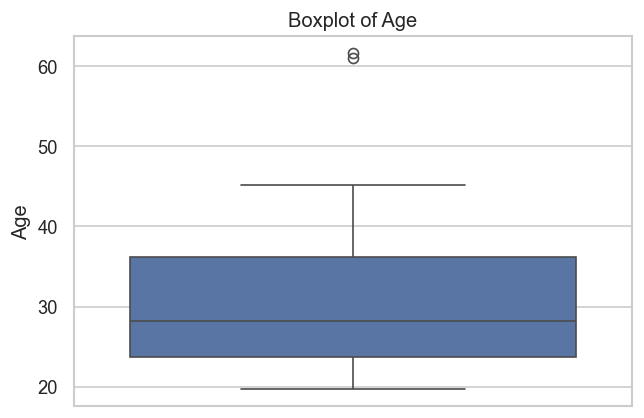

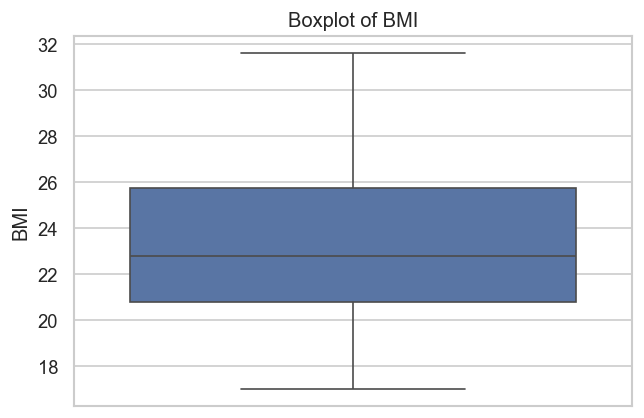

In [ ]:
# Boxplots for nutrient intake and participant characteristics

for col in analysis_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_analysis_full[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
# Create a complete-case dataset for analyses requiring participant metadata

df_analysis_complete = df_analysis_full.dropna(subset=["Age", "BMI"]).copy()

print("Original merged dataset shape:", df_analysis_full.shape)
print("Complete-case dataset shape:", df_analysis_complete.shape)

display(df_analysis_complete.head())

Original merged dataset shape: (37, 7)
Complete-case dataset shape: (34, 7)


,UserName,KCAL,FIBE,CARB,TFAT,Age,BMI
0,MCTs01,2233.971687,23.530833,246.315305,72.793184,25.9,25.0
2,MCTs03,3797.839598,32.528277,379.484855,179.378471,25.4,26.6
3,MCTs04,2554.895951,33.822869,259.635868,123.521241,24.0,18.9
4,MCTs05,1459.168123,13.046344,193.945721,51.869562,23.1,19.9
5,MCTs06,2821.157393,25.010255,300.566053,119.229383,23.7,22.7


In [ ]:
# Descriptive statistics for dietary and participant-level variables

summary_stats = df_analysis_full[analysis_columns].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
KCAL,37.0,2033.297533,555.341419,1038.411469,1647.969946,1986.314418,2338.837036,3797.839598
FIBE,37.0,21.501996,8.227874,12.205770,15.555740,19.614496,24.741995,51.493771
CARB,37.0,219.889581,60.207579,102.572981,183.135589,215.304862,253.876709,379.484855
TFAT,37.0,88.114532,30.307293,37.064239,68.770390,88.392512,103.046069,179.378471
Age,34.0,30.823529,10.263264,19.700000,23.750000,28.200000,36.125000,61.600000
BMI,34.0,23.091176,3.315470,17.000000,20.800000,22.800000,25.750000,31.600000


In [ ]:
# Descriptive statistics for dietary and participant-level variables without missing metadata


summary_stats = df_analysis_complete[analysis_columns].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
KCAL,34.0,2080.282967,554.371204,1038.411469,1720.475921,2053.170958,2381.937003,3797.839598
FIBE,34.0,21.914465,8.363119,12.578621,16.016949,20.144428,24.943190,51.493771
CARB,34.0,226.308557,57.376045,118.539338,194.193916,224.196062,255.340657,379.484855
TFAT,34.0,89.682832,30.884412,37.064239,69.391504,89.026639,105.218414,179.378471
Age,34.0,30.823529,10.263264,19.700000,23.750000,28.200000,36.125000,61.600000
BMI,34.0,23.091176,3.315470,17.000000,20.800000,22.800000,25.750000,31.600000


EDA on CFMD 

# CFMD Food Microbiome Analysis

**Data source:** CuratedFoodMetagenomicData (CFMD)
- `cFMD-main/cFMD-main/cFMD_metadata.tsv` — sample metadata with `category`, `sample_id`
- `cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv` — per-dataset abundance matrices

**Tasks:**
1. Explore CFMD and analyze food microbial richness per category
2. Check species overlap between the top-2 richest categories

## Cell 1 — Setup and Metadata Loading

=== CFMD Metadata ===
Shape   : (3444, 32)
Columns : ['dataset_name', 'sample_id', 'macrocategory', 'category', 'type', 'subtype', 'commercial_name', 'fermented/non-fermented', 'country', 'sample_accession', 'run_accession', 'experiment_accession', 'study_accession', 'project_accession', 'database_origin', 'library_layout', 'sequencing_platform', 'DNA_extraction_kit', 'collection_date', 'n_of_bases', 'n_of_reads', 'min_read_len', 'median_read_len', 'mean_read_len', 'max_read_len', 'n_contigs', 'n_MAGs_MQ_prok', 'n_MAGs_HQ_prok', 'n_MAGs_MQ_euk', 'n_MAGs_HQ_euk', 'filtered', 'curator']

'category' — 15 unique values:
category
dairy                              2296
fermented_beverages                 435
fermented_meat                      157
meat                                119
fish                                 93
fermented_grains                     83
fermented_seeds                      65
fermented_fruits_and_vegetables      52
alcohol                              48
fruits_

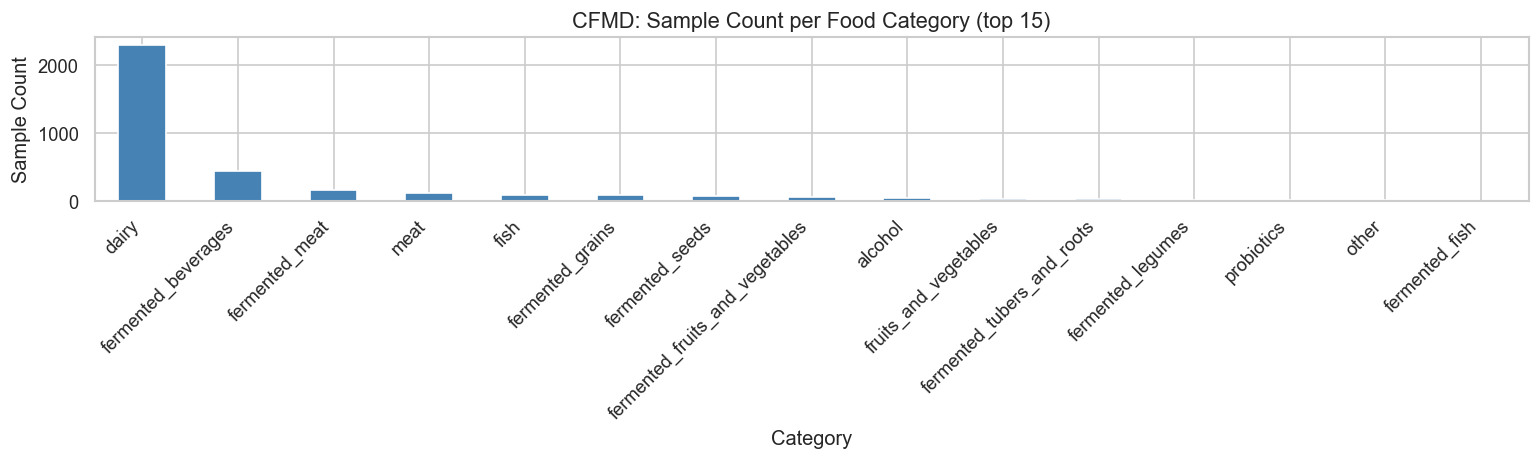

Plot saved → category_distribution.png

Macrocategory counts:
macrocategory
food    3444

Sequencing platform counts:
sequencing_platform
Illumina_NovaSeq_6000          1616
NextSeq_500                    1053
Illumina_MiSeq                  283
HiSeq X Ten                     119
Illumina_HiSeq_2500             102
Illumina_HiSeq_4000              75
NextSeq_550                      71
Illumina_HiSeq_2000              41
HiSeq_X_Ten                      20
Illumina_HiSeq_1500              15
Illumina_HiSeq_XTen              14
Illumina HiSeq 4000              13
Ion_Torrent_PGM                  10
Illumina NovaSeq 6000             4
Illumina MiSeq                    2
Illumina_Genome_Analyzer_II       2
Illumina_HiSeq_1000               2
Sequel;Illumina_MiSeq             1
Illumina HiSeq X                  1


In [ ]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Load metadata ─────────────────────────────────────────────────────────────
#metadata = pd.read_csv(DATA_DIR / 'cFMD-main' / 'cFMD-main' / 'cFMD_metadata.tsv', sep='\t')
metadata = pd.read_csv(DATA_DIR / 'cFMD-main' / 'cFMD-main' / 'cFMD_metadata.tsv', sep='\t')
metadata.columns = metadata.columns.astype(str).str.strip()
metadata['sample_id'] = metadata['sample_id'].astype(str).str.strip()

print('=== CFMD Metadata ===')
print(f'Shape   : {metadata.shape}')
print(f'Columns : {metadata.columns.tolist()}')
print()

# ── EDA: category distribution ────────────────────────────────────────────────
cat_counts = metadata['category'].value_counts()
print(f"'category' — {cat_counts.shape[0]} unique values:")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(13, 4))
cat_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('CFMD: Sample Count per Food Category (top 15)', fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → category_distribution.png')

# ── EDA: macrocategory distribution ──────────────────────────────────────────
print()
print('Macrocategory counts:')
print(metadata['macrocategory'].value_counts().to_string())

# ── EDA: sequencing platform ──────────────────────────────────────────────────
print()
print('Sequencing platform counts:')
print(metadata['sequencing_platform'].value_counts().to_string())

## Cell 2 — Load Taxonomic Profiles and Merge with Metadata

Each `*_taxonomic_profiles.tsv` file is a wide matrix: rows = taxa, columns = samples.
Column names are formatted as `DatasetName__SampleAccession`.
We extract the accession part (after `__`) to match `sample_id` in the metadata.

In [ ]:
# profile_files = glob.glob(
#     './cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv',
#     recursive=True
# )
profile_files = glob.glob(
    str(DATA_DIR / 'cFMD-main' / 'cFMD-main' / 'cFMD_data' / '**' / '*_taxonomic_profiles.tsv'),
    recursive=True
)
print(f'Found {len(profile_files)} taxonomic profile files')

all_profiles = []
skipped = []

for path in profile_files:
    try:
        df = pd.read_csv(path, sep='\t')
        # First column is always the taxonomy column
        tax_col = df.columns[0]
        df = df.rename(columns={tax_col: '#taxonomy'})

        # Melt wide → long
        long = df.melt(
            id_vars=['#taxonomy'],
            var_name='sample_col',
            value_name='abundance'
        )

        # Column names: 'DatasetName__SampleAccession' → extract accession after '__'
        long['sample_id'] = long['sample_col'].str.split('__').str[-1]
        long = long.drop(columns=['sample_col'])
        all_profiles.append(long)

    except Exception as e:
        skipped.append((path, str(e)))

if skipped:
    print(f'\nSkipped {len(skipped)} files:')
    for p, e in skipped:
        print(f'  {p}: {e}')

# Combine all datasets
long_df = pd.concat(all_profiles, ignore_index=True)
long_df['sample_id'] = long_df['sample_id'].astype(str).str.strip()
long_df['abundance'] = pd.to_numeric(long_df['abundance'], errors='coerce').fillna(0)

print(f'\nCombined long-format shape : {long_df.shape}')
print(f'Unique sample IDs in profiles : {long_df["sample_id"].nunique()}')
print(f'Unique taxa in profiles       : {long_df["#taxonomy"].nunique()}')


# ── Merge with metadata ───────────────────────────────────────────────────────
merged = long_df.merge(
    metadata[['sample_id', 'category', 'macrocategory', 'country', 'fermented/non-fermented']],
    on='sample_id',
    how='left'
)

# Filter: keep only rows with positive abundance
merged_filtered = merged[merged['abundance'] > 0].copy()

print(f'\nRows after filtering (abundance > 0) : {len(merged_filtered):,}')
print(f'Unique taxa retained                 : {merged_filtered["#taxonomy"].nunique()}')
print(f'Missing category (unmatched samples) : {merged_filtered["category"].isna().sum():,}')
print(f'Categories present                   : {merged_filtered["category"].nunique()}')
print()
print('Sample category distribution:')
print(merged_filtered.dropna(subset=['category'])["category"].value_counts().to_string())

display(merged_filtered.head())

Found 85 taxonomic profile files

Combined long-format shape : (1614609, 3)
Unique sample IDs in profiles : 3392
Unique taxa in profiles       : 5057

Rows after filtering (abundance > 0) : 94,491
Unique taxa retained                 : 5051
Missing category (unmatched samples) : 0
Categories present                   : 15

Sample category distribution:
category
dairy                              57653
fermented_beverages                 7663
fermented_meat                      5649
meat                                4976
fish                                4558
fermented_seeds                     4537
fruits_and_vegetables               2883
fermented_fruits_and_vegetables     1637
fermented_tubers_and_roots          1465
fermented_grains                    1161
alcohol                              944
fermented_legumes                    936
other                                223
probiotics                           114
fermented_fish                        92


,#taxonomy,abundance,sample_id,category,macrocategory,country,fermented/non-fermented
0,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.14109,SRR8742576,fermented_seeds,food,BRA,F
3,k__Bacteria|p__Pseudomonadota|c__Gammaproteoba...,0.10390,SRR8742576,fermented_seeds,food,BRA,F
7,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,14.74891,SRR8742576,fermented_seeds,food,BRA,F
12,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.33599,SRR8742576,fermented_seeds,food,BRA,F
20,k__Eukaryota|p__Ascomycota|c__Saccharomycetes|...,0.89747,SRR8742576,fermented_seeds,food,BRA,F


## Cell 3 — Task 1: Microbial Richness per Food Category

**Richness** = number of unique taxa with abundance > 0 per food category.

=== Microbial Richness per Food Category ===
                       category  microbial_richness
                          dairy                2967
                 fermented_meat                 854
          fruits_and_vegetables                 823
            fermented_beverages                 751
                fermented_seeds                 718
     fermented_tubers_and_roots                 699
fermented_fruits_and_vegetables                 529
                           fish                 490
                           meat                 380
              fermented_legumes                 368
               fermented_grains                 361
                        alcohol                 330
                          other                 158
                 fermented_fish                  44
                     probiotics                  36


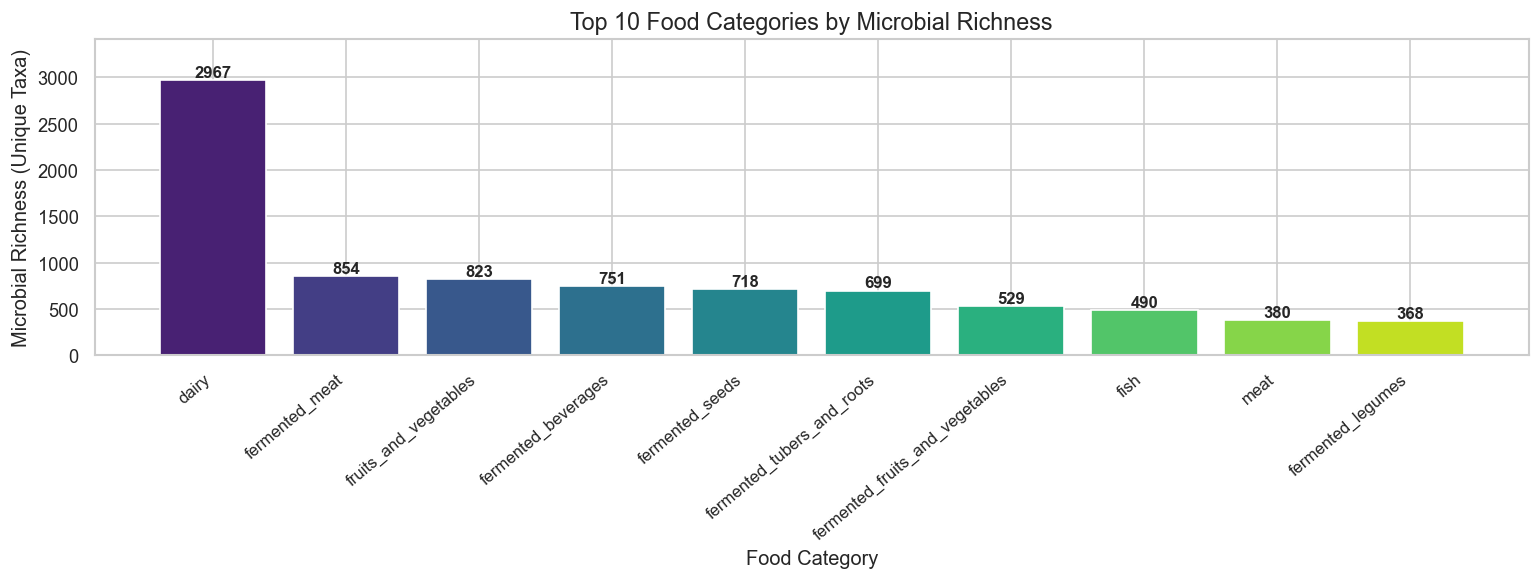

Plot saved → richness_by_category.png


In [ ]:
# Guard: verify merge succeeded
if 'category' not in merged_filtered.columns or merged_filtered['category'].isna().all():
    raise RuntimeError('category data is missing — merge did not succeed. Fix Cell 2.')

richness = (
    merged_filtered
    .dropna(subset=['category'])
    .groupby('category')['#taxonomy']
    .nunique()
    .reset_index(name='microbial_richness')
    .sort_values('microbial_richness', ascending=False)
    .reset_index(drop=True)
)

print('=== Microbial Richness per Food Category ===')
print(richness.to_string(index=False))

# ── Bar chart: top 10 ─────────────────────────────────────────────────────────
top10   = richness.head(10)
palette = sns.color_palette('viridis', len(top10))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    top10['category'],
    top10['microbial_richness'],
    color=palette,
    edgecolor='white'
)
for bar, val in zip(bars, top10['microbial_richness']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(val)),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Top 10 Food Categories by Microbial Richness', fontsize=14)
ax.set_xlabel('Food Category', fontsize=12)
ax.set_ylabel('Microbial Richness (Unique Taxa)', fontsize=12)
ax.set_ylim(0, top10['microbial_richness'].max() * 1.15)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / 'richness_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → richness_by_category.png')

## Cell 4 — Task 2: Species Overlap between Top-2 Categories (Venn Diagram)

We compare the two richest food categories using a Venn diagram and the Jaccard similarity index.

Comparing: 'dairy'  vs  'fermented_meat'

Species unique to 'dairy'  : 2,346
Species unique to 'fermented_meat'  : 233
Shared species              : 621
Jaccard similarity index    : 0.1941

Top shared species (last taxonomic level):
  t__SGB257
  t__SGB203
  t__SGB282
  t__SGB39400
  t__SGB33761
  t__SGB23979
  t__SGB98684
  t__SGB86828
  t__SGB17183
  t__SGB17232
  t__SGB93302
  t__SGB98927
  t__SGB99001
  t__SGB99002
  t__SGB16645
  t__SGB98807
  t__SGB16638
  t__SGB98794
  t__SGB16639
  t__SGB88049
  ... and 601 more


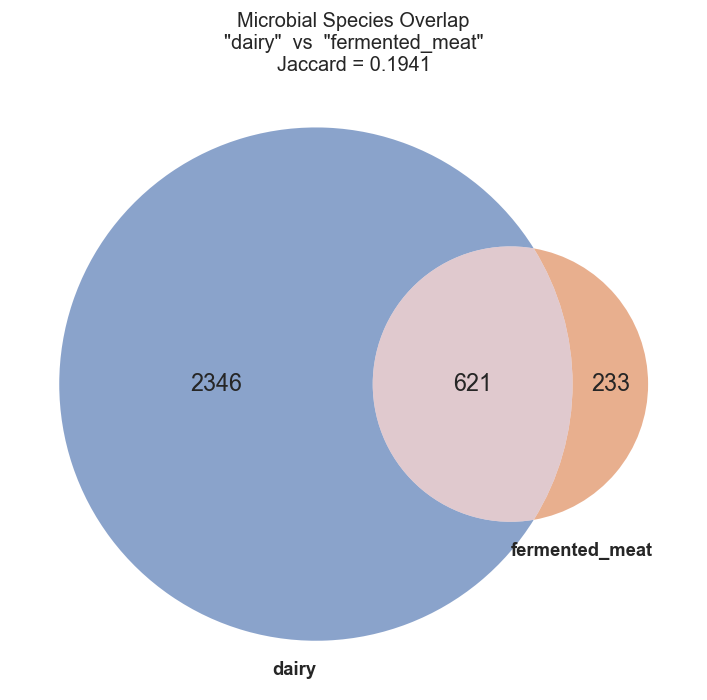

Plot saved → venn_species_overlap.png


In [ ]:
try:
    from matplotlib_venn import venn2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib-venn', '-q'])
    from matplotlib_venn import venn2

cat1, cat2 = richness.head(2)['category'].tolist()
print(f"Comparing: '{cat1}'  vs  '{cat2}'")

sp1    = set(merged_filtered.loc[merged_filtered['category'] == cat1, '#taxonomy'].unique())
sp2    = set(merged_filtered.loc[merged_filtered['category'] == cat2, '#taxonomy'].unique())
shared = sp1 & sp2
union  = sp1 | sp2

print(f"\nSpecies unique to '{cat1}'  : {len(sp1 - sp2):,}")
print(f"Species unique to '{cat2}'  : {len(sp2 - sp1):,}")
print(f"Shared species              : {len(shared):,}")
print(f"Jaccard similarity index    : {len(shared) / len(union):.4f}")

if shared:
    print(f'\nTop shared species (last taxonomic level):')
    for s in sorted(shared)[:20]:  # show first 20
        sep   = '|' if '|' in s else ';'
        label = s.split(sep)[-1].strip()
        print(f'  {label}')
    if len(shared) > 20:
        print(f'  ... and {len(shared) - 20} more')

# ── Venn diagram ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
v = venn2(
    subsets=[sp1, sp2],
    set_labels=(cat1, cat2),
    ax=ax,
    set_colors=('#4C72B0', '#DD8452'),
    alpha=0.65
)
for region_id in ('10', '01', '11'):
    lbl = v.get_label_by_id(region_id)
    if lbl:
        lbl.set_fontsize(14)
for set_lbl in v.set_labels:
    if set_lbl:
        set_lbl.set_fontsize(11)
        set_lbl.set_fontweight('bold')

ax.set_title(
    f'Microbial Species Overlap\n"{cat1}"  vs  "{cat2}"\nJaccard = {len(shared)/len(union):.4f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig(DATA_DIR / 'venn_species_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → venn_species_overlap.png')

# Loading and Exploring the Paper 1 Microbiome Dataset

In [ ]:
import pandas as pd
import os

base = DATA_DIR / "dietstudy_analyses-master" / "data"

print(base)
print("Base exists:", os.path.exists(base))

microbiome = pd.read_csv(
    base / "microbiome/processed_sample/taxonomy_counts_s.txt",
    sep="\t",
    index_col=0
)

sample_meta = pd.read_csv(
    base / "maps/food_map.txt",
    sep="\t"
).rename(columns={"#SampleID": "SampleID"})

diet_raw = pd.read_csv(
    base / "diet/processed_food/dhydrt.txt",
    sep="\t",
    index_col=0
)

diet_decay = pd.read_csv(
    base / "diet/processed_food/masterdecaydiet.txt",
    sep="\t",
    index_col=0
)

nutrition_totals = pd.read_csv(
    base / "diet/nutrition_totals.txt",
    sep="\t",
    index_col=0
)

microbiome_clr = pd.read_csv(
    base / "microbiome/processed_sample/taxonomy_clr_s.txt",
    sep="\t",
    index_col=0
)

diet_fiber = pd.read_csv(
    base / "diet/diet.fiber.txt",
    sep="\t",
    index_col=0
)

fiber_avg = pd.read_csv(
    base / "diet/fiber/fiber.smry.otu.txt",
    sep="\t",
    index_col=0
)

micro_avg_counts = pd.read_csv(
    base / "microbiome/processed_average/UN_taxonomy_counts_s.txt",
    sep="\t",
    index_col=0
)

micro_avg_clr = pd.read_csv(
    base / "microbiome/processed_average/UN_taxonomy_clr_s.txt",
    sep="\t",
    index_col=0
)

micro_avg_norm = pd.read_csv(
    base / "microbiome/processed_average/UN_taxonomy_norm_s.txt",
    sep="\t",
    index_col=0
)

print("=== microbiome ===")
print(microbiome.shape)
print(microbiome.head())

print("=== sample_meta ===")
print(sample_meta.shape)
print(sample_meta.head())

print("=== diet_raw ===")
print(diet_raw.shape)
print(diet_raw.head())

print("=== diet_decay ===")
print(diet_decay.shape)
print(diet_decay.head())

print("=== nutrition_totals ===")
print(nutrition_totals.shape)
print(nutrition_totals.head())

print("=== microbiome_clr ===")
print(microbiome_clr.shape)
print(microbiome_clr.head())

print("=== diet_fiber ===")
print(diet_fiber.shape)
print(diet_fiber.head())

print("=== fiber_avg ===")
print(fiber_avg.shape)
print(fiber_avg.head())

print("=== micro_avg_counts ===")
print(micro_avg_counts.shape)
print(micro_avg_counts.head())

print("=== micro_avg_clr ===")
print(micro_avg_clr.shape)
print(micro_avg_clr.head())

print("=== micro_avg_norm ===")
print(micro_avg_norm.shape)
print(micro_avg_norm.head())

microbiome.to_csv(DATA_DIR / "microbiome.csv")
sample_meta.to_csv(DATA_DIR / "sample_meta.csv", index=False)
diet_raw.to_csv(DATA_DIR / "diet_raw.csv")
diet_decay.to_csv(DATA_DIR / "diet_decay.csv")
nutrition_totals.to_csv(DATA_DIR / "nutrition_totals.csv")
microbiome_clr.to_csv(DATA_DIR / "microbiome_clr.csv")
diet_fiber.to_csv(DATA_DIR / "diet_fiber.csv")
fiber_avg.to_csv(DATA_DIR / "fiber_avg.csv")
micro_avg_counts.to_csv(DATA_DIR / "micro_avg_counts.csv")
micro_avg_clr.to_csv(DATA_DIR / "micro_avg_clr.csv")
micro_avg_norm.to_csv(DATA_DIR / "micro_avg_norm.csv")

print("Done! CSV files were saved.")

c:\Users\mayag\PythonForuni\ProjectYear3\data\dietstudy_analyses-master\data
Base exists: True
=== microbiome ===
(223, 483)
                                                    MCT.f.0002  MCT.f.0003  \
#taxonomy                                                                    
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       79055       33364   
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clos...        2421       16944   
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       39779        9983   
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...           1           5   
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       18393         561   

                                                    MCT.f.0004  MCT.f.0005  \
#taxonomy                                                                    
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__...       64027       70720   
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clos...       43511       18335   
k__Bacteria;p__B

# Profiling the Paper 1 Gut Microbiome Abundance Dataset

In [ ]:
import pandas as pd
import numpy as np

microbiome = pd.read_csv(DATA_DIR / "microbiome.csv", index_col=0)

print("Shape:", microbiome.shape)
print("Number of microbial features:", microbiome.shape[0])
print("Number of samples:", microbiome.shape[1])

print("\nFirst rows:")
display(microbiome.head())

print("\nBasic statistics:")
display(microbiome.describe())

Shape: (223, 483)
Number of microbial features: 223
Number of samples: 483

First rows:


,MCT.f.0002,MCT.f.0003,MCT.f.0004,MCT.f.0005,MCT.f.0006,MCT.f.0007,MCT.f.0008,MCT.f.0009,MCT.f.0010,MCT.f.0011,...,MCT.f.0618,MCT.f.0619,MCT.f.0620,MCT.f.0621,MCT.f.0622,MCT.f.0623,MCT.f.0624,MCT.f.0625,MCT.f.0627,MCT.f.0628
#taxonomy,,,,,,,,,,,,,,,,,,,,,
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA,79055,33364,64027,70720,63361,58636,73520,69225,58080,75592,...,116037,93723,105413,100387,97278,117400,123705,96470,117867,93290
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii,2421,16944,43511,18335,36493,43987,15944,20583,5493,23064,...,11,62,3,5,23,2,7,18,2206,5
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis,39779,9983,31539,44880,29901,31975,41607,39981,32774,41183,...,25278,26608,24590,26421,24128,23532,20010,22195,9340,21397
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Prevotella;s__Prevotella copri,1,5,4,4,7,2,13,3,9,4,...,7,10,1,0,184,2,2,6,142,1
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes;s__Alistipes putredinis,18393,561,11742,15831,14319,16541,8328,10082,40723,16670,...,11,52,6,9,13,5,10,9,1246,4



Basic statistics:


,MCT.f.0002,MCT.f.0003,MCT.f.0004,MCT.f.0005,MCT.f.0006,MCT.f.0007,MCT.f.0008,MCT.f.0009,MCT.f.0010,MCT.f.0011,...,MCT.f.0618,MCT.f.0619,MCT.f.0620,MCT.f.0621,MCT.f.0622,MCT.f.0623,MCT.f.0624,MCT.f.0625,MCT.f.0627,MCT.f.0628
count,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,...,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000,223.000000
mean,1196.116592,1196.130045,1196.143498,1196.085202,1196.107623,1196.098655,1196.098655,1196.121076,1196.116592,1196.076233,...,1196.085202,1196.107623,1196.125561,1196.134529,1196.161435,1196.071749,1196.139013,1196.147982,1196.107623,1196.076233
std,6292.628430,3929.367321,5764.614294,6018.009459,5532.632866,5599.856620,5909.878262,5687.239997,5478.451081,6156.212415,...,9425.191368,9155.216598,9278.133530,8784.064237,9080.516936,9225.165606,9218.804988,8983.242874,8727.492092,9334.324673
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,13.000000,18.000000,15.000000,18.000000,16.000000,18.000000,21.000000,12.000000,13.500000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000,7.000000,1.000000
50%,40.000000,91.000000,53.000000,57.000000,62.000000,53.000000,56.000000,55.000000,46.000000,44.000000,...,8.000000,10.000000,6.000000,7.000000,9.000000,7.000000,8.000000,11.000000,31.000000,6.000000
75%,145.500000,429.000000,231.500000,267.000000,224.500000,221.000000,285.000000,272.500000,141.500000,162.500000,...,63.500000,77.500000,87.500000,85.500000,76.000000,70.000000,85.500000,80.000000,174.500000,70.500000
max,79055.000000,33364.000000,64027.000000,70720.000000,63361.000000,58636.000000,73520.000000,69225.000000,58080.000000,75592.000000,...,116037.000000,96191.000000,105413.000000,100387.000000,97278.000000,117400.000000,123705.000000,96470.000000,117867.000000,101379.000000


EDA on microbiome data from the Johnson et al. 2019 research

## Gut Microbiome Data Profiling

In this step, we loaded the gut microbiome abundance table (`microbiome.csv`) generated from the Johnson et al. 2019 dataset.

We performed an initial profiling of the dataset to better understand its structure and characteristics before preprocessing and filtering.

### What we examined
- Dataset dimensions
- Number of microbial features (taxa/species)
- Number of samples
- First rows of the abundance table
- Descriptive statistics for abundance values

### Results
- The dataset contains:
  - **223 microbial features**
  - **483 fecal samples**
- Rows represent microbial taxa/species.
- Columns represent individual microbiome samples.
- The abundance values are highly variable across samples, with many low values and zeros, which is common in microbiome datasets.

### Key observations
- Some bacterial species are highly abundant in specific samples.
- Many taxa appear at very low abundance levels.
- The dataset is expected to be sparse, meaning many entries contain zeros due to absent or rare microbes.

This profiling step provides the foundation for the next stages:
1. Low-prevalence feature filtering
2. Sparsity analysis
3. Data preprocessing for downstream microbiome analysis

# Analyzing Sparsity and Feature Prevalence 

In [ ]:
# Calculate sparsity (percentage of zeros)

total_values = microbiome.size
zero_values = (microbiome == 0).sum().sum()

sparsity = (zero_values / total_values) * 100

print("Total values in dataset:", total_values)
print("Number of zero values:", zero_values)
print(f"Sparsity: {sparsity:.2f}%")

Total values in dataset: 107709
Number of zero values: 9467
Sparsity: 8.79%


In [ ]:
# Prevalence of each microbial feature
# (fraction of samples where feature appears)

prevalence = (microbiome > 0).sum(axis=1) / microbiome.shape[1]

print(prevalence.describe())

# Show first prevalence values
display(prevalence.head())

count    223.000000
mean       0.912106
std        0.145638
min        0.271222
25%        0.910973
50%        0.973085
75%        0.994824
max        1.000000
dtype: float64


#taxonomy
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;NA                                   1.000000
k__Bacteria;p__Firmicutes;c__Clostridia;o__Clostridiales;f__Ruminococcaceae;g__Faecalibacterium;s__Faecalibacterium prausnitzii    1.000000
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides;s__Bacteroides uniformis             1.000000
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Prevotella;s__Prevotella copri                   0.910973
k__Bacteria;p__Bacteroidetes;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes;s__Alistipes putredinis                 0.993789
dtype: float64

## Sparsity and Prevalence Analysis

In this step, we analyzed the sparsity and prevalence of the gut microbiome abundance table.

### Sparsity Analysis
We calculated the percentage of zero values in the dataset to measure sparsity.

### Results
- Total values in the dataset: **107,709**
- Zero values: **9,467**
- Dataset sparsity: **8.79%**

This indicates that most microbial features are present in many samples, while a smaller portion of the matrix contains absent microbes (zeros).

### Prevalence Analysis
We then calculated the prevalence of each microbial feature, defined as the fraction of samples in which a feature appears.

### Key observations
- The average prevalence across taxa is very high (~0.91).
- Many microbial species appear in nearly all samples.
- Some taxa are less common and appear only in a subset of participants.
- The minimum prevalence observed was approximately **27%** of samples.

These results suggest that the dataset is relatively dense compared to many microbiome datasets, but still contains lower-prevalence taxa that may be filtered in the next preprocessing stage.

# Filtering Low-Prevalence Microbial Features

In [ ]:
# Filter low-prevalence microbial features

threshold = 0.10   # keep taxa appearing in at least 10% of samples

filtered_microbiome = microbiome.loc[prevalence >= threshold]

print("Original shape:", microbiome.shape)
print("Filtered shape:", filtered_microbiome.shape)

print("Removed features:", microbiome.shape[0] - filtered_microbiome.shape[0])

Original shape: (223, 483)
Filtered shape: (223, 483)
Removed features: 0


In [ ]:
filtered_microbiome.to_csv(DATA_DIR / "microbiome_filtered.csv")

print("Filtered microbiome dataset saved.")

Filtered microbiome dataset saved.


In [ ]:
import pandas as pd
import os

"""
paper2_data.py
Loads and exports datasets from Carlino et al. 2024 (Cell)
Source: https://github.com/SegataLab/cFMD
"""

# Base link to database
#base_cfmd = DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_data"
base_cfmd = DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_data"

# Dataset of microbial species  vs fecal samples
data_base = []
# Iterate on each dataset in the database
for dataset in os.listdir(base_cfmd):
    # Create path to dataset
    path = base_cfmd / dataset / f"{dataset}_taxonomic_profiles.tsv"
    # If the path is correct add the dataset to the data base
    if path.exists():
        df = pd.read_csv(path, sep="\t", index_col=0)
        data_base.append(df)

# Join the data sets to one single data set
combined = pd.concat(data_base, axis=1)
# Fill null value with zero
combined = combined.fillna(0)
print("Shape:", combined.shape)

# save the combined datasets to csv
combined.to_csv(DATA_DIR / "combined_datasets.csv")

# Metadata on the microbiome
#metadata = pd.read_csv(DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_metadata.tsv", sep="\t")
metadata = pd.read_csv(DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_metadata.tsv", sep="\t")
# Export the metadata to csv
metadata.to_csv(DATA_DIR / "cfmd_metadata.csv", index=False)

Shape: (5057, 3393)


In [ ]:
import os

#for item in os.listdir(r"C:\Users\rtajz\Downloads"):
for item in os.listdir(DATA_DIR):
    if "cFMD" in item or "cfmd" in item:
        print(item)

cFMD-main
cfmd_metadata.csv


# Loading and Combining the Paper 2 (cFMD) Microbiome Dataset

In [ ]:
import pandas as pd
import os

# Paper 2: Carlino et al. 2024 / cFMD dataset
#base_cfmd = DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_data"
#metadata_path = DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_metadata.tsv"
base_cfmd = DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_data"
metadata_path = DATA_DIR / "cFMD-main" / "cFMD-main" / "cFMD_metadata.tsv"

print("Base exists:", os.path.exists(base_cfmd))
print("Metadata exists:", os.path.exists(metadata_path))

data_base = []

for dataset in os.listdir(base_cfmd):
    path = base_cfmd / dataset / f"{dataset}_taxonomic_profiles.tsv"
    
    if path.exists():
        df = pd.read_csv(path, sep="\t", index_col=0)
        data_base.append(df)

combined = pd.concat(data_base, axis=1)
combined = combined.fillna(0)

print("=== Paper 2 combined dataset ===")
print("Shape:", combined.shape)
display(combined.head())

combined.to_csv(DATA_DIR / "combined_datasets.csv")

metadata = pd.read_csv(metadata_path, sep="\t")

print("=== Paper 2 metadata ===")
print("Shape:", metadata.shape)
display(metadata.head())

metadata.to_csv(DATA_DIR / "cfmd_metadata.csv", index=False)

print("Done! Paper 2 CSV files were saved.")

Base exists: False
Metadata exists: False


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\rtajz\\Downloads\\cFMD-main\\cFMD-main\\cFMD_data'

## Paper 2 Dataset Integration and Exploration

In this step, we loaded and combined multiple microbiome datasets from the cFMD database (Carlino et al. 2024).

### What was done
- Loaded all taxonomic profile tables from the cFMD repository.
- Merged all datasets into one combined abundance matrix.
- Filled missing values with zeros.
- Loaded and explored the accompanying metadata table.
- Exported both the combined microbiome dataset and metadata to CSV files.

### Results
- Combined microbiome dataset shape:
  - **5057 microbial features**
  - **3393 samples**
- Metadata table shape:
  - **3444 samples**
  - **32 metadata variables**

### Key observations
- The combined dataset contains thousands of microbial taxa collected from many food-related microbiome samples.
- Missing values were replaced with zeros to create a complete abundance matrix for downstream analysis.
- The metadata includes detailed information such as:
  - dataset source
  - food category
  - fermentation status
  - country
  - sequencing information

This integrated dataset will be used for profiling, sparsity analysis, prevalence filtering, and food microbiome exposure analysis in later stages of the project.

# Profiling the Paper 2 Food Microbiome Dataset

In [ ]:
import pandas as pd
import numpy as np

combined = pd.read_csv(DATA_DIR / "combined_datasets.csv", index_col=0)

print("Shape:", combined.shape)
print("Number of microbial features:", combined.shape[0])
print("Number of samples:", combined.shape[1])

print("\nFirst rows:")
display(combined.head())

print("\nBasic statistics:")
display(combined.describe())

C:\Users\rtajz\AppData\Local\Temp\ipykernel_6276\1864880361.py:4: DtypeWarning: Columns (823) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv("combined_datasets.csv", index_col=0)


Shape: (5057, 3393)
Number of microbial features: 5057
Number of samples: 3393

First rows:


,AlmeidaO_2020__SRR8742576,AlmeidaO_2020__SRR8742577,AlmeidaO_2020__SRR8742578,AlmeidaO_2020__SRR8742579,AlmeidaO_2020__SRR8742580,AlmeidaO_2020__SRR8742581,AlmeidaO_2020__SRR8742582,AlmeidaO_2020__SRR8742584,AlmeidaO_2020__SRR8742585,AlvarezOrdonezA_xxxx__C01-19,...,YuY_2022__SRR16950700,YuY_2022__SRR16950701,YuY_2022__SRR16950702,YuY_2022__SRR16950703,YuY_2022__SRR16950704,ZhaoCC_2020__SRS5803191,ZhaoCC_2020__SRS5803192,ZhaoCC_2020__SRS5803193,ZhaoCC_2020__SRS5803194,ZhaoCC_2020__SRS5803195
sample,,,,,,,,,,,,,,,,,,,,,
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985,0.14109,0.0,0.40403,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,9.44002,9.00307,0.02590,0.02644,0.01921,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955,0.00000,0.0,0.00000,0.62919,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00084,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202,0.00000,0.0,0.00000,0.00000,0.24468,0.00653,0.08219,0.0,0.00553,0.0,...,51.21205,52.55470,0.12650,0.13905,0.12204,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Erwiniaceae|g__Pantoea|s__Pantoea_coffeiphila|t__SGB23192,0.10390,0.0,0.08975,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Paenibacillaceae|g__Paenibacillus|s__Paenibacillus_cookii|t__SGB7404,0.00000,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00236,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.0,0.0



Basic statistics:


,AlmeidaO_2020__SRR8742576,AlmeidaO_2020__SRR8742577,AlmeidaO_2020__SRR8742578,AlmeidaO_2020__SRR8742579,AlmeidaO_2020__SRR8742580,AlmeidaO_2020__SRR8742581,AlmeidaO_2020__SRR8742582,AlmeidaO_2020__SRR8742584,AlmeidaO_2020__SRR8742585,AlvarezOrdonezA_xxxx__C01-19,...,YuY_2022__SRR16950700,YuY_2022__SRR16950701,YuY_2022__SRR16950702,YuY_2022__SRR16950703,YuY_2022__SRR16950704,ZhaoCC_2020__SRS5803191,ZhaoCC_2020__SRS5803192,ZhaoCC_2020__SRS5803193,ZhaoCC_2020__SRS5803194,ZhaoCC_2020__SRS5803195
count,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,...,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000,5057.000000
mean,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,...,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775,0.019775
std,0.464130,0.809432,0.702070,1.000120,0.823940,1.377910,1.207965,1.222904,0.989689,1.378808,...,0.790612,0.804994,0.589352,0.590576,0.609805,1.001798,1.018110,1.352622,0.754040,0.738988
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,14.899330,50.947280,34.887790,68.751090,45.144070,97.984570,85.627740,86.723460,68.564110,98.031220,...,51.212050,52.554700,31.997520,32.200410,35.128140,67.891230,69.383600,96.157660,44.609890,49.369390


## Profiling the Paper 2 Food Microbiome Dataset

In this step, we performed an initial exploration and profiling of the combined cFMD microbiome abundance dataset.

### What was examined
- Dataset dimensions
- Number of microbial features
- Number of samples
- First rows of the abundance matrix
- Descriptive statistics of microbial abundance values

### Results
- The dataset contains:
  - **5057 microbial features**
  - **3393 microbiome samples**
- Rows represent microbial taxa/species.
- Columns represent individual food microbiome samples collected from multiple datasets.

### Key observations
- The dataset is substantially larger than the Paper 1 microbiome dataset.
- Many abundance values are very small or zero, indicating the presence of rare microbial taxa.
- The abundance distributions are highly skewed, which is common in microbiome sequencing data.
- Some microbial taxa appear frequently across samples, while others are highly sparse.

This profiling step provides the basis for further preprocessing, including sparsity analysis, prevalence filtering, and downstream microbiome exposure analysis.

# Sparsity and Prevalence Analysis of the Paper 2 Dataset

In [ ]:
# Calculate sparsity

total_values = combined.size
zero_values = (combined == 0).sum().sum()

sparsity = (zero_values / total_values) * 100

print("Total values in dataset:", total_values)
print("Number of zero values:", zero_values)
print(f"Sparsity: {sparsity:.2f}%")

Total values in dataset: 17158401
Number of zero values: 17063753
Sparsity: 99.45%


In [ ]:
# Convert all values to numeric
combined_numeric = combined.apply(pd.to_numeric, errors='coerce')

# Replace NaN with zero
combined_numeric = combined_numeric.fillna(0)

# Calculate prevalence
prevalence = (combined_numeric > 0).sum(axis=1) / combined_numeric.shape[1]

print(prevalence.describe())

display(prevalence.head())

count    5057.000000
mean        0.005502
std         0.021082
min         0.000000
25%         0.000295
50%         0.000884
75%         0.002653
max         0.561745
dtype: float64


sample
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Streptococcaceae|g__Lactococcus|s__Lactococcus_lactis|t__SGB7985                          0.561745
k__Bacteria|p__Actinomycetota|c__Actinomycetes|o__Propionibacteriales|f__Propionibacteriaceae|g__Cutibacterium|s__Cutibacterium_acnes|t__SGB16955    0.071913
k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales|f__Lactobacillaceae|g__Lactiplantibacillus|s__Lactiplantibacillus_plantarum|t__SGB7202       0.181256
k__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Erwiniaceae|g__Pantoea|s__Pantoea_coffeiphila|t__SGB23192                0.007073
k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales|f__Paenibacillaceae|g__Paenibacillus|s__Paenibacillus_cookii|t__SGB7404                           0.003831
dtype: float64

### Prevalence Analysis of the Paper 2 Dataset

We analyzed the prevalence of microbial features in the Paper 2 microbiome dataset after converting all values to numeric format. Since the dataset originally contained mixed data types, non-numeric values were converted to `NaN` and then replaced with zeros to enable numerical analysis.

The prevalence calculation measured the fraction of samples in which each microbial feature appeared (abundance > 0).

The results show that the dataset is highly sparse:
- The average prevalence is very low (~0.0055).
- Many microbial taxa appear in only a very small number of samples.
- Some taxa are present in more samples, with the maximum prevalence reaching ~56%.

These findings are consistent with large-scale microbiome datasets, where most microbial species are rare and only a subset are commonly observed across samples.

# Notebook: `Merge_python_notebook_sprint2.ipynb`

# Association Testing

## Objective
The goal of this analysis is to investigate the relationship between Food Microbiome Exposure (FME) and gut microbiome characteristics.

Specifically, we examine whether FME is associated with:

- Alpha diversity (Shannon diversity)
- Microbiome stability
- Community composition metrics

This analysis is based on the dataset generated in the FME analysis stage.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Display settings
pd.set_option("display.max_columns", None)

# Model imports
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

#Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Regression imports
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import clone

from config import DATA_DIR

In [ ]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


## Dataset Overview

In this section, we load and inspect the statistical dataset created in the FME analysis step.

The goal is to understand the structure of the dataset, including the number of samples, available variables, data types, and missing values before performing association testing.

In [ ]:
# Load the statistical dataset created in the FME analysis step

df = pd.read_csv(DATA_DIR / "fme_statistical_dataset.csv")

df.head()

,fecal_sample_id,participant_id,study_day,Gender,Age,BMI,Weight,Supplement,Medications,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
0,MCT.f.0002,MCTs01,2,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),67.1961,2.8627,0.0492,3.0662,15,1970.0436,109.6198,53.6153,242.9190,14.4194,74.2081,4300.6165,4.1560,0.6460,1.1535,0.0000,3.9690,0.9718
1,MCT.f.0003,MCTs01,3,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),81.2412,3.5228,0.0492,3.0662,15,1714.8953,89.9930,50.5614,234.2251,25.9961,67.4747,4225.8133,2.9797,0.6460,1.2076,0.0000,0.0000,2.9318
2,MCT.f.0004,MCTs01,4,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),126.7711,3.0312,0.0492,3.0662,15,2487.2326,94.6120,92.0216,257.5390,26.1784,83.9603,5329.8821,3.6345,0.0000,1.4826,0.0000,0.0000,0.9718
3,MCT.f.0005,MCTs01,5,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),31.4846,2.9738,0.0492,3.0662,15,2260.2112,110.2684,95.5703,165.6081,13.0114,64.9220,3527.5014,3.3797,0.0000,1.0590,1.8144,0.0000,0.9718
4,MCT.f.0006,MCTs01,6,F,25.9000,25.0000,74.6000,EVOO,Nexplanon (bc implant),61.2266,3.0811,0.0492,3.0662,15,2951.0820,161.8178,108.3985,332.6372,21.5291,119.8657,5428.5730,1.5022,0.0000,0.0000,6.2960,0.0000,0.4698


In [ ]:
# Dataset overview

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape: (475, 27)

Columns:
['fecal_sample_id', 'participant_id', 'study_day', 'Gender', 'Age', 'BMI', 'Weight', 'Supplement', 'Medications', 'fme_score_daily', 'shannon_diversity', 'participant_shannon_cv', 'participant_shannon_mean', 'participant_n_samples', 'KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE', 'SUGR', 'SODI', 'D_TOTAL', 'D_YOGURT', 'D_CHEESE', 'PF_MEAT', 'PF_SEAFD_HI', 'G_WHOLE']


In [ ]:
# Summary statistics

df.describe()

,study_day,Age,BMI,Weight,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean,participant_n_samples,KCAL,PROT,TFAT,CARB,FIBE,SUGR,SODI,D_TOTAL,D_YOGURT,D_CHEESE,PF_MEAT,PF_SEAFD_HI,G_WHOLE
count,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000,475.0000
mean,8.9516,31.1522,23.1747,69.0691,73.3252,2.8646,0.0626,2.8646,14.6042,2110.5628,89.1449,91.5124,229.0660,22.3371,85.2199,3491.5642,1.9216,0.1109,0.9935,1.1907,0.3251,1.2634
std,4.9397,10.1565,3.2921,14.6469,58.3071,0.4132,0.0377,0.3684,2.4294,735.4510,37.3946,40.2129,84.4877,11.6002,43.4681,1629.7738,1.5415,0.2717,1.3396,2.3080,1.5762,1.6287
min,1.0000,19.7000,17.0000,48.5000,0.0000,1.5717,0.0202,1.9446,6.0000,722.5525,15.7029,20.4671,45.0466,3.6180,11.3055,550.8530,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,5.0000,23.9000,21.1000,59.1000,29.3222,2.6108,0.0365,2.5302,14.0000,1599.1798,62.9492,60.9105,176.9681,14.8500,53.0450,2317.4232,0.6647,0.0000,0.0000,0.0000,0.0000,0.0000
50%,9.0000,28.5000,22.9000,66.9000,61.7775,2.9644,0.0489,3.0128,15.0000,2028.1680,85.4969,85.5937,217.0000,19.6938,81.2160,3314.3400,1.6505,0.0000,0.5724,0.0000,0.0000,0.6518
75%,13.0000,37.0000,25.9000,82.9000,104.2697,3.1430,0.0799,3.1301,16.0000,2494.0985,106.2595,116.1724,271.9399,26.7118,110.0421,4310.1226,2.7543,0.0000,1.4549,1.5742,0.0000,2.0936
max,17.0000,61.6000,31.6000,104.8000,331.2240,3.7310,0.1799,3.4834,17.0000,5085.9774,256.4990,242.7618,582.0150,67.5019,261.8574,13884.2473,9.3234,1.6650,9.0474,17.5770,20.7692,9.9346


In [ ]:
print(df.isnull().sum())

fecal_sample_id               0
participant_id                0
study_day                     0
Gender                        0
Age                           0
BMI                           0
Weight                        0
Supplement                    0
Medications                 255
fme_score_daily               0
shannon_diversity             0
participant_shannon_cv        0
participant_shannon_mean      0
participant_n_samples         0
KCAL                          0
PROT                          0
TFAT                          0
CARB                          0
FIBE                          0
SUGR                          0
SODI                          0
D_TOTAL                       0
D_YOGURT                      0
D_CHEESE                      0
PF_MEAT                       0
PF_SEAFD_HI                   0
G_WHOLE                       0
dtype: int64


## Correlation Analysis

In this section, we investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity metrics.

We begin by examining the correlation between the daily FME score and Shannon diversity, which is a commonly used measure of microbiome diversity.

In [ ]:
# Correlation between FME and Shannon Diversity

correlation, p_value = pearsonr(
    df["fme_score_daily"],
    df["shannon_diversity"]
)

print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation: -0.0406
P-value: 0.3776


### Visualization of FME and Shannon Diversity

The following scatter plot illustrates the relationship between daily Food Microbiome Exposure (FME) scores and Shannon diversity values across all samples.

A regression line is added to help visualize the overall trend.

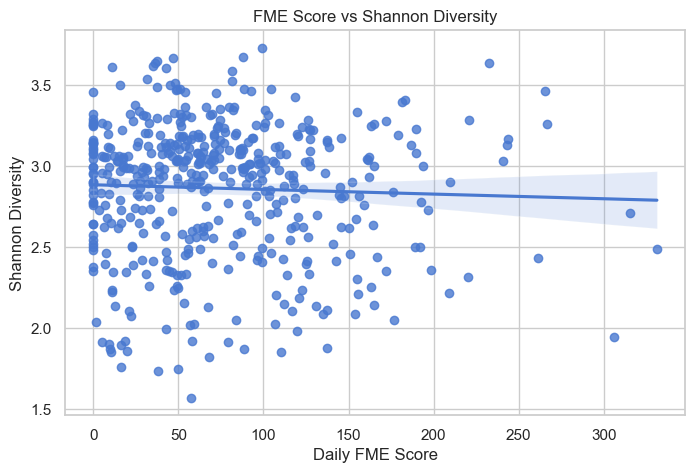

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="fme_score_daily",
    y="shannon_diversity"
)

plt.title("FME Score vs Shannon Diversity")
plt.xlabel("Daily FME Score")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The relationship between FME score and Shannon diversity appears to be weak.

Although FME values vary considerably across samples, Shannon diversity remains relatively stable.

The nearly flat regression line suggests little to no linear association between the two variables.

## Correlation Matrix

To better understand the relationships between microbiome-related variables, we compute a correlation matrix for the main numerical variables used in this analysis.

In [ ]:
correlation_columns = [
    "fme_score_daily",
    "shannon_diversity",
    "participant_shannon_cv",
    "participant_shannon_mean"
]

corr_matrix = df[correlation_columns].corr()

corr_matrix

,fme_score_daily,shannon_diversity,participant_shannon_cv,participant_shannon_mean
fme_score_daily,1.0000,-0.0406,-0.0771,-0.0153
shannon_diversity,-0.0406,1.0000,-0.4929,0.8917
participant_shannon_cv,-0.0771,-0.4929,1.0000,-0.5527
participant_shannon_mean,-0.0153,0.8917,-0.5527,1.0000


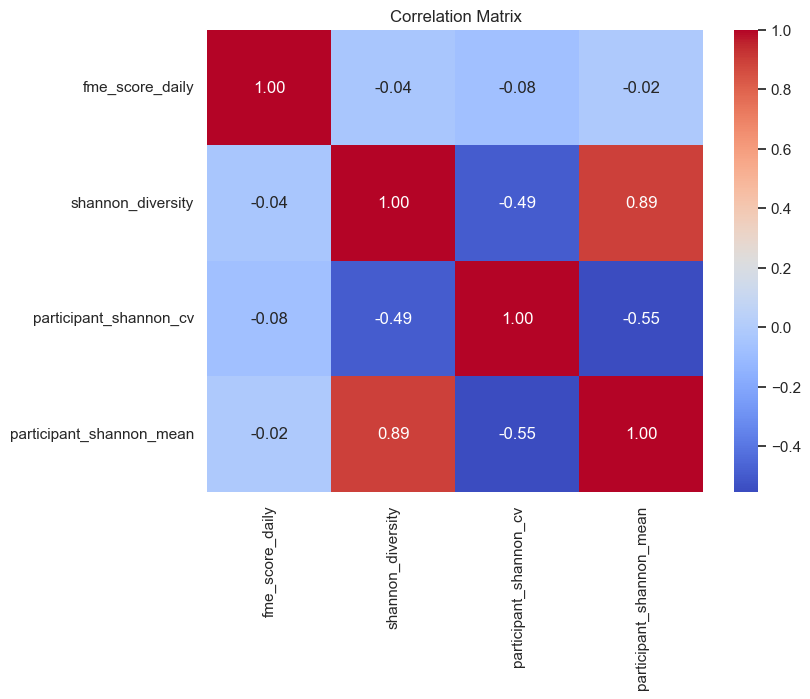

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Insight

FME score has very weak correlations with all diversity metrics.

Shannon diversity is strongly correlated with participant mean Shannon diversity.

## Comparison Between Low and High FME Groups

To further investigate the relationship between Food Microbiome Exposure (FME) and microbiome diversity, samples were divided into two groups based on the median FME score.

Shannon diversity distributions were then compared between the groups.

In [ ]:
# Create FME groups based on median value

median_fme = df["fme_score_daily"].median()

df["fme_group"] = np.where(
    df["fme_score_daily"] >= median_fme,
    "High FME",
    "Low FME"
)

df["fme_group"].value_counts()

fme_group
High FME    238
Low FME     237
Name: count, dtype: int64

### Shannon Diversity by FME Group

The following boxplot compares Shannon diversity values between samples with low and high Food Microbiome Exposure.

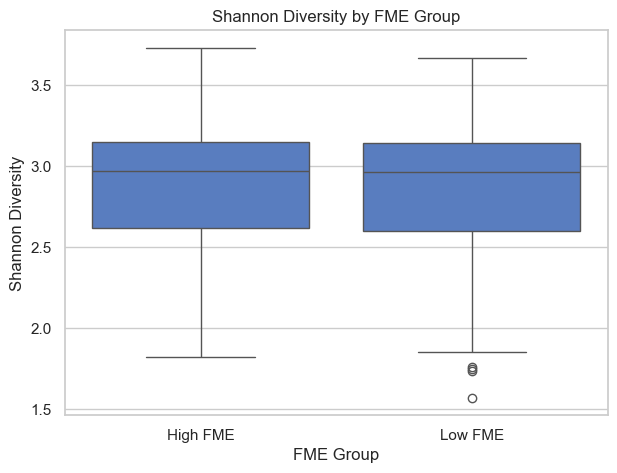

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="fme_group",
    y="shannon_diversity"
)

plt.title("Shannon Diversity by FME Group")
plt.xlabel("FME Group")
plt.ylabel("Shannon Diversity")

plt.show()

### Insight

The distributions of Shannon diversity are similar in both FME groups.

No clear difference in diversity is observed between low and high FME exposure levels.

### Statistical Test

A Mann–Whitney U test was performed to evaluate whether Shannon diversity differs significantly between the two FME groups.

In [ ]:
high_fme = df[df["fme_group"] == "High FME"]["shannon_diversity"]
low_fme = df[df["fme_group"] == "Low FME"]["shannon_diversity"]

stat, p_value = mannwhitneyu(high_fme, low_fme)

print("Mann-Whitney U Statistic:", stat)
print("P-value:", p_value)

Mann-Whitney U Statistic: 28228.0
P-value: 0.9869319368980619


### Insight

No significant difference was found between the low and high FME groups (p = 0.987).

This suggests that FME levels are not associated with differences in Shannon diversity in this dataset.

## Adjusted Regression Analysis

To account for potential dietary confounders, an additional regression model was fitted including nutrient intake variables.

This allows evaluation of the association between FME and Shannon diversity while controlling for dietary factors.

In [ ]:
model_adj = smf.ols(
    "shannon_diversity ~ fme_score_daily + KCAL + PROT + TFAT + CARB + FIBE",
    data=df
).fit()

print(model_adj.summary())

                            OLS Regression Results                            
Dep. Variable:      shannon_diversity   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.152
Date:                Wed, 10 Jun 2026   Prob (F-statistic):             0.0465
Time:                        23:09:08   Log-Likelihood:                -247.17
No. Observations:                 475   AIC:                             508.3
Df Residuals:                     468   BIC:                             537.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.7853      0.061     

### Insight

After adjusting for nutrient intake variables, FME score remained a non-significant predictor of Shannon diversity (p = 0.876).

This suggests that the observed lack of association is not explained by differences in dietary intake.

# Conclusions

Several statistical approaches were used to evaluate the relationship between Food Microbiome Exposure (FME) and gut microbiome diversity.

Main findings:

- The correlation between FME score and Shannon diversity was very weak.
- No significant differences were observed between low and high FME groups.
- Simple linear regression showed that FME score was not a significant predictor of Shannon diversity.
- After adjusting for dietary intake variables (KCAL, PROT, TFAT, CARB, and FIBE), FME score remained non-significant.
- Adjusting for nutrient intake did not change the overall findings.

Overall, no statistically significant association was found between FME levels and Shannon diversity in this dataset.

# Food Microbiome Exposure (FME) Analysis
## Research Question
**How does exposure to food-associated microbes influence the composition and stability of the human gut microbiome?**

### What this notebook does
1. **Data Transfer** — Load all preprocessed datasets from both sources
2. **Data Mapping** — Map dietary food items to cFMD food categories
3. **FME Quantification** — Calculate a daily Food Microbiome Exposure score per fecal sample
4. **Statistical Dataset** — Assemble one clean table ready for statistical modelling

### Key structural note
> The Johnson et al. 2019 study has **34 participants**, each contributing multiple fecal samples across up to 17 study days.
> All FME scores are computed at the **fecal sample level** (one score per sample = one dietary day per person).
> Participant-level summaries are derived by aggregating across samples — **not** by treating samples as independent observations.
> The unit of analysis for statistical models is the **fecal sample**, with participant included as a random effect.


---
## Section 1 – Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")


Libraries loaded.


In [ ]:
from pathlib import Path
import sys
# Locate repo root (directory containing config.py) regardless of launch directory
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
DATA_DIR = _root / "data"  # robust: does not depend on __file__ inside Jupyter
sys.path.insert(0, str(_root))


---
## Section 2 – Data Transfer: Load All Datasets

### Source 1 — Johnson et al. 2019 (gut microbiome + diet)
34 participants · up to 17 fecal samples each · 566 samples total

### Source 2 — Carlino et al. 2024 — cFMD (food microbiome)
3,393 food samples · 5,057 microbial taxa


In [ ]:
# ── Source 1: Gut microbiome matrices (taxa × fecal samples) ───────────────────
gut_microbiome_abundance  = pd.read_csv(DATA_DIR / "microbiome_filtered.csv", index_col=0)

# ── Source 1: Fecal sample metadata ────────────────────────────────────────────
# index = fecal sample ID (MCT.f.XXXX)
# columns: UserName (= participant), StudyDayNo, Gender, Age, BMI, ...
fecal_sample_metadata     = pd.read_csv(DATA_DIR / "sample_meta.csv",         index_col=0)

# ── Source 1: Dietary consumption matrix (food items × fecal samples) ──────────
# rows = food items, columns = fecal sample IDs (MCT.f.XXXX)
# values = consumption amount of that food on that day
dietary_consumption_matrix= pd.read_csv(DATA_DIR / "diet_raw.csv")

# ── Source 1: Daily nutrition totals ───────────────────────────────────────────
# index = fecal sample ID
daily_nutrition_totals    = pd.read_csv(DATA_DIR / "nutrition_totals.csv",    index_col=0)

# ── Source 1: Additional dietary features ──────────────────────────────────────
daily_fiber_scores        = pd.read_csv(DATA_DIR / "diet_fiber.csv")
daily_decay_scores        = pd.read_csv(DATA_DIR / "diet_decay.csv")
participant_fiber_avg     = pd.read_csv(DATA_DIR / "fiber_avg.csv")

# ── Source 2: cFMD food microbiome abundance (food taxa × food samples) ─────────
# columns: 'StudyName__ShortSampleID' format
cfmd_food_abundance       = pd.read_csv(DATA_DIR / "combined_datasets.csv",   index_col=0, low_memory=False)
cfmd_food_abundance       = cfmd_food_abundance.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# ── Source 2: cFMD sample metadata ─────────────────────────────────────────────
# columns: sample_id, category, fermented/non-fermented, country, ...
cfmd_food_metadata        = pd.read_csv(DATA_DIR / "cfmd_metadata.csv")

# ── Verify participant count ────────────────────────────────────────────────────
n_participants = fecal_sample_metadata["UserName"].nunique()
n_fecal_samples= len(fecal_sample_metadata)

print(f"Participants          : {n_participants}  (expected: 34)")
print(f"Fecal samples total   : {n_fecal_samples}")
print(f"Avg samples/person    : {n_fecal_samples / n_participants:.1f}")
print()
print("Dataset sizes:")
for name, df in [
    ("gut_microbiome_abundance",   gut_microbiome_abundance),
    ("fecal_sample_metadata",      fecal_sample_metadata),
    ("dietary_consumption_matrix", dietary_consumption_matrix),
    ("daily_nutrition_totals",     daily_nutrition_totals),
    ("cfmd_food_abundance",        cfmd_food_abundance),
    ("cfmd_food_metadata",         cfmd_food_metadata),
]:
    print(f"  {name:<32} {str(df.shape)}")


Participants          : 34  (expected: 34)
Fecal samples total   : 566
Avg samples/person    : 16.6

Dataset sizes:
  gut_microbiome_abundance         (223, 483)
  fecal_sample_metadata            (566, 28)
  dietary_consumption_matrix       (1452, 568)
  daily_nutrition_totals           (580, 106)
  cfmd_food_abundance              (5057, 3393)
  cfmd_food_metadata               (3444, 32)


---
## Section 3 – Define the Analytical Sample Set

Only fecal samples that have **both** a gut microbiome measurement **and** a dietary record
form the analytical core. We identify these 475 samples here.


In [ ]:
# ── Identify fecal sample IDs present in both gut microbiome and diet data ──────
FECAL_SAMPLE_PREFIX = "MCT.f."

gut_microbiome_sample_ids = set(gut_microbiome_abundance.columns)
diet_record_sample_ids    = set(
    c for c in dietary_consumption_matrix.columns
    if c.startswith(FECAL_SAMPLE_PREFIX)
)

# Core analytical set: samples with BOTH gut microbiome AND diet record
analytical_sample_ids = sorted(gut_microbiome_sample_ids & diet_record_sample_ids)

print(f"Gut microbiome samples         : {len(gut_microbiome_sample_ids)}")
print(f"Diet record samples            : {len(diet_record_sample_ids)}")
print(f"Analytical samples (gut∩diet)  : {len(analytical_sample_ids)}")
print()

# Participants represented in the analytical set
analytical_participants = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids), "UserName"]
    .nunique()
)
print(f"Participants represented       : {analytical_participants} / {n_participants}")

# Samples per participant in the analytical set
samples_per_participant = (
    fecal_sample_metadata
    .loc[fecal_sample_metadata.index.isin(analytical_sample_ids)]
    .groupby("UserName")
    .size()
    .rename("n_analytical_samples")
)
print(f"Avg analytical samples/person  : {samples_per_participant.mean():.1f}")
print(f"Min / Max                      : {samples_per_participant.min()} / {samples_per_participant.max()}")


Gut microbiome samples         : 483
Diet record samples            : 566
Analytical samples (gut∩diet)  : 475

Participants represented       : 34 / 34
Avg analytical samples/person  : 14.0
Min / Max                      : 6 / 17


---
## Section 4 – FME Weights from cFMD

**Goal:** Derive a microbial richness weight for each cFMD food category.

**Why richness, not total abundance?**
The `combined_datasets` matrix stores relative abundance — each sample sums to 100 regardless of food type.
Total abundance is therefore uninformative as a weight.
**Microbial richness** (= number of distinct taxa detected per food sample) reflects how microbiome-diverse each food category truly is.

**Weight formula:**
$$w_c = \frac{\text{mean\_richness}_c - \min}{\max - \min} \quad \in [0, 1]$$

Weights are derived directly from the **cFMD food abundance matrix** — not assumed or hand-coded.


In [ ]:
# ── Step 1: Map cFMD column names → food category + fermentation status ─────────
# combined_datasets columns: 'StudyName__ShortSampleID'
# cfmd_food_metadata sample_id: 'ShortSampleID'

def extract_cfmd_short_id(column_name):
    """Strip the study name prefix from a combined_datasets column name."""
    return column_name.split("__")[-1] if "__" in column_name else column_name

# Remove the one duplicate sample_id (VB15-29) before indexing
cfmd_food_metadata_dedup = cfmd_food_metadata.drop_duplicates(
    subset="sample_id", keep="first"
)
print(f"cFMD metadata after dedup: {len(cfmd_food_metadata_dedup)} rows "
      f"(removed {len(cfmd_food_metadata) - len(cfmd_food_metadata_dedup)} duplicate)")

cfmd_id_to_meta = (
    cfmd_food_metadata_dedup
    .set_index("sample_id")[["category", "fermented/non-fermented"]]
    .to_dict(orient="index")
)

# Map each column in cfmd_food_abundance to its category and fermentation status
cfmd_column_to_category   = {}
cfmd_column_to_fermented  = {}
for col in cfmd_food_abundance.columns:
    short_id = extract_cfmd_short_id(col)
    if short_id in cfmd_id_to_meta:
        cfmd_column_to_category[col]  = cfmd_id_to_meta[short_id]["category"]
        cfmd_column_to_fermented[col] = cfmd_id_to_meta[short_id]["fermented/non-fermented"]

print(f"cFMD columns mapped: {len(cfmd_column_to_category)} / {cfmd_food_abundance.shape[1]}")


cFMD metadata after dedup: 3443 rows (removed 1 duplicate)
cFMD columns mapped: 3393 / 3393


In [ ]:
# ── Step 2: Compute microbial richness per food sample ──────────────────────────
# Richness = number of non-zero taxa per food sample
cfmd_taxa_richness_per_sample = (cfmd_food_abundance > 0).sum(axis=0)

# ── Step 3: Mean richness per cFMD food category ────────────────────────────────
category_richness_values = {}
for col, category in cfmd_column_to_category.items():
    if col in cfmd_taxa_richness_per_sample.index:
        category_richness_values.setdefault(category, []).append(
            cfmd_taxa_richness_per_sample[col]
        )

cfmd_category_mean_richness = pd.Series(
    {cat: np.mean(vals) for cat, vals in category_richness_values.items()},
    name="mean_taxa_richness"
).sort_values(ascending=False)

# ── Step 4: Normalize weights to [0, 1] ─────────────────────────────────────────
richness_min = cfmd_category_mean_richness.min()
richness_max = cfmd_category_mean_richness.max()
cfmd_category_weight_normalized = (
    (cfmd_category_mean_richness - richness_min) /
    (richness_max - richness_min)
).rename("fme_weight")

cfmd_weights_table = pd.concat(
    [cfmd_category_mean_richness, cfmd_category_weight_normalized], axis=1
)

print("FME weights per cFMD food category (from cFMD microbial richness):")
display(cfmd_weights_table.round(3))


FME weights per cFMD food category (from cFMD microbial richness):


,mean_taxa_richness,fme_weight
fruits_and_vegetables,120.1250,1.0000
fermented_seeds,69.8000,0.5510
fermented_tubers_and_roots,61.0420,0.4720
fish,51.7950,0.3900
fermented_legumes,49.2630,0.3670
meat,43.6490,0.3170
fermented_meat,37.4110,0.2610
fermented_fruits_and_vegetables,31.4810,0.2080
other,27.8750,0.1760
dairy,25.3960,0.1540


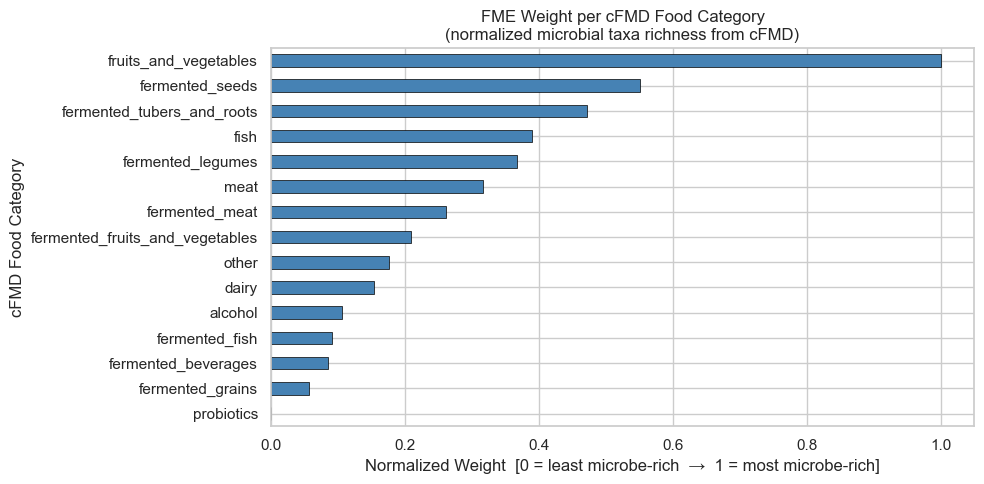

In [ ]:
# ── Visualize FME weights ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
cfmd_category_weight_normalized.sort_values().plot(
    kind="barh", color="steelblue", edgecolor="black", linewidth=0.5
)
plt.title("FME Weight per cFMD Food Category\n(normalized microbial taxa richness from cFMD)")
plt.xlabel("Normalized Weight  [0 = least microbe-rich  →  1 = most microbe-rich]")
plt.ylabel("cFMD Food Category")
plt.tight_layout()
plt.show()


---
## Section 5 – Data Mapping: Diet Items → cFMD Food Categories

**Goal:** Map each food item in the Johnson et al. dietary records to a cFMD food category,
creating a unified representation of food-derived microbial exposure.

**Method:** Extract the L1 (top-level) taxonomy label from the `taxonomy` column of `diet_raw`
(e.g. `L1_Milk_and_Milk_Products` → `dairy`) and map it to the matching cFMD category.


In [ ]:
# ── Extract L1 food category from taxonomy string ───────────────────────────────
def extract_l1_food_category(taxonomy_string):
    """
    Extract the top-level food category (L1) from the hierarchical taxonomy string.
    Example: 'L1_Milk_and_Milk_Products;L2_...' → 'milk and milk products'
    """
    if pd.isna(taxonomy_string):
        return "unknown"
    l1_segment = str(taxonomy_string).split(";")[0]
    return l1_segment.replace("L1_", "").replace("_", " ").strip().lower()

dietary_consumption_matrix["diet_l1_category"] = (
    dietary_consumption_matrix["taxonomy"]
    .apply(extract_l1_food_category)
)

print("Unique L1 diet categories found:")
for cat, count in dietary_consumption_matrix["diet_l1_category"].value_counts().items():
    print(f"  {cat:<45} {count:>5} food items")


Unique L1 diet categories found:
  grain product                                   407 food items
  vegetables                                      315 food items
  meat poultry fish and mixtures                  240 food items
  sugars sweets and beverages                     153 food items
  milk and milk products                          112 food items
  dry beans peas other legumes nuts and seeds      84 food items
  fruits                                           74 food items
  fats oils and salad dressings                    36 food items
  eggs                                             31 food items


In [ ]:
# ── Mapping table: diet L1 category → cFMD category ────────────────────────────
DIET_L1_TO_CFMD_CATEGORY = {
    # Dairy
    "milk and milk products"            : "dairy",
    "dairy"                             : "dairy",
    "cheese"                            : "dairy",
    "yogurt"                            : "dairy",
    # Meat
    "meat poultry and game"             : "meat",
    "meat"                              : "meat",
    "poultry"                           : "meat",
    # Fish
    "fish and shellfish"                : "fish",
    "fish"                              : "fish",
    "seafood"                           : "fish",
    # Fruits and vegetables
    "vegetables and vegetable products" : "fruits_and_vegetables",
    "fruit"                             : "fruits_and_vegetables",
    "fruits"                            : "fruits_and_vegetables",
    "vegetables"                        : "fruits_and_vegetables",
    # Fermented grains
    "grain products"                    : "fermented_grains",
    "grains"                            : "fermented_grains",
    "bread"                             : "fermented_grains",
    "cereals and cereal products"       : "fermented_grains",
    # Alcohol / fermented beverages
    "alcoholic beverages"               : "alcohol",
    "alcohol"                           : "alcohol",
    "beverages"                         : "fermented_beverages",
    "nonalcoholic beverages"            : "fermented_beverages",
    # Legumes
    "legumes and legume products"       : "fermented_legumes",
    "legumes"                           : "fermented_legumes",
    "beans"                             : "fermented_legumes",
    # Seeds / nuts
    "nuts and seeds"                    : "fermented_seeds",
    "seeds"                             : "fermented_seeds",
    # Other / unmappable
    "fats and oils"                     : "other",
    "sugars and sweets"                 : "other",
    "soups sauces and gravies"          : "other",
    "mixed dishes"                      : "other",
    "snacks"                            : "other",
    "eggs"                              : "other",
    "spices and herbs"                  : "other",
    "unknown"                           : "unmapped",
}

dietary_consumption_matrix["cfmd_category"] = (
    dietary_consumption_matrix["diet_l1_category"]
    .map(DIET_L1_TO_CFMD_CATEGORY)
    .fillna("unmapped")
)

n_mapped   = (dietary_consumption_matrix["cfmd_category"] != "unmapped").sum()
n_unmapped = (dietary_consumption_matrix["cfmd_category"] == "unmapped").sum()
print(f"Food items mapped to a cFMD category : {n_mapped} / {len(dietary_consumption_matrix)}")
print(f"Food items unmapped                  : {n_unmapped}")


Food items mapped to a cFMD category : 532 / 1452
Food items unmapped                  : 920


In [ ]:
# ── Attach FME weight to each food item ─────────────────────────────────────────
dietary_consumption_matrix["fme_weight"] = (
    dietary_consumption_matrix["cfmd_category"]
    .map(cfmd_category_weight_normalized.to_dict())
    .fillna(0.0)   # unmapped items get weight = 0
)

mapping_summary = (
    dietary_consumption_matrix
    .groupby(["diet_l1_category", "cfmd_category", "fme_weight"])
    .size()
    .reset_index(name="n_food_items")
    .sort_values("n_food_items", ascending=False)
)
print("Mapping summary (diet L1 → cFMD category → weight):")
display(mapping_summary)


Mapping summary (diet L1 → cFMD category → weight):


,diet_l1_category,cfmd_category,fme_weight,n_food_items
4,grain product,unmapped,0.0000,407
8,vegetables,fruits_and_vegetables,1.0000,315
5,meat poultry fish and mixtures,unmapped,0.0000,240
7,sugars sweets and beverages,unmapped,0.0000,153
6,milk and milk products,dairy,0.1541,112
0,dry beans peas other legumes nuts and seeds,unmapped,0.0000,84
3,fruits,fruits_and_vegetables,1.0000,74
2,fats oils and salad dressings,unmapped,0.0000,36
1,eggs,other,0.1762,31


---
## Section 6 – FME Score Calculation

**Formula:**
$$\text{FME}_{sample} = \sum_{\text{food items}} \text{consumption}_{\text{food, sample}} \times w_{\text{cfmd\_category(food)}}$$

Where:
- $\text{consumption}_{\text{food, sample}}$ = amount consumed (from `diet_raw`, grams or servings)
- $w$ = normalized cFMD microbial richness weight for the food's category

**Important:** Each `sample` corresponds to **one dietary day for one participant**.
The result is a score per fecal sample — not per participant.
Participant-level scores are derived later by averaging across their samples.


In [ ]:
# ── Subset diet matrix to analytical samples only ───────────────────────────────
diet_abundance_matrix = (
    dietary_consumption_matrix[analytical_sample_ids]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

fme_weight_vector = dietary_consumption_matrix["fme_weight"].values  # shape: (n_food_items,)

# ── Compute FME score: weighted sum of food consumption per sample ───────────────
# Result: one FME score per fecal sample (= one dietary day per participant)
fme_score_per_sample = (
    diet_abundance_matrix
    .multiply(fme_weight_vector, axis=0)
    .sum(axis=0)
    .rename("fme_score_daily")
)
fme_score_per_sample.index.name = "fecal_sample_id"

print(f"FME scores computed for : {len(fme_score_per_sample)} fecal samples")
print(f"Score range             : {fme_score_per_sample.min():.4f} – {fme_score_per_sample.max():.4f}")
print(f"Score mean ± std        : {fme_score_per_sample.mean():.4f} ± {fme_score_per_sample.std():.4f}")
print(f"Non-zero scores         : {(fme_score_per_sample > 0).sum()}")
print()
display(fme_score_per_sample.reset_index().head(8))


FME scores computed for : 475 fecal samples
Score range             : 0.0000 – 331.2240
Score mean ± std        : 73.3252 ± 58.3071
Non-zero scores         : 437



,fecal_sample_id,fme_score_daily
0,MCT.f.0002,67.1961
1,MCT.f.0003,81.2412
2,MCT.f.0004,126.7711
3,MCT.f.0005,31.4846
4,MCT.f.0006,61.2266
5,MCT.f.0007,62.0231
6,MCT.f.0008,70.9874
7,MCT.f.0009,54.0086


In [ ]:
# ── Participant-level FME summary (aggregate across samples) ────────────────────
# Note: samples are NOT independent — they come from the same 34 participants.
# Participant-level values are used ONLY for descriptive summaries,
# NOT as independent data points in statistical models.

fme_with_participant = pd.DataFrame({
    "fecal_sample_id" : fme_score_per_sample.index,
    "fme_score_daily" : fme_score_per_sample.values,
})
fme_with_participant["participant_id"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "UserName"]
    .values
)
fme_with_participant["study_day"] = (
    fecal_sample_metadata
    .loc[fme_with_participant["fecal_sample_id"], "StudyDayNo"]
    .values
)

# Participant-level summary (descriptive only)
participant_fme_summary = (
    fme_with_participant
    .groupby("participant_id")["fme_score_daily"]
    .agg(
        fme_mean     = "mean",
        fme_std      = "std",
        fme_min      = "min",
        fme_max      = "max",
        n_diet_days  = "count"
    )
    .reset_index()
)

print("Participant-level FME summary (descriptive — 34 participants):")
display(participant_fme_summary.sort_values("fme_mean", ascending=False).head(10))


Participant-level FME summary (descriptive — 34 participants):


,participant_id,fme_mean,fme_std,fme_min,fme_max,n_diet_days
1,MCTs03,147.8899,45.7548,68.0651,243.3253,12
5,MCTs07,143.4859,48.3133,86.0332,243.8429,16
2,MCTs04,143.1190,81.0506,36.6199,331.2240,15
6,MCTs08,140.2178,33.6074,84.4009,220.3516,17
14,MCTs16,130.9598,45.2371,69.7540,221.0863,14
27,MCTs31,128.7335,37.7598,83.9027,208.7920,15
23,MCTs26,122.0334,71.3654,24.5678,315.7055,17
16,MCTs19,99.4541,40.7179,14.6490,166.4480,15
17,MCTs20,88.6724,51.9185,24.4219,178.8966,12
24,MCTs27,85.2074,47.0410,5.0752,165.2448,14


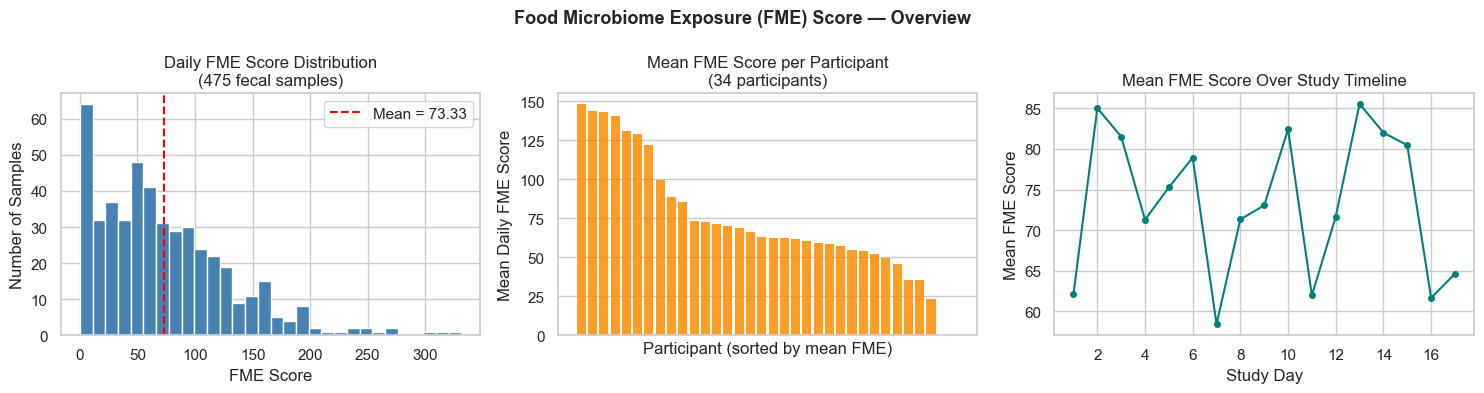

In [ ]:
# ── Visualize FME scores ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of daily FME scores across all fecal samples
axes[0].hist(fme_score_per_sample.values, bins=30,
             color="steelblue", edgecolor="white")
axes[0].axvline(fme_score_per_sample.mean(), color="red", linestyle="--",
                label=f"Mean = {fme_score_per_sample.mean():.2f}")
axes[0].set_title("Daily FME Score Distribution\n(475 fecal samples)")
axes[0].set_xlabel("FME Score")
axes[0].set_ylabel("Number of Samples")
axes[0].legend()

# Mean FME per participant (sorted)
sorted_participants = participant_fme_summary.sort_values("fme_mean", ascending=False)
axes[1].bar(range(len(sorted_participants)), sorted_participants["fme_mean"],
            color="darkorange", edgecolor="none", alpha=0.85)
axes[1].set_title(f"Mean FME Score per Participant\n({len(sorted_participants)} participants)")
axes[1].set_xlabel("Participant (sorted by mean FME)")
axes[1].set_ylabel("Mean Daily FME Score")
axes[1].set_xticks([])

# FME over study timeline (mean per study day)
fme_by_day = fme_with_participant.groupby("study_day")["fme_score_daily"].mean()
axes[2].plot(fme_by_day.index, fme_by_day.values,
             marker="o", color="teal", linewidth=1.5, markersize=4)
axes[2].set_title("Mean FME Score Over Study Timeline")
axes[2].set_xlabel("Study Day")
axes[2].set_ylabel("Mean FME Score")

plt.suptitle("Food Microbiome Exposure (FME) Score — Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Section 7 – Gut Microbiome Alpha Diversity per Fecal Sample

Compute **Shannon entropy** for each fecal sample as a measure of gut microbial richness and evenness.
This is the primary outcome variable (composition proxy) at the sample level.


In [ ]:
# ── Shannon entropy per fecal sample ────────────────────────────────────────────
def compute_shannon_entropy(abundance_column):
    """Shannon entropy H = -Σ p_i * log(p_i) for non-zero taxa."""
    positive_values = abundance_column[abundance_column > 0]
    if positive_values.sum() == 0:
        return np.nan
    proportions = positive_values / positive_values.sum()
    return float(-np.sum(proportions * np.log(proportions)))

gut_microbiome_analytical = gut_microbiome_abundance[analytical_sample_ids]
shannon_diversity_per_sample = (
    gut_microbiome_analytical
    .apply(compute_shannon_entropy, axis=0)
    .rename("shannon_diversity")
)
shannon_diversity_per_sample.index.name = "fecal_sample_id"

print(f"Shannon diversity computed for : {shannon_diversity_per_sample.notna().sum()} samples")
print(f"Range  : {shannon_diversity_per_sample.min():.3f} – {shannon_diversity_per_sample.max():.3f}")
print(f"Mean   : {shannon_diversity_per_sample.mean():.3f}")


Shannon diversity computed for : 475 samples
Range  : 1.572 – 3.731
Mean   : 2.865


---
## Section 8 – Gut Microbiome Stability per Participant

**Stability** = how consistent is a participant's gut microbiome across their sampling days?

We use the **coefficient of variation (CV)** of Shannon diversity across a participant's samples:
$$CV_{participant} = \frac{\sigma(\text{Shannon})}{\mu(\text{Shannon})}$$

Lower CV = more stable microbiome.

> This is computed at the **participant level** (34 values) and joined back to the sample-level table as a per-participant attribute.


In [ ]:
# ── Map each fecal sample to its participant ─────────────────────────────────────
sample_to_participant = (
    fecal_sample_metadata
    .loc[analytical_sample_ids, "UserName"]
    .rename("participant_id")
)

shannon_with_participant = pd.DataFrame({
    "fecal_sample_id" : shannon_diversity_per_sample.index,
    "shannon_diversity": shannon_diversity_per_sample.values,
}).set_index("fecal_sample_id")
shannon_with_participant["participant_id"] = sample_to_participant

# ── Participant-level stability (CV of Shannon across their samples) ───────────
participant_gut_stability = (
    shannon_with_participant
    .groupby("participant_id")["shannon_diversity"]
    .agg(
        participant_shannon_mean = "mean",
        participant_shannon_std  = "std",
        participant_n_samples    = "count"
    )
    .assign(
        participant_shannon_cv = lambda df:
            df["participant_shannon_std"] / df["participant_shannon_mean"]
    )
    .reset_index()
)

print(f"Gut stability computed for {len(participant_gut_stability)} participants")
print(f"Shannon CV range : {participant_gut_stability['participant_shannon_cv'].min():.4f} – "
      f"{participant_gut_stability['participant_shannon_cv'].max():.4f}")
display(participant_gut_stability.sort_values("participant_shannon_cv").head(8))


Gut stability computed for 34 participants
Shannon CV range : 0.0202 – 0.1799


,participant_id,participant_shannon_mean,participant_shannon_std,participant_n_samples,participant_shannon_cv
5,MCTs07,3.0731,0.0621,16,0.0202
17,MCTs20,3.2696,0.0736,12,0.0225
29,MCTs33,3.0863,0.0876,17,0.0284
11,MCTs13,3.1848,0.0942,11,0.0296
19,MCTs22,2.9985,0.0912,15,0.0304
7,MCTs09,3.0362,0.0948,16,0.0312
30,MCTs34,2.9806,0.1022,12,0.0343
8,MCTs10,3.0279,0.1045,14,0.0345


---
## Section 9 – Assemble the Statistical Analysis Dataset

Merge all variables into one clean table at the **fecal sample level**.
Each row = one fecal sample = one dietary day for one participant.

| Column group | Columns | Role in statistical model |
|---|---|---|
| Identity | `fecal_sample_id`, `participant_id`, `study_day` | Grouping / random effect |
| Demographics | `Age`, `BMI`, `Gender` | Fixed-effect covariates |
| **FME score** | `fme_score_daily` | **Main predictor** |
| **Gut diversity** | `shannon_diversity` | **Main outcome** |
| **Gut stability** | `participant_shannon_cv` | **Secondary outcome** |
| Nutrition | `KCAL`, `FIBE`, `PROT`, `TFAT`, `CARB` | Dietary confounders |


In [ ]:
# ── Step 1: Base table — fecal sample IDs ──────────────────────────────────────
statistical_analysis_dataset = pd.DataFrame(
    index=pd.Index(analytical_sample_ids, name="fecal_sample_id")
)

# ── Step 2: Participant identity and demographics ───────────────────────────────
participant_meta_cols = ["UserName", "StudyDayNo", "Gender", "Age", "BMI",
                         "Weight", "Supplement", "Medications"]
participant_meta_cols = [c for c in participant_meta_cols
                         if c in fecal_sample_metadata.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    fecal_sample_metadata[participant_meta_cols]
    .rename(columns={"UserName": "participant_id", "StudyDayNo": "study_day"}),
    how="left"
)

# ── Step 3: Daily FME score ─────────────────────────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    fme_score_per_sample.rename("fme_score_daily"),
    how="left"
)

# ── Step 4: Gut alpha diversity (Shannon) ──────────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    shannon_diversity_per_sample.rename("shannon_diversity"),
    how="left"
)

# ── Step 5: Participant-level gut stability (CV) ────────────────────────────────
statistical_analysis_dataset = statistical_analysis_dataset.join(
    participant_gut_stability.set_index("participant_id")[
        ["participant_shannon_cv", "participant_shannon_mean", "participant_n_samples"]
    ],
    on="participant_id",
    how="left"
)

# ── Step 6: Daily nutrition totals ─────────────────────────────────────────────
nutrition_cols_keep = ["KCAL", "PROT", "TFAT", "CARB", "FIBE",
                       "SUGR", "SODI", "D_TOTAL", "D_YOGURT", "D_CHEESE",
                       "PF_MEAT", "PF_SEAFD_HI", "G_WHOLE"]
nutrition_cols_keep = [c for c in nutrition_cols_keep
                       if c in daily_nutrition_totals.columns]

statistical_analysis_dataset = statistical_analysis_dataset.join(
    daily_nutrition_totals[nutrition_cols_keep],
    how="left"
)

print(f"Statistical dataset shape  : {statistical_analysis_dataset.shape}")
print(f"Fecal samples (rows)       : {statistical_analysis_dataset.shape[0]}")
print(f"Variables (columns)        : {statistical_analysis_dataset.shape[1]}")
print(f"Participants represented   : {statistical_analysis_dataset['participant_id'].nunique()}")
print(f"Complete rows (no NaN)     : {statistical_analysis_dataset.dropna().shape[0]}")


Statistical dataset shape  : (475, 26)
Fecal samples (rows)       : 475
Variables (columns)        : 26
Participants represented   : 34
Complete rows (no NaN)     : 220


In [ ]:
# ── Missing value report ───────────────────────────────────────────────────────
missing_report = (
    statistical_analysis_dataset.isnull().sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "n_missing"})
)
missing_report["pct_missing"] = (
    missing_report["n_missing"] / len(statistical_analysis_dataset) * 100
).round(1)
missing_report = missing_report[missing_report["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_report.empty:
    print("No missing values in the statistical dataset.")
else:
    print("Missing values:")
    display(missing_report)


Missing values:


,variable,n_missing,pct_missing
7,Medications,255,53.7000


In [ ]:
# ── Descriptive statistics ─────────────────────────────────────────────────────
key_vars = ["fme_score_daily", "shannon_diversity",
            "participant_shannon_cv", "Age", "BMI", "KCAL", "FIBE"]
key_vars = [v for v in key_vars if v in statistical_analysis_dataset.columns]

print("Descriptive statistics — key variables:")
display(statistical_analysis_dataset[key_vars].describe().T.round(3))


Descriptive statistics — key variables:


,count,mean,std,min,25%,50%,75%,max
fme_score_daily,475.0000,73.3250,58.3070,0.0000,29.3220,61.7780,104.2700,331.2240
shannon_diversity,475.0000,2.8650,0.4130,1.5720,2.6110,2.9640,3.1430,3.7310
participant_shannon_cv,475.0000,0.0630,0.0380,0.0200,0.0360,0.0490,0.0800,0.1800
Age,475.0000,31.1520,10.1560,19.7000,23.9000,28.5000,37.0000,61.6000
BMI,475.0000,23.1750,3.2920,17.0000,21.1000,22.9000,25.9000,31.6000
KCAL,475.0000,2110.5630,735.4510,722.5520,1599.1800,2028.1680,2494.0980,5085.9770
FIBE,475.0000,22.3370,11.6000,3.6180,14.8500,19.6940,26.7120,67.5020


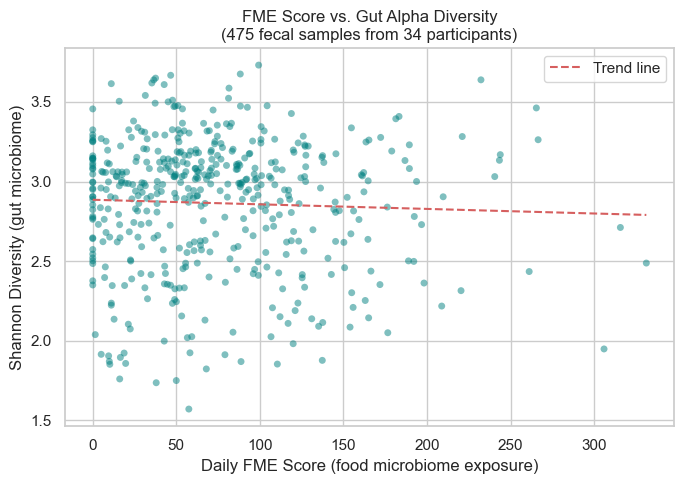

In [ ]:
# ── Quick scatter: FME score vs. gut Shannon diversity ─────────────────────────
plot_df = statistical_analysis_dataset.dropna(
    subset=["fme_score_daily", "shannon_diversity"]
)

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["fme_score_daily"], plot_df["shannon_diversity"],
            alpha=0.5, s=25, c="teal", edgecolors="none")
if len(plot_df) > 2:
    z = np.polyfit(plot_df["fme_score_daily"], plot_df["shannon_diversity"], 1)
    x_line = np.linspace(plot_df["fme_score_daily"].min(),
                         plot_df["fme_score_daily"].max(), 100)
    plt.plot(x_line, np.poly1d(z)(x_line), "r--", lw=1.5, label="Trend line")
plt.xlabel("Daily FME Score (food microbiome exposure)")
plt.ylabel("Shannon Diversity (gut microbiome)")
plt.title("FME Score vs. Gut Alpha Diversity\n(475 fecal samples from 34 participants)")
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 10 – Save Outputs

In [ ]:
# ── Save statistical analysis dataset ─────────────────────────────────────────
statistical_analysis_dataset.to_csv(DATA_DIR / "fme_statistical_dataset.csv")
participant_gut_stability.to_csv(DATA_DIR / "participant_gut_stability.csv", index=False)
fme_with_participant.to_csv(DATA_DIR / "fme_sample_level_scores.csv", index=False)

print("Saved:")
print(f"  fme_statistical_dataset.csv    {statistical_analysis_dataset.shape}  — main analytical table")
print(f"  participant_gut_stability.csv  {participant_gut_stability.shape}  — stability per participant")
print(f"  fme_sample_level_scores.csv    {fme_with_participant.shape}  — FME scores with participant labels")


Saved:
  fme_statistical_dataset.csv    (475, 26)  — main analytical table
  participant_gut_stability.csv  (34, 5)  — stability per participant
  fme_sample_level_scores.csv    (475, 4)  — FME scores with participant labels


---
## Summary

### What was built
The `fme_statistical_dataset.csv` table is the **primary input for all statistical analyses**.

### Structural note (important for modelling)
- **Unit of observation**: fecal sample (475 rows)
- **Grouping variable**: `participant_id` (34 participants) → must be included as a **random effect**
- **Main predictor**: `fme_score_daily`
- **Main outcomes**: `shannon_diversity` (composition), `participant_shannon_cv` (stability)

### Recommended next steps
```
Mixed-effects model (composition):
  shannon_diversity ~ fme_score_daily + Age + BMI + KCAL + (1 | participant_id)

Mixed-effects model (stability — participant level, n=34):
  participant_shannon_cv ~ mean(fme_score_daily) + Age + BMI
```


Model test part

In [ ]:
#Load data
df_fme = pd.read_csv(DATA_DIR / "fme_statistical_dataset.csv", index_col=0)
print(f"Loaded dataset: {df_fme.shape[0]} samples, {df_fme.shape[1]} columns")
print(f"Participants: {df_fme['participant_id'].nunique()}")

print("=== Sample of  Data ===")
print(df_fme.head())

Loaded dataset: 475 samples, 26 columns
Participants: 34
=== Sample of  Data ===
                participant_id  study_day Gender     Age     BMI  Weight  \
fecal_sample_id                                                            
MCT.f.0002              MCTs01          2      F 25.9000 25.0000 74.6000   
MCT.f.0003              MCTs01          3      F 25.9000 25.0000 74.6000   
MCT.f.0004              MCTs01          4      F 25.9000 25.0000 74.6000   
MCT.f.0005              MCTs01          5      F 25.9000 25.0000 74.6000   
MCT.f.0006              MCTs01          6      F 25.9000 25.0000 74.6000   

                Supplement             Medications  fme_score_daily  \
fecal_sample_id                                                       
MCT.f.0002            EVOO  Nexplanon (bc implant)          67.1961   
MCT.f.0003            EVOO  Nexplanon (bc implant)          81.2412   
MCT.f.0004            EVOO  Nexplanon (bc implant)         126.7711   
MCT.f.0005            EVOO  Nex

In [ ]:
#Turn shannon diversity from contiues to binary
median_shannon = df_fme["shannon_diversity"].median()
df_fme["High_Diversity_Class"] = (df_fme["shannon_diversity"] > median_shannon).astype(int)
print(f"\nTarget distribution (High=1 / Low=0):")
print(df_fme["High_Diversity_Class"].value_counts())


Target distribution (High=1 / Low=0):
High_Diversity_Class
0    238
1    237
Name: count, dtype: int64


In [ ]:
#Features
feature_cols = ["fme_score_daily", "KCAL", "FIBE", "CARB", "TFAT", "Age", "BMI"]
feature_cols = [f for f in feature_cols if f in df_fme.columns]

In [ ]:
#Drop rows with missing values in features or target
df_fme_clean = df_fme[feature_cols + ["High_Diversity_Class", "participant_id"]].dropna()

#Prepare data for modeling
X = df_fme_clean[feature_cols]
print(X.columns.tolist())
y = df_fme_clean['High_Diversity_Class']
groups = df_fme_clean['participant_id']

['fme_score_daily', 'KCAL', 'FIBE', 'CARB', 'TFAT', 'Age', 'BMI']


In [ ]:
#Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

#Cross validation
gkf = GroupKFold(n_splits=5)

#Train and evaluate models
print("\n=== Model Comparison Results ===")
best_model_name = ""
best_auc = 0
best_model_feat_obj = None


=== Model Comparison Results ===


In [ ]:
for name, model in models.items():
    acc_scores = []
    auc_scores = []
    
    #Make sure subjects are not split between train and test sets
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        #Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        #Train
        model.fit(X_train_scaled, y_train)
        
        #Predictions
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        #Calculate metrics
        acc_scores.append(accuracy_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_proba))
    
    #Compute mean metrics across folds
    mean_acc = np.mean(acc_scores)
    mean_auc = np.mean(auc_scores)
    
    print(f"\n[{name}]")
    print(f"Mean Accuracy: {mean_acc:.3f}")
    print(f"Mean ROC-AUC:  {mean_auc:.3f}")
    
    #Save best model based on AUC
    if mean_auc > best_auc:
        best_auc       = mean_auc
        best_model_name = name
        best_model_obj  = model

print(f"\n Best Model: {best_model_name} (Mean AUC = {best_auc:.3f})")


[Logistic Regression]
Mean Accuracy: 0.442
Mean ROC-AUC:  0.452

[Random Forest]
Mean Accuracy: 0.516
Mean ROC-AUC:  0.526

[XGBoost]
Mean Accuracy: 0.533
Mean ROC-AUC:  0.561

 Best Model: XGBoost (Mean AUC = 0.561)


In [ ]:
#Feature importance for best model
if best_model_name == "Logistic Regression":
    importances = np.abs(best_model_obj.coef_[0])
    title       = "Feature Importance (Logistic Regression — Absolute Coefficients)"
    xlabel      = "Absolute Coefficient Value"
else:
    importances = best_model_obj.feature_importances_
    title       = f"Feature Importance ({best_model_name})"
    xlabel      = "Importance Score"
 
indices      = np.argsort(importances)[::-1]
feature_arr  = np.array(feature_cols)
 

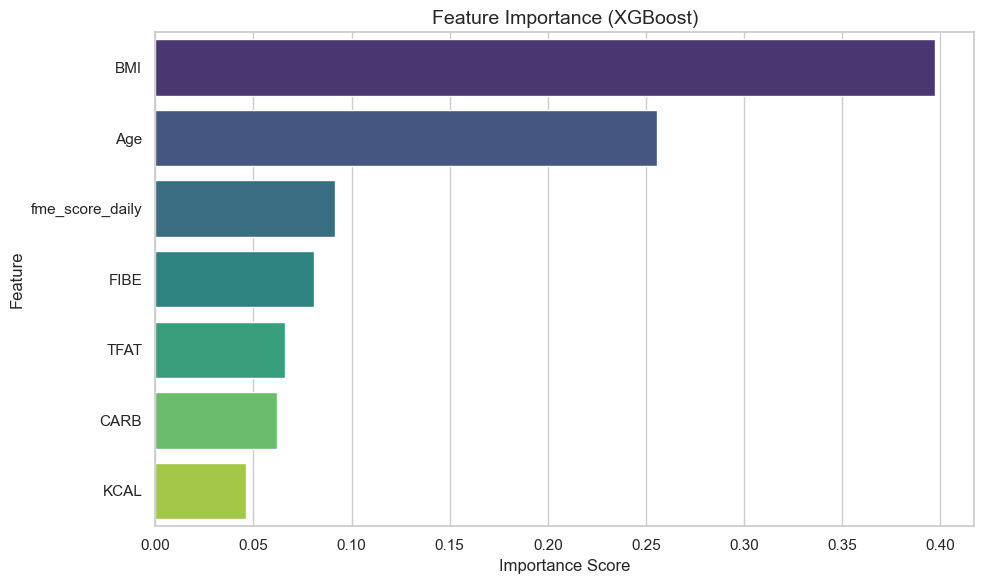

Plot saved: c:\Users\mayag\PythonForuni\ProjectYear3\data\feature_importance.png


In [ ]:
#Plot feature importance

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_arr[indices], hue=feature_arr[indices], palette="viridis", legend=False)
plt.title(title, fontsize=14)
plt.xlabel(xlabel, fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "feature_importance.png", dpi=150)      #Save before showings
plt.show()
print(f"Plot saved: {DATA_DIR / 'feature_importance.png'}")